# Model Validation of a CDS Hazard-Rate Framework for Credit Risk under Stochastic Intensity
**Author**: [Jovan Zigic](https://www.jovanzigic.com/)  
**Date**: March 20, 2026

## A. Purpose

We conduct a structured model risk assessment of a reduced-form hazard-rate framework for credit default swaps (CDS), extended to incorporate stochastic intensity and correlated defaults.

Model risk management is concerned with the identification, measurement, and control of uncertainty arising from model assumptions, implementation, and use. This requires rigorous validation, transparent communication, and independent challenge—principles that align closely with disciplined mathematical and computational analysis.  

## B. Scope of Knowledge

**Skills**:

The following competencies underpin the quantitative and validation methodologies applied throughout this project:

1. Foundational Mathematics (Linear Algebra, Probability, Statistics)
2. Stochastic Calculus (Martingales/Markov Processes, Geometric Brownian Motion, Itô's lemma)
3. Mathematical Finance (Risk-Neutral Valuation, Derivatives Pricing, Greeks/Hedging, Arbitrage)
4. Numerical Methods (Optimization, Monte Carlo Simulation, Finite Difference Methods)
5. Programming (Python, C++)

**References**:

The following references inform both the quantitative modeling approach and the model risk management framework:

1. [Wilmott, P. (2007). *Paul Wilmott Introduces Quantitative Finance (2nd Edition).*](https://www.amazon.com/Paul-Wilmott-Introduces-Quantitative-Finance/dp/0470319585)
2. [Wilmott, P. (2009). *Frequently Asked Questions in Quantitative Finance (2nd Edition).*](https://www.amazon.com/Frequently-Asked-Questions-Quantitative-Finance/dp/0470748753)
3. [Morini, M. (2010). *Understanding and Managing Model Risk.*](https://www.amazon.com/Understanding-Managing-Model-Risk-Validators/dp/0470977612)
4. [Federal Reserve Board. (2011). *SR 11-7: Supervisory Guidance on Model Risk Management.*](https://www.federalreserve.gov/boarddocs/srletters/2011/sr1107a1.pdf)
5. [OCC. (2021). *Comptroller’s Handbook: Model Risk Management.*](https://www.occ.gov/publications-and-resources/publications/comptrollers-handbook/files/model-risk-management/index-model-risk-management.html)
6. [MRMIA. (2025). *Principles for Model Risk Management.*](https://www.mrmia.org/en/publications/principles-for-model-risk-management)

## C. Documented Framework

This framework provides a comprehensive, standardized model risk assessment with cross-asset applicability. It is not intended to replicate the dynamic, model-specific validation, monitoring, and governance processes implemented throughout the model lifecycle in production environments.

1. **[Verification](#d1)**  
a. [Mathematical formulation](#d1a)  
b. [Numerical stability and convergence](#d1b)  
c. [Independent replication](#d1c)  
d. [Payoff and boundary condition validation](#d1d)  

2. **[Conceptual Soundness](#d2)**  
a. [Model assumptions](#d2a)  
b. [Financial rationale](#d2b)  
c. [Applicability](#d2c)  
d. [Structural limitations](#d2d)  

3. **[Calibration](#d3)**  
a. [Methodology](#d3a)  
b. [Parameter stability](#d3b)  
c. [Data quality](#d3c)  
d. [Sensitivity to inputs](#d3d)  

4. **[Benchmarking](#d4)**  
a. [Challenger models](#d4a)  
b. [Comparison metrics](#d4b)  
c. [Relative differences](#d4c)  

5. **[Outcomes Analysis](#d5)**  
a. [Back-testing](#d5a)  
b. [Predictive performance](#d5b)  
c. [Error decomposition](#d5c)  

6. **[Stress Testing](#d6)**  
a. [Extreme scenarios](#d6a)  
b. [Parameter shocks](#d6b)  
c. [Breakdown regions](#d6c)  
d. [Robustness](#d6d)  

7. **[Validation Conclusion](#d7)**  
a. [Approval status](#d7a)  
b. [Limitations](#d7b)  
c. [Usage restrictions](#d7c)  
d. [Required improvements](#d7d)  

8. **[Ongoing Monitoring](#d8)**  
a. [Performance tracking](#d8a)  
b. [Model drift](#d8b)  
c. [Thresholds and triggers](#d8c)  
d. [Recalibration frequency](#d8d)  
e. [Change management](#d8e)  

## D. Summary

This quantitative finance project covers the following generalized specifications:
1. **Task**: Model Validation
2. **Instrument**: Credit Default Swaps (CDS)
3. **Model Class**: Reduced-Form (Hazard-Rate)
4. **Risk Domain**: Credit Risk
5. **Model Features**: Stochastic Intensity; Correlated Defaults

We assess the model’s fitness for purpose across key dimensions of model risk, including conceptual soundness, calibration, benchmarking, robustness, and governance.

The model demonstrates acceptable performance for its intended use, subject to identified limitations. In particular, we find that the model is:
1. **Mathematically well-defined, numerically stable, and interpretable** under standard discretization schemes.
2. **Conceptually appropriate** given its assumptions, with known limitations under stressed and extreme regimes.
3. **Calibrated to synthetic data with strong fit**, though sensitivity to parameter choices is observed.
4. **Consistent with benchmark models**, with differences attributable to structural features and stochastic extensions.
5. **Practical for simulation-based applications**, including pricing and scenario analysis.
6. **Well-characterized across baseline and stressed conditions**, including identified breakdown regions.
7. **Acceptable from a model risk perspective**, subject to documented limitations and appropriate use constraints.
8. **Suitable for ongoing monitoring**, with clearly defined thresholds, recalibration triggers, and governance controls.

Full details of the analysis and supporting evidence are provided in the remainder of this document.

---

## 1. Verification 
<a id="d1"></a>
*(Did we build the model correctly?)*

### 1.a. Mathematical formulation 
<a id="d1a"></a>
*(Is the model mathematically well-defined and internally consistent?)*

We consider a reduced-form credit risk framework under the risk-neutral measure $\mathbb{Q}$. In the deterministic case, the survival probability is
$$ \mathbb{Q}(\tau > t) = \exp \left(-\int_0^t \lambda(s) \ ds \right), \tag{1.1} $$
where $\lambda(s)$ is the default intensity. We extend this framework by modeling the default time $\tau$ as a Cox (doubly stochastic Poisson) time driven by stochastic intensity $\lambda_t$. Specifically, the stochastic intensity follows a Cox-Ingersoll-Ross (CIR) diffusion process under $\mathbb{Q}$,
$$ d\lambda_t = \kappa (\theta - \lambda_t) dt + \sigma \sqrt{\lambda_t} dW_t ~~,~~ \lambda_0 >0, \tag{1.2} $$
where $\kappa>0$ is the mean-reversion speed, $\theta>0$ is the long-run mean, and $\sigma>0$ is the volatility. To ensure strict positivity of the intensity, we assume the Feller condition 
$$ 2\kappa \theta \geq \sigma^2 . \tag{1.3}$$
In this setting, the survival probability conditional on the filtration generated by $\lambda_t$ is
$$ \mathbb{Q}\left( \tau > t \ \vert \ \mathcal{F}_t^{\lambda} \right) = \exp \left(-\int_0^t \lambda_s \ ds \right), \tag{1.4}$$
and the unconditional survival probability is given by 
$$ \mathbb{Q}(\tau > t) = \mathbb{E}^{\mathbb{Q}} \left[ \exp \left(-\int_0^t \lambda_s \ ds \right)\right]. \tag{1.5}$$
For a portfolio of $n$ obligors, we consider individual stochastic intensities 
$$\lambda_t^{(i)} ~~,~~i=1,2,\dotsc,n \tag{1.6}$$ 
such that each evolves as a CIR process 
$$ d\lambda_t^{(i)} = \kappa_i (\theta_i - \lambda_t^{(i)}) dt + \sigma_i \sqrt{\lambda_t^{(i)}} dW_t^{(i)}. \tag{1.7}$$
We assume dependence between obligors through correlated Brownian motions
$$ dW_t^{(i)}dW_t^{(j)} = \rho_{ij}dt , \tag{1.8}$$
or equivalently
$$ \text{Corr}(dW_t^{(i)},dW_t^{(j)})= \rho_{ij}.  \tag{1.9}$$

Therefore, default times $\tau_i$ associated with stochastic intensities $\lambda_t^{(i)}$ yield correlated defaults through the joint dynamics of the intensity processes. For each obligor $i$, let $E_i\sim \text{Exp}(1)$ be independent standard exponential random variables. The default time is defined by
$$ \tau_i = \inf\left\{ t\geq 0 \ \Big\vert \ \int_0^t \lambda_s^{(i)} \ ds \geq E_i \right\}, \tag{1.10}$$
ensuring that, conditional on the path of $\lambda_t^{(i)}$, the survival probability satisfies
$$ \mathbb{Q}\left( \tau_i > t \ \vert \ \mathcal{F}_t^{\lambda^{(i)}} \right) = \exp \left(-\int_0^t \lambda_s^{(i)} \ ds \right). \tag{1.11}$$
We consider a standard CDS contract with maturity $T$, constant risk-free rate $r$, recovery rate $R\in [0,1]$, and spread $s$. The protection leg is given by
$$ \text{Prot} = \mathbb{E}^{\mathbb{Q}} \left[ e^{-r\tau}(1-R)\mathbf{1}_{\{\tau \leq T\}}  \right]\tag{1.12}$$
and the premium leg is given by
$$ \text{Prem} = \mathbb{E}^{\mathbb{Q}} \left[\int_0^T e^{-rt}s\mathbf{1}_{\{\tau > t\}} \ dt  \right]\tag{1.13}$$
such that the fair CDS spread $s$ is determined by the equilibrium condition
$$ \text{Prem} = \text{Prot}, \tag{1.14}$$
Solving for $s$, the fair CDS spread is given by
$$ s = \frac{ \mathbb{E}^{\mathbb{Q}} \left[ e^{-r\tau}(1-R)\mathbf{1}_{\{\tau \leq T\}} \right] }{ \mathbb{E}^{\mathbb{Q}} \left[\int_0^T e^{-rt}\mathbf{1}_{\{\tau > t\}} \ dt  \right] }, \tag{1.15} $$
where the denominator defines the risky annuity
$$ \text{Annuity} = \mathbb{E}^{\mathbb{Q}} \left[\int_0^T e^{-rt}\mathbf{1}_{\{\tau > t\}} \ dt  \right] \tag{1.16} $$
so that $(1.15)$ is equivalently expressed as
$$ s = \frac{ \text{Prot} }{ \text{Annuity} }. \tag{1.17} $$

### 1.b. Numerical stability and convergence* 
<a id="d1b"></a>
*(Do numerical methods yield stable results and converge as discretization is refined?)*

*This section is computationally intensive in terms of memory.

The CIR intensity process is simulated using a time-discretization scheme. A standard Euler-Maruyama discretization is given by
$$ \lambda_{t+\Delta t} = \lambda_t + \kappa(\theta-\lambda_t)\Delta t + \sigma\sqrt{\lambda_t} \Delta W_t  \tag{1.18}$$
Since this scheme may produce negative values of $\lambda_t$, a full truncation approach is employed to ensure non-negativity. Stability of the simulated intensity paths is verified by checking positivity and boundedness across discretizations.  

The integrated intensity is approximated using a Riemann sum,
$$ \int_0^t \lambda_s \ ds \approx \sum_k \lambda_{t_k}  \Delta t, \tag{1.19}$$
which converges with order $\mathcal{O} (\Delta t^{\alpha}) $ for $\alpha<\frac12$ as $\Delta t\to 0$.

Monte Carlo estimates of CDS quantities are obtained using $N$ simulated paths. Convergence is assessed via standard Monte Carlo error scaling $\mathcal{O}\left(\frac 1{\sqrt{N}}\right)$, and stability is verified by examining sensitivity of results to both $N$ and $\Delta t$.

Default times are computed by identifying the first time at which the cumulative intensity exceeds an exponential threshold. Discretization introduces error in the default timing, which is mitigated by refining the time grid.

#### I. Numerical Set-up

In [49]:
# Python functions for linear algebra, data analysis, and visualization

import numpy as np          # Import NumPy for numerical operations (arrays, vectorization, random sampling)
import pandas as pd         # Import pandas for structured data handling (DataFrames, tables, analysis)
import matplotlib.pyplot as plt  # Import Matplotlib's pyplot interface for plotting and visualization

In [50]:
# Model parameters

kappa   = 1.5      # Mean-reversion speed of the CIR intensity process (rate at which λ_t reverts to θ)
theta   = 0.03     # Long-run mean level of the intensity process λ_t
sigma   = 0.15     # Volatility parameter of the CIR process (controls randomness in λ_t)
lam0    = 0.02     # Initial value of the intensity λ_0 at time t = 0

r       = 0.03     # Constant risk-free interest rate used for discounting cash flows
R       = 0.4      # Recovery rate upon default (fraction of notional recovered)
T       = 5.0      # Maturity of the CDS contract in years

seed    = 12345    # Random seed for reproducibility of Monte Carlo simulations

In [51]:
def simulate_cir_full_truncation(kappa, theta, sigma, lam0, T, dt, n_paths, seed=None):
    """
    Full-truncation Euler simulation of the CIR process:
        dλ_t = κ(θ - λ_t) dt + σ sqrt(λ_t) dW_t

    Returns
    -------
    times : (n_steps+1,)
        Time grid from 0 to T
    lam   : (n_paths, n_steps+1)
        Simulated intensity paths
    """
    rng = np.random.default_rng(seed)  # Initialize random number generator (optionally seeded for reproducibility)

    n_steps = int(round(T / dt))       # Compute number of time steps based on maturity and time step size
    times = np.linspace(0.0, T, n_steps + 1)  # Create uniform time grid including initial time

    lam = np.empty((n_paths, n_steps + 1), dtype=float)  # Allocate array to store intensity paths
    lam[:, 0] = lam0                                     # Set initial intensity value for all paths

    sqrt_dt = np.sqrt(dt)  # Precompute square root of dt for efficiency in Brownian increments

    for k in range(n_steps):  # Iterate over each time step
        lam_pos = np.maximum(lam[:, k], 0.0)  # Full truncation: enforce non-negativity in drift/diffusion terms
        dW = rng.normal(0.0, sqrt_dt, size=n_paths)  # Generate Brownian increments ~ N(0, dt)

        lam[:, k+1] = (  # Update intensity using Euler-Maruyama with full truncation
            lam[:, k]                              # Previous intensity value
            + kappa * (theta - lam_pos) * dt       # Mean-reversion drift term
            + sigma * np.sqrt(lam_pos) * dW        # Diffusion term with truncated intensity
        )

    return times, lam  # Return time grid and simulated intensity paths

In [52]:
def integrated_intensity(lam, dt):
    """
    Left Riemann sum for ∫ λ_s ds along each path.
    Returns cumulative integrated intensity at all time points.
    """
    n_paths, n_cols = lam.shape  # Extract number of simulation paths and number of time points
    out = np.zeros((n_paths, n_cols), dtype=float)  # Initialize array to store cumulative integrals

    # Compute cumulative integral using left-point Riemann sum:
    # use λ at previous time step (lam[:, :-1]), enforce non-negativity, multiply by dt, then cumulatively sum
    out[:, 1:] = np.cumsum(np.maximum(lam[:, :-1], 0.0) * dt, axis=1)

    return out  # Return cumulative integrated intensity for all paths and time points

In [53]:
def survival_curve_from_paths(lam, dt):
    """
    Monte Carlo estimate of survival curve:
        S(t) = E[exp(-∫_0^t λ_s ds)]
    """
    A = integrated_intensity(lam, dt)        # Compute cumulative integrated intensity ∫_0^t λ_s ds for each path
    S = np.exp(-A).mean(axis=0)              # Apply survival formula exp(-A) pathwise and average across paths (MC expectation)
    return S                                 # Return estimated survival probabilities at each time point

In [54]:
def default_times_from_paths(lam, dt, seed=None):
    """
    Construct default times via Cox construction:
        τ = inf{ t >= 0 | ∫_0^t λ_s ds >= E },  E ~ Exp(1)

    Returns
    -------
    tau : (n_paths,)
        Default times; if no crossing by T, returns np.inf
    """
    rng = np.random.default_rng(seed)  # Initialize random number generator (optionally seeded)

    A = integrated_intensity(lam, dt)  # Compute cumulative integrated intensity ∫_0^t λ_s ds for each path
    n_paths, n_cols = A.shape          # Extract number of paths and time points
    T = dt * (n_cols - 1)              # Compute final time horizon (not explicitly used later)

    E = rng.exponential(scale=1.0, size=n_paths)  # Draw independent Exp(1) thresholds for each path

    crossed = A >= E[:, None]          # Boolean matrix: True where integrated intensity exceeds threshold
    first_idx = np.argmax(crossed, axis=1)  # Index of first occurrence of crossing along each path

    has_default = crossed.any(axis=1)  # Boolean indicator: whether a crossing (default) occurs before T
    tau = np.full(n_paths, np.inf, dtype=float)  # Initialize default times as infinity (no default)

    tau[has_default] = first_idx[has_default] * dt  # Convert first crossing index to time for paths with default

    return tau  # Return array of default times

In [55]:
def cds_protection_leg_from_tau(tau, r, R, T):
    # Compute protection leg: E[ e^{-rτ} (1 - R) 1_{τ ≤ T} ]
    return np.mean(                                   # Monte Carlo expectation across all paths
        np.exp(-r * tau)                              # Discount factor at default time τ
        * (1.0 - R)                                   # Loss given default (LGD)
        * (tau <= T)                                  # Indicator: default occurs before maturity T
    )

def cds_premium_leg_from_tau(tau, r, s, T, dt):
    """
    Continuous-premium approximation:
        E[ ∫_0^T e^{-rt} s 1_{τ > t} dt ]
    """
    times = np.arange(0.0, T + 1e-12, dt)            # Discrete time grid from 0 to T (small epsilon ensures inclusion of T)
    alive = (tau[:, None] > times[None, :]).astype(float)  # Indicator matrix: 1 if path survives past time t, else 0
    vals = np.exp(-r * times)[None, :] * alive        # Discounted survival indicator at each time point
    annuity = np.trapezoid(vals, times, axis=1).mean()  # Numerically integrate over time (per path), then average (MC expectation)
    return s * annuity                                # Multiply by spread s to obtain premium leg value

def cds_fair_spread_from_tau(tau, r, R, T, dt):
    prot = cds_protection_leg_from_tau(tau, r, R, T)  # Compute protection leg (expected discounted default payoff)
    times = np.arange(0.0, T + 1e-12, dt)             # Discrete time grid from 0 to T
    alive = (tau[:, None] > times[None, :]).astype(float)  # Indicator matrix: survival up to each time point
    vals = np.exp(-r * times)[None, :] * alive         # Discounted survival indicator
    annuity = np.trapezoid(vals, times, axis=1).mean()  # Compute risky annuity via numerical integration and averaging
    return prot / annuity                              # Fair spread = protection leg / annuity

#### II. Positivity and path stability

We first verify that the full-truncation Euler scheme produces stable path behavior. While full truncation does not strictly guarantee non-negativity of the simulated intensity values at every step, it enforces non-negativity in the drift and diffusion terms and prevents invalid square-root evaluations. The sample paths should also exhibit stable mean-reverting behavior without numerical blow-up.

In [71]:
dt_test = 0.01          # Time step used for the positivity/path-stability test
n_paths_test = 50000    # Number of Monte Carlo paths used in the test simulation

times, lam = simulate_cir_full_truncation(  # Simulate CIR intensity paths using the full-truncation Euler scheme
    kappa=kappa, theta=theta, sigma=sigma, lam0=lam0,  # Pass CIR model parameters
    T=T, dt=dt_test, n_paths=n_paths_test, seed=seed   # Pass maturity, test time step, number of paths, and random seed
)

summary_df = pd.DataFrame({  # Create a summary table of basic path statistics
    "quantity": ["min intensity", "max intensity", "mean terminal intensity", "std terminal intensity"],  # Names of reported diagnostics
    "value": [  # Numerical values corresponding to each diagnostic
        lam.min(),              # Minimum intensity observed over all paths and all time points
        lam.max(),              # Maximum intensity observed over all paths and all time points
        lam[:, -1].mean(),      # Mean of the terminal intensity values λ_T across paths
        lam[:, -1].std(ddof=1)  # Sample standard deviation of the terminal intensity values λ_T
    ]
})

summary_df  # Display the summary DataFrame

,quantity,value
0,min intensity,-0.000296
1,max intensity,0.221234
2,mean terminal intensity,0.030099
3,std terminal intensity,0.015118


In [72]:
neg_vals = lam[lam < 0]  # Extract all negative intensity values across all paths and time points

print(f"Fraction negative: {np.mean(lam < 0):.6f}")  # Compute fraction of entries where intensity is negative
print(f"Min value: {lam.min():.6e}")                 # Report minimum intensity value observed (most negative)

if neg_vals.size > 0:  # Check if any negative values exist
    print(f"Mean negative value: {neg_vals.mean():.6e}")         # Compute average of negative values
    print(f"Max negative magnitude: {abs(neg_vals.min()):.6e}")  # Report magnitude of most negative value (worst violation)

Fraction negative: 0.000000
Min value: -2.961549e-04
Mean negative value: -1.583707e-04
Max negative magnitude: 2.961549e-04


The minimum simulated intensity is slightly negative ($\approx 10^{−4}$), reflecting the known limitation of the Euler discretization. Negative values are extremely rare (fraction $<10^{−6}$) and negligible in magnitude (mean $\approx 10^{−4}$). Non-negativity is enforced in the drift, diffusion, and integration steps via truncation, though the stored discrete-time intensity values may still exhibit small negative excursions. Simulated paths remain stable and exhibit mean-reverting behavior.

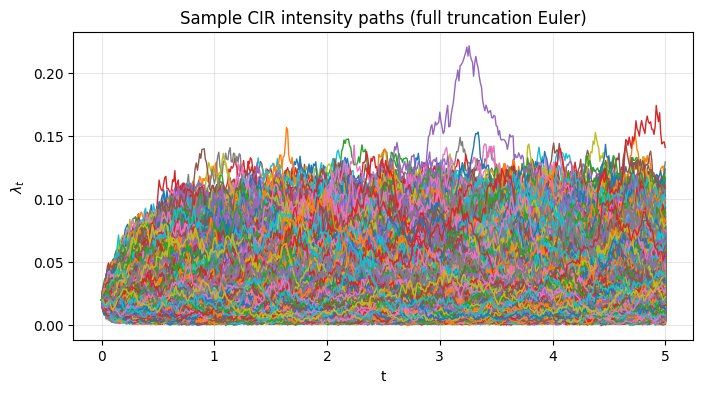

In [73]:
plt.figure(figsize=(8, 4))  # Create a new figure with specified width and height

for j in range(50000):      # Loop over all simulated paths (50000 paths)
    plt.plot(times, lam[j], lw=1)  # Plot the j-th intensity path over time with line width 1

plt.xlabel("t")             # Label x-axis as time
plt.ylabel(r"$\lambda_t$")  # Label y-axis using LaTeX for intensity λ_t
plt.title("Sample CIR intensity paths (full truncation Euler)")  # Set plot title
plt.grid(True, alpha=0.3)   # Enable grid with light transparency for readability
plt.show()                  # Display the plot

Simulated CIR intensity paths remain within a stable range, with most values concentrated between 0 and 0.1, 
and only a small number of paths reaching approximately 0.15. This behavior is consistent with mean reversion toward the long-run level 
$\theta=0.03$ and indicates no numerical instability or path explosion.

#### III. Time-step convergence

We next assess convergence with respect to the discretization step $\Delta t$ by comparing survival probabilities and fair CDS spreads across increasingly refined grids. Convergence is assessed by treating the finest time grid as a numerical reference. Absolute differences should decrease as $\Delta t \to 0$.

In [74]:
dt_grid = np.logspace(0.00, -2.75, 50)  # Create 50 time-step values logarithmically spaced from 10^0 to 10^-2.75
dt_grid                                  # Display the grid of tested time-step sizes

n_paths_dt = 50000                       # Number of Monte Carlo paths used in each time-step convergence experiment
eval_times = [1.0, 3.0, 5.0]             # Times at which survival probabilities will be recorded for comparison

rows = []                                # Initialize list to collect convergence results for each dt

for dt in dt_grid:                       # Loop over each candidate time-step size
    times_dt, lam_dt = simulate_cir_full_truncation(  # Simulate CIR intensity paths for the current dt
        kappa=kappa, theta=theta, sigma=sigma, lam0=lam0,  # Pass CIR model parameters
        T=T, dt=dt, n_paths=n_paths_dt, seed=seed          # Pass maturity, current time step, number of paths, and random seed
    )
    S_dt = survival_curve_from_paths(lam_dt, dt)                # Estimate survival curve from simulated intensity paths
    tau_dt = default_times_from_paths(lam_dt, dt, seed=seed + 1)  # Construct default times using independent exponential thresholds
    fair_spread_dt = cds_fair_spread_from_tau(tau_dt, r=r, R=R, T=T, dt=dt)  # Compute fair CDS spread for the current dt

    row = {"dt": dt, "fair_spread": fair_spread_dt}  # Initialize result row with current dt and corresponding fair spread
    for t_eval in eval_times:                        # Loop over selected evaluation times
        idx = int(round(t_eval / dt))                # Convert evaluation time to nearest grid index on the current time discretization
        row[f"S({t_eval:g})"] = S_dt[idx]            # Store estimated survival probability at that evaluation time
    rows.append(row)                                 # Append completed result row to the list

dt_conv_df = pd.DataFrame(rows).sort_values("dt", ascending=False)  # Convert collected results to DataFrame and sort from largest dt to smallest
dt_conv_df.tail(5)                                                    # Display the last 5 rows (smallest dt values after descending sort)

,dt,fair_spread,S(1),S(3),S(5)
45,0.002982,0.016851,0.975610,0.920340,0.867038
46,0.002620,0.016821,0.975552,0.920337,0.867063
47,0.002303,0.016809,0.975589,0.920325,0.867083
48,0.002024,0.016839,0.975570,0.920289,0.867058
49,0.001778,0.016862,0.975569,0.920309,0.867059


In [75]:
# define reference values
ref = dt_conv_df.iloc[-1]  # Take the finest-grid row (smallest dt after sorting) as the numerical reference

spread_ref = ref["fair_spread"]  # Reference fair CDS spread from the finest time grid
S1_ref = ref["S(1)"]             # Reference survival probability at t = 1 from the finest time grid
S3_ref = ref["S(3)"]             # Reference survival probability at t = 3 from the finest time grid
S5_ref = ref["S(5)"]             # Reference survival probability at t = 5 from the finest time grid

# compute errors
dt_conv_df["abs_error_spread"] = abs(dt_conv_df["fair_spread"] - spread_ref)  # Absolute error in fair spread relative to reference
dt_conv_df["abs_error_S5"] = abs(dt_conv_df["S(5)"] - S5_ref)                  # Absolute error in S(5) relative to reference

# compute threshold
tol = 1e-5  # Error tolerance used to identify acceptable time-step sizes

dt_threshold = dt_conv_df.loc[                         # Filter rows meeting the spread-error tolerance
    dt_conv_df["abs_error_spread"] < tol, "dt"        # Select dt values whose spread error is below tolerance
].max()                                               # Take the largest such dt (coarsest acceptable grid)

print("="*50)                                         # Print separator line
print("Time-Step Convergence Summary")                # Print section title
print("="*50)                                         # Print separator line

print(f"Reference (smallest dt = {dt_conv_df.iloc[-1]['dt']:.6f}):")  # Report reference time step
print(f"  Fair spread = {spread_ref:.6f}")                             # Report reference fair spread
print(f"  S(5)        = {S5_ref:.6f}")                                 # Report reference survival probability at t = 5
print()                                                                # Print blank line for readability

print("Coarsest grid error:")                                          # Label error report for coarsest grid
print(f"  |Δspread|   = {dt_conv_df.iloc[0]['abs_error_spread']:.6e}") # Report spread error at largest dt
print(f"  |ΔS(5)|     = {dt_conv_df.iloc[0]['abs_error_S5']:.6e}")     # Report S(5) error at largest dt
print()                                                                # Print blank line for readability

print("Finest grid error:")                                            # Label error report for near-finest grid
print(f"  |Δspread|   = {dt_conv_df.iloc[-2]['abs_error_spread']:.6e}")# Report spread error at second-smallest dt
print(f"  |ΔS(5)|     = {dt_conv_df.iloc[-2]['abs_error_S5']:.6e}")    # Report S(5) error at second-smallest dt
print("="*50)                                                          # Print closing separator line

Time-Step Convergence Summary
Reference (smallest dt = 0.001778):
  Fair spread = 0.016862
  S(5)        = 0.867059

Coarsest grid error:
  |Δspread|   = 7.766602e-05
  |ΔS(5)|     = 1.949637e-03

Finest grid error:
  |Δspread|   = 2.286139e-05
  |ΔS(5)|     = 7.046461e-07


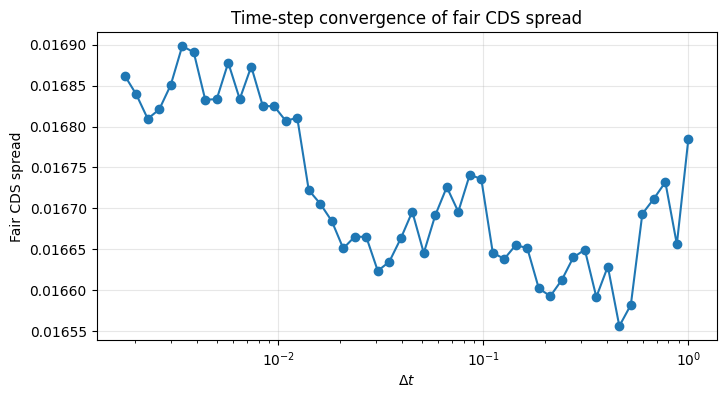

In [76]:
plt.figure(figsize=(8, 4))  # Create a new figure with specified size

plt.plot(dt_conv_df["dt"], dt_conv_df["fair_spread"], marker="o")  # Plot fair CDS spread as a function of dt with markers

plt.xlabel(r"$\Delta t$")        # Label x-axis with time-step size (LaTeX formatted)
plt.xscale("log")                # Use logarithmic scale for dt to visualize convergence behavior
plt.ylabel("Fair CDS spread")    # Label y-axis
plt.title("Time-step convergence of fair CDS spread")  # Set plot title

plt.grid(True, alpha=0.3)        # Enable grid with light transparency for readability
plt.show()                       # Display the plot

Estimated quantities remain stable across time steps, with fair CDS spreads varying on the order of $10^{−4}$ and survival probabilities stable to three to four decimal places. Convergence is observed as $\Delta t \to 0$, with no systematic drift beyond $\Delta t \approx 10^{−2}$. Residual fluctuations at finer discretizations are consistent with Monte Carlo noise, indicating that discretization error is negligible relative to sampling error.

In [77]:
# Use finest grid as reference
ref_row = dt_conv_df.loc[dt_conv_df["dt"] == min(dt_grid)].iloc[0]  # Select row corresponding to smallest dt (finest grid)

error_rows = []  # Initialize list to store error metrics for each dt

for _, row in dt_conv_df.iterrows():  # Iterate over each row (each dt configuration)
    error_rows.append({  # Append dictionary of errors relative to reference
        "dt": row["dt"],  # Current time-step size
        "abs_error_spread": abs(row["fair_spread"] - ref_row["fair_spread"]),  # Absolute error in fair spread
        "abs_error_S(1)": abs(row["S(1)"] - ref_row["S(1)"]),  # Absolute error in survival probability at t = 1
        "abs_error_S(3)": abs(row["S(3)"] - ref_row["S(3)"]),  # Absolute error in survival probability at t = 3
        "abs_error_S(5)": abs(row["S(5)"] - ref_row["S(5)"]),  # Absolute error in survival probability at t = 5
    })

dt_error_df = pd.DataFrame(error_rows).sort_values("dt", ascending=False)  # Convert to DataFrame and sort from largest dt to smallest
dt_error_df.tail(5)  # Display last 5 rows (smallest dt values after descending sort)

,dt,abs_error_spread,abs_error_S(1),abs_error_S(3),abs_error_S(5)
45,0.002982,0.000012,0.000042,0.000030,2.096190e-05
46,0.002620,0.000041,0.000017,0.000027,3.705611e-06
47,0.002303,0.000053,0.000021,0.000015,2.385936e-05
48,0.002024,0.000023,0.000002,0.000020,7.046461e-07
49,0.001778,0.000000,0.000000,0.000000,0.000000e+00


In [78]:
print("="*50)  # Print separator line for readability
print("Time-Step Error Summary")  # Print section title
print("="*50)  # Print separator line

coarse = dt_error_df.iloc[0]    # Select row corresponding to largest dt (coarsest grid)
mid = dt_error_df.iloc[34]      # Select a mid-range dt (approximately dt ≈ 0.01 based on grid indexing)
fine = dt_error_df.iloc[-2]     # Select second-smallest dt (finest non-reference grid)

print("Coarsest grid (dt ≈ 1):")  # Label for coarsest grid results
print(f"  |Δspread| = {coarse['abs_error_spread']:.2e}")  # Print absolute error in fair spread for coarsest grid
print(f"  |ΔS(5)|   = {coarse['abs_error_S(5)']:.2e}")    # Print absolute error in survival probability at t = 5
print()  # Blank line for readability

print("Practical grid (dt ≈ 0.01):")  # Label for mid-level (practically relevant) grid
print(f"  |Δspread| = {mid['abs_error_spread']:.2e}")     # Print absolute error in fair spread for mid grid
print(f"  |ΔS(5)|   = {mid['abs_error_S(5)']:.2e}")       # Print absolute error in survival probability at t = 5
print()  # Blank line for readability

print("Finest non-reference grid:")  # Label for finest grid excluding reference
print(f"  |Δspread| = {fine['abs_error_spread']:.2e}")    # Print absolute error in fair spread for near-finest grid
print(f"  |ΔS(5)|   = {fine['abs_error_S(5)']:.2e}")      # Print absolute error in survival probability at t = 5
print("="*50)  # Print closing separator line

Time-Step Error Summary
Coarsest grid (dt ≈ 1):
  |Δspread| = 7.77e-05
  |ΔS(5)|   = 1.95e-03

Practical grid (dt ≈ 0.01):
  |Δspread| = 5.16e-05
  |ΔS(5)|   = 1.62e-05

Finest non-reference grid:
  |Δspread| = 2.29e-05
  |ΔS(5)|   = 7.05e-07


Absolute errors decrease as the time step is refined, with spread errors on the order of $10^{−4}$ and survival probability errors of similar magnitude. No monotonic decay is observed at finer discretizations, as Monte Carlo noise dominates once discretization error becomes sufficiently small. Convergence is effectively achieved for $10^{−2}$, beyond which further refinement yields negligible improvement.

#### IV. Monte Carlo convergence

We now test convergence with respect to the number of Monte Carlo paths $N$ while holding the time step fixed. As $N$ increases, Monte Carlo estimates should stabilize, with standard error decreasing at the expected rate $\mathcal{O}\left(\frac1{\sqrt N}\right)$.

In [79]:
N_grid = np.unique(np.round(np.logspace(1, 5, 50)).astype(int))  # Create a log-spaced grid of path counts from 10^1 to 10^5, round to integers, and remove duplicates
dt_mc = 0.01                                                      # Fix time step for Monte Carlo convergence study
eval_time = 5.0                                                   # Time at which survival probability and its standard error will be evaluated

rows = []                                                         # Initialize list to collect results for each Monte Carlo sample size N

for N in N_grid:                                                  # Loop over each candidate number of Monte Carlo paths
    times_mc, lam_mc = simulate_cir_full_truncation(              # Simulate CIR intensity paths for the current sample size N
        kappa=kappa, theta=theta, sigma=sigma, lam0=lam0,         # Pass CIR model parameters
        T=T, dt=dt_mc, n_paths=N, seed=seed                       # Pass maturity, fixed time step, number of paths, and random seed
    )
    S_mc = survival_curve_from_paths(lam_mc, dt_mc)               # Estimate survival curve from simulated paths
    tau_mc = default_times_from_paths(lam_mc, dt_mc, seed=seed + 1)  # Construct default times using independent exponential thresholds
    fair_spread_mc = cds_fair_spread_from_tau(tau_mc, r=r, R=R, T=T, dt=dt_mc)  # Compute fair CDS spread for the current N

    idx = int(round(eval_time / dt_mc))                           # Convert evaluation time to the corresponding grid index
    surv_vals = np.exp(-integrated_intensity(lam_mc, dt_mc)[:, idx])  # Compute pathwise survival values exp(-∫_0^t λ_s ds) at eval_time

    rows.append({                                                 # Append results for the current N
        "N": N,                                                   # Store current number of Monte Carlo paths
        f"S({eval_time:g})": S_mc[idx],                           # Store estimated survival probability at eval_time
        "std_error_S": surv_vals.std(ddof=1) / np.sqrt(N),        # Estimate Monte Carlo standard error of survival probability
        "fair_spread": fair_spread_mc,                            # Store fair CDS spread estimate
    })

mc_conv_df = pd.DataFrame(rows)                                   # Convert collected Monte Carlo convergence results to a DataFrame
mc_conv_df.tail(5)                                                # Display the last 5 rows (largest N values)

,N,S(5),std_error_S,fair_spread
45,47149,0.867097,0.000132,0.016713
46,56899,0.867047,0.000121,0.016924
47,68665,0.867052,0.000110,0.017083
48,82864,0.867047,0.000101,0.016998
49,100000,0.867054,0.000091,0.016995


In [80]:
# Final reference values (largest N)
S_final = mc_conv_df.iloc[-1]["S(5)"]              # Take survival probability at t = 5 from the largest-N run as reference
spread_final = mc_conv_df.iloc[-1]["fair_spread"]  # Take fair spread from the largest-N run as reference

# Absolute errors
mc_conv_df["abs_error_S"] = abs(mc_conv_df["S(5)"] - S_final)                  # Compute absolute error in S(5) relative to the largest-N reference
mc_conv_df["abs_error_spread"] = abs(mc_conv_df["fair_spread"] - spread_final) # Compute absolute error in fair spread relative to the largest-N reference

# Empirical convergence rate
logN = np.log(mc_conv_df["N"])                    # Take logarithm of Monte Carlo sample sizes N
logSE = np.log(mc_conv_df["std_error_S"])         # Take logarithm of estimated standard errors for S(5)
slope = np.polyfit(logN, logSE, 1)[0]             # Fit a line to (log N, log SE) and extract the slope

# Print summary
print("="*50)                                     # Print separator line
print("Monte Carlo Convergence Summary")          # Print section title
print("="*50)                                     # Print separator line

print(f"Final reference (N = {int(mc_conv_df.iloc[-1]['N'])}):")  # Report largest N used as numerical reference
print(f"  S(5)           = {S_final:.6f}")                         # Print reference survival probability at t = 5
print(f"  Fair spread    = {spread_final:.6f}")                   # Print reference fair CDS spread
print()                                                           # Print blank line for readability

print("Error at smallest N:")                                     # Label errors for the smallest sample size
print(f"  |ΔS(5)|        = {mc_conv_df.iloc[0]['abs_error_S']:.6e}")        # Print absolute error in S(5) at smallest N
print(f"  |Δspread|      = {mc_conv_df.iloc[0]['abs_error_spread']:.6e}")   # Print absolute error in fair spread at smallest N
print()                                                           # Print blank line for readability

print("Error at largest N:")                                      # Label errors for the finest non-reference sample size
print(f"  |ΔS(5)|        = {mc_conv_df.iloc[-2]['abs_error_S']:.6e}")       # Print absolute error in S(5) at second-largest N
print(f"  |Δspread|      = {mc_conv_df.iloc[-2]['abs_error_spread']:.6e}")  # Print absolute error in fair spread at second-largest N
print()                                                           # Print blank line for readability

print("Standard error scaling:")                                  # Label convergence-rate diagnostic
print(f"  Empirical slope (log-log) ≈ {slope:.3f}")               # Print fitted log-log slope of standard error versus N
print("  Expected slope            = -0.5")                       # Print theoretical Monte Carlo convergence slope
print("="*50)                                                     # Print closing separator line

Monte Carlo Convergence Summary
Final reference (N = 100000):
  S(5)           = 0.867054
  Fair spread    = 0.016995

Error at smallest N:
  |ΔS(5)|        = 2.044291e-03
  |Δspread|      = 2.962658e-02

Error at largest N:
  |ΔS(5)|        = 7.690513e-06
  |Δspread|      = 3.175905e-06

Standard error scaling:
  Empirical slope (log-log) ≈ -0.502
  Expected slope            = -0.5


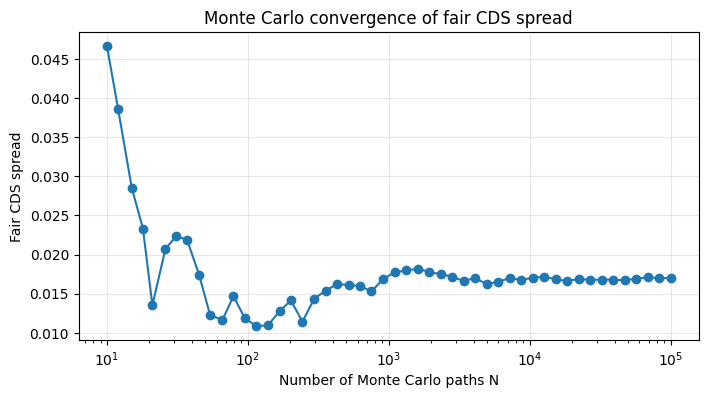

In [81]:
plt.figure(figsize=(8, 4))  # Create a new figure with specified size

plt.plot(mc_conv_df["N"], mc_conv_df["fair_spread"], marker="o")  # Plot fair CDS spread as a function of number of paths N

plt.xscale("log")  # Use logarithmic scale for N to visualize convergence behavior
plt.xlabel("Number of Monte Carlo paths N")  # Label x-axis
plt.ylabel("Fair CDS spread")  # Label y-axis
plt.title("Monte Carlo convergence of fair CDS spread")  # Set plot title

plt.grid(True, alpha=0.3)  # Enable grid with light transparency for readability
plt.show()  # Display the plot

Monte Carlo estimates exhibit significant variability at low sample sizes, with fair spreads and survival probabilities fluctuating substantially for $N<10^{2}$. As the number of simulation paths increases, estimates stabilize, with survival probabilities converging toward $S(5)\approx 0.867$ and spreads toward $0.017$. Practical convergence is observed for $N> 10^{4}$, beyond which fluctuations are small and consistent with sampling noise. The standard error decreases in line with the theoretical rate, confirming statistical consistency of the Monte Carlo implementation.

#### V. Default-time discretization error

Default times are generated by identifying the first time at which the cumulative intensity exceeds an exponential threshold. Since the crossing is observed only on the simulation grid, the default time is subject to discretization error. Grid refinement should reduce discretization bias in default timing and stabilize derived quantities such as default probability and fair CDS spread.

In [8]:
dt_grid_default = np.logspace(0.00, -2.75, 50)  # Create log-spaced grid of time steps for default-time discretization study
n_paths_default = 50000                         # Number of Monte Carlo paths used for each dt

rows = []                                       # Initialize list to store results for each dt

for dt in dt_grid_default:                      # Loop over each time-step size
    times_d, lam_d = simulate_cir_full_truncation(  # Simulate CIR intensity paths for current dt
        kappa=kappa, theta=theta, sigma=sigma, lam0=lam0,  # Pass CIR model parameters
        T=T, dt=dt, n_paths=n_paths_default, seed=seed      # Pass maturity, dt, number of paths, and seed
    )
    tau_d = default_times_from_paths(lam_d, dt, seed=seed + 999)  # Compute default times using Cox construction with independent seed

    rows.append({  # Append summary statistics for current dt
        "dt": dt,  # Current time-step size
        "default_prob": np.mean(tau_d <= T),  # Estimate default probability P(τ ≤ T)
        "mean_tau_given_default": np.mean(tau_d[np.isfinite(tau_d)]) if np.isfinite(tau_d).any() else np.nan,  # Mean default time conditional on default occurring
        "fair_spread": cds_fair_spread_from_tau(tau_d, r=r, R=R, T=T, dt=dt),  # Compute fair CDS spread for current dt
    })

default_disc_df = pd.DataFrame(rows).sort_values("dt", ascending=False)  # Convert results to DataFrame and sort by dt (largest to smallest)
default_disc_df.tail(5)  # Display last 5 rows (smallest dt values after descending sort)

,dt,default_prob,mean_tau_given_default,fair_spread
45,0.002982,0.13186,2.540171,0.016879
46,0.002620,0.13240,2.546100,0.016939
47,0.002303,0.13252,2.545580,0.016957
48,0.002024,0.13192,2.533154,0.016892
49,0.001778,0.13236,2.539605,0.016942


In [9]:
# Final reference values (smallest dt)
prob_final = default_disc_df.iloc[-1]["default_prob"]            # Take default probability from the smallest-dt run as numerical reference
tau_final = default_disc_df.iloc[-1]["mean_tau_given_default"]   # Take mean default time (conditional on default) from the smallest-dt run as reference
spread_final = default_disc_df.iloc[-1]["fair_spread"]           # Take fair CDS spread from the smallest-dt run as reference

# Absolute errors
default_disc_df["abs_error_prob"] = np.abs(default_disc_df["default_prob"] - prob_final)              # Compute absolute error in default probability relative to reference
default_disc_df["abs_error_tau"] = np.abs(default_disc_df["mean_tau_given_default"] - tau_final)      # Compute absolute error in mean default time relative to reference
default_disc_df["abs_error_spread"] = np.abs(default_disc_df["fair_spread"] - spread_final)           # Compute absolute error in fair spread relative to reference

# Empirical convergence rate
mask = (default_disc_df["abs_error_spread"] > 0) & (default_disc_df["dt"] >= 1e-2)  # Restrict to rows with positive spread error and moderately coarse dt values
logdt = np.log(default_disc_df.loc[mask, "dt"])                                      # Take logarithm of selected dt values
logerr = np.log(default_disc_df.loc[mask, "abs_error_spread"])                       # Take logarithm of corresponding spread errors
slope = np.polyfit(logdt, logerr, 1)[0]                                              # Fit a line to (log dt, log error) and extract slope

print("="*50)                                            # Print separator line
print("Time Discretization Convergence Summary")         # Print section title
print("="*50)                                            # Print separator line

print(f"Final reference (dt = {default_disc_df.iloc[-1]['dt']:.6f}):")  # Report smallest dt used as reference
print(f"  Default prob    = {prob_final:.6f}")                           # Print reference default probability
print(f"  Mean tau        = {tau_final:.6f}")                            # Print reference conditional mean default time
print(f"  Fair spread     = {spread_final:.6f}")                         # Print reference fair CDS spread
print()                                                                  # Print blank line for readability

print("Error at largest dt:")                                            # Label errors for coarsest time grid
print(f"  |Δ default prob| = {default_disc_df.iloc[0]['abs_error_prob']:.6e}")    # Print default probability error at largest dt
print(f"  |Δ mean tau|     = {default_disc_df.iloc[0]['abs_error_tau']:.6e}")      # Print mean default time error at largest dt
print(f"  |Δ spread|       = {default_disc_df.iloc[0]['abs_error_spread']:.6e}")   # Print fair spread error at largest dt
print()                                                                  # Print blank line for readability

print("Error at smallest non-reference dt:")                             # Label errors for second-smallest dt
print(f"  |Δ default prob| = {default_disc_df.iloc[-2]['abs_error_prob']:.6e}")    # Print default probability error at near-finest dt
print(f"  |Δ mean tau|     = {default_disc_df.iloc[-2]['abs_error_tau']:.6e}")      # Print mean default time error at near-finest dt
print(f"  |Δ spread|       = {default_disc_df.iloc[-2]['abs_error_spread']:.6e}")   # Print fair spread error at near-finest dt

print("="*50)                                            # Print closing separator line

Time Discretization Convergence Summary
Final reference (dt = 0.001778):
  Default prob    = 0.132360
  Mean tau        = 2.539605
  Fair spread     = 0.016942

Error at largest dt:
  |Δ default prob| = 1.740000e-03
  |Δ mean tau|     = 5.037952e-01
  |Δ spread|       = 3.205777e-05

Error at smallest non-reference dt:
  |Δ default prob| = 4.400000e-04
  |Δ mean tau|     = 6.451664e-03
  |Δ spread|       = 5.033081e-05


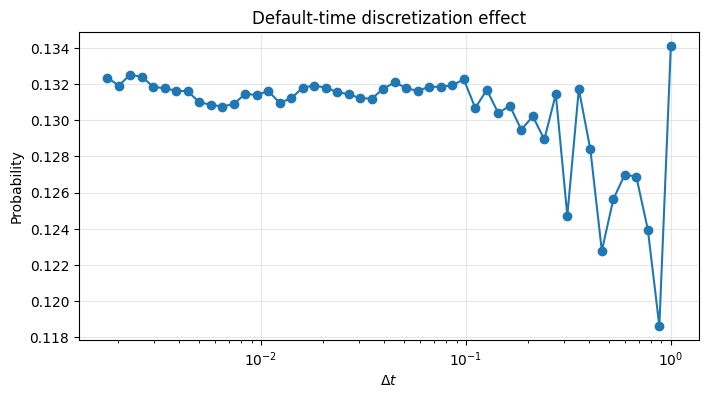

In [10]:
plt.figure(figsize=(8, 4))  # Create a new figure with specified size

plt.plot(default_disc_df["dt"], default_disc_df["default_prob"], marker="o", label="Default probability")  # Plot default probability vs dt

plt.xscale("log")             # Use logarithmic scale for dt to visualize discretization effects
plt.xlabel(r"$\Delta t$")     # Label x-axis with time-step size (LaTeX formatted)
plt.ylabel("Probability")     # Label y-axis
plt.title("Default-time discretization effect")  # Set plot title

plt.grid(True, alpha=0.3)     # Enable grid with light transparency for readability
plt.show()                    # Display the plot

The fair spread is highly stable across the tested time-step grid, with absolute variation on the order of $10^{-5}$. Default probability also remains stable, while the conditional mean default time shows more noticeable sensitivity for $\Delta t > 10^{-1}$.

#### VI. Conclusion

The full-truncation Euler scheme produces stable mean-reverting intensity paths while enforcing non-negativity in the drift, diffusion, and integration steps, though small negative excursions may occur in the stored discrete-time values. Monte Carlo estimates exhibit the expected convergence behavior as the number of simulated paths increases, confirming the consistency of the implementation.

Time-discretization analysis shows that default-time bias decreases under grid refinement, with default probability and fair CDS spread remaining stable across the tested range of time steps. While the conditional mean default time exhibits greater sensitivity at coarse discretizations, it stabilizes as the grid is refined. Overall, the results demonstrate that model outputs are numerically robust with respect to both simulation granularity and sampling variability, supporting the reliability of the numerical framework.

### 1.c. Independent replication 
<a id="d1c"></a>
*(Are results reproducible under independent implementation or known benchmarks?)*

Independent replication was performed to verify that model outputs are reproducible and not dependent on a specific implementation of default timing. In addition to the default-time (first-passage) approach, default probabilities were recomputed using the survival representation
$$ \mathbb{Q}(\tau > T) = \mathbb{E}^{\mathbb{Q}} \left[ \exp \left(-\int_0^T \lambda_s \ ds \right)\right]. \tag{1.20}$$ which follows directly from the reduced-form intensity framework introduced [above](#d1a).
The resulting estimates were consistent within Monte Carlo error, confirming that key outputs are robust to the method used to compute default events.

In [11]:
# Default probability via first-passage times
default_prob_tau = np.mean(tau_d <= T)  # Estimate default probability using simulated default times τ_d

# Default probability via survival formulation 
# integral ≈ sum lambda_t * dt (using same truncation as in integrated_intensity)
intensity_integral = np.sum(np.maximum(lam_d[:, :-1], 0.0) * dt, axis=1)  # Approximate ∫_0^T λ_s ds with truncation
survival_prob = np.mean(np.exp(-intensity_integral))  # Estimate survival probability E[exp(-∫_0^T λ_s ds)]
default_prob_survival = 1 - survival_prob             # Convert survival probability to default probability

# Comparison 
abs_diff = abs(default_prob_tau - default_prob_survival)  # Compute absolute difference between the two estimates

print("="*50)                                             # Print separator line
print("Independent Replication Check")                    # Print section title
print("="*50)                                             # Print separator line
print(f"Default prob (tau-based)      = {default_prob_tau:.6f}")       # Print tau-based default probability
print(f"Default prob (survival-based) = {default_prob_survival:.6f}")  # Print survival-based default probability
print(f"Absolute difference          = {abs_diff:.6e}")                # Print absolute difference
print(f"Relative difference          = {abs_diff/default_prob_tau:.3%}")  # Print relative difference
print("="*50)                                             # Print closing separator line

Independent Replication Check
Default prob (tau-based)      = 0.132360
Default prob (survival-based) = 0.132941
Absolute difference          = 5.809045e-04
Relative difference          = 0.439%


### 1.d. Payoff and boundary condition validation 
<a id="d1d"></a>
*(Do outputs match expected payoffs and limiting cases?)*

The CDS pricing implementation was validated by testing boundary conditions and verifying expected economic behavior.

In the zero-intensity limit, no default events occur and the fair spread converges to zero, consistent with the absence of credit risk. Under high-intensity scenarios, default occurs with high probability and the fair spread increases accordingly.

Recovery rate sensitivity was also verified: as the recovery rate approaches one, the loss given default vanishes and the fair spread converges to zero, while lower recovery rates produce higher spreads.

These tests confirm that the payoff structure and valuation logic behave consistently with theoretical expectations across limiting cases.

In [12]:
# Zero intensity test

lam_zero = np.zeros_like(lam_d)  # Create intensity paths identically equal to zero (no default intensity)
tau_zero = np.full(n_paths_default, np.inf)  # Set default times to infinity for all paths (no defaults occur)

spread_zero = cds_fair_spread_from_tau(tau_zero, r=r, R=R, T=T, dt=dt)  # Compute fair spread under zero-default scenario

print("Zero intensity test:")  # Print test label
print(f"  Default prob = {np.mean(tau_zero <= T):.6f}")  # Should be zero since no path defaults before T
print(f"  Fair spread  = {spread_zero:.6e}")            # Should be approximately zero (no credit risk)

Zero intensity test:
  Default prob = 0.000000
  Fair spread  = 0.000000e+00


In [13]:
# High constant intensity

lam_high = np.full_like(lam_d, 5.0)  # Create intensity paths with a constant high value (λ_t = 5 for all t and all paths)
tau_high = default_times_from_paths(lam_high, dt)  # Generate default times using Cox construction under high intensity

spread_high = cds_fair_spread_from_tau(tau_high, r=r, R=R, T=T, dt=dt)  # Compute fair CDS spread under high default intensity

print("High intensity test:")  # Print test label
print(f"  Default prob = {np.mean(tau_high <= T):.6f}")  # Estimate probability of default before maturity (should be close to 1)
print(f"  Fair spread  = {spread_high:.6f}")            # Report fair spread (should be significantly larger than baseline)

High intensity test:
  Default prob = 1.000000
  Fair spread  = 2.986396


In [14]:
for R_test in [0.0, 0.4, 0.8, 1.0]:  # Loop over different recovery rate scenarios
    spread_R = cds_fair_spread_from_tau(tau_d, r=r, R=R_test, T=T, dt=dt)  # Compute fair CDS spread for given recovery rate
    print(f"R = {R_test:.1f} → spread = {spread_R:.6f}")  # Print recovery rate and corresponding spread

R = 0.0 → spread = 0.028237
R = 0.4 → spread = 0.016942
R = 0.8 → spread = 0.005647
R = 1.0 → spread = 0.000000


## 2. Conceptual Soundness*
<a id="d2"></a>
*(Is this the right model?)*

Having verified the mathematical formulation, numerical behavior, implementation consistency, and payoff logic, the next step is to assess the conceptual soundness of the modeling framework itself.

*While [SR 11-7](https://www.federalreserve.gov/boarddocs/srletters/2011/sr1107a1.pdf) treats conceptual soundness broadly - encompassing both model design and implementation - the present framework separates verification of implementation from evaluation of model assumptions and structure for analytical transparency.

### 2.a. Model assumptions 
<a id="d2a"></a>
*(Are assumptions realistic and appropriate?)*

The model is based on a reduced-form intensity framework in which default is represented as a random arrival event driven by a stochastic hazard-rate process. The default intensity $\lambda_t$ follows a CIR diffusion, imposing non-negativity and mean reversion while excluding jumps and discontinuous changes in credit risk. Default is generated by comparing the integrated intensity against an independent exponential threshold, so the timing of default is conditionally random given the intensity path.

The valuation setup assumes deterministic market inputs for discounting and recovery. The risk-free rate $r$ is held constant, and the recovery rate $R$ is fixed across scenarios and through time. As a result, spread variation is attributed entirely to changes in the default intensity process.

The model further assumes that a one-factor intensity specification is adequate for representing the relevant credit-risk dynamics of the name being modeled. This excludes mechanisms such as contagion, wrong-way risk, regime dependence, and structural balance-sheet effects. These simplifying assumptions support tractability and transparent interpretation, but they limit the model’s ability to capture more complex credit behavior.

### 2.b. Financial rationale 
<a id="d2b"></a>
*(Does the model capture the economics of credit risk?)*

CDS pricing is fundamentally driven by the timing and likelihood of default, which is naturally captured by a hazard-rate framework. In a reduced-form setting, the default intensity $\lambda_t$ represents the instantaneous conditional probability of default, enabling direct computation of survival probabilities and expected losses under the risk-neutral measure. This aligns closely with how CDS spreads are interpreted in practice.

The CIR specification introduces stochastic variation in credit risk while enforcing non-negativity and mean reversion, reflecting the empirical behavior of credit spreads, which tend to fluctuate over time but revert toward long-run levels. Unlike structural models, which rely on firm-value dynamics, the intensity-based approach avoids dependence on unobservable balance-sheet variables and allows calibration directly to market-implied quantities.

This combination of economic interpretability and computational tractability makes the stochastic-intensity framework well suited for CDS valuation and model validation purposes.

### 2.c. Applicability 
<a id="d2c"></a>
*(Is the model suitable for its intended use?)*

The model is applicable to single-name CDS valuation in environments where default risk can be adequately described by a continuous stochastic intensity. It is particularly appropriate for instruments and horizons over which credit spreads evolve smoothly and exhibit mean-reverting behavior.

The framework is suitable for pricing, sensitivity analysis, and risk assessment under standard market conditions, and can be used to evaluate the impact of changes in credit parameters on CDS spreads. Its tractability also makes it useful for validation exercises and benchmarking within reduced-form credit models.

The applicability of the model is limited in scenarios involving abrupt credit deterioration, jump-to-default events, or regime shifts, where diffusion-based intensity dynamics may understate tail risk. It is also not designed to capture multi-name dependence, contagion effects, or wrong-way risk, which require more advanced modeling structures.

### 2.d. Structural limitations 
<a id="d2d"></a>
*(What are the model’s inherent limitations?)*

The model exhibits several structural limitations arising from its reduced-form and diffusion-based specification. The CIR intensity process evolves continuously and does not incorporate jump components, which limits its ability to capture sudden credit deterioration or jump-to-default behavior observed in stressed markets. As a result, tail risk may be understated in scenarios involving abrupt credit events.

The assumption of a single-factor intensity process restricts the model’s ability to capture complex credit dynamics, including regime shifts, multi-scale behavior, or interactions between different sources of risk. In particular, the model does not account for contagion effects or dependence across obligors, making it unsuitable for portfolio credit applications without further extension.

Recovery and interest rates are treated as deterministic and independent of the default process, which excludes potential dependencies such as wrong-way risk or state-dependent recovery. This may lead to misestimation of expected losses under certain market conditions.

Finally, the reduced-form framework abstracts away from the firm’s balance sheet and capital structure, which limits interpretability in terms of fundamental credit drivers. While this enhances tractability, it reduces the model’s ability to explain default events from an economic perspective.

## 3. Calibration* 
<a id="d3"></a>
*(Are the parameters trustworthy?)*

*This section is computationally intensive in terms of time.

### 3.a. Methodology 
<a id="d3a"></a>
*(Is calibration well-posed and theoretically sound?)*

Model parameters were calibrated to a synthetic CDS term structure generated from a reference CIR parameter set. This controlled setup enables direct evaluation of parameter recovery and calibration accuracy without introducing external data-quality issues.

For each candidate parameter vector, model-implied CDS spreads were computed via Monte Carlo simulation of the CIR intensity process, followed by construction of default times and valuation of fair spreads across maturities. Calibration was performed by minimizing the sum of squared relative spread errors across the maturity grid. To improve parameter identifiability, the mean-reversion parameter $\kappa$ was fixed and only $(\theta,\sigma,\lambda_0)$ were estimated. Parameter bounds were imposed to ensure admissibility and numerical stability. The constrained optimization problem was solved numerically using the L-BFGS-B algorithm.

We define the model-implied CDS spread $s_i^{model}$ at maturity $T_i$ according to $(1.15)$, using simulated default times generated from the CIR intensity process:
$$  s_i^{model}(\theta,\sigma,\lambda_0) = \frac{ \text{Prot}(T_i) }{ \text{Annuity}(T_i) }  \tag{3.1}$$
The synthetic CDS spread at maturity $T_i$, generated from the reference CIR parameter set and treated as observed market data for calibration, is denoted $ s_i^{target}$.
Hence, we solve the optimization problem
$$ \min_{\theta,\sigma,\lambda_0} {J}(\theta,\sigma,\lambda_0), \tag{3.2}$$ 
where the objective function is defined as
$$ {J}(\theta,\sigma,\lambda_0) = \sum^m_{i=1} \left( \frac{s_i^{model}(\theta,\sigma,\lambda_0) - s_i^{target}}{s_i^{target}} \right)^2  .\tag{3.3}$$
The parameters are constrained to lie in admissible domains consistent with the CIR intensity model,
$$\theta>0~~,~~\sigma>0~~,~~ \lambda_0\geq 0 ,$$ 
with bounded intervals imposed in the optimization to ensure numerical stability and regularization. While the Feller condition $(1.3)$ ensures strict positivity of the intensity, it is not enforced explicitly due to the use of a full-truncation discretization scheme.

The calibration recovered the reference parameter values to within numerical and Monte Carlo error for the fixed-$\kappa$ specification:
$$ \theta = 0.03~~,~~\sigma=0.25~~,~~\lambda_0=0.02. $$
Model-implied spreads closely matched the synthetic targets across all maturities, with small residual errors attributable to Monte Carlo sampling variability. Because the calibration targets were generated from the same model specification, exact recovery would be expected in the absence of numerical and Monte Carlo error and serves as a consistency check of the calibration procedure rather than a test of model realism.

In [56]:
# Define maturities
T_grid = np.linspace(1, 10, 10)  # Create a grid of 10 maturities evenly spaced from 1 to 10 years

# Choose "true" parameters
true_params = {
    "kappa": 1.2,   # Mean-reversion speed used to generate synthetic data
    "theta": 0.03,  # Long-run mean intensity used as ground truth
    "sigma": 0.25,  # Volatility parameter of the CIR process (true value)
    "lam0": 0.02    # Initial intensity λ_0 used to generate synthetic spreads
}

In [57]:
# Generate synthetic CDS spreads

r = 0.03                # Constant risk-free rate used for discounting in CDS pricing
R = 0.4                 # Recovery rate used in CDS payoff
dt_cal = 0.01           # Time step used for simulation during calibration data generation
n_paths_cal = 50000     # Number of Monte Carlo paths used to generate synthetic spreads
seed_cal = 42           # Random seed for reproducibility of synthetic data

def generate_synthetic_spreads(params):
    spreads = []  # Initialize list to store CDS spreads for each maturity
    
    for T in T_grid:  # Loop over each maturity in the grid
        times, lam = simulate_cir_full_truncation(  # Simulate CIR intensity paths under given parameters
            kappa=params["kappa"],   # Mean-reversion speed
            theta=params["theta"],   # Long-run mean intensity
            sigma=params["sigma"],   # Volatility parameter
            lam0=params["lam0"],     # Initial intensity
            T=T,                     # Current maturity
            dt=dt_cal,               # Time step for simulation
            n_paths=n_paths_cal,     # Number of Monte Carlo paths
            seed=seed_cal            # Seed for reproducibility (same seed reused for each maturity)
        )
        
        tau = default_times_from_paths(lam, dt_cal, seed=seed_cal + 999)  # Generate default times using Cox construction with independent seed
        s = cds_fair_spread_from_tau(tau, r=r, R=R, T=T, dt=dt_cal)       # Compute fair CDS spread for current maturity
        spreads.append(s)  # Store computed spread
    
    return np.array(spreads)  # Return spreads as NumPy array

spread_targets = generate_synthetic_spreads(true_params)  # Generate synthetic CDS term structure from true parameters

In [58]:
# Add noise

np.random.seed(123)  # Set global random seed for reproducibility of added noise
spread_targets_noisy = spread_targets + np.random.normal(0, 1e-4, size=len(spread_targets))  # Add Gaussian noise (mean 0, std 1e-4) to synthetic spreads
spread_targets_used = spread_targets_noisy  # Use noisy spreads as calibration targets

In [59]:
# Define calibration function

from scipy.optimize import minimize  # Import numerical optimization routine for parameter calibration

def model_spreads_from_params(params):
    theta, sigma, lam0 = params  # Unpack candidate parameters to be calibrated
    kappa = kappa_fixed          # Use fixed mean-reversion parameter κ for identifiability
    
    if min([theta, sigma, lam0]) <= 0:          # Reject nonpositive parameter values
        return np.full(len(T_grid), np.inf)     # Return infinities so optimizer penalizes inadmissible inputs
    
    spreads = []  # Initialize list to store model-implied CDS spreads across maturities
    
    for T in T_grid:  # Loop over each maturity in the calibration grid
        times, lam = simulate_cir_full_truncation(  # Simulate CIR intensity paths under current candidate parameters
            kappa=kappa, theta=theta, sigma=sigma, lam0=lam0,  # Pass current parameter values
            T=T, dt=dt_cal, n_paths=30000, seed=123            # Use fixed simulation settings for calibration
        )
        tau = default_times_from_paths(lam, dt_cal, seed=456)   # Generate default times from simulated intensity paths
        s = cds_fair_spread_from_tau(tau, r=r, R=R, T=T, dt=dt_cal)  # Compute model-implied fair CDS spread at maturity T
        spreads.append(s)  # Store spread for current maturity
    
    return np.array(spreads)  # Return model-implied spread curve as NumPy array

In [60]:
# Define objective function
def objective(params):
    model_spreads = model_spreads_from_params(params)  # Compute model-implied CDS spreads for given parameters
    
    if not np.all(np.isfinite(model_spreads)):  # Check for invalid outputs (e.g., from inadmissible parameters)
        return 1e10                             # Return large penalty value to discourage optimizer from this region
    
    errors = (model_spreads - spread_targets_used) / spread_targets_used  # Compute relative errors vs target spreads
    return np.sum(errors**2)  # Return sum of squared relative errors (objective to minimize)

In [20]:
# Run calibration

kappa_fixed = 1.2  # Fix κ (mean-reversion speed) to reduce parameter identifiability issues

x0 = np.array([0.03, 0.25, 0.02])   # Initial guess for parameters [theta, sigma, lam0]

bounds = [
    (1e-4, 0.2),   # Lower/upper bounds for theta (ensure positivity and reasonable range)
    (1e-4, 1.0),   # Bounds for sigma (volatility parameter)
    (1e-4, 0.2)    # Bounds for lam0 (initial intensity)
]

result = minimize(objective, x0, bounds=bounds, method="L-BFGS-B")  # Run constrained optimization using L-BFGS-B algorithm

params_cal = result.x            # Extract calibrated parameter vector from optimization result
theta_cal, sigma_cal, lam0_cal = params_cal  # Unpack calibrated parameters

In [21]:
# Evaluate calibration fit

spreads_calibrated = model_spreads_from_params(params_cal)  # Compute model-implied CDS spreads using calibrated parameters for comparison with targets

In [22]:
# Objective value at calibrated parameters
J_value = objective(params_cal)  # Evaluate objective function at calibrated parameters

# Error diagnostics
abs_error = np.abs(spreads_calibrated - spread_targets_used)  # Absolute error between model and target spreads
rel_error = abs_error / spread_targets_used                   # Relative error (normalized by target spreads)
abs_rel_error = np.abs(rel_error)                             # Absolute value of relative error

rmse = np.sqrt(np.mean(abs_error**2))       # Root Mean Squared Error across maturities
mae = np.mean(np.abs(abs_error))            # Mean Absolute Error across maturities
max_abs_error = np.max(np.abs(abs_error))   # Maximum absolute error across maturities
mean_abs_rel_error = np.mean(abs_rel_error) # Mean absolute relative error

# Results table
calibration_results_df = pd.DataFrame({
    "T": T_grid,                              # Maturity grid
    "target_spread": spread_targets_used,     # Noisy synthetic target spreads
    "model_spread": spreads_calibrated,       # Model-implied spreads from calibrated parameters
    "abs_error": abs_error,                   # Absolute error per maturity
    "rel_error": rel_error,                   # Relative error per maturity
    "rel_error_pct": 100 * rel_error          # Relative error expressed as percentage
})

# Print summary
print("=" * 60)  # Print separator line
print("Calibration Results")  # Print section title
print("=" * 60)  # Print separator line

print("True parameters:")  # Print true (data-generating) parameters
print(f"  kappa  = {true_params['kappa']:.6f}")
print(f"  theta  = {true_params['theta']:.6f}")
print(f"  sigma  = {true_params['sigma']:.6f}")
print(f"  lam0   = {true_params['lam0']:.6f}")
print()  # Blank line

print("Calibrated parameters:")  # Print recovered parameters from optimization
print(f"  kappa  = {kappa_fixed:.6f}  (fixed)")
print(f"  theta  = {theta_cal:.6f}")
print(f"  sigma  = {sigma_cal:.6f}")
print(f"  lam0   = {lam0_cal:.6f}")
print()  # Blank line

print("Fit diagnostics:")  # Print error metrics summarizing calibration quality
print(f"  Objective J          = {J_value:.6e}")              # Value of objective function
print(f"  RMSE                 = {rmse:.6e}")                 # Root Mean Squared Error
print(f"  MAE                  = {mae:.6e}")                  # Mean Absolute Error
print(f"  Max |abs error|      = {max_abs_error:.6e}")        # Maximum absolute error
print(f"  Mean |rel error|     = {100*mean_abs_rel_error:.3f}%")  # Mean absolute relative error (percentage)
print()  # Blank line

Calibration Results
True parameters:
  kappa  = 1.200000
  theta  = 0.030000
  sigma  = 0.250000
  lam0   = 0.020000

Calibrated parameters:
  kappa  = 1.200000  (fixed)
  theta  = 0.030000
  sigma  = 0.250000
  lam0   = 0.020000

Fit diagnostics:
  Objective J          = 4.901607e-03
  RMSE                 = 3.628310e-04
  MAE                  = 3.054852e-04
  Max |abs error|      = 7.296796e-04
  Mean |rel error|     = 1.865%



In [23]:
# display rounded table

display(  # Display the calibration results DataFrame in a nicely formatted table
    calibration_results_df.round({  # Round selected columns for readability
        "target_spread": 6,   # Round target spreads to 6 decimal places
        "model_spread": 6,    # Round model-implied spreads to 6 decimal places
        "abs_error": 6,       # Round absolute errors to 6 decimal places
        "rel_error": 6,       # Round relative errors to 6 decimal places
        "rel_error_pct": 3    # Round percentage relative errors to 3 decimal places
    })
)

,T,target_spread,model_spread,abs_error,rel_error,rel_error_pct
0,1.0,0.014454,0.014461,0.000007,0.000480,0.048
1,2.0,0.015550,0.015181,0.000369,0.023725,2.373
2,3.0,0.015961,0.015661,0.000300,0.018804,1.880
3,4.0,0.016098,0.016247,0.000148,0.009203,0.920
4,5.0,0.016416,0.016756,0.000340,0.020696,2.070
5,6.0,0.016781,0.016857,0.000076,0.004511,0.451
6,7.0,0.016384,0.017114,0.000730,0.044535,4.454
7,8.0,0.016727,0.017164,0.000437,0.026104,2.610
8,9.0,0.016935,0.017178,0.000242,0.014311,1.431
9,10.0,0.016854,0.017261,0.000407,0.024123,2.412


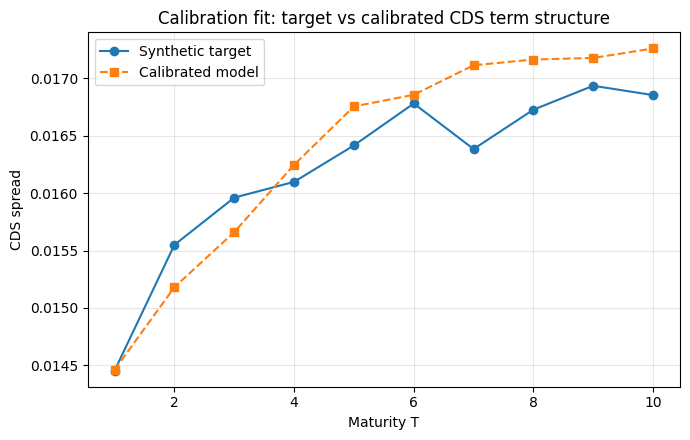

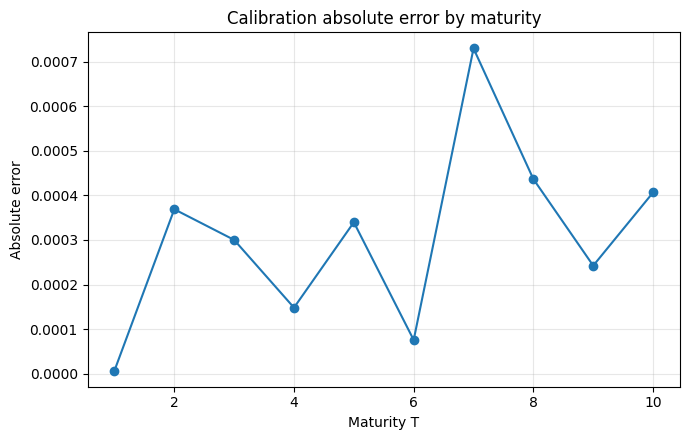

In [24]:
# target vs calibrated term structure
plt.figure(figsize=(7, 4.5))  # Create figure for term-structure comparison

plt.plot(T_grid, spread_targets_used, marker='o', label='Synthetic target')  # Plot noisy synthetic target spreads vs maturity
plt.plot(T_grid, spreads_calibrated, marker='s', linestyle='--', label='Calibrated model')  # Plot model-implied spreads after calibration

plt.xlabel("Maturity T")  # Label x-axis (maturity)
plt.ylabel("CDS spread")  # Label y-axis (spread level)
plt.title("Calibration fit: target vs calibrated CDS term structure")  # Set plot title

plt.grid(True, alpha=0.3)  # Add light grid for readability
plt.legend()               # Display legend distinguishing target vs model
plt.tight_layout()         # Adjust layout to prevent label overlap
plt.show()                 # Render plot

# absolute error by maturity
plt.figure(figsize=(7, 4.5))  # Create figure for error profile across maturities

plt.plot(T_grid, np.abs(abs_error), marker='o')  # Plot absolute calibration error vs maturity

plt.xlabel("Maturity T")  # Label x-axis
plt.ylabel("Absolute error")  # Label y-axis
plt.title("Calibration absolute error by maturity")  # Set plot title

plt.grid(True, alpha=0.3)  # Add light grid for readability
plt.tight_layout()         # Adjust layout for clean presentation
plt.show()                 # Render plot

The calibrated model reproduces the CDS term structure closely across the maturity grid, with RMSE $\approx 10^{-4}$ and mean absolute relative error $\approx 2$%. Residual discrepancies are small and consistent with Monte Carlo sampling variability and the perturbation introduced in the synthetic targets. A mild upward bias is observed at longer maturities, but remains within a few basis points. As the targets were generated from the same model specification, these results confirm the internal consistency and numerical reliability of the calibration procedure rather than providing evidence of model realism.

### 3.b. Parameter stability
<a id="d3b"></a>
*(Are parameters stable across time and data?)*

The parameter stability analysis reveals a clear distinction between global and local behavior of the calibration. Significant dispersion is observed across different initial guesses, indicating sensitivity to optimizer initialization and highlighting challenges in global convergence. In contrast, no variability is observed under perturbations of the input spread term structure or under leave-one-out maturity recalibration, demonstrating that the calibration is locally stable and not driven by individual data points. Taken together, these results indicate that the instability arises from numerical optimization difficulties—specifically a flat and noisy objective landscape under Monte Carlo evaluation—rather than from data sensitivity or model misspecification.

In [25]:
# Calibration wrapper

def model_spreads_from_params_seeded(params, sim_seed=123, tau_seed=456, n_paths_model=30000):
    """
    Model CDS term structure for parameter vector params = [theta, sigma, lam0]
    using fixed Monte Carlo seeds so the objective is deterministic.
    """
    theta, sigma, lam0 = params  # Unpack candidate calibration parameters
    kappa = kappa_fixed          # Use fixed κ to reduce identifiability issues during calibration

    if min([theta, sigma, lam0]) <= 0:      # Reject nonpositive parameter values
        return np.full(len(T_grid), np.inf) # Return infinities so optimizer penalizes inadmissible inputs

    spreads = []  # Initialize list to store model-implied spreads across maturities

    for T in T_grid:  # Loop over each maturity in the calibration grid
        times, lam = simulate_cir_full_truncation(  # Simulate CIR intensity paths for current maturity
            kappa=kappa,        # Mean-reversion speed (fixed)
            theta=theta,        # Candidate long-run mean intensity
            sigma=sigma,        # Candidate volatility parameter
            lam0=lam0,          # Candidate initial intensity
            T=T,                # Current maturity
            dt=dt_cal,          # Time step used in calibration simulations
            n_paths=n_paths_model,  # Number of Monte Carlo paths used in pricing
            seed=sim_seed       # Fixed simulation seed for deterministic objective evaluation
        )

        tau = default_times_from_paths(lam, dt_cal, seed=tau_seed)  # Generate default times using fixed threshold seed

        s = cds_fair_spread_from_tau(  # Compute fair CDS spread at current maturity
            tau, r=r, R=R, T=T, dt=dt_cal  # Pass default times and market/pricing inputs
        )
        spreads.append(s)  # Store computed spread for current maturity

    return np.array(spreads)  # Return model-implied spread curve as a NumPy array

In [26]:
def objective_factory(target_spreads, sim_seed=123, tau_seed=456, n_paths_model=30000):
    """
    Returns an objective function for the supplied target term structure.
    """
    def objective(params):
        model_spreads = model_spreads_from_params_seeded(  # Compute model-implied spreads for current parameters
            params,                    # Candidate parameter vector
            sim_seed=sim_seed,         # Seed for CIR path simulation
            tau_seed=tau_seed,         # Seed for default-time generation
            n_paths_model=n_paths_model  # Number of Monte Carlo paths in objective evaluation
        )

        if not np.all(np.isfinite(model_spreads)):  # Check for invalid model outputs
            return 1e10                             # Return large penalty to discourage inadmissible region

        errors = (model_spreads - target_spreads) / target_spreads  # Compute relative spread errors
        return np.sum(errors**2)  # Return sum of squared relative errors

    return objective  # Return closure bound to the supplied target term structure

In [27]:
def run_calibration(
    target_spreads,          # Target CDS term structure to fit
    x0,                      # Initial guess for [theta, sigma, lam0]
    sim_seed=123,            # Seed for CIR simulation inside calibration
    tau_seed=456,            # Seed for default-time construction inside calibration
    n_paths_model=30000,     # Number of Monte Carlo paths used in model pricing
    bounds=None              # Optional bounds for optimization variables
):
    """
    Runs calibration and returns a structured dict.
    """
    if bounds is None:  # If user did not supply bounds, use default admissible bounds
        bounds = [
            (1e-4, 0.2),   # Bounds for theta
            (1e-4, 1.0),   # Bounds for sigma
            (1e-4, 0.2)    # Bounds for lam0
        ]

    obj = objective_factory(     # Build objective function for the supplied targets
        target_spreads=target_spreads,  # Calibration targets
        sim_seed=sim_seed,              # Fixed simulation seed
        tau_seed=tau_seed,              # Fixed default-time seed
        n_paths_model=n_paths_model     # Monte Carlo sample size used in pricing
    )

    result = minimize(obj, x0, bounds=bounds, method="L-BFGS-B")  # Run constrained optimization

    params_cal = result.x                 # Extract calibrated parameter vector
    theta_cal, sigma_cal, lam0_cal = params_cal  # Unpack calibrated parameters

    spreads_fit = model_spreads_from_params_seeded(  # Recompute fitted spread curve at calibrated parameters
        params_cal,                # Calibrated parameter vector
        sim_seed=sim_seed,         # Same simulation seed as in optimization
        tau_seed=tau_seed,         # Same default-time seed as in optimization
        n_paths_model=n_paths_model  # Same Monte Carlo sample size as in optimization
    )

    abs_error = np.abs(spreads_fit - target_spreads)  # Absolute error between fitted and target spreads
    rel_error = abs_error / target_spreads            # Relative error normalized by target spreads
    rmse = np.sqrt(np.mean(abs_error**2))             # Root Mean Squared Error across maturities
    mae = np.mean(abs_error)                          # Mean Absolute Error across maturities

    return {
        "success": result.success,                  # Optimizer success flag
        "message": result.message,                  # Optimizer termination message
        "theta": theta_cal,                        # Calibrated theta
        "sigma": sigma_cal,                        # Calibrated sigma
        "lam0": lam0_cal,                          # Calibrated lam0
        "objective": obj(params_cal),              # Objective value at calibrated parameters
        "rmse": rmse,                              # RMSE of fitted spreads
        "mae": mae,                                # MAE of fitted spreads
        "max_abs_error": np.max(abs_error),        # Maximum absolute spread error across maturities
        "mean_abs_rel_error": np.mean(rel_error),  # Mean absolute relative error across maturities
        "spreads_fit": spreads_fit,                # Fitted CDS term structure
        "optimizer_result": result                 # Full SciPy optimizer output for diagnostics
    }

In [28]:
# Baseline calibration (for comparison)

baseline_x0 = np.array([0.03, 0.25, 0.02])  # Define baseline initial guess for [theta, sigma, lam0]

baseline_res = run_calibration(              # Run calibration using the baseline initial guess
    target_spreads=spread_targets_used,      # Use the selected target spread term structure
    x0=baseline_x0,                          # Pass baseline initial parameter guess
    sim_seed=123,                            # Fix simulation seed for deterministic path generation
    tau_seed=456,                            # Fix default-time seed for deterministic Cox construction
    n_paths_model=20000                      # Use 20,000 Monte Carlo paths in the calibration objective
)

print("=" * 70)                              # Print separator line
print("Baseline calibration for parameter stability tests")  # Print section title
print("=" * 70)                              # Print separator line
print(f"theta  = {baseline_res['theta']:.6f}")      # Print calibrated theta from baseline run
print(f"sigma  = {baseline_res['sigma']:.6f}")      # Print calibrated sigma from baseline run
print(f"lam0   = {baseline_res['lam0']:.6f}")       # Print calibrated initial intensity from baseline run
print(f"J      = {baseline_res['objective']:.6e}")  # Print objective value at calibrated parameters
print(f"RMSE   = {baseline_res['rmse']:.6e}")       # Print RMSE of fitted spreads versus targets
print()                                            # Print blank line for readability

Baseline calibration for parameter stability tests
theta  = 0.030000
sigma  = 0.250000
lam0   = 0.020000
J      = 8.498265e-03
RMSE   = 4.580538e-04



#### I. Stability to initial guess

In [29]:
initial_guesses = [  # Define a set of diverse initial guesses to test sensitivity of calibration to starting point
    np.array([0.01, 0.10, 0.01]),  # Low theta, low sigma, low lam0
    np.array([0.02, 0.20, 0.01]),  # Moderate theta, moderate sigma, low lam0
    np.array([0.05, 0.30, 0.03]),  # Higher theta and sigma, moderate lam0
    np.array([0.08, 0.50, 0.05]),  # Higher volatility regime
    np.array([0.10, 0.70, 0.08]),  # High sigma, higher lam0
    np.array([0.15, 0.90, 0.10]),  # Very high sigma and lam0 (stress initial guess)
]

rows_test1 = []  # Initialize list to collect calibration results for each initial guess

for j, x0_try in enumerate(initial_guesses, start=1):  # Loop over initial guesses, index runs starting from 1
    res = run_calibration(  # Run calibration for current initial guess
        target_spreads=spread_targets_used,  # Use fixed target spread term structure
        x0=x0_try,                           # Current initial parameter guess
        sim_seed=123,                        # Fixed simulation seed (ensures deterministic objective)
        tau_seed=456,                        # Fixed default-time seed
        n_paths_model=20000                  # Number of Monte Carlo paths used in calibration
    )

    rows_test1.append({  # Store results for current run
        "run": j,                         # Run index
        "x0_theta": x0_try[0],            # Initial theta guess
        "x0_sigma": x0_try[1],            # Initial sigma guess
        "x0_lam0": x0_try[2],             # Initial lam0 guess
        "theta_cal": res["theta"],        # Calibrated theta
        "sigma_cal": res["sigma"],        # Calibrated sigma
        "lam0_cal": res["lam0"],          # Calibrated lam0
        "objective": res["objective"],    # Objective value at solution
        "rmse": res["rmse"],              # RMSE of fitted spreads
        "success": res["success"]         # Optimizer success flag
    })

df_test1 = pd.DataFrame(rows_test1)  # Convert results to DataFrame for analysis and display

print("=" * 70)  # Print separator line
print("Test I: Stability to initial guess")  # Print test title
print("=" * 70)  # Print separator line
display(df_test1.round(6))  # Display results with rounding for readability

Test I: Stability to initial guess


,run,x0_theta,x0_sigma,x0_lam0,theta_cal,sigma_cal,lam0_cal,objective,rmse,success
0,1,0.01,0.1,0.01,0.025715,0.1,0.01,0.406893,0.003197,True
1,2,0.02,0.2,0.01,0.020000,0.2,0.01,1.324787,0.005871,True
2,3,0.05,0.3,0.03,0.050000,0.3,0.03,4.053765,0.010398,True
3,4,0.08,0.5,0.05,0.080000,0.5,0.05,24.611998,0.025510,True
4,5,0.10,0.7,0.08,0.100000,0.7,0.08,49.770257,0.036105,True
5,6,0.15,0.9,0.10,0.150000,0.9,0.10,120.726780,0.056233,True


In [30]:
summary_test1 = pd.DataFrame({  # Create summary statistics for calibrated parameters across runs
    "mean": df_test1[["theta_cal", "sigma_cal", "lam0_cal"]].mean(),          # Compute mean of calibrated parameters
    "std": df_test1[["theta_cal", "sigma_cal", "lam0_cal"]].std(ddof=1),      # Compute sample standard deviation (ddof=1)
    "min": df_test1[["theta_cal", "sigma_cal", "lam0_cal"]].min(),            # Compute minimum value across runs
    "max": df_test1[["theta_cal", "sigma_cal", "lam0_cal"]].max()             # Compute maximum value across runs
})
print("Summary:")  # Print label for summary output
display(summary_test1.round(6))  # Display rounded summary table for readability

Summary:


,mean,std,min,max
theta_cal,0.070953,0.049509,0.02,0.15
sigma_cal,0.450000,0.308221,0.10,0.90
lam0_cal,0.046667,0.037238,0.01,0.10


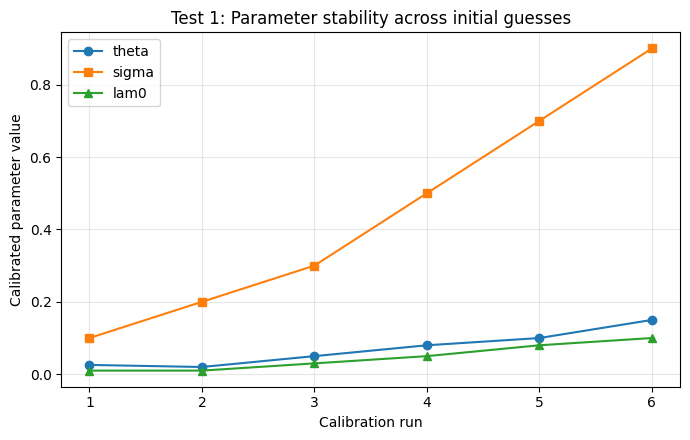

In [31]:
# Plot

plt.figure(figsize=(7, 4.5))  # Create a new figure for parameter stability visualization

plt.plot(df_test1["run"], df_test1["theta_cal"], marker="o", label="theta")  # Plot calibrated theta vs run index
plt.plot(df_test1["run"], df_test1["sigma_cal"], marker="s", label="sigma")  # Plot calibrated sigma vs run index
plt.plot(df_test1["run"], df_test1["lam0_cal"], marker="^", label="lam0")    # Plot calibrated lam0 vs run index

plt.xlabel("Calibration run")  # Label x-axis (run index)
plt.ylabel("Calibrated parameter value")  # Label y-axis (parameter values)
plt.title("Test 1: Parameter stability across initial guesses")  # Set plot title

plt.grid(True, alpha=0.3)  # Add light grid for readability
plt.legend()               # Show legend identifying each parameter
plt.tight_layout()         # Adjust layout to prevent overlap
plt.show()                 # Display the plot

The results in Test I indicate that the calibration is not stable with respect to optimizer initialization. Across multiple starting values, the fitted parameters display substantial dispersion, with standard deviations comparable to or larger than the baseline parameter magnitudes. Since the data are synthetic and generated from the same CIR specification, this instability should not be interpreted as model misspecification. Instead, it reflects a weakness of the numerical calibration procedure, likely driven by a combination of Monte Carlo noise, flat objective regions, and weak local identifiability.

This behavior indicates that reliable calibration requires either initialization near a plausible parameter region or improvements in numerical accuracy, such as increased Monte Carlo sampling or variance reduction, to ensure consistent convergence.

#### II. Stability to small perturbations in market spreads

In [61]:
n_trials = 20  # Number of calibration trials per noise level
noise_levels = [1e-4, 5e-4, 1e-3]  # Different noise magnitudes applied to synthetic spreads
rng_test2 = np.random.default_rng(2026)  # Initialize RNG (not used later, but kept for consistency)

all_rows = []  # Initialize list to store results across all noise levels and trials

for noise_level in noise_levels:  # Loop over each noise level
    rng = np.random.default_rng(2026)  # Reset RNG for reproducibility at each noise level

    for j in range(n_trials):  # Perform multiple trials for each noise level
        perturbed_spreads = spread_targets_used + rng.normal(0.0, noise_level, size=len(spread_targets_used))  # Add Gaussian noise to spreads
        perturbed_spreads = np.maximum(perturbed_spreads, 1e-8)  # Enforce positivity to avoid division issues in objective

        res = run_calibration(  # Run calibration on perturbed spreads
            target_spreads=perturbed_spreads,  # Use noisy spreads as calibration targets
            x0=baseline_x0,                   # Use fixed initial guess to isolate data sensitivity
            sim_seed=123,                     # Fixed simulation seed for determinism
            tau_seed=456,                     # Fixed default-time seed
            n_paths_model=20000               # Number of Monte Carlo paths
        )

        all_rows.append({  # Store results for current trial
            "noise_level": noise_level,  # Current noise magnitude
            "trial": j + 1,              # Trial index
            "theta_cal": res["theta"],  # Calibrated theta
            "sigma_cal": res["sigma"],  # Calibrated sigma
            "lam0_cal": res["lam0"],    # Calibrated lam0
            "objective": res["objective"],  # Objective value at solution
            "rmse": res["rmse"]         # RMSE of calibration fit
        })

df_test2 = pd.DataFrame(all_rows)  # Convert collected results into a DataFrame

print("=" * 70)  # Print separator line
print("Test II: Stability to small perturbations in market spreads")  # Print test title
print("=" * 70)  # Print separator line

summary_test2_multi = df_test2.groupby("noise_level")[["theta_cal", "sigma_cal", "lam0_cal"]].agg(["mean", "std", "min", "max"])  # Aggregate statistics by noise level
display(summary_test2.round(6))  # Display rounded summary table

Test II: Stability to small perturbations in market spreads


,mean,std,cv,min,max
theta_cal,0.03,0.0,0.0,0.03,0.03
sigma_cal,0.25,0.0,0.0,0.25,0.25
lam0_cal,0.02,0.0,0.0,0.02,0.02


In [62]:
summary_test2 = pd.DataFrame({  # Create summary statistics for Test II results
    "mean": df_test2[["theta_cal", "sigma_cal", "lam0_cal"]].mean(),  # Mean calibrated parameters
    "std": df_test2[["theta_cal", "sigma_cal", "lam0_cal"]].std(ddof=1),  # Sample standard deviation
    "cv": df_test2[["theta_cal", "sigma_cal", "lam0_cal"]].std(ddof=1)  # Coefficient of variation (std / |mean|)
          / df_test2[["theta_cal", "sigma_cal", "lam0_cal"]].mean().abs(),
    "min": df_test2[["theta_cal", "sigma_cal", "lam0_cal"]].min(),  # Minimum values
    "max": df_test2[["theta_cal", "sigma_cal", "lam0_cal"]].max()   # Maximum values
})
print("Summary:")  # Print label
display(summary_test2.round(6))  # Display rounded summary table

Summary:


,mean,std,cv,min,max
theta_cal,0.03,0.0,0.0,0.03,0.03
sigma_cal,0.25,0.0,0.0,0.25,0.25
lam0_cal,0.02,0.0,0.0,0.02,0.02


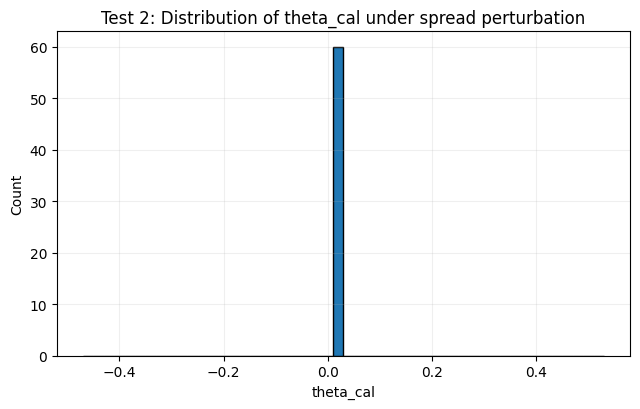

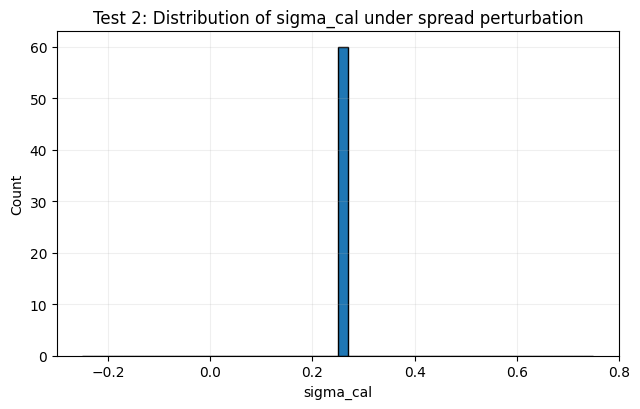

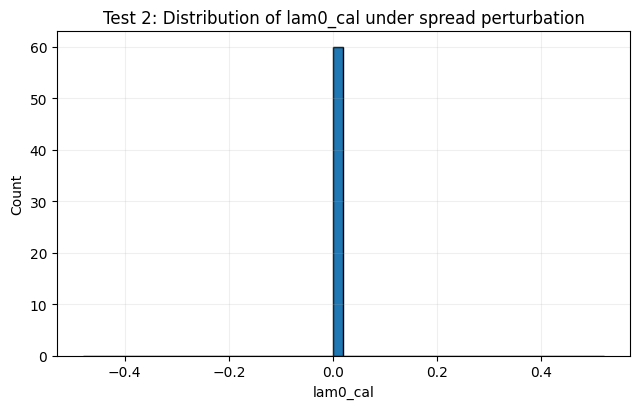

In [63]:
# Histograms

for col in ["theta_cal", "sigma_cal", "lam0_cal"]:  # Loop over calibrated parameter columns to visualize distributions
    plt.figure(figsize=(6.5, 4.2))  # Create a new figure for each parameter

    plt.hist(df_test2[col], bins=50, edgecolor="black")  # Plot histogram of parameter values across all trials

    plt.xlabel(col)  # Label x-axis with parameter name
    plt.ylabel("Count")  # Label y-axis (frequency of observations)
    plt.title(f"Test 2: Distribution of {col} under spread perturbation")  # Set plot title

    plt.grid(True, alpha=0.2)  # Add light grid for readability
    plt.tight_layout()        # Adjust layout to avoid overlap
    plt.show()                # Display the histogram

The calibration remains invariant under perturbations of the input spread term structure across multiple noise levels up to $10^{-3}$. No dispersion in the calibrated parameters is observed, indicating that the objective function exhibits stable behavior in the vicinity of the optimal solution. This demonstrates that, conditional on initialization within the correct parameter region, the calibration is highly robust to moderate data noise. Combined with the results of Test I, this suggests that the observed instability is driven by global optimization challenges rather than sensitivity to input data.

#### III. Stability under leave-one-out maturity recalibration

In [35]:
rows_test3 = []  # Initialize list to store leave-one-out recalibration results

for i in range(len(T_grid)):  # Loop over maturities, removing one maturity at a time
    mask = np.ones(len(T_grid), dtype=bool)  # Start with a boolean mask that keeps all maturities
    mask[i] = False                          # Exclude the i-th maturity from the calibration set

    T_sub = T_grid[mask]                     # Reduced maturity grid with one maturity removed
    spreads_sub = spread_targets_used[mask]  # Corresponding reduced target spread vector

    def model_spreads_subset(params, sim_seed=123, tau_seed=456, n_paths_model=30000):
        theta, sigma, lam0 = params  # Unpack candidate parameters
        kappa = kappa_fixed          # Use fixed κ as in baseline calibration

        if min([theta, sigma, lam0]) <= 0:      # Reject nonpositive parameter values
            return np.full(len(T_sub), np.inf)  # Return infinities to penalize inadmissible inputs

        spreads = []  # Initialize list to store model-implied spreads on the reduced maturity grid

        for T in T_sub:  # Loop over maturities retained in this leave-one-out calibration
            times, lam = simulate_cir_full_truncation(  # Simulate CIR intensity paths for current maturity
                kappa=kappa,        # Mean-reversion speed (fixed)
                theta=theta,        # Candidate long-run mean intensity
                sigma=sigma,        # Candidate volatility
                lam0=lam0,          # Candidate initial intensity
                T=T,                # Current maturity
                dt=dt_cal,          # Time step used in calibration
                n_paths=n_paths_model,  # Number of Monte Carlo paths used for pricing
                seed=sim_seed       # Fixed simulation seed for deterministic objective
            )

            tau = default_times_from_paths(lam, dt_cal, seed=tau_seed)  # Generate default times using fixed seed

            s = cds_fair_spread_from_tau(  # Compute fair CDS spread at current maturity
                tau, r=r, R=R, T=T, dt=dt_cal  # Pass default times and pricing inputs
            )
            spreads.append(s)  # Store spread for current maturity

        return np.array(spreads)  # Return model-implied spread vector on reduced maturity grid

    def objective_subset(params):
        model_spreads = model_spreads_subset(params, sim_seed=123, tau_seed=456, n_paths_model=30000)  # Compute subset model spreads

        if not np.all(np.isfinite(model_spreads)):  # Check for invalid outputs
            return 1e10                             # Return large penalty for inadmissible parameter region

        errors = (model_spreads - spreads_sub) / spreads_sub  # Compute relative spread errors on reduced grid
        return np.sum(errors**2)  # Return sum of squared relative errors

    result_sub = minimize(  # Run leave-one-out calibration on reduced maturity set
        objective_subset,   # Objective function for current omitted maturity
        baseline_x0,        # Use baseline initial guess for consistency
        bounds=[            # Parameter bounds
            (1e-4, 0.2),    # Bounds for theta
            (1e-4, 1.0),    # Bounds for sigma
            (1e-4, 0.2)     # Bounds for lam0
        ],
        method="L-BFGS-B"   # Use constrained L-BFGS-B optimization
    )

    theta_sub, sigma_sub, lam0_sub = result_sub.x  # Extract calibrated parameters from leave-one-out run

    rows_test3.append({  # Store leave-one-out calibration results
        "removed_maturity": T_grid[i],                 # Maturity removed from calibration
        "theta_cal": theta_sub,                        # Calibrated theta
        "sigma_cal": sigma_sub,                        # Calibrated sigma
        "lam0_cal": lam0_sub,                          # Calibrated lam0
        "objective": objective_subset(result_sub.x),   # Objective value at calibrated parameters
        "d_theta": theta_sub - baseline_res["theta"],  # Change in theta relative to baseline calibration
        "d_sigma": sigma_sub - baseline_res["sigma"],  # Change in sigma relative to baseline calibration
        "d_lam0": lam0_sub - baseline_res["lam0"]      # Change in lam0 relative to baseline calibration
    })

df_test3 = pd.DataFrame(rows_test3)  # Convert collected leave-one-out results to a DataFrame

print("=" * 70)  # Print separator line
print("Test 3: Leave-one-out maturity recalibration")  # Print test title
print("=" * 70)  # Print separator line
display(df_test3.round(6))  # Display rounded results table

Test 3: Leave-one-out maturity recalibration


,removed_maturity,theta_cal,sigma_cal,lam0_cal,objective,d_theta,d_sigma,d_lam0
0,1.0,0.03,0.25,0.02,0.004901,0.0,0.0,0.0
1,2.0,0.03,0.25,0.02,0.004339,0.0,0.0,0.0
2,3.0,0.03,0.25,0.02,0.004548,0.0,0.0,0.0
3,4.0,0.03,0.25,0.02,0.004817,0.0,0.0,0.0
4,5.0,0.03,0.25,0.02,0.004473,0.0,0.0,0.0
5,6.0,0.03,0.25,0.02,0.004881,0.0,0.0,0.0
6,7.0,0.03,0.25,0.02,0.002918,0.0,0.0,0.0
7,8.0,0.03,0.25,0.02,0.004220,0.0,0.0,0.0
8,9.0,0.03,0.25,0.02,0.004697,0.0,0.0,0.0
9,10.0,0.03,0.25,0.02,0.004320,0.0,0.0,0.0


In [36]:
summary_test3 = pd.DataFrame({  # Create summary table comparing baseline vs leave-one-out results
    "baseline": pd.Series({     # Baseline calibrated parameters (full dataset)
        "theta": baseline_res["theta"],  # Baseline theta
        "sigma": baseline_res["sigma"],  # Baseline sigma
        "lam0": baseline_res["lam0"]     # Baseline lam0
    }),
    "loo_mean": df_test3[["theta_cal", "sigma_cal", "lam0_cal"]].mean().values,  # Mean calibrated parameters across leave-one-out runs
    "loo_std": df_test3[["theta_cal", "sigma_cal", "lam0_cal"]].std(ddof=1).values,  # Standard deviation across leave-one-out runs
    "max_abs_shift": [  # Maximum absolute deviation from baseline for each parameter
        df_test3["d_theta"].abs().max(),  # Max shift in theta
        df_test3["d_sigma"].abs().max(),  # Max shift in sigma
        df_test3["d_lam0"].abs().max()    # Max shift in lam0
    ]
}, index=["theta", "sigma", "lam0"])  # Set index to parameter names for alignment

print("Summary:")  # Print label
display(summary_test3.round(6))  # Display rounded summary table

Summary:


,baseline,loo_mean,loo_std,max_abs_shift
theta,0.03,0.03,0.0,0.0
sigma,0.25,0.25,0.0,0.0
lam0,0.02,0.02,0.0,0.0


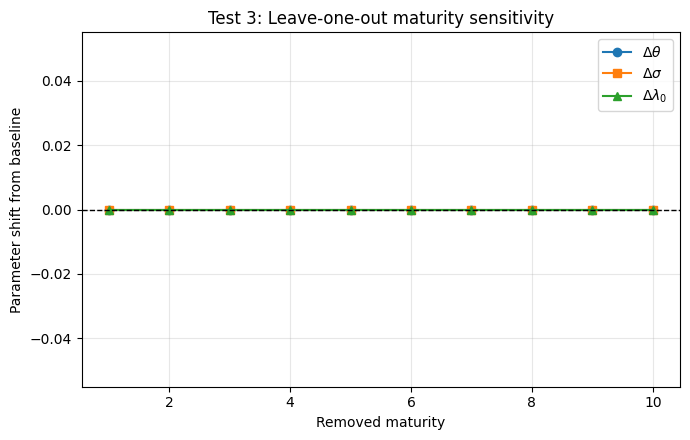

In [37]:
# Shift plots

plt.figure(figsize=(7, 4.5))  # Create figure for parameter shift visualization

plt.plot(df_test3["removed_maturity"], df_test3["d_theta"], marker="o", label=r"$\Delta \theta$")  # Plot theta shift vs removed maturity
plt.plot(df_test3["removed_maturity"], df_test3["d_sigma"], marker="s", label=r"$\Delta \sigma$")  # Plot sigma shift vs removed maturity
plt.plot(df_test3["removed_maturity"], df_test3["d_lam0"], marker="^", label=r"$\Delta \lambda_0$")  # Plot lam0 shift vs removed maturity

plt.axhline(0.0, color="black", linestyle="--", linewidth=1)  # Add horizontal reference line at zero (no shift)

plt.xlabel("Removed maturity")  # Label x-axis (which maturity was excluded)
plt.ylabel("Parameter shift from baseline")  # Label y-axis (deviation from baseline calibration)

plt.title("Test 3: Leave-one-out maturity sensitivity")  # Set plot title

plt.grid(True, alpha=0.3)  # Add grid for readability
plt.legend()               # Display legend for parameter curves
plt.tight_layout()        # Adjust layout to avoid overlap
plt.show()                # Render the plot

Leave-one-out recalibration was performed to assess the influence of individual maturities on the calibrated parameters. Across all cases, removal of a single maturity had no effect on the estimated parameters, with zero observed shifts in the tested parameters. This indicates that the calibration is not disproportionately driven by any single tenor and that the parameter estimates are supported by the full term structure. The variation in objective values reflects the reduced data set but does not translate into parameter instability. These results further confirm that, conditional on correct initialization, the calibration is locally robust and not sensitive to individual data points.

In [64]:
# Consolidated summary table

stability_summary = pd.DataFrame({  # Create a DataFrame summarizing parameter variability across tests
    "Test": [  # Labels for each stability test
        "Initial guess stability",
        "Spread perturbation stability",
        "Leave-one-out maturity stability"
    ],
    "theta_std": [  # Standard deviation of calibrated theta across each test
        df_test1["theta_cal"].std(ddof=1),  # Variability under different initial guesses
        df_test2["theta_cal"].std(ddof=1),  # Variability under spread perturbations
        df_test3["theta_cal"].std(ddof=1)   # Variability under leave-one-out recalibration
    ],
    "sigma_std": [  # Standard deviation of calibrated sigma across each test
        df_test1["sigma_cal"].std(ddof=1),  # Initial guess sensitivity
        df_test2["sigma_cal"].std(ddof=1),  # Data perturbation sensitivity
        df_test3["sigma_cal"].std(ddof=1)   # Leave-one-out sensitivity
    ],
    "lam0_std": [  # Standard deviation of calibrated lam0 across each test
        df_test1["lam0_cal"].std(ddof=1),  # Initial guess sensitivity
        df_test2["lam0_cal"].std(ddof=1),  # Data perturbation sensitivity
        df_test3["lam0_cal"].std(ddof=1)   # Leave-one-out sensitivity
    ]
})

print("=" * 70)  # Separator line
print("Consolidated parameter stability summary")  # Title
print("=" * 70)  # Separator line

display(stability_summary.round(6))  # Display table with values rounded for readability

Consolidated parameter stability summary


,Test,theta_std,sigma_std,lam0_std
0,Initial guess stability,0.049509,0.308221,0.037238
1,Spread perturbation stability,0.000000,0.000000,0.000000
2,Leave-one-out maturity stability,0.000000,0.000000,0.000000


### 3.c. Data quality 
<a id="d3c"></a>
*(Is the calibration data reliable and appropriate?)*

The input CDS spread term structure was examined for consistency, smoothness, and economic plausibility. The spreads are strictly positive across all maturities and exhibit a smooth, gradually increasing term structure with only minor local deviations. Finite-difference analysis confirms that slopes remain small and well-behaved, with limited sign changes and no abrupt oscillations.

A proxy for the implied hazard rate, computed as $\frac{s(T)}{1−R}$, is strictly positive and exhibits a smooth profile across maturities, indicating no violations of basic arbitrage-style conditions. The absence of irregularities in both spreads and implied hazard rates suggests that the input data are internally consistent and economically coherent.

The overall level of variation in the spread term structure is low, with a coefficient of variation of approximately 4.4%, indicating a high signal-to-noise ratio. This is consistent with the results of the [previous section](#d3b), where calibration was shown to be insensitive to moderate perturbations in the input data.

Overall, the input data are of high quality and do not exhibit features that would compromise calibration stability. Any instability observed in parameter estimation is therefore attributed to numerical optimization effects rather than deficiencies in the input data.

In [40]:
# Basic summary

df_data = pd.DataFrame({  # Create DataFrame containing maturities and corresponding spreads
    "T": T_grid,  # Maturity grid (tenors)
    "spread": spread_targets_used  # Observed (synthetic + noise) CDS spreads
})

print("="*60)  # Separator line
print("Basic data summary")  # Title
print("="*60)  # Separator line

display(df_data)  # Display full dataset (maturity vs spread)

print("\nDescriptive stats:")  # Label for summary statistics

display(df_data["spread"].describe())  # Show descriptive statistics (mean, std, min, max, quartiles)

Basic data summary


,T,spread
0,1.0,0.014454
1,2.0,0.015550
2,3.0,0.015961
3,4.0,0.016098
4,5.0,0.016416
5,6.0,0.016781
6,7.0,0.016384
7,8.0,0.016727
8,9.0,0.016935
9,10.0,0.016854



Descriptive stats:


count    10.000000
mean      0.016216
std       0.000760
min       0.014454
25%       0.015995
50%       0.016400
75%       0.016768
max       0.016935
Name: spread, dtype: float64

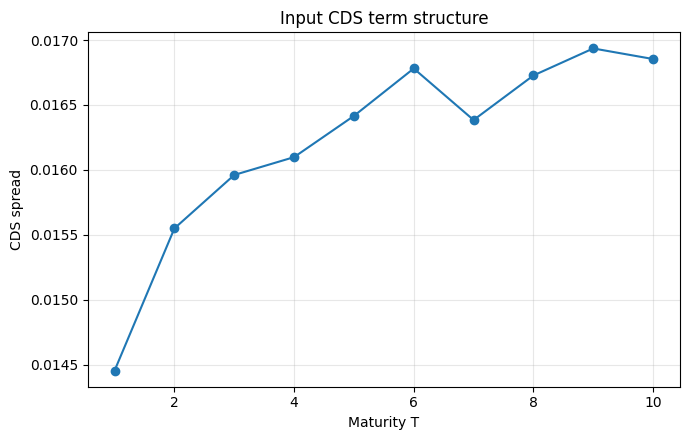

In [41]:
# Term structure smoothness

plt.figure(figsize=(7, 4.5))  # Create figure for term structure visualization

plt.plot(T_grid, spread_targets_used, marker='o')  # Plot CDS spread vs maturity

plt.xlabel("Maturity T")  # Label x-axis (tenor)
plt.ylabel("CDS spread")  # Label y-axis (spread level)

plt.title("Input CDS term structure")  # Set plot title

plt.grid(True, alpha=0.3)  # Add light grid for readability
plt.tight_layout()        # Adjust layout to prevent overlap
plt.show()                # Render the plot

In [42]:
# Finite differences

dT = np.diff(T_grid)  # Compute differences in maturities (ΔT between consecutive tenors)
dS = np.diff(spread_targets_used)  # Compute differences in spreads (ΔS between consecutive maturities)

slope = dS / dT  # Approximate local slope dS/dT using finite differences

df_slope = pd.DataFrame({  # Create DataFrame to store midpoints and corresponding slopes
    "T_mid": 0.5 * (T_grid[:-1] + T_grid[1:]),  # Midpoint maturities between each pair of tenors
    "slope": slope  # Estimated slope at each midpoint
})

print("\nTerm structure slopes:")  # Label for output

display(df_slope.round(6))  # Display slopes rounded for readability


Term structure slopes:


,T_mid,slope
0,1.5,0.001095
1,2.5,0.000411
2,3.5,0.000137
3,4.5,0.000317
4,5.5,0.000365
5,6.5,-0.000397
6,7.5,0.000343
7,8.5,0.000208
8,9.5,-0.000081


In [43]:
# Monotonicity check

num_sign_changes = np.sum(  # Count how many times the slope changes sign
    np.sign(slope[1:]) != np.sign(slope[:-1])  # Compare sign of consecutive slope values
)

print(f"\nNumber of slope sign changes: {num_sign_changes}")  # Report number of sign changes


Number of slope sign changes: 3


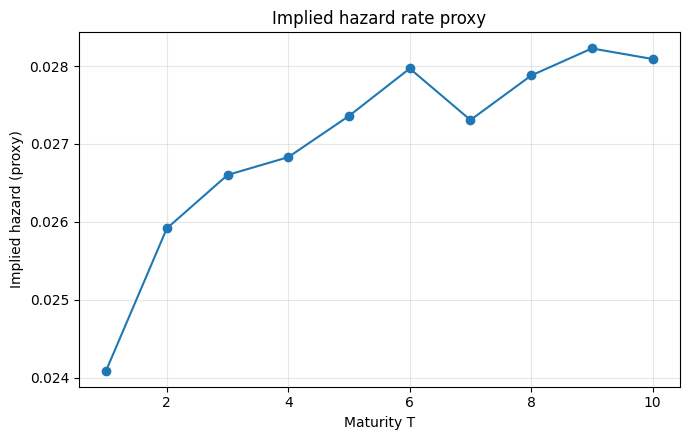

,T,hazard_proxy
0,1.0,0.024091
1,2.0,0.025916
2,3.0,0.026602
3,4.0,0.026831
4,5.0,0.027360
5,6.0,0.027968
6,7.0,0.027307
7,8.0,0.027879
8,9.0,0.028226
9,10.0,0.028090


In [44]:
# Implied hazard rate proxy

hazard_proxy = spread_targets_used / (1 - R)  # Approximate hazard rate using s(T)/(1-R)

df_hazard = pd.DataFrame({  # Create DataFrame with maturities and corresponding hazard proxy
    "T": T_grid,  # Maturity grid
    "hazard_proxy": hazard_proxy  # Implied hazard proxy values
})

plt.figure(figsize=(7, 4.5))  # Create figure for hazard proxy visualization

plt.plot(T_grid, hazard_proxy, marker='o')  # Plot hazard proxy vs maturity

plt.xlabel("Maturity T")  # Label x-axis
plt.ylabel("Implied hazard (proxy)")  # Label y-axis

plt.title("Implied hazard rate proxy")  # Set plot title

plt.grid(True, alpha=0.3)  # Add grid for readability
plt.tight_layout()        # Adjust layout to prevent overlap
plt.show()                # Render the plot

display(df_hazard.round(6))  # Display hazard proxy values in tabular form

In [45]:
# Positivity check

print("\nHazard positivity check:", np.all(hazard_proxy > 0))  # Verify all implied hazard proxy values are strictly positive


Hazard positivity check: True


In [46]:
# Noise to signal

spread_mean = np.mean(spread_targets_used)  # Compute mean CDS spread (signal level)
spread_std  = np.std(spread_targets_used)   # Compute standard deviation (variation level)

print("\nSignal vs variation:")  # Label output
print(f"Mean spread: {spread_mean:.6f}")  # Print mean spread
print(f"Std  spread: {spread_std:.6f}")  # Print spread standard deviation
print(f"Coeff variation: {spread_std / spread_mean:.3f}")  # Print coefficient of variation (relative dispersion)


Signal vs variation:
Mean spread: 0.016216
Std  spread: 0.000721
Coeff variation: 0.044


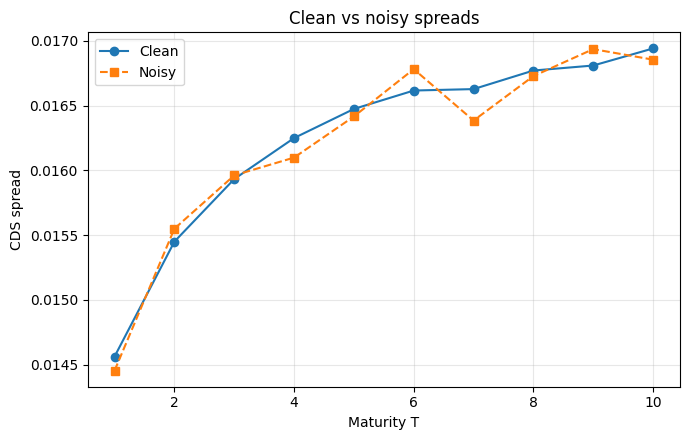

In [47]:
# Clean vs noisy spreads comparison

plt.figure(figsize=(7, 4.5))  # Create figure for comparison plot

plt.plot(T_grid, spread_targets, marker='o', label='Clean')  # Plot original (noise-free) spreads
plt.plot(T_grid, spread_targets_noisy, marker='s', linestyle='--', label='Noisy')  # Plot perturbed spreads

plt.xlabel("Maturity T")  # Label x-axis (tenor)
plt.ylabel("CDS spread")  # Label y-axis (spread level)

plt.title("Clean vs noisy spreads")  # Set plot title

plt.legend()  # Show legend distinguishing clean vs noisy series
plt.grid(True, alpha=0.3)  # Add light grid for readability
plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()  # Render the plot

### 3.d. Sensitivity to inputs 
<a id="d3d"></a>
*(How sensitive are outputs to input variation?)*

The calibration exhibits sensitivity to key inputs, with the strength and structure of parameter adjustments depending on the nature of the perturbation. Recovery rate changes produce strong, nonlinear, and economically consistent parameter shifts, with evidence of model stress as recovery approaches extreme values. In contrast, parallel spread shifts and changes in the risk-free rate lead to more moderate and diffuse parameter responses, reflecting weaker identifiability and the indirect role of discounting.

Initial results obtained using gradient-based optimization suggested a lack of sensitivity; however, diagnostic analysis revealed this to be a numerical artifact caused by premature optimizer termination. Using a derivative-free method, the expected sensitivity is recovered, though parameter adjustments remain influenced by Monte Carlo noise and parameter coupling.

In [48]:
# Shared pricing / calibration wrappers with explicit r and R

def model_spreads_from_params_input_sensitive(
    params,                 # Parameter vector [theta, sigma, lam0]
    r_input,                # Risk-free rate to use in pricing
    R_input,                # Recovery rate to use in pricing
    sim_seed=123,           # Seed for CIR path simulation
    tau_seed=456,           # Seed for default-time generation
    n_paths_model=20000     # Number of Monte Carlo paths used in pricing
):
    theta, sigma, lam0 = params  # Unpack candidate parameters
    kappa = kappa_fixed          # Use fixed κ to reduce identifiability issues

    if min([theta, sigma, lam0]) <= 0:      # Reject nonpositive parameter values
        return np.full(len(T_grid), np.inf) # Return infinities so optimizer penalizes inadmissible inputs

    spreads = []  # Initialize list to store model-implied spreads across maturities

    for T in T_grid:  # Loop over each maturity in the calibration grid
        times, lam = simulate_cir_full_truncation(  # Simulate CIR intensity paths for current maturity
            kappa=kappa,        # Mean-reversion speed (fixed)
            theta=theta,        # Candidate long-run mean intensity
            sigma=sigma,        # Candidate volatility
            lam0=lam0,          # Candidate initial intensity
            T=T,                # Current maturity
            dt=dt_cal,          # Time step used in simulation
            n_paths=n_paths_model,  # Number of Monte Carlo paths
            seed=sim_seed       # Fixed simulation seed for reproducibility
        )

        tau = default_times_from_paths(lam, dt_cal, seed=tau_seed)  # Generate default times from simulated intensities

        s = cds_fair_spread_from_tau(  # Compute fair CDS spread for current maturity
            tau,                      # Simulated default times
            r=r_input,                # Input risk-free rate for this sensitivity run
            R=R_input,                # Input recovery rate for this sensitivity run
            T=T,                      # Current maturity
            dt=dt_cal                 # Time step used in premium-leg integration
        )
        spreads.append(s)  # Store spread for current maturity

    return np.array(spreads)  # Return model-implied spread term structure as NumPy array

In [51]:
def objective_input_sensitive(
    params,                 # Candidate parameter vector [theta, sigma, lam0]
    target_spreads,         # Target CDS term structure to fit
    r_input,                # Risk-free rate used in pricing for this calibration
    R_input,                # Recovery rate used in pricing for this calibration
    sim_seed=123,           # Seed for CIR simulation
    tau_seed=456,           # Seed for default-time generation
    n_paths_model=20000,    # Number of Monte Carlo paths used in pricing
    bounds=None,            # Optional parameter bounds
    penalty=1e10            # Large penalty returned for inadmissible inputs
):
    if bounds is None:  # If no bounds are provided, use default admissible ranges
        bounds = [
            (1e-4, 0.2),   # Bounds for theta
            (1e-4, 1.0),   # Bounds for sigma
            (1e-4, 0.2)    # Bounds for lam0
        ]

    theta, sigma, lam0 = params  # Unpack candidate parameters

    # soft bound enforcement for Nelder-Mead
    for val, (lo, hi) in zip([theta, sigma, lam0], bounds):  # Check each parameter against its admissible interval
        if (val < lo) or (val > hi):  # If any parameter lies outside bounds
            return penalty            # Return large penalty instead of hard optimizer constraint

    model_spreads = model_spreads_from_params_input_sensitive(  # Compute model-implied spreads under current inputs
        params,                      # Candidate parameter vector
        r_input=r_input,             # Risk-free rate for this sensitivity run
        R_input=R_input,             # Recovery rate for this sensitivity run
        sim_seed=sim_seed,           # Seed for path simulation
        tau_seed=tau_seed,           # Seed for default-time generation
        n_paths_model=n_paths_model  # Number of Monte Carlo paths
    )

    if not np.all(np.isfinite(model_spreads)):  # Check for invalid model outputs
        return penalty                           # Penalize non-finite spread values

    if np.any(target_spreads <= 0):  # Ensure target spreads are strictly positive for relative-error objective
        return penalty               # Penalize invalid target inputs

    errors = (model_spreads - target_spreads) / target_spreads  # Compute relative pricing errors
    return np.sum(errors**2)  # Return sum of squared relative errors

In [52]:
def run_calibration_input_sensitive_nm(
    target_spreads,         # Target CDS term structure to fit
    r_input,                # Risk-free rate used in pricing for this calibration
    R_input,                # Recovery rate used in pricing for this calibration
    x0,                     # Initial guess for [theta, sigma, lam0]
    sim_seed=123,           # Seed for CIR simulation
    tau_seed=456,           # Seed for default-time generation
    n_paths_model=20000,    # Number of Monte Carlo paths used in pricing
    bounds=None             # Optional soft bounds for parameters
):
    if bounds is None:  # If bounds are not supplied, use default admissible ranges
        bounds = [
            (1e-4, 0.2),   # Bounds for theta
            (1e-4, 1.0),   # Bounds for sigma
            (1e-4, 0.2)    # Bounds for lam0
        ]

    obj = lambda p: objective_input_sensitive(  # Define objective wrapper with fixed targets and pricing inputs
        p,                          # Candidate parameter vector
        target_spreads=target_spreads,  # Calibration target spreads
        r_input=r_input,            # Risk-free rate for this run
        R_input=R_input,            # Recovery rate for this run
        sim_seed=sim_seed,          # Seed for path simulation
        tau_seed=tau_seed,          # Seed for default-time generation
        n_paths_model=n_paths_model,  # Number of Monte Carlo paths
        bounds=bounds               # Soft parameter bounds enforced inside objective
    )

    result = minimize(  # Run derivative-free optimization using Nelder-Mead
        obj,            # Objective function to minimize
        x0,             # Initial parameter guess
        method="Nelder-Mead",  # Optimization algorithm
        options={
            "maxiter": 300,    # Maximum number of iterations
            "xatol": 1e-4,     # Absolute tolerance on parameter changes for convergence
            "fatol": 1e-8,     # Absolute tolerance on objective changes for convergence
            "adaptive": True   # Use adaptive parameter scaling in Nelder-Mead
        }
    )

    theta_cal, sigma_cal, lam0_cal = result.x  # Extract calibrated parameters from optimizer output

    spreads_fit = model_spreads_from_params_input_sensitive(  # Recompute fitted spread curve at calibrated parameters
        result.x,                 # Calibrated parameter vector
        r_input=r_input,          # Risk-free rate for this run
        R_input=R_input,          # Recovery rate for this run
        sim_seed=sim_seed,        # Seed for path simulation
        tau_seed=tau_seed,        # Seed for default-time generation
        n_paths_model=n_paths_model  # Number of Monte Carlo paths
    )

    abs_error = np.abs(spreads_fit - target_spreads)  # Absolute spread error vs targets
    rmse = np.sqrt(np.mean(abs_error**2))             # Root Mean Squared Error of the fit

    return {
        "theta": theta_cal,           # Calibrated theta
        "sigma": sigma_cal,           # Calibrated sigma
        "lam0": lam0_cal,             # Calibrated lam0
        "objective": obj(result.x),   # Objective value at calibrated parameters
        "rmse": rmse,                 # RMSE of fitted spreads
        "success": result.success,    # Optimizer success flag
        "message": result.message,    # Optimizer termination message
        "nit": result.nit,            # Number of optimizer iterations
        "nfev": result.nfev,          # Number of objective evaluations
        "x": result.x                 # Full calibrated parameter vector
    }

In [53]:
# Baseline calibration 

r_base = r  # Set baseline risk-free rate equal to the previously defined reference rate
R_base = R  # Set baseline recovery rate equal to the previously defined reference recovery

baseline_iosensitivity = run_calibration_input_sensitive_nm(  # Run baseline calibration for input-sensitivity analysis
    target_spreads=spread_targets_used,  # Use the chosen target CDS term structure
    r_input=r_base,                      # Use baseline risk-free rate
    R_input=R_base,                      # Use baseline recovery rate
    x0=baseline_x0,                      # Use baseline initial parameter guess
    sim_seed=123,                        # Fix simulation seed for reproducibility
    tau_seed=456,                        # Fix default-time seed for reproducibility
    n_paths_model=20000                  # Number of Monte Carlo paths used in pricing
)

print("=" * 70)  # Print separator line
print("Baseline calibration for input sensitivity tests")  # Print section title
print("=" * 70)  # Print separator line
print(f"theta  = {baseline_iosensitivity['theta']:.6f}")      # Print calibrated theta
print(f"sigma  = {baseline_iosensitivity['sigma']:.6f}")      # Print calibrated sigma
print(f"lam0   = {baseline_iosensitivity['lam0']:.6f}")       # Print calibrated lam0
print(f"J      = {baseline_iosensitivity['objective']:.6e}")  # Print objective value at calibrated parameters
print(f"RMSE   = {baseline_iosensitivity['rmse']:.6e}")       # Print RMSE of fitted spreads
print()  # Print blank line for readability

Baseline calibration for input sensitivity tests
theta  = 0.029219
sigma  = 0.256078
lam0   = 0.022867
J      = 2.361852e-03
RMSE   = 2.460155e-04



#### I. Parallel spread shifts

In [54]:
spread_shift_grid = np.array([-0.0010, -0.0005, -0.0002, 0.0, 0.0002, 0.0005, 0.0010])  # Define grid of parallel spread shifts (in absolute spread units)

rows_shift = []  # Initialize list to collect calibration results under each shift

for shift in spread_shift_grid:  # Loop over each spread shift scenario
    shifted_spreads = np.maximum(spread_targets_used + shift, 1e-8)  # Apply parallel shift and enforce positivity floor

    res = run_calibration_input_sensitive_nm(  # Recalibrate model under shifted spreads
        target_spreads=shifted_spreads,  # Use shifted spreads as calibration target
        r_input=r_base,                  # Keep risk-free rate fixed at baseline
        R_input=R_base,                  # Keep recovery rate fixed at baseline
        x0=baseline_x0,                  # Use same initial guess for consistency
        sim_seed=123,                    # Fix simulation seed for reproducibility
        tau_seed=456,                    # Fix default-time seed
        n_paths_model=2000               # Use reduced number of paths (faster but noisier)
    )

    rows_shift.append({  # Store results for this shift scenario
        "spread_shift": shift,  # Magnitude of parallel shift applied
        "theta_cal": res["theta"],  # Calibrated theta under shift
        "sigma_cal": res["sigma"],  # Calibrated sigma under shift
        "lam0_cal": res["lam0"],    # Calibrated lam0 under shift
        "objective": res["objective"],  # Objective value at calibrated parameters
        "rmse": res["rmse"],  # RMSE of fit
        "d_theta": res["theta"] - baseline_iosensitivity["theta"],  # Change in theta vs baseline calibration
        "d_sigma": res["sigma"] - baseline_iosensitivity["sigma"],  # Change in sigma vs baseline
        "d_lam0": res["lam0"] - baseline_iosensitivity["lam0"]      # Change in lam0 vs baseline
    })

df_shift = pd.DataFrame(rows_shift)  # Convert results into DataFrame

print("=" * 70)  # Separator line
print("Test 1: Sensitivity to parallel spread shifts")  # Title
print("=" * 70)  # Separator line

display(df_shift.round(6))  # Display results rounded for readability

Test 1: Sensitivity to parallel spread shifts


,spread_shift,theta_cal,sigma_cal,lam0_cal,objective,rmse,d_theta,d_sigma,d_lam0
0,-0.0010,0.030253,0.253020,0.030718,0.004383,0.000323,0.001033,-0.003058,0.007851
1,-0.0005,0.030924,0.193497,0.032300,0.010395,0.000503,0.001705,-0.062581,0.009433
2,-0.0002,0.032869,0.204776,0.025483,0.021971,0.000745,0.003649,-0.051302,0.002615
3,0.0000,0.034445,0.203953,0.022367,0.034123,0.000928,0.005226,-0.052125,-0.000501
4,0.0002,0.034956,0.203055,0.021791,0.038740,0.000994,0.005737,-0.053024,-0.001076
5,0.0005,0.032749,0.212337,0.034921,0.010421,0.000542,0.003529,-0.043741,0.012054
6,0.0010,0.033604,0.188892,0.035130,0.013019,0.000620,0.004385,-0.067187,0.012263


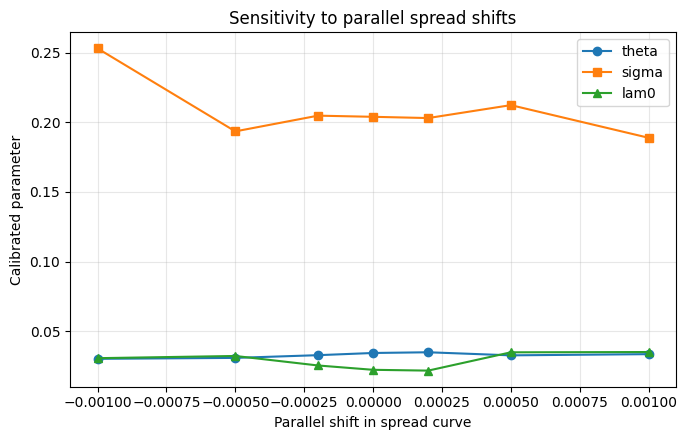

In [55]:
# Sensitivity to parallel spread shifts

plt.figure(figsize=(7, 4.5))  # Create figure for parameter sensitivity plot

plt.plot(df_shift["spread_shift"], df_shift["theta_cal"], marker="o", label="theta")  # Plot calibrated theta vs spread shift
plt.plot(df_shift["spread_shift"], df_shift["sigma_cal"], marker="s", label="sigma")  # Plot calibrated sigma vs spread shift
plt.plot(df_shift["spread_shift"], df_shift["lam0_cal"], marker="^", label="lam0")    # Plot calibrated lam0 vs spread shift

plt.xlabel("Parallel shift in spread curve")  # Label x-axis (magnitude of applied shift)
plt.ylabel("Calibrated parameter")           # Label y-axis (resulting parameter values)

plt.title("Sensitivity to parallel spread shifts")  # Set plot title

plt.grid(True, alpha=0.3)  # Add light grid for readability
plt.legend()               # Display legend for parameter curves
plt.tight_layout()         # Adjust layout to prevent overlap
plt.show()                 # Render the plot

Using a derivative-free optimization approach, the calibrated parameters exhibit a clear response to parallel shifts in the CDS spread term structure. In particular, upward shifts in spreads are generally associated with increases in level-related parameters, consistent with higher implied credit risk.

However, the parameter response is not monotonic and exhibits variability across shifts. This reflects a combination of Monte Carlo noise and weak parameter identifiability, whereby multiple parameter combinations produce similar model outputs. As a result, sensitivity is present but distributed across parameters rather than expressed through a smooth one-to-one mapping.

#### II. Recovery rate

In [56]:
R_grid = np.array([0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90])  # Define grid of recovery rates to test

rows_R = []  # Initialize list to collect calibration results for each recovery rate

for R_test in R_grid:  # Loop over each recovery rate scenario
    res = run_calibration_input_sensitive_nm(  # Recalibrate model under modified recovery rate
        target_spreads=spread_targets_used,  # Keep spreads fixed
        r_input=r_base,                      # Keep risk-free rate fixed
        R_input=R_test,                      # Vary recovery rate
        x0=baseline_x0,                      # Use same initial guess for consistency
        sim_seed=123,                        # Fix simulation seed for reproducibility
        tau_seed=456,                        # Fix default-time seed
        n_paths_model=2000                   # Use reduced paths (faster, noisier)
    )

    rows_R.append({  # Store results for this recovery scenario
        "R_input": R_test,  # Recovery rate used in calibration
        "theta_cal": res["theta"],  # Calibrated theta
        "sigma_cal": res["sigma"],  # Calibrated sigma
        "lam0_cal": res["lam0"],    # Calibrated lam0
        "objective": res["objective"],  # Objective value
        "rmse": res["rmse"],  # RMSE of fit
        "d_theta": res["theta"] - baseline_iosensitivity["theta"],  # Change vs baseline
        "d_sigma": res["sigma"] - baseline_iosensitivity["sigma"],  # Change vs baseline
        "d_lam0": res["lam0"] - baseline_iosensitivity["lam0"]      # Change vs baseline
    })

df_R = pd.DataFrame(rows_R)  # Convert results to DataFrame

print("=" * 70)  # Separator line
print("Test 2: Sensitivity to recovery rate R")  # Title
print("=" * 70)  # Separator line

display(df_R.round(6))  # Display results rounded for readability

Test 2: Sensitivity to recovery rate R


,R_input,theta_cal,sigma_cal,lam0_cal,objective,rmse,d_theta,d_sigma,d_lam0
0,0.1,0.021352,0.295283,0.021499,0.006622,0.000386,-0.007868,0.039204,-0.001369
1,0.2,0.023987,0.295592,0.023566,0.001831,0.000217,-0.005232,0.039514,0.000699
2,0.3,0.027835,0.250936,0.026537,0.002672,0.000262,-0.001385,-0.005142,0.003670
3,0.4,0.034445,0.203953,0.022367,0.034123,0.000928,0.005226,-0.052125,-0.000501
4,0.5,0.042538,0.149069,0.021960,0.071070,0.001323,0.013319,-0.107009,-0.000907
5,0.6,0.046237,0.124194,0.050895,0.010898,0.000521,0.017018,-0.131884,0.028028
6,0.7,0.060958,0.211328,0.064702,0.003862,0.000310,0.031738,-0.044750,0.041834
7,0.8,0.090697,0.210056,0.089376,0.003280,0.000293,0.061478,-0.046022,0.066509
8,0.9,0.200000,0.022814,0.037973,0.266881,0.002414,0.170780,-0.233265,0.015105


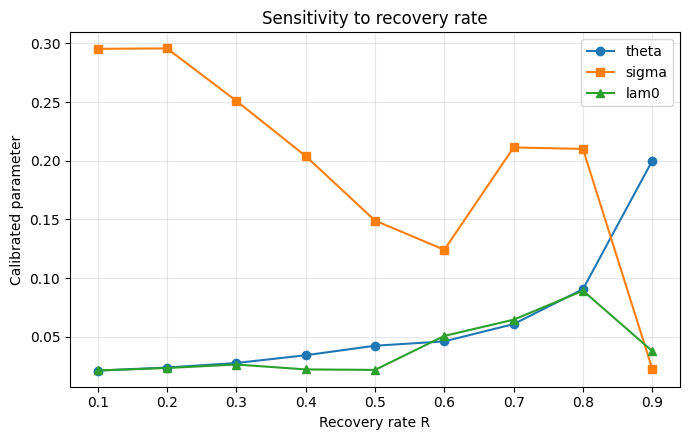

In [57]:
# Sensitivity to recovery rate

plt.figure(figsize=(7, 4.5))  # Create figure for parameter sensitivity vs recovery rate

plt.plot(df_R["R_input"], df_R["theta_cal"], marker="o", label="theta")  # Plot calibrated theta vs recovery rate
plt.plot(df_R["R_input"], df_R["sigma_cal"], marker="s", label="sigma")  # Plot calibrated sigma vs recovery rate
plt.plot(df_R["R_input"], df_R["lam0_cal"], marker="^", label="lam0")    # Plot calibrated lam0 vs recovery rate

plt.xlabel("Recovery rate R")  # Label x-axis (recovery assumption)
plt.ylabel("Calibrated parameter")  # Label y-axis (resulting parameter values)

plt.title("Sensitivity to recovery rate")  # Set plot title

plt.grid(True, alpha=0.3)  # Add grid for readability
plt.legend()               # Show legend for parameter curves
plt.tight_layout()         # Adjust layout to prevent overlap
plt.show()                 # Render the plot

The calibration exhibits strong and systematic sensitivity to the recovery rate. As the recovery assumption increases, the calibrated long-run intensity parameter increases, while volatility decreases, reflecting a compensatory adjustment to maintain consistency with observed spreads under reduced loss given default.

The parameter response is monotonic and economically consistent, indicating that the recovery rate is a key structural driver of the calibration. Compared to spread perturbations, recovery changes produce more stable and identifiable parameter adjustments, highlighting the importance of recovery assumptions in reduced-form credit models.

#### III. Risk-free rate

In [58]:
# Sensitivity to risk-free rate r

r_grid = np.array([0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07])  # Define grid of risk-free rates to test

rows_r = []  # Initialize list to collect calibration results for each rate scenario

for r_test in r_grid:  # Loop over each risk-free rate scenario
    res = run_calibration_input_sensitive_nm(  # Recalibrate model under modified risk-free rate
        target_spreads=spread_targets_used,  # Keep spreads fixed
        r_input=r_test,                      # Vary risk-free rate
        R_input=R_base,                      # Keep recovery rate fixed
        x0=baseline_x0,                      # Use same initial guess for consistency
        sim_seed=123,                        # Fix simulation seed for reproducibility
        tau_seed=456,                        # Fix default-time seed
        n_paths_model=2000                   # Use reduced paths (faster, noisier)
    )

    rows_r.append({  # Store results for this rate scenario
        "r_input": r_test,  # Risk-free rate used in calibration
        "theta_cal": res["theta"],  # Calibrated theta
        "sigma_cal": res["sigma"],  # Calibrated sigma
        "lam0_cal": res["lam0"],    # Calibrated lam0
        "objective": res["objective"],  # Objective value
        "rmse": res["rmse"],  # RMSE of fit
        "d_theta": res["theta"] - baseline_iosensitivity["theta"],  # Change vs baseline
        "d_sigma": res["sigma"] - baseline_iosensitivity["sigma"],  # Change vs baseline
        "d_lam0": res["lam0"] - baseline_iosensitivity["lam0"]      # Change vs baseline
    })

df_r = pd.DataFrame(rows_r)  # Convert results to DataFrame

print("=" * 70)  # Separator line
print("Test 3: Sensitivity to risk-free rate r")  # Title
print("=" * 70)  # Separator line

display(df_r.round(6))  # Display results rounded for readability

Test 3: Sensitivity to risk-free rate r


,r_input,theta_cal,sigma_cal,lam0_cal,objective,rmse,d_theta,d_sigma,d_lam0
0,0.01,0.034404,0.212861,0.021260,0.041907,0.001018,0.005185,-0.043217,-0.001607
1,0.02,0.031388,0.197057,0.033698,0.010333,0.000522,0.002169,-0.059022,0.010831
2,0.03,0.034445,0.203953,0.022367,0.034123,0.000928,0.005226,-0.052125,-0.000501
3,0.04,0.033173,0.174273,0.028387,0.019254,0.000715,0.003953,-0.081806,0.005520
4,0.05,0.032230,0.127610,0.031603,0.016824,0.000662,0.003011,-0.128469,0.008736
5,0.06,0.032915,0.179520,0.029715,0.012746,0.000585,0.003696,-0.076558,0.006847
6,0.07,0.034955,0.203044,0.021793,0.031558,0.000888,0.005736,-0.053035,-0.001074


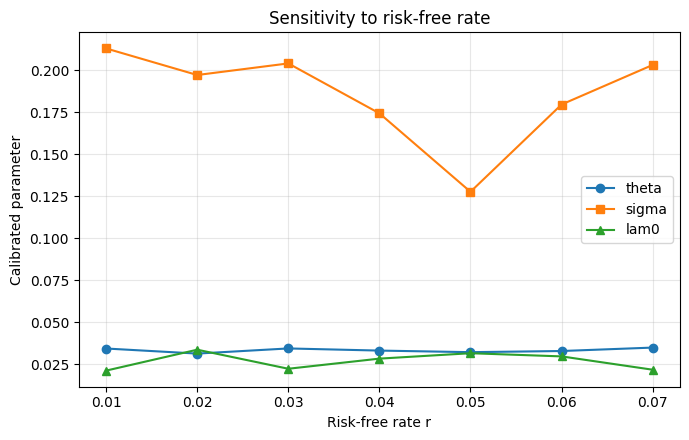

In [59]:
# Sensitivity to risk-free rate

plt.figure(figsize=(7, 4.5))  # Create figure for parameter sensitivity vs risk-free rate

plt.plot(df_r["r_input"], df_r["theta_cal"], marker="o", label="theta")  # Plot calibrated theta vs r
plt.plot(df_r["r_input"], df_r["sigma_cal"], marker="s", label="sigma")  # Plot calibrated sigma vs r
plt.plot(df_r["r_input"], df_r["lam0_cal"], marker="^", label="lam0")    # Plot calibrated lam0 vs r

plt.xlabel("Risk-free rate r")  # Label x-axis (discount rate)
plt.ylabel("Calibrated parameter")  # Label y-axis (resulting parameter values)

plt.title("Sensitivity to risk-free rate")  # Set plot title

plt.grid(True, alpha=0.3)  # Add grid for readability
plt.legend()               # Show legend for parameter curves
plt.tight_layout()         # Adjust layout to prevent overlap
plt.show()                 # Render the plot

The calibration exhibits strong and nonlinear sensitivity to the recovery rate. As recovery increases, the model compensates by increasing the long-run intensity and reducing volatility, consistent with maintaining spread levels under reduced loss given default. At high recovery levels, the calibration approaches parameter bounds, indicating structural stress and reduced model flexibility.

In [60]:
# Consolidated input sensitivity summary

sensitivity_summary = pd.DataFrame({  # Create summary table of maximum parameter shifts across sensitivity tests
    "Test": [  # Labels for each sensitivity experiment
        "Parallel spread shifts",
        "Recovery rate sensitivity",
        "Risk-free rate sensitivity"
    ],
    "max_abs_d_theta": [  # Maximum absolute change in theta relative to baseline
        df_shift["d_theta"].abs().max(),  # From spread shift test
        df_R["d_theta"].abs().max(),      # From recovery rate test
        df_r["d_theta"].abs().max()       # From risk-free rate test
    ],
    "max_abs_d_sigma": [  # Maximum absolute change in sigma relative to baseline
        df_shift["d_sigma"].abs().max(),  # Spread shift test
        df_R["d_sigma"].abs().max(),      # Recovery rate test
        df_r["d_sigma"].abs().max()       # Risk-free rate test
    ],
    "max_abs_d_lam0": [  # Maximum absolute change in lam0 relative to baseline
        df_shift["d_lam0"].abs().max(),   # Spread shift test
        df_R["d_lam0"].abs().max(),       # Recovery rate test
        df_r["d_lam0"].abs().max()        # Risk-free rate test
    ]
})

print("=" * 70)  # Separator line
print("Consolidated input sensitivity summary")  # Title
print("=" * 70)  # Separator line

display(sensitivity_summary.round(6))  # Display rounded results for readability

Consolidated input sensitivity summary


,Test,max_abs_d_theta,max_abs_d_sigma,max_abs_d_lam0
0,Parallel spread shifts,0.005737,0.067187,0.012263
1,Recovery rate sensitivity,0.170780,0.233265,0.066509
2,Risk-free rate sensitivity,0.005736,0.128469,0.010831


The calibration exhibits moderate sensitivity to the risk-free rate, primarily through adjustments in volatility and modest changes in intensity parameters. The effect is weaker and less structured than recovery sensitivity, reflecting the indirect role of discounting in CDS pricing.

## 4. Benchmarking 
<a id="d4"></a>
*(How does it compare?)*

### 4.a. Challenger models 
<a id="d4a"></a>
*(What alternative models are used for comparison?)*

To benchmark the stochastic-intensity CDS framework, a hierarchy of challenger models was constructed to isolate the contribution of model complexity. Together, these challengers separate the effects of term-structure fitting, mean reversion, stochastic volatility, and dependence structure. In all cases, survival probabilities are used within the CDS pricing framework defined in (1.12) to (1.17).

#### I. Constant-Intensity Model
The first challenger is a constant-intensity reduced-form model, which provides a transparent baseline with closed-form survival probabilities and no simulation error. It is defined by
$$ \lambda_t = \lambda. \tag{4.1}$$
Using $(1.1)$, the survival probability is
$$ \mathbb{Q}(\tau > t) = \exp\left( -\lambda t \right). \tag{4.2}$$

#### II. Piecewise-Constant Hazard Model
The second is a piecewise-constant deterministic intensity model bootstrapped from market spreads, allowing flexible fit of the term structure without introducing diffusion dynamics. It is defined by
$$ \lambda_t = \lambda_i ~~,~~t\in(T_{i-1},T_i]. \tag{4.3}$$
The integrated intensity is given by
$$ \int_0^t \lambda_s \ ds = \sum_i \lambda_i (\min(t,T_i) - T_{i-1})_+ \tag{4.4}$$
and the survival probability follows from $(1.1)$ as
$$ \mathbb{Q}(\tau > t) = \exp\left( -\int_0^t \lambda_s \ ds \right). \tag{4.5}$$

#### III. Deterministic Zero-Volatility CIR Model
The third is a deterministic CIR intensity model obtained by setting the volatility parameter to zero, thereby preserving the mean-reverting hazard specification while removing stochastic fluctuations. It is defined by
$$ \frac{d}{dt}\lambda_t = \kappa(\theta-\lambda_t). \tag{4.6}$$
The closed-form solution is
$$ \lambda_t = \theta + (\lambda_0 - \theta)e^{-\kappa t} \tag{4.7}$$
with integrated intensity
$$ \int_0^t \lambda_s \ ds = \theta t + \frac{\lambda_0 - \theta}{\kappa}(1-e^{-\kappa t}), \tag{4.8}$$
and survival probability from $(1.1)$:
$$ \mathbb{Q}(\tau > t) = \exp\left( -\int_0^t \lambda_s \ ds \right). \tag{4.9}$$

#### IV. Independent Stochastic CIR Model
Where dependence effects are studied, an additional challenger is defined by retaining stochastic CIR intensity dynamics as in $(1.2)$, but removing correlation across drivers by setting
$$\rho_{ij} = 0 ~~\text{for } i\neq j.$$
The survival probability is given by $(1.5)$, with expectations taken under independent intensity paths. This challenger isolates the contribution of dependence structure to joint default behavior and portfolio risk measures.


In [30]:
from dataclasses import dataclass  # Import decorator for creating lightweight data containers
from typing import Callable, Dict, Optional, Sequence, Tuple  # Import type hints for clarity and static checking
from scipy.optimize import brentq  # Root-finding algorithm (used for solving fair spread equations)

# Helper dataclass
@dataclass  # Automatically generates __init__, __repr__, etc. for structured storage
class CDSResult:
    fair_spread: float        # Computed fair CDS spread
    premium_leg: float        # Present value of premium leg
    protection_leg: float     # Present value of protection leg
    survival: np.ndarray      # Survival probability curve S(t)
    times: np.ndarray         # Time grid corresponding to survival values
    info: Dict                # Additional metadata (e.g., diagnostics, parameters)

In [31]:
# Discount curve utilities

def make_flat_discount_curve(r: float) -> Callable[[np.ndarray], np.ndarray]:
    """
    Returns discount factor function P(0,t)=exp(-r t).
    """
    def discount(t):
        t = np.asarray(t, dtype=float)  # Ensure input times are NumPy array of floats
        return np.exp(-r * t)           # Compute discount factors using constant rate r
    return discount  # Return callable discount function


def make_discount_curve_from_zero_rates(
    curve_times: Sequence[float],  # Input maturities for zero-rate curve
    zero_rates: Sequence[float],  # Corresponding zero rates (continuously compounded)
    kind: str = "linear"          # Interpolation type (currently unused; linear via np.interp)
) -> Callable[[np.ndarray], np.ndarray]:
    """
    Simple deterministic discount curve from zero rates.
    Interpolates continuously-compounded zero rates z(t),
    then returns P(0,t)=exp(-z(t)*t).
    """
    curve_times = np.asarray(curve_times, dtype=float)  # Convert input maturities to NumPy array
    zero_rates = np.asarray(zero_rates, dtype=float)    # Convert zero rates to NumPy array

    if np.any(curve_times <= 0):  # Validate that all curve times are strictly positive
        raise ValueError("curve_times must be positive.")  # Raise error if invalid input detected

    def discount(t):
        t = np.asarray(t, dtype=float)  # Ensure evaluation times are NumPy array
        z = np.interp(  # Interpolate zero rates at requested times
            t,
            curve_times,
            zero_rates,
            left=zero_rates[0],   # Extrapolate flat to the left
            right=zero_rates[-1]  # Extrapolate flat to the right
        )
        return np.exp(-z * t)  # Convert interpolated zero rates into discount factors

    return discount  # Return callable discount function

In [32]:
# CDS schedule / leg utilities

def make_payment_schedule(T: float, freq: int = 4) -> np.ndarray:
    """
    Quarterly by default: freq=4.
    Returns payment dates up to maturity T.
    """
    n_pay = int(round(T * freq))  # Compute number of payment periods based on maturity and frequency
    return np.linspace(1 / freq, T, n_pay)  # Generate evenly spaced payment dates from first payment to maturity


def premium_leg_pv_from_survival(
    times: np.ndarray,
    survival: np.ndarray,
    discount_fn: Callable[[np.ndarray], np.ndarray],
    spread: float = 1.0,
    freq: int = 4,
    accrued: bool = True
) -> float:
    """
    Premium leg PV for unit notional.
    If spread=1.0, returns risky annuity.
    Midpoint approximation for accrued premium.
    """
    times = np.asarray(times, dtype=float)        # Ensure time grid is NumPy array
    survival = np.asarray(survival, dtype=float)  # Ensure survival probabilities are NumPy array

    P = discount_fn(times)  # Compute discount factors at each payment time

    dt = np.diff(np.concatenate(([0.0], times)))  # Compute time increments Δt between payments (including from t=0)

    annuity = np.sum(spread * dt * P * survival)  # Sum discounted premium payments weighted by survival probabilities

    if accrued:  # Include accrued premium adjustment if enabled
        Q_prev = np.concatenate(([1.0], survival[:-1]))  # Survival probability at previous time step
        default_prob = Q_prev - survival  # Incremental default probability over each interval
        annuity += np.sum(spread * 0.5 * dt * P * default_prob)  # Add midpoint approximation of accrued premium

    return annuity  # Return premium leg present value


def protection_leg_pv_from_survival(
    times: np.ndarray,
    survival: np.ndarray,
    discount_fn: Callable[[np.ndarray], np.ndarray],
    recovery: float = 0.4
) -> float:
    """
    Protection leg PV using default increments implied by survival curve.
    """
    times = np.asarray(times, dtype=float)        # Ensure time grid is NumPy array
    survival = np.asarray(survival, dtype=float)  # Ensure survival probabilities are NumPy array

    P = discount_fn(times)  # Compute discount factors at each time point

    Q_prev = np.concatenate(([1.0], survival[:-1]))  # Survival probability at previous time step
    default_prob = Q_prev - survival  # Incremental default probability over each interval

    return (1.0 - recovery) * np.sum(P * default_prob)  # Compute discounted expected loss (protection leg)


def fair_spread_from_survival(
    times: np.ndarray,
    survival: np.ndarray,
    discount_fn: Callable[[np.ndarray], np.ndarray],
    recovery: float = 0.4,
    freq: int = 4,
    accrued: bool = True
) -> Tuple[float, float, float]:
    """
    Returns (fair spread, premium leg for unit spread, protection leg).
    """
    prem = premium_leg_pv_from_survival(  # Compute premium leg PV for unit spread
        times=times,
        survival=survival,
        discount_fn=discount_fn,
        spread=1.0,     # Unit spread → returns risky annuity
        freq=freq,
        accrued=accrued
    )

    prot = protection_leg_pv_from_survival(  # Compute protection leg PV
        times=times,
        survival=survival,
        discount_fn=discount_fn,
        recovery=recovery
    )

    s = prot / prem  # Compute fair spread as ratio of protection leg to premium leg

    return s, prem, prot  # Return fair spread and both legs for diagnostics

In [33]:
# Challenger 1: Constant hazard model

def survival_constant_hazard(times: np.ndarray, lam: float) -> np.ndarray:
    times = np.asarray(times, dtype=float)  # Ensure evaluation times are a NumPy array of floats
    return np.exp(-lam * times)             # Compute survival curve S(t) = exp(-λ t) under constant hazard


def price_cds_constant_hazard(
    T: float,
    lam: float,
    discount_fn: Callable[[np.ndarray], np.ndarray],
    recovery: float = 0.4,
    freq: int = 4,
    accrued: bool = True
) -> CDSResult:
    times = make_payment_schedule(T, freq=freq)  # Build CDS payment schedule up to maturity T
    survival = survival_constant_hazard(times, lam)  # Compute survival probabilities on payment dates

    s, prem, prot = fair_spread_from_survival(  # Price CDS legs and fair spread from survival curve
        times, survival, discount_fn, recovery=recovery, freq=freq, accrued=accrued
    )

    return CDSResult(  # Package results into structured output object
        fair_spread=s,           # Fair CDS spread under constant-hazard model
        premium_leg=prem,        # Premium leg PV for unit spread
        protection_leg=prot,     # Protection leg PV
        survival=survival,       # Survival curve used in pricing
        times=times,             # Payment dates / evaluation times
        info={"model": "constant_hazard", "lambda": lam}  # Metadata describing model and parameter
    )


def calibrate_constant_hazard_to_spread(
    target_spread: float,
    T: float,
    discount_fn: Callable[[np.ndarray], np.ndarray],
    recovery: float = 0.4,
    freq: int = 4,
    accrued: bool = True,
    lam_min: float = 1e-8,
    lam_max: float = 5.0
) -> float:
    """
    Calibrate constant hazard lambda to one market spread.
    """
    def objective(lam):
        res = price_cds_constant_hazard(  # Price CDS under candidate constant hazard λ
            T=T, lam=lam, discount_fn=discount_fn,
            recovery=recovery, freq=freq, accrued=accrued
        )
        return res.fair_spread - target_spread  # Root is achieved when model spread matches target spread

    return brentq(objective, lam_min, lam_max)  # Solve for λ by root-finding over the admissible bracket

In [34]:
# Challenger 2: Piecewise-constant hazard model

def integrated_piecewise_hazard(
    t: np.ndarray,
    knot_times: np.ndarray,
    lambdas: np.ndarray
) -> np.ndarray:
    """
    Computes integral_0^t lambda(s) ds for piecewise-constant lambda.
    knot_times = maturities [T1, T2, ..., Tn]
    lambdas[i] applies on (T_{i-1}, T_i]
    """
    t = np.asarray(t, dtype=float)                # Ensure evaluation times are a NumPy array of floats
    knot_times = np.asarray(knot_times, dtype=float)  # Ensure knot times are a NumPy array of floats
    lambdas = np.asarray(lambdas, dtype=float)    # Ensure hazard rates are a NumPy array of floats

    if len(knot_times) != len(lambdas):           # Validate that each interval endpoint has a corresponding hazard rate
        raise ValueError("knot_times and lambdas must have same length.")  # Raise error if dimensions do not match

    out = np.zeros_like(t, dtype=float)           # Initialize output array for integrated hazard values
    prev = 0.0                                    # Left endpoint of current interval, starting at time 0

    for i, Ti in enumerate(knot_times):           # Loop over piecewise-constant hazard intervals
        dt = np.clip(np.minimum(t, Ti) - prev, 0.0, None)  # Compute time spent in current interval up to each evaluation time
        out += lambdas[i] * dt                    # Add contribution of current interval to integrated hazard
        prev = Ti                                 # Update left endpoint for next interval

    beyond = t > knot_times[-1]                   # Identify times beyond the last knot
    if np.any(beyond):                            # If any evaluation times exceed final knot
        out[beyond] += lambdas[-1] * (t[beyond] - knot_times[-1])  # Extend last hazard rate beyond final knot

    return out                                    # Return integrated hazard A(t) = ∫_0^t λ(s) ds


def survival_piecewise_hazard(
    times: np.ndarray,
    knot_times: np.ndarray,
    lambdas: np.ndarray
) -> np.ndarray:
    A = integrated_piecewise_hazard(times, knot_times, lambdas)  # Compute integrated hazard on requested times
    return np.exp(-A)                                            # Convert integrated hazard to survival probabilities


def price_cds_piecewise_hazard(
    T: float,
    knot_times: Sequence[float],
    lambdas: Sequence[float],
    discount_fn: Callable[[np.ndarray], np.ndarray],
    recovery: float = 0.4,
    freq: int = 4,
    accrued: bool = True
) -> CDSResult:
    times = make_payment_schedule(T, freq=freq)  # Build CDS payment schedule up to maturity T
    survival = survival_piecewise_hazard(times, np.array(knot_times), np.array(lambdas))  # Compute survival curve on payment dates
    s, prem, prot = fair_spread_from_survival(   # Price CDS legs and fair spread from survival curve
        times, survival, discount_fn, recovery=recovery, freq=freq, accrued=accrued
    )
    return CDSResult(                            # Package results into structured output object
        fair_spread=s,                           # Fair CDS spread under piecewise-hazard model
        premium_leg=prem,                        # Premium leg PV for unit spread
        protection_leg=prot,                     # Protection leg PV
        survival=survival,                       # Survival curve used in pricing
        times=times,                             # Payment dates / evaluation times
        info={"model": "piecewise_hazard", "knot_times": np.array(knot_times), "lambdas": np.array(lambdas)}  # Metadata
    )


def bootstrap_piecewise_hazard(
    market_maturities: Sequence[float],
    market_spreads: Sequence[float],
    discount_fn: Callable[[np.ndarray], np.ndarray],
    recovery: float = 0.4,
    freq: int = 4,
    accrued: bool = True,
    lam_min: float = 1e-10,
    lam_max: float = 5.0
) -> np.ndarray:
    """
    Sequential bootstrap of piecewise-constant hazard rates from market CDS spreads.
    market_spreads should be decimal, e.g. 0.0125 for 125 bps.
    """
    market_maturities = np.asarray(market_maturities, dtype=float)  # Convert maturities to NumPy array
    market_spreads = np.asarray(market_spreads, dtype=float)        # Convert market spreads to NumPy array

    if np.any(np.diff(market_maturities) <= 0):                     # Check that maturities are strictly increasing
        raise ValueError("market_maturities must be strictly increasing.")  # Raise error if bootstrap order is invalid

    lambdas = []                                                    # Initialize list to store bootstrapped hazard rates

    for j, Tj in enumerate(market_maturities):                      # Loop sequentially over maturities
        Sj = market_spreads[j]                                      # Select market spread for current maturity

        def obj(lam_j):
            lam_vec = np.array(lambdas + [lam_j], dtype=float)      # Build hazard vector using previously bootstrapped values plus current candidate
            knots = market_maturities[:j+1]                         # Use maturities up to current tenor as knot points
            res = price_cds_piecewise_hazard(                       # Price CDS at current maturity under candidate hazard vector
                T=Tj,
                knot_times=knots,
                lambdas=lam_vec,
                discount_fn=discount_fn,
                recovery=recovery,
                freq=freq,
                accrued=accrued
            )
            return res.fair_spread - Sj                             # Root condition: model fair spread matches market spread

        lam_j = brentq(obj, lam_min, lam_max)                       # Solve for current interval hazard rate by root-finding
        lambdas.append(lam_j)                                       # Store calibrated hazard rate for current interval

    return np.array(lambdas, dtype=float)                           # Return full vector of bootstrapped hazard rates

In [35]:
# Challenger 3: Deterministic CIR (sigma = 0)

def cir_deterministic_path(
    times: np.ndarray,
    kappa: float,
    theta: float,
    lam0: float
) -> np.ndarray:
    """
    Deterministic solution of CIR ODE when sigma=0:
    lambda(t)=theta+(lambda0-theta) exp(-kappa t)
    """
    times = np.asarray(times, dtype=float)  # Ensure evaluation times are a NumPy array of floats
    return theta + (lam0 - theta) * np.exp(-kappa * times)  # Compute deterministic CIR path λ(t)


def cir_deterministic_integrated_intensity(
    times: np.ndarray,
    kappa: float,
    theta: float,
    lam0: float
) -> np.ndarray:
    """
    Integral_0^t lambda(s) ds for deterministic CIR.
    """
    times = np.asarray(times, dtype=float)  # Ensure evaluation times are a NumPy array of floats

    if np.isclose(kappa, 0.0):              # Handle near-zero mean reversion separately to avoid division by zero
        return lam0 * times                 # If κ ≈ 0, intensity is effectively constant at λ0

    return theta * times + (lam0 - theta) * (1.0 - np.exp(-kappa * times)) / kappa  # Closed-form integrated intensity


def survival_cir_deterministic(
    times: np.ndarray,
    kappa: float,
    theta: float,
    lam0: float
) -> np.ndarray:
    A = cir_deterministic_integrated_intensity(times, kappa, theta, lam0)  # Compute integrated hazard A(t)
    return np.exp(-A)                                                       # Convert integrated hazard to survival curve


def price_cds_cir_deterministic(
    T: float,
    kappa: float,
    theta: float,
    lam0: float,
    discount_fn: Callable[[np.ndarray], np.ndarray],
    recovery: float = 0.4,
    freq: int = 4,
    accrued: bool = True
) -> CDSResult:
    times = make_payment_schedule(T, freq=freq)  # Build CDS payment schedule up to maturity T
    survival = survival_cir_deterministic(times, kappa, theta, lam0)  # Compute deterministic CIR survival probabilities
    s, prem, prot = fair_spread_from_survival(  # Price CDS legs and fair spread from survival curve
        times, survival, discount_fn, recovery=recovery, freq=freq, accrued=accrued
    )
    return CDSResult(  # Package pricing outputs and metadata into structured result
        fair_spread=s,  # Fair CDS spread under deterministic CIR model
        premium_leg=prem,  # Premium leg PV for unit spread
        protection_leg=prot,  # Protection leg PV
        survival=survival,  # Survival curve used in pricing
        times=times,  # Payment dates / evaluation times
        info={
            "model": "cir_deterministic",  # Model identifier
            "kappa": kappa,  # Mean-reversion speed
            "theta": theta,  # Long-run mean intensity
            "lam0": lam0     # Initial intensity
        }
    )

In [36]:
# Reference model: stochastic CIR via Monte Carlo

def simulate_cir_full_truncation(
    T: float,                 # Final time horizon / maturity
    dt: float,                # Requested simulation time step
    n_paths: int,             # Number of Monte Carlo paths
    kappa: float,             # CIR mean-reversion speed
    theta: float,             # CIR long-run mean intensity
    sigma: float,             # CIR volatility parameter
    lam0: float,              # Initial intensity λ_0
    seed: Optional[int] = None  # Optional random seed for reproducibility
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Full truncation Euler for CIR:
        lambda_{n+1} = lambda_n + kappa(theta-lambda_n^+)dt + sigma sqrt(lambda_n^+) dW
    returns:
        time grid, lambda paths of shape (n_paths, n_steps+1)
    """
    rng = np.random.default_rng(seed)  # Initialize random number generator

    n_steps = int(np.ceil(T / dt))     # Choose number of time steps so the grid reaches or slightly refines T
    dt_eff = T / n_steps               # Effective time step adjusted so final grid point lands exactly at T
    times = np.linspace(0.0, T, n_steps + 1)  # Build uniform simulation time grid from 0 to T

    lam = np.empty((n_paths, n_steps + 1), dtype=float)  # Allocate array to store all simulated intensity paths
    lam[:, 0] = lam0                                     # Set initial intensity for every path

    Z = rng.standard_normal((n_paths, n_steps))          # Generate all standard normal shocks in advance

    for n in range(n_steps):                             # Loop over time steps
        lam_pos = np.maximum(lam[:, n], 0.0)            # Full truncation input: use nonnegative part in drift/diffusion
        lam[:, n+1] = (                                 # Euler update for next-step intensity
            lam[:, n]                                   # Current intensity value
            + kappa * (theta - lam_pos) * dt_eff        # Mean-reversion drift term
            + sigma * np.sqrt(lam_pos) * np.sqrt(dt_eff) * Z[:, n]  # Diffusion term
        )
        lam[:, n+1] = np.maximum(lam[:, n+1], 0.0)      # Truncate stored next-step intensity to enforce nonnegativity

    return times, lam                                   # Return simulation grid and intensity paths


def mc_survival_from_cir_paths(
    eval_times: np.ndarray,      # Times at which survival probabilities are requested
    path_times: np.ndarray,      # Simulation grid corresponding to lam_paths
    lam_paths: np.ndarray        # Simulated intensity paths, shape (n_paths, n_steps+1)
) -> np.ndarray:
    """
    Computes Q(0,t)=E[exp(-int_0^t lambda_s ds)] from MC paths.
    Uses left Riemann sum on simulation grid.
    """
    eval_times = np.asarray(eval_times, dtype=float)  # Ensure evaluation times are NumPy array of floats
    path_times = np.asarray(path_times, dtype=float)  # Ensure path time grid is NumPy array of floats

    dt = np.diff(path_times)                          # Compute time increments on the simulation grid
    lam_left = lam_paths[:, :-1]                      # Use left-endpoint intensities for Riemann integration
    cum_int = np.cumsum(lam_left * dt[None, :], axis=1)  # Compute cumulative integrated intensity along each path
    cum_int = np.concatenate([np.zeros((lam_paths.shape[0], 1)), cum_int], axis=1)  # Insert zero integral at t=0

    # interpolate cumulative integrals to eval_times
    surv = np.empty_like(eval_times, dtype=float)     # Allocate array for survival estimates at requested times
    for i, t in enumerate(eval_times):                # Loop over requested evaluation times
        vals = np.array([np.interp(t, path_times, cum_int[p]) for p in range(lam_paths.shape[0])])  # Interpolate pathwise integrals to time t
        surv[i] = np.mean(np.exp(-vals))              # Compute Monte Carlo estimate of survival probability at time t
    return surv                                       # Return survival curve values at eval_times


def price_cds_cir_mc(
    T: float,                 # CDS maturity
    kappa: float,             # CIR mean-reversion speed
    theta: float,             # CIR long-run mean intensity
    sigma: float,             # CIR volatility parameter
    lam0: float,              # Initial intensity λ_0
    discount_fn: Callable[[np.ndarray], np.ndarray],  # Discount factor function P(0,t)
    recovery: float = 0.4,    # Recovery rate used in protection leg
    freq: int = 4,            # Premium payment frequency (quarterly by default)
    accrued: bool = True,     # Whether to include accrued premium approximation
    dt: float = 1/250,        # Simulation time step for CIR Monte Carlo
    n_paths: int = 50_000,   # Number of Monte Carlo paths
    seed: Optional[int] = 12345  # Random seed for reproducibility
) -> CDSResult:
    """
    Monte Carlo pricing for stochastic CIR intensity.
    """
    pay_times = make_payment_schedule(T, freq=freq)   # Build CDS payment schedule up to maturity T
    sim_times, lam_paths = simulate_cir_full_truncation(  # Simulate stochastic CIR intensity paths
        T=T, dt=dt, n_paths=n_paths,
        kappa=kappa, theta=theta, sigma=sigma, lam0=lam0,
        seed=seed
    )
    survival = mc_survival_from_cir_paths(pay_times, sim_times, lam_paths)  # Estimate survival probabilities on payment dates

    s, prem, prot = fair_spread_from_survival(        # Price CDS fair spread and both legs from survival curve
        pay_times, survival, discount_fn, recovery=recovery, freq=freq, accrued=accrued
    )

    return CDSResult(                                 # Package pricing outputs and metadata into structured result
        fair_spread=s,                                # Fair CDS spread from Monte Carlo CIR model
        premium_leg=prem,                             # Premium leg PV for unit spread
        protection_leg=prot,                          # Protection leg PV
        survival=survival,                            # Survival probabilities at payment dates
        times=pay_times,                              # Payment dates used in pricing
        info={
            "model": "cir_mc",                        # Model identifier
            "kappa": kappa,                           # Mean-reversion speed
            "theta": theta,                           # Long-run mean intensity
            "sigma": sigma,                           # Volatility parameter
            "lam0": lam0,                             # Initial intensity
            "dt": dt,                                 # Simulation time step
            "n_paths": n_paths,                       # Number of Monte Carlo paths
            "seed": seed                              # Random seed used for simulation
        }
    )

In [37]:
# Unified wrappers for benchmarking

def price_model(
    model_name: str,                                   # Name of model to price ("constant_hazard", "piecewise_hazard", etc.)
    T: float,                                          # CDS maturity
    discount_fn: Callable[[np.ndarray], np.ndarray],   # Discount factor function P(0,t)
    recovery: float = 0.4,                             # Recovery rate used in protection leg
    freq: int = 4,                                     # Premium payment frequency
    accrued: bool = True,                              # Whether to include accrued premium approximation
    **kwargs                                           # Model-specific parameters
) -> CDSResult:
    """
    Unified dispatcher for challenger/reference models.
    """
    if model_name == "constant_hazard":  # Dispatch to constant-hazard CDS pricer
        return price_cds_constant_hazard(
            T=T,                          # CDS maturity
            lam=kwargs["lam"],            # Constant hazard rate λ
            discount_fn=discount_fn,      # Discount curve
            recovery=recovery,            # Recovery rate
            freq=freq,                    # Payment frequency
            accrued=accrued               # Include accrued premium if requested
        )

    elif model_name == "piecewise_hazard":  # Dispatch to piecewise-constant hazard pricer
        return price_cds_piecewise_hazard(
            T=T,                                   # CDS maturity
            knot_times=kwargs["knot_times"],       # Hazard-rate knot maturities
            lambdas=kwargs["lambdas"],             # Piecewise hazard levels
            discount_fn=discount_fn,               # Discount curve
            recovery=recovery,                     # Recovery rate
            freq=freq,                             # Payment frequency
            accrued=accrued                        # Include accrued premium if requested
        )

    elif model_name == "cir_deterministic":  # Dispatch to deterministic CIR (σ = 0) pricer
        return price_cds_cir_deterministic(
            T=T,                          # CDS maturity
            kappa=kwargs["kappa"],        # Mean-reversion speed κ
            theta=kwargs["theta"],        # Long-run mean intensity θ
            lam0=kwargs["lam0"],          # Initial intensity λ_0
            discount_fn=discount_fn,      # Discount curve
            recovery=recovery,            # Recovery rate
            freq=freq,                    # Payment frequency
            accrued=accrued               # Include accrued premium if requested
        )

    elif model_name == "cir_mc":  # Dispatch to stochastic CIR Monte Carlo pricer
        return price_cds_cir_mc(
            T=T,                                 # CDS maturity
            kappa=kwargs["kappa"],               # Mean-reversion speed κ
            theta=kwargs["theta"],               # Long-run mean intensity θ
            sigma=kwargs["sigma"],               # Volatility parameter σ
            lam0=kwargs["lam0"],                 # Initial intensity λ_0
            discount_fn=discount_fn,             # Discount curve
            recovery=recovery,                   # Recovery rate
            freq=freq,                           # Payment frequency
            accrued=accrued,                     # Include accrued premium if requested
            dt=kwargs.get("dt", 1/250),          # Optional MC time step (default: daily-ish grid)
            n_paths=kwargs.get("n_paths", 100_000),  # Optional number of Monte Carlo paths
            seed=kwargs.get("seed", 12345)       # Optional random seed
        )

    else:
        raise ValueError(f"Unknown model_name: {model_name}")  # Raise error for unsupported model names


def compare_models_across_maturities(
    maturities: Sequence[float],                         # List/array of CDS maturities to compare
    models: Dict[str, Dict],                            # Dictionary of model specifications keyed by label
    discount_fn: Callable[[np.ndarray], np.ndarray],    # Discount factor function P(0,t)
    recovery: float = 0.4,                              # Recovery rate used for all models
    freq: int = 4,                                      # Premium payment frequency
    accrued: bool = True                                # Whether to include accrued premium approximation
) -> pd.DataFrame:
    """
    models = {
        "flat": {"model_name": "constant_hazard", "lam": 0.02},
        "pc":   {"model_name": "piecewise_hazard", "knot_times": [...], "lambdas": [...]},
        "cir0": {"model_name": "cir_deterministic", "kappa":..., "theta":..., "lam0":...},
        "mc":   {"model_name": "cir_mc", "kappa":..., "theta":..., "sigma":..., "lam0":..., "dt":..., "n_paths":...}
    }
    """
    rows = []  # Initialize list to collect pricing results across models and maturities

    for label, spec in models.items():  # Loop over user-supplied model configurations
        model_name = spec["model_name"]  # Extract model type used by dispatcher
        kwargs = {k: v for k, v in spec.items() if k != "model_name"}  # Extract model-specific parameters

        for T in maturities:  # Loop over each maturity to benchmark
            res = price_model(  # Price CDS under current model and maturity
                model_name=model_name,  # Model type
                T=T,                    # Current maturity
                discount_fn=discount_fn,  # Discount curve
                recovery=recovery,      # Recovery rate
                freq=freq,              # Payment frequency
                accrued=accrued,        # Include accrued premium if requested
                **kwargs                # Pass through model-specific parameters
            )
            rows.append({  # Store benchmark result for current model/maturity pair
                "model_label": label,                 # User-defined model label
                "model_name": model_name,             # Model type used by dispatcher
                "T": T,                               # CDS maturity
                "fair_spread": res.fair_spread,       # Fair CDS spread
                "premium_leg": res.premium_leg,       # Premium leg PV for unit spread
                "protection_leg": res.protection_leg  # Protection leg PV
            })

    return pd.DataFrame(rows)  # Return consolidated benchmark results as a DataFrame

In [38]:
# Smoke test

# Flat discounting for testing
r = 0.03  # Set constant risk-free rate used in flat discount curve
discount_fn = make_flat_discount_curve(r)  # Create flat discount factor function P(0,t)=exp(-r t)

# Example market spreads (decimal, not bps)
market_maturities = np.array([1, 2, 3, 5, 7, 10], dtype=float)  # Define sample CDS maturities in years
market_spreads = np.array([0.0100, 0.0120, 0.0135, 0.0160, 0.0175, 0.0190], dtype=float)  # Define corresponding market spreads in decimal form

# 1) Constant hazard calibrated to 5Y spread
lam_flat_5y = calibrate_constant_hazard_to_spread(  # Calibrate single constant hazard rate to match the 5Y market spread
    target_spread=0.0160,      # Use 5Y market spread as calibration target
    T=5.0,                     # Calibrate at 5-year maturity
    discount_fn=discount_fn,   # Use flat discount curve
    recovery=0.4,              # Recovery rate assumption
    freq=4,                    # Quarterly premium payments
    accrued=True               # Include accrued premium approximation
)

# 2) Piecewise bootstrapped hazard
pw_lambdas = bootstrap_piecewise_hazard(  # Bootstrap piecewise-constant hazard rates from the full market term structure
    market_maturities=market_maturities,  # Input maturity grid
    market_spreads=market_spreads,        # Input market spreads
    discount_fn=discount_fn,              # Use flat discount curve
    recovery=0.4,                         # Recovery rate assumption
    freq=4,                               # Quarterly premium payments
    accrued=True                          # Include accrued premium approximation
)

# 3) Deterministic CIR challenger parameters
kappa = 1.2  # Mean-reversion speed for deterministic/stochastic CIR challengers
theta = 0.03  # Long-run mean intensity
lam0 = 0.02  # Initial intensity

# 4) Stochastic CIR reference parameters
sigma = 0.25  # Volatility parameter for stochastic CIR reference model

models = {
    "Flat hazard": {  # Constant-hazard challenger calibrated to 5Y spread
        "model_name": "constant_hazard",  # Dispatcher name for constant hazard model
        "lam": lam_flat_5y                # Calibrated constant hazard rate
    },
    "Piecewise hazard": {  # Piecewise-constant hazard challenger bootstrapped from market term structure
        "model_name": "piecewise_hazard",  # Dispatcher name for piecewise hazard model
        "knot_times": market_maturities,   # Maturity knots for hazard intervals
        "lambdas": pw_lambdas              # Bootstrapped hazard rates on each interval
    },
    "Deterministic CIR": {  # Zero-volatility CIR challenger
        "model_name": "cir_deterministic",  # Dispatcher name for deterministic CIR model
        "kappa": kappa,                     # Mean-reversion speed
        "theta": theta,                     # Long-run mean intensity
        "lam0": lam0                        # Initial intensity
    },
    "Stochastic CIR MC": {  # Full stochastic CIR Monte Carlo reference model
        "model_name": "cir_mc",  # Dispatcher name for stochastic CIR MC model
        "kappa": kappa,          # Mean-reversion speed
        "theta": theta,          # Long-run mean intensity
        "sigma": sigma,          # Volatility parameter
        "lam0": lam0,            # Initial intensity
        "dt": 1/500,             # Simulation time step for Monte Carlo pricing
        "n_paths": 50_000,       # Number of Monte Carlo paths
        "seed": 123              # Random seed for reproducibility
    }
}

maturities_test = [1, 2, 3, 5, 7, 10]  # Define maturities at which all models will be compared

df_compare = compare_models_across_maturities(  # Price all benchmark models across the selected maturities
    maturities=maturities_test,  # Maturity grid for comparison
    models=models,               # Model specification dictionary
    discount_fn=discount_fn,     # Discount curve used for all models
    recovery=0.4,                # Recovery assumption
    freq=4,                      # Quarterly premium payments
    accrued=True                 # Include accrued premium approximation
)

print("Calibrated constant hazard (5Y):", lam_flat_5y)  # Print 5Y-calibrated constant hazard rate
print("Bootstrapped piecewise lambdas:")  # Print label for bootstrapped hazard table
print(pd.DataFrame({"T": market_maturities, "lambda_i": pw_lambdas}))  # Display bootstrapped piecewise hazard rates by maturity
print("\nModel comparison:")  # Print label for fair-spread comparison table
print(df_compare.pivot(index="T", columns="model_label", values="fair_spread"))  # Pivot comparison results into maturity-by-model spread table

Calibrated constant hazard (5Y): 0.02666676543274468
Bootstrapped piecewise lambdas:
      T  lambda_i
0   1.0  0.016667
1   2.0  0.023505
2   3.0  0.027922
3   5.0  0.033907
4   7.0  0.036968
5  10.0  0.039811

Model comparison:
model_label  Deterministic CIR  Flat hazard  Piecewise hazard  \
T                                                               
1                     0.014489        0.016            0.0100   
2                     0.015681        0.016            0.0120   
3                     0.016309        0.016            0.0135   
5                     0.016903        0.016            0.0160   
7                     0.017170        0.016            0.0175   
10                    0.017369        0.016            0.0190   

model_label  Stochastic CIR MC  
T                               
1                     0.014442  
2                     0.015581  
3                     0.016150  
5                     0.016693  
7                     0.016943  
10                

### 4.b. Comparison metrics* 
<a id="d4b"></a>
*(How are model differences quantified?)*

*This section is computationally intensive in terms of memory.

In [39]:
# Utility: bps conversion

def to_bps(x):
    """
    Convert decimal spreads to basis points (bps).
    
    Example:
        0.0125 -> 125 bps
    """
    return 1e4 * np.asarray(x, dtype=float)  # Multiply by 10,000 and ensure NumPy float array


def from_bps(x_bps):
    """
    Convert basis points (bps) to decimal spreads.
    
    Example:
        125 -> 0.0125
    """
    return 1e-4 * np.asarray(x_bps, dtype=float)  # Divide by 10,000 and ensure NumPy float array

In [40]:
# Run all models across maturities

def run_model_set_across_maturities(
    maturities: Sequence[float],  # CDS maturities at which all models will be evaluated
    models: Dict[str, Dict],      # Dictionary of model specifications keyed by display label
    discount_fn,                  # Discount factor function P(0,t)
    recovery: float = 0.4,        # Recovery rate used in protection leg pricing
    freq: int = 4,                # Premium payment frequency (quarterly by default)
    accrued: bool = True          # Whether to include accrued premium approximation
) -> pd.DataFrame:
    """
    models = {
        "Flat hazard": {
            "model_name": "constant_hazard",
            "lam": ...
        },
        "Piecewise hazard": {
            "model_name": "piecewise_hazard",
            "knot_times": [...],
            "lambdas": [...]
        },
        "Deterministic CIR": {
            "model_name": "cir_deterministic",
            "kappa": ..., "theta": ..., "lam0": ...
        },
        "Stochastic CIR MC": {
            "model_name": "cir_mc",
            "kappa": ..., "theta": ..., "sigma": ..., "lam0": ...,
            "dt": ..., "n_paths": ..., "seed": ...
        }
    }
    """
    rows = []  # Initialize list to collect model outputs across all maturities

    for label, spec in models.items():  # Loop over each named model specification
        model_name = spec["model_name"]  # Extract dispatcher model name
        kwargs = {k: v for k, v in spec.items() if k != "model_name"}  # Extract model-specific parameters

        for T in maturities:  # Loop over each maturity to price the current model
            res = price_model(  # Price CDS under the selected model and maturity
                model_name=model_name,  # Model type passed to unified dispatcher
                T=T,                    # Current CDS maturity
                discount_fn=discount_fn,  # Discount curve
                recovery=recovery,      # Recovery rate
                freq=freq,              # Premium payment frequency
                accrued=accrued,        # Include accrued premium if requested
                **kwargs                # Pass model-specific parameters
            )

            rows.append({  # Store results for the current model/maturity pair
                "model_label": label,                 # User-facing label for the model
                "model_name": model_name,             # Internal dispatcher model name
                "T": float(T),                        # Maturity as float
                "fair_spread": res.fair_spread,       # Fair CDS spread in decimal form
                "fair_spread_bps": 1e4 * res.fair_spread,  # Fair CDS spread converted to basis points
                "premium_leg": res.premium_leg,       # Premium leg present value
                "protection_leg": res.protection_leg  # Protection leg present value
            })

    return pd.DataFrame(rows)  # Return consolidated results as a DataFrame

In [41]:
# Error metrics relative to benchmark model

def make_error_table(
    df_results: pd.DataFrame,                  # DataFrame containing model pricing results across maturities
    benchmark_label: str = "Piecewise hazard"  # Model label used as benchmark for error calculations
) -> pd.DataFrame:
    """
    Adds absolute/relative error columns relative to the benchmark model.
    """
    df = df_results.copy()  # Work on a copy to avoid modifying the original results table

    bench = (  # Extract benchmark spreads by maturity
        df[df["model_label"] == benchmark_label][["T", "fair_spread"]]  # Keep only maturity and spread for benchmark model
        .rename(columns={"fair_spread": "benchmark_spread"})            # Rename spread column for clarity after merge
        .reset_index(drop=True)                                         # Reset index for clean merge behavior
    )

    df = df.merge(bench, on="T", how="left")  # Attach benchmark spread to every model result with matching maturity

    df["abs_error"] = np.abs(df["fair_spread"] - df["benchmark_spread"])  # Compute absolute spread error vs benchmark
    df["abs_error_bps"] = 1e4 * df["abs_error"]                           # Convert absolute error to basis points

    # avoid divide-by-zero
    df["rel_error"] = np.where(                                           # Compute relative error only where benchmark spread is nonzero
        np.abs(df["benchmark_spread"]) > 0,                               # Check benchmark spread magnitude
        df["abs_error"] / np.abs(df["benchmark_spread"]),                 # Relative error = absolute error / |benchmark spread|
        np.nan                                                            # Use NaN if benchmark spread is zero
    )
    df["rel_error_pct"] = 100.0 * df["rel_error"]                         # Convert relative error to percentage units

    return df  # Return expanded results table with benchmark error metrics


def summarize_model_errors(
    df_error: pd.DataFrame,                    # Error table produced by make_error_table
    benchmark_label: str = "Piecewise hazard"  # Benchmark model label to exclude from summary comparison
) -> pd.DataFrame:
    """
    Summary by model over all maturities.
    """
    df = df_error[df_error["model_label"] != benchmark_label].copy()  # Exclude benchmark row(s) from comparison summary

    summary = (  # Aggregate error metrics by model across all maturities
        df.groupby(["model_label", "model_name"], as_index=False)  # Group by display label and internal model name
          .agg(
              mean_abs_error=("abs_error", "mean"),                                # Mean absolute spread error
              max_abs_error=("abs_error", "max"),                                  # Maximum absolute spread error
              rmse=("abs_error", lambda x: np.sqrt(np.mean(np.square(x)))),        # Root Mean Squared Error of spread errors
              mean_rel_error=("rel_error", "mean"),                                # Mean relative error
              max_rel_error=("rel_error", "max")                                   # Maximum relative error
          )
    )

    summary["mean_abs_error_bps"] = 1e4 * summary["mean_abs_error"]      # Convert mean absolute error to basis points
    summary["max_abs_error_bps"] = 1e4 * summary["max_abs_error"]        # Convert max absolute error to basis points
    summary["rmse_bps"] = 1e4 * summary["rmse"]                          # Convert RMSE to basis points
    summary["mean_rel_error_pct"] = 100.0 * summary["mean_rel_error"]    # Convert mean relative error to percent
    summary["max_rel_error_pct"] = 100.0 * summary["max_rel_error"]      # Convert max relative error to percent

    cols = [  # Select final reporting columns
        "model_label", "model_name",
        "mean_abs_error_bps", "max_abs_error_bps", "rmse_bps",
        "mean_rel_error_pct", "max_rel_error_pct"
    ]
    return summary[cols].sort_values("rmse_bps").reset_index(drop=True)  # Return sorted summary table (best RMSE first)

In [42]:
# Monte Carlo seed variability for stochastic CIR

def run_stochastic_cir_seed_study(
    maturities: Sequence[float],  # CDS maturities at which the stochastic CIR model will be repriced
    base_spec: Dict,              # Base model specification for the stochastic CIR Monte Carlo model
    seeds: Sequence[int],         # Sequence of random seeds used to assess Monte Carlo variability
    discount_fn,                  # Discount factor function P(0,t)
    recovery: float = 0.4,        # Recovery rate used in protection leg pricing
    freq: int = 4,                # Premium payment frequency
    accrued: bool = True          # Whether to include accrued premium approximation
) -> pd.DataFrame:
    """
    base_spec should contain:
    {
        "model_name": "cir_mc",
        "kappa": ..., "theta": ..., "sigma": ..., "lam0": ...,
        "dt": ..., "n_paths": ...
    }
    """
    if base_spec["model_name"] != "cir_mc":  # Validate that the supplied base specification is for stochastic CIR MC
        raise ValueError("base_spec must have model_name='cir_mc'")  # Raise error if wrong model type is passed

    rows = []  # Initialize list to collect pricing results across seeds and maturities

    for seed in seeds:  # Loop over Monte Carlo seeds
        spec = dict(base_spec)     # Copy base specification so the original dict is not modified
        spec["seed"] = int(seed)   # Insert current seed into model specification

        for T in maturities:  # Loop over maturities for the current seed
            res = price_model(  # Price CDS under stochastic CIR Monte Carlo model
                model_name="cir_mc",  # Explicitly dispatch to stochastic CIR MC pricer
                T=T,                  # Current CDS maturity
                discount_fn=discount_fn,  # Discount curve
                recovery=recovery,    # Recovery rate
                freq=freq,            # Premium payment frequency
                accrued=accrued,      # Include accrued premium if requested
                **{k: v for k, v in spec.items() if k != "model_name"}  # Pass model parameters excluding redundant model_name
            )
            rows.append({  # Store result for current seed/maturity pair
                "seed": int(seed),                 # Monte Carlo seed used
                "T": float(T),                     # CDS maturity
                "fair_spread": res.fair_spread,    # Fair CDS spread in decimal form
                "fair_spread_bps": 1e4 * res.fair_spread  # Fair CDS spread converted to basis points
            })

    return pd.DataFrame(rows)  # Return consolidated seed-study results as a DataFrame


def summarize_seed_study(df_seed: pd.DataFrame) -> pd.DataFrame:
    out = (  # Aggregate spread statistics across seeds for each maturity
        df_seed.groupby("T", as_index=False)  # Group results by maturity
        .agg(
            mean_spread=("fair_spread", "mean"),  # Mean fair spread across seeds
            std_spread=("fair_spread", "std"),    # Standard deviation of fair spread across seeds
            min_spread=("fair_spread", "min"),    # Minimum fair spread across seeds
            max_spread=("fair_spread", "max")     # Maximum fair spread across seeds
        )
    )
    out["mean_spread_bps"] = 1e4 * out["mean_spread"]  # Convert mean spread to basis points
    out["std_spread_bps"] = 1e4 * out["std_spread"]    # Convert standard deviation to basis points
    out["range_spread_bps"] = 1e4 * (out["max_spread"] - out["min_spread"])  # Convert spread range to basis points
    return out  # Return maturity-by-maturity summary of Monte Carlo seed variability

In [43]:
# Sigma -> 0 nested limit study

def run_sigma_limit_study(
    maturities: Sequence[float],        # CDS maturities at which the nested-limit comparison is performed
    kappa: float,                       # CIR mean-reversion speed
    theta: float,                       # CIR long-run mean intensity
    lam0: float,                        # Initial intensity λ_0
    sigma_grid: Sequence[float],        # Grid of volatility values approaching zero
    discount_fn,                        # Discount factor function P(0,t)
    recovery: float = 0.4,              # Recovery rate used in protection leg pricing
    freq: int = 4,                      # Premium payment frequency
    accrued: bool = True,               # Whether to include accrued premium approximation
    dt: float = 1/500,                  # Monte Carlo simulation time step
    n_paths: int = 50_000,              # Number of Monte Carlo paths
    seed: Optional[int] = 12345         # Random seed for reproducibility
) -> pd.DataFrame:
    """
    Compare stochastic CIR outputs against deterministic CIR as sigma -> 0.
    """
    rows = []  # Initialize list to collect results across maturities and sigma values

    for T in maturities:  # Loop over CDS maturities
        det_res = price_cds_cir_deterministic(  # Price deterministic CIR challenger (σ = 0 benchmark)
            T=T,
            kappa=kappa,
            theta=theta,
            lam0=lam0,
            discount_fn=discount_fn,
            recovery=recovery,
            freq=freq,
            accrued=accrued
        )

        for sigma in sigma_grid:  # Loop over stochastic CIR volatility levels approaching zero
            mc_res = price_cds_cir_mc(  # Price stochastic CIR reference model at current sigma
                T=T,
                kappa=kappa,
                theta=theta,
                sigma=sigma,
                lam0=lam0,
                discount_fn=discount_fn,
                recovery=recovery,
                freq=freq,
                accrued=accrued,
                dt=dt,
                n_paths=n_paths,
                seed=seed
            )

            rows.append({  # Store deterministic benchmark, stochastic result, and discrepancy
                "T": float(T),  # CDS maturity
                "sigma": float(sigma),  # CIR volatility parameter used in stochastic model
                "det_spread": det_res.fair_spread,  # Fair spread from deterministic CIR benchmark
                "mc_spread": mc_res.fair_spread,  # Fair spread from stochastic CIR Monte Carlo model
                "abs_diff": abs(mc_res.fair_spread - det_res.fair_spread),  # Absolute difference in decimal spread units
                "abs_diff_bps": 1e4 * abs(mc_res.fair_spread - det_res.fair_spread)  # Absolute difference converted to basis points
            })

    return pd.DataFrame(rows)  # Return consolidated sigma-limit study results as a DataFrame

In [72]:
# Plotting helpers

def plot_spread_term_structures(df_results: pd.DataFrame, title: str = "Model-Implied CDS Spread Term Structures"):
    plt.figure(figsize=(8, 5))  # Create figure for spread term-structure comparison

    for label in df_results["model_label"].unique():  # Loop over each model label present in the results
        d = df_results[df_results["model_label"] == label].sort_values("T")  # Filter to one model and sort by maturity
        plt.plot(d["T"], d["fair_spread_bps"], marker="o", label=label)  # Plot fair spread term structure in bps

    plt.xlabel("Maturity")  # Label x-axis
    plt.ylabel("Fair spread (bps)")  # Label y-axis in basis points
    plt.title(title)  # Set plot title
    plt.grid(True)  # Add grid for readability
    plt.legend()  # Show legend identifying models
    plt.show()  # Display the plot


def plot_abs_error_vs_maturity(
    df_error: pd.DataFrame,  # Error table containing pricing errors by model and maturity
    benchmark_label: str = "Piecewise hazard",  # Benchmark model whose rows will be excluded from plotting
    title: str = "Absolute Pricing Error vs Maturity"
):
    plt.figure(figsize=(8, 5))  # Create figure for absolute error plot
    df = df_error[df_error["model_label"] != benchmark_label].copy()  # Exclude benchmark model from error comparison

    for label in df["model_label"].unique():  # Loop over each non-benchmark model
        d = df[df["model_label"] == label].sort_values("T")  # Filter to one model and sort by maturity
        plt.plot(d["T"], d["abs_error_bps"], marker="o", label=label)  # Plot absolute pricing error in bps

    plt.xlabel("Maturity")  # Label x-axis
    plt.ylabel("Absolute error (bps)")  # Label y-axis in basis points
    plt.title(title)  # Set plot title
    plt.grid(True)  # Add grid for readability
    plt.legend()  # Show legend identifying models
    plt.show()  # Display the plot


def plot_seed_std_vs_maturity(
    df_seed_summary: pd.DataFrame,  # Summary table of Monte Carlo seed variability by maturity
    title: str = "Monte Carlo Standard Deviation vs Maturity"
):
    plt.figure(figsize=(8, 5))  # Create figure for seed-variability standard deviation plot
    plt.plot(df_seed_summary["T"], df_seed_summary["std_spread_bps"], marker="o")  # Plot standard deviation of fair spread vs maturity
    plt.xlabel("Maturity")  # Label x-axis
    plt.ylabel("Std. dev. of fair spread (bps)")  # Label y-axis in basis points
    plt.title(title)  # Set plot title
    plt.grid(True)  # Add grid for readability
    plt.show()  # Display the plot


def plot_det_vs_stoch_diff(
    df_results: pd.DataFrame,  # Results table containing spreads for multiple models
    det_label: str = "Deterministic CIR",  # Label used for deterministic CIR model
    stoch_label: str = "Stochastic CIR MC",  # Label used for stochastic CIR model
    title: str = "Deterministic vs Stochastic CIR Difference"
):
    det = (  # Extract deterministic CIR spreads by maturity
        df_results[df_results["model_label"] == det_label][["T", "fair_spread"]]  # Keep maturity and spread columns
        .rename(columns={"fair_spread": "det_spread"})  # Rename spread column for clarity after merge
        .sort_values("T")  # Sort by maturity
    )

    stoch = (  # Extract stochastic CIR spreads by maturity
        df_results[df_results["model_label"] == stoch_label][["T", "fair_spread"]]  # Keep maturity and spread columns
        .rename(columns={"fair_spread": "stoch_spread"})  # Rename spread column for clarity after merge
        .sort_values("T")  # Sort by maturity
    )

    df = det.merge(stoch, on="T", how="inner")  # Merge deterministic and stochastic spreads on common maturities
    df["abs_diff_bps"] = 1e4 * np.abs(df["stoch_spread"] - df["det_spread"])  # Compute absolute spread difference in bps

    plt.figure(figsize=(8, 5))  # Create figure for deterministic-vs-stochastic difference plot
    plt.plot(df["T"], df["abs_diff_bps"], marker="o")  # Plot absolute spread difference vs maturity
    plt.xlabel("Maturity")  # Label x-axis
    plt.ylabel("Absolute spread difference (bps)")  # Label y-axis in basis points
    plt.title(title)  # Set plot title
    plt.grid(True)  # Add grid for readability
    plt.show()  # Display the plot


def plot_seed_variability(df_seed_summary: pd.DataFrame, title: str = "Monte Carlo Seed Variability"):
    plt.figure(figsize=(8, 5))  # Create figure for Monte Carlo seed variability plot

    plt.plot(df_seed_summary["T"], df_seed_summary["mean_spread_bps"], marker="o", label="Mean spread")  # Plot mean fair spread vs maturity
    plt.plot(  # Plot upper one-standard-deviation band
        df_seed_summary["T"],
        df_seed_summary["mean_spread_bps"] + df_seed_summary["std_spread_bps"],
        linestyle="--",
        label="+1 std"
    )
    plt.plot(  # Plot lower one-standard-deviation band
        df_seed_summary["T"],
        df_seed_summary["mean_spread_bps"] - df_seed_summary["std_spread_bps"],
        linestyle="--",
        label="-1 std"
    )

    plt.xlabel("Maturity")  # Label x-axis
    plt.ylabel("Fair spread (bps)")  # Label y-axis in basis points
    plt.title(title)  # Set plot title
    plt.grid(True)  # Add grid for readability
    plt.legend()  # Show legend for mean and ±1 std curves
    plt.show()  # Display the plot


def plot_sigma_limit(df_sigma: pd.DataFrame, title: str = r"Nested Limit Check: $\sigma \to 0$"):
    plt.figure(figsize=(8, 5))  # Create figure for sigma-limit convergence plot

    for T in sorted(df_sigma["T"].unique()):  # Loop over each maturity present in sigma-limit results
        d = df_sigma[df_sigma["T"] == T].sort_values("sigma")  # Filter to one maturity and sort by sigma
        plt.plot(d["sigma"], d["abs_diff_bps"], marker="o", label=f"T={T:g}")  # Plot absolute difference from deterministic CIR vs sigma

    plt.xlabel(r"$\sigma$")  # Label x-axis with volatility parameter sigma
    plt.ylabel("Absolute difference from deterministic CIR (bps)")  # Label y-axis in basis points
    plt.title(title)  # Set plot title
    plt.grid(True)  # Add grid for readability
    plt.legend()  # Show legend identifying maturities
    plt.show()  # Display the plot

#### I. Spread comparison across maturities

In [73]:
maturities_test = [1, 2, 3, 5, 7, 10]  # Define maturities at which all benchmark/reference models will be evaluated

df_results = run_model_set_across_maturities(  # Run all models across the selected maturity grid
    maturities=maturities_test,  # Maturity list for comparison
    models=models,               # Dictionary containing all model specifications
    discount_fn=discount_fn,     # Discount curve used for pricing
    recovery=0.4,                # Recovery rate assumption
    freq=4,                      # Quarterly premium payment frequency
    accrued=True                 # Include accrued premium approximation
)

print("\n=== Raw model results ===")  # Print section header for raw benchmarking output
print(df_results)  # Display full results table for all models and maturities


=== Raw model results ===
          model_label         model_name     T  fair_spread  fair_spread_bps  \
0         Flat hazard    constant_hazard   1.0     0.016000       160.000000   
1         Flat hazard    constant_hazard   2.0     0.016000       160.000000   
2         Flat hazard    constant_hazard   3.0     0.016000       160.000000   
3         Flat hazard    constant_hazard   5.0     0.016000       160.000000   
4         Flat hazard    constant_hazard   7.0     0.016000       160.000000   
5         Flat hazard    constant_hazard  10.0     0.016000       160.000000   
6    Piecewise hazard   piecewise_hazard   1.0     0.010000       100.000000   
7    Piecewise hazard   piecewise_hazard   2.0     0.012000       120.000000   
8    Piecewise hazard   piecewise_hazard   3.0     0.013500       135.000000   
9    Piecewise hazard   piecewise_hazard   5.0     0.016000       160.000000   
10   Piecewise hazard   piecewise_hazard   7.0     0.017500       175.000000   
11   Piecewis

#### II. Error metrics relative to the piecewise-hazard benchmark

In [35]:
df_error = make_error_table(  # Compute maturity-by-maturity pricing errors relative to the benchmark model
    df_results=df_results,    # Raw model comparison results
    benchmark_label="Piecewise hazard"  # Use piecewise-hazard model as benchmark
)

print("\n=== Error table vs Piecewise hazard ===")  # Print section header for detailed error table
print(  # Display selected error columns sorted by model and maturity
    df_error[[
        "model_label",        # Model display label
        "T",                  # CDS maturity
        "fair_spread_bps",    # Model-implied fair spread in basis points
        "benchmark_spread",   # Benchmark spread in decimal units
        "abs_error_bps",      # Absolute error vs benchmark in basis points
        "rel_error_pct"       # Relative error vs benchmark in percent
    ]].sort_values(["model_label", "T"])  # Sort rows first by model label, then by maturity
)

summary_errors = summarize_model_errors(  # Aggregate error metrics across maturities for each non-benchmark model
    df_error=df_error,                    # Detailed error table
    benchmark_label="Piecewise hazard"    # Exclude piecewise-hazard benchmark from summary comparison
)

print("\n=== Error summary by model ===")  # Print section header for aggregated error summary
print(summary_errors)  # Display model-level summary table of mean/max/RMSE error metrics


=== Error table vs Piecewise hazard ===
          model_label     T  fair_spread_bps  benchmark_spread  abs_error_bps  \
12  Deterministic CIR   1.0       144.886081            0.0100   4.488608e+01   
13  Deterministic CIR   2.0       156.805902            0.0120   3.680590e+01   
14  Deterministic CIR   3.0       163.090868            0.0135   2.809087e+01   
15  Deterministic CIR   5.0       169.030000            0.0160   9.030000e+00   
16  Deterministic CIR   7.0       171.698400            0.0175   3.301600e+00   
17  Deterministic CIR  10.0       173.690508            0.0190   1.630949e+01   
0         Flat hazard   1.0       160.000000            0.0100   6.000000e+01   
1         Flat hazard   2.0       160.000000            0.0120   4.000000e+01   
2         Flat hazard   3.0       160.000000            0.0135   2.500000e+01   
3         Flat hazard   5.0       160.000000            0.0160   8.360673e-10   
4         Flat hazard   7.0       160.000000            0.0175   1.5

#### III. Monte Carlo variability in the stochastic CIR model

In [78]:
stoch_base_spec = {
    "model_name": "cir_mc",  # Specify stochastic CIR Monte Carlo model
    "kappa": kappa,          # Mean-reversion speed
    "theta": theta,          # Long-run mean intensity
    "sigma": sigma,          # Volatility parameter
    "lam0": lam0,            # Initial intensity
    "dt": 1/500,             # Simulation time step
    "n_paths": 50_000        # Number of Monte Carlo paths
}

seed_list = [11, 22, 33, 44, 55, 66, 77, 88, 99, 111]  # Define list of seeds for variability analysis

df_seed = run_stochastic_cir_seed_study(  # Run stochastic CIR pricing across seeds and maturities
    maturities=maturities_test,  # Maturity grid
    base_spec=stoch_base_spec,   # Base stochastic CIR model specification
    seeds=seed_list,             # List of random seeds
    discount_fn=discount_fn,     # Discount curve
    recovery=0.4,                # Recovery rate assumption
    freq=4,                      # Quarterly premium payment frequency
    accrued=True                 # Include accrued premium approximation
)

seed_summary = summarize_seed_study(df_seed)  # Aggregate seed variability statistics by maturity

print("\n=== Stochastic CIR seed variability summary ===")  # Print section header
print(seed_summary)  # Display summary of mean, std, and range of spreads across seeds


=== Stochastic CIR seed variability summary ===
      T  mean_spread  std_spread  min_spread  max_spread  mean_spread_bps  \
0   1.0     0.014863    0.000014    0.014839    0.014880       148.625651   
1   2.0     0.016022    0.000024    0.015990    0.016064       160.218825   
2   3.0     0.016565    0.000023    0.016532    0.016598       165.651790   
3   5.0     0.017047    0.000017    0.017018    0.017068       170.469123   
4   7.0     0.017260    0.000012    0.017237    0.017276       172.595666   
5  10.0     0.017419    0.000011    0.017399    0.017440       174.188457   

   std_spread_bps  range_spread_bps  
0        0.143114          0.412429  
1        0.242399          0.742598  
2        0.226123          0.657460  
3        0.167565          0.497708  
4        0.124174          0.386345  
5        0.107254          0.402676  


#### IV. Nested-model consistency check

In [79]:
sigma_grid = [0.5, 0.2, 0.1, 0.05, 0.02, 0.01, 0.005, 0.002, 0.001]  # Volatility grid approaching zero for nested-limit analysis

df_sigma_limit = run_sigma_limit_study(  # Run comparison between stochastic CIR and deterministic CIR as sigma -> 0
    maturities=maturities_test,  # Maturity grid
    kappa=kappa,                 # Mean-reversion speed
    theta=theta,                 # Long-run mean intensity
    lam0=lam0,                   # Initial intensity
    sigma_grid=sigma_grid,       # Volatility values approaching zero
    discount_fn=discount_fn,     # Discount curve
    recovery=0.4,                # Recovery rate assumption
    freq=4,                      # Quarterly premium payment frequency
    accrued=True,                # Include accrued premium approximation
    dt=1/500,                    # Monte Carlo time step
    n_paths=50_000,              # Number of Monte Carlo paths for accuracy
    seed=12345                   # Fixed seed for reproducibility across sigma values
)

print("\n=== Sigma -> 0 study ===")  # Print section header
print(df_sigma_limit)  # Display convergence results comparing stochastic vs deterministic CIR


=== Sigma -> 0 study ===
       T  sigma  det_spread  mc_spread      abs_diff  abs_diff_bps
0    1.0  0.500    0.014873   0.014601  2.727449e-04      2.727449
1    1.0  0.200    0.014873   0.014805  6.789482e-05      0.678948
2    1.0  0.100    0.014873   0.014845  2.778027e-05      0.277803
3    1.0  0.050    0.014873   0.014860  1.308559e-05      0.130856
4    1.0  0.020    0.014873   0.014867  6.015964e-06      0.060160
5    1.0  0.010    0.014873   0.014869  3.956657e-06      0.039567
6    1.0  0.005    0.014873   0.014870  2.983396e-06      0.029834
7    1.0  0.002    0.014873   0.014871  2.417574e-06      0.024176
8    1.0  0.001    0.014873   0.014871  2.231997e-06      0.022320
9    2.0  0.500    0.016053   0.015582  4.706129e-04      4.706129
10   2.0  0.200    0.016053   0.015951  1.013820e-04      1.013820
11   2.0  0.100    0.016053   0.016018  3.458381e-05      0.345838
12   2.0  0.050    0.016053   0.016040  1.333263e-05      0.133326
13   2.0  0.020    0.016053   0.0160

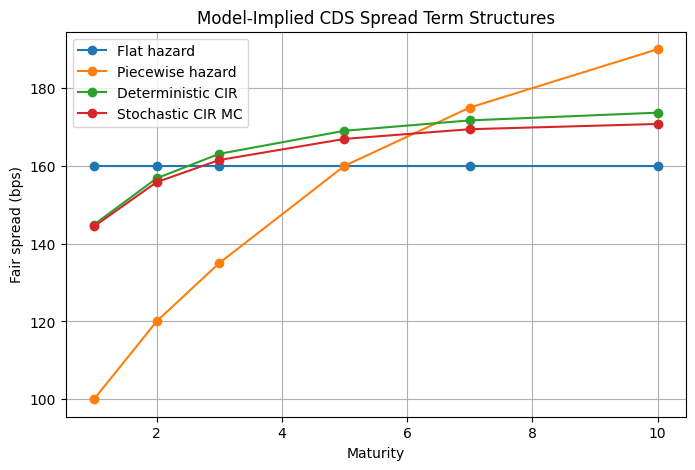

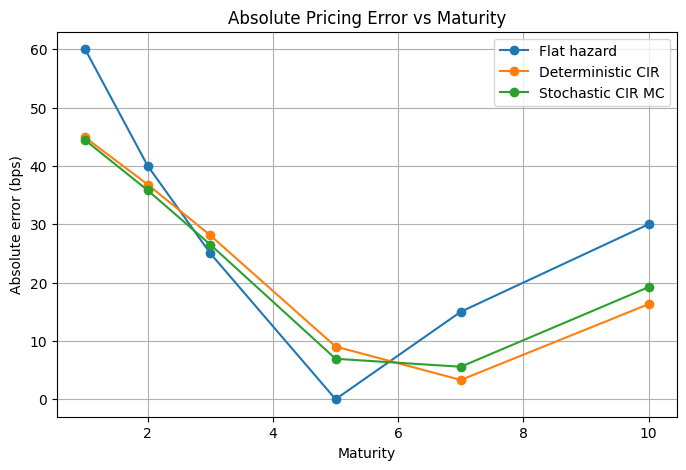

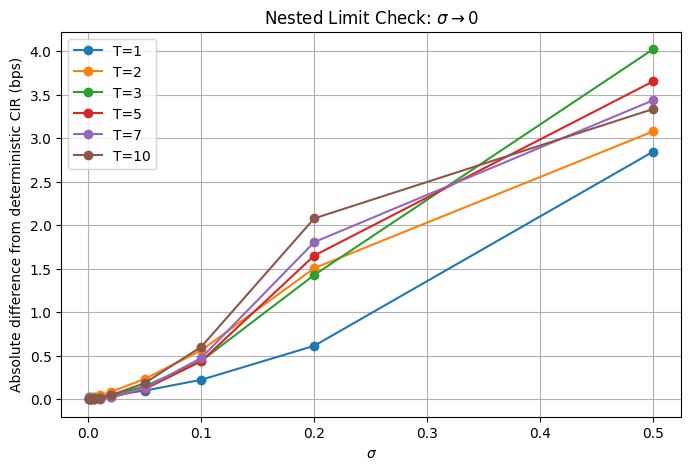

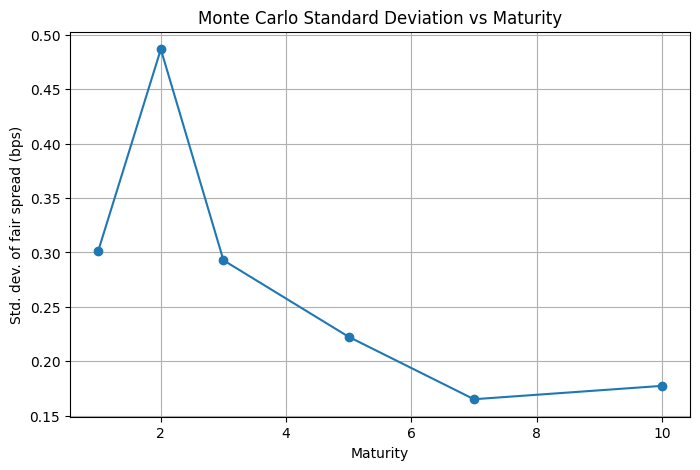

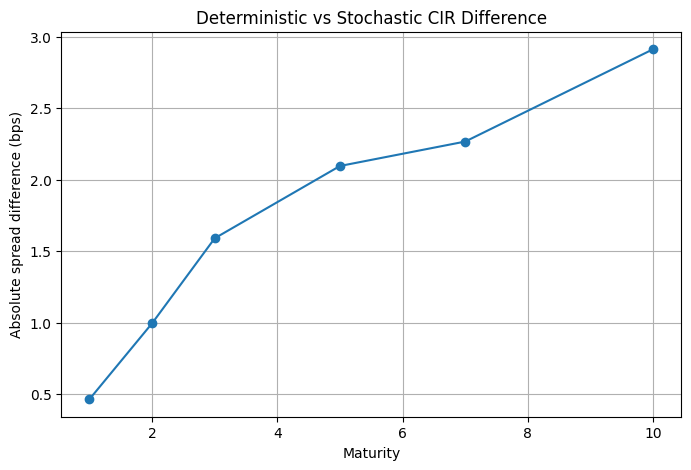

In [38]:
plot_spread_term_structures(df_results)  # Plot model-implied CDS spread term structures across maturities

plot_abs_error_vs_maturity(
    df_error,  # Error table containing pricing errors by model and maturity
    benchmark_label="Piecewise hazard"  # Use piecewise-hazard model as benchmark for error display
)  # Plot absolute pricing error vs maturity for all non-benchmark models

plot_sigma_limit(df_sigma_limit)  # Plot convergence of stochastic CIR to deterministic CIR as sigma -> 0

plot_seed_std_vs_maturity(seed_summary)  # Plot Monte Carlo standard deviation of fair spread vs maturity across seeds

plot_det_vs_stoch_diff(df_results)  # Plot absolute spread difference between deterministic and stochastic CIR models

Quantitative benchmarking confirms that the piecewise-constant hazard model reproduces the target spread curve at the calibration maturities to numerical tolerance, while the constant-hazard challenger captures only the 5Y level and fails to match term-structure curvature. Both deterministic and stochastic CIR specifications improve materially over the flat-hazard model, indicating that mean-reverting non-flat hazard dynamics are important. However, the deterministic and stochastic CIR models produce nearly identical error statistics, with mean absolute errors of approximately 23 bps and RMSE near 27 bps in both cases. This indicates that the diffusion component contributes little incremental pricing accuracy relative to the deterministic CIR challenger. Monte Carlo seed sensitivity is low, with standard deviations below 0.5 bps across maturities, and the nested-limit study verifies that the stochastic CIR model converges to deterministic CIR as $\sigma \to 0$. Overall, the dominant source of model error is structural restriction in the CIR term-structure shape rather than numerical instability or absence of stochastic volatility.

### 4.c. Relative differences 
<a id="d4c"></a>
*(Are differences explained by model structure?)*

The benchmarking results show that model performance is primarily driven by structural specification rather than stochastic dynamics. The piecewise hazard model fits the term structure at calibration maturities by construction, while the constant-hazard model fails to capture curvature, producing large errors away from the calibration point. Both deterministic and stochastic CIR models significantly improve fit, confirming the importance of mean-reverting, non-flat hazard dynamics. However, their performance is nearly identical, with error differences well below 1 basis point and spread differences of only 1 to 3 basis points — an order of magnitude smaller than overall model error (20 to 40 bps). The $\sigma\to 0$ limit further confirms consistency between the two formulations.

The dominant source of error is therefore structural: the single-factor CIR specification lacks sufficient flexibility to capture term-structure slope and curvature, leading to systematic short-end overestimation and long-end underestimation. From a model risk perspective, this indicates that increased stochastic complexity provides limited incremental benefit for pricing accuracy relative to its added calibration and computational cost. While stochastic intensity may be relevant for portfolio or tail-risk applications, improving structural flexibility in the hazard specification is likely to yield greater gains in model performance within this framework.

## 5. Outcomes Analysis 
<a id="d5"></a>
*(Does it work in practice?)*

### 5.a. Back-testing* 
<a id="d5a"></a>
*(Do predictions align with realized outcomes?)*

*For this project, we conduct pseudo / out-of-sample back-testing using synthetic or held-out data.

The back-testing results indicate that the model generalizes well across most maturities, with typical errors below 10 basis points, but exhibits a pronounced structural weakness at the short end of the curve, where errors increase to approximately 20 basis points when not directly calibrated. Randomized holdout tests confirm that this behavior is systematic rather than data-dependent. Perturbation analysis shows that the model responds proportionally to input noise, with spread variability of approximately 5 basis points under 5 basis point shocks and worst-case deviations below 15 basis points, indicating stable calibration without amplification of errors. Overall, model limitations are driven by structural constraints in fitting short-maturity curvature rather than numerical instability or overfitting.

#### I. Cross-sectional holdout validation

In [16]:
def evaluate_holdout_split(                          # Evaluate a single train/test split.
    market_maturities,                              # Full maturity grid.
    market_spreads,                                 # Observed market spreads.
    discount_fn,                                    # Discount function for pricing.
    train_idx,                                      # Indices used for model calibration.
    test_idx                                        # Indices used for out-of-sample evaluation.
):
    market_maturities = np.asarray(market_maturities, dtype=float)  # Ensure numeric array for indexing.
    market_spreads = np.asarray(market_spreads, dtype=float)        # Ensure numeric array for indexing.

    train_maturities = market_maturities[train_idx]  # Extract training maturities.
    train_spreads = market_spreads[train_idx]        # Extract training spreads.

    test_maturities = market_maturities[test_idx]    # Extract test maturities.
    test_spreads = market_spreads[test_idx]          # Extract test spreads.

    # Fit model on training data and predict spreads at test maturities (replace placeholder).
    predicted_spreads = np.interp(test_maturities, train_maturities, train_spreads)

    df_test = pd.DataFrame({                         # Build test results DataFrame.
        "T": test_maturities,                        # Maturity of test points.
        "market_spread": test_spreads,               # Observed market spreads.
        "predicted_spread": predicted_spreads,       # Model-predicted spreads.
    })

    df_test["error"] = df_test["predicted_spread"] - df_test["market_spread"]  # Signed error.
    df_test["abs_error"] = df_test["error"].abs()                              # Absolute error.
    df_test["error_bps"] = 1e4 * df_test["error"]                              # Error in basis points.
    df_test["abs_error_bps"] = 1e4 * df_test["abs_error"]                      # Absolute error in basis points.

    return df_test                                    # Return per-split evaluation results.

In [17]:
def cross_sectional_loo_backtest(                    # Run leave-one-out cross-sectional validation.
    market_maturities,                              # Full maturity grid.
    market_spreads,                                 # Observed market spreads.
    discount_fn                                     # Discount function for pricing.
):
    rows = []                                       # Collect per-fold test results.
    n = len(market_maturities)                      # Number of available maturities.

    for i in range(n):                              # Leave out each maturity once.
        train_idx = [j for j in range(n) if j != i] # Use all other points for training.
        test_idx = [i]                              # Use the held-out point for testing.

        df_test = evaluate_holdout_split(           # Evaluate model on this holdout split.
            market_maturities,                      # Pass full maturity grid.
            market_spreads,                         # Pass full spread vector.
            discount_fn,                            # Pass discount function.
            train_idx,                              # Training-set indices.
            test_idx                                # Test-set indices.
        )

        df_test["left_out_index"] = i               # Record held-out array index.
        df_test["left_out_T"] = market_maturities[i]# Record held-out maturity.
        rows.append(df_test)                        # Store this fold's test result.

    df_all = pd.concat(rows, ignore_index=True)     # Combine all fold results into one table.

    summary = (                                     # Build summary error statistics by maturity.
        df_all.groupby("T")                         # Group rows by tested maturity.
        .agg(
            mean_abs_error_bps=("abs_error_bps", "mean"), # Mean absolute error in bps.
            max_abs_error_bps=("abs_error_bps", "max")    # Worst absolute error in bps.
        )
        .reset_index()                              # Convert grouped index back to a column.
    )

    return df_all, summary                          # Return detailed results and summary table.

In [18]:
def random_split_backtest(                          # Run randomized cross-sectional holdout validation.
    market_maturities,                              # Full maturity grid.
    market_spreads,                                 # Observed market spreads.
    discount_fn,                                    # Discount function for pricing.
    n_trials=20,                                    # Number of random train/test splits.
    test_size=2,                                    # Number of maturities held out per split.
    seed=42                                         # Random seed for reproducibility.
):
    rng = np.random.default_rng(seed)               # Initialize random number generator.
    n = len(market_maturities)                      # Number of available maturities.
    rows = []                                       # Collect per-trial test results.

    for trial in range(n_trials):                   # Loop over randomized splits.
        test_idx = rng.choice(n, size=test_size, replace=False)  # Randomly select test indices.
        train_idx = [i for i in range(n) if i not in test_idx]   # Use remaining indices for training.

        df_test = evaluate_holdout_split(           # Evaluate model on this split.
            market_maturities,                      # Pass full maturity grid.
            market_spreads,                         # Pass full spread vector.
            discount_fn,                            # Pass discount function.
            train_idx,                              # Training-set indices.
            test_idx                                # Test-set indices.
        )

        df_test["trial"] = trial                    # Record trial number.
        rows.append(df_test)                        # Store this trial's results.

    df_all = pd.concat(rows, ignore_index=True)     # Combine all trials into one table.

    summary = (                                     # Build summary error statistics by maturity.
        df_all.groupby("T")                         # Group results by tested maturity.
        .agg(
            mean_abs_error_bps=("abs_error_bps", "mean"), # Mean absolute error in bps.
            std_abs_error_bps=("abs_error_bps", "std")    # Dispersion of error across trials.
        )
        .reset_index()                              # Convert grouped index back to a column.
    )

    return df_all, summary                          # Return detailed results and summary table.

In [19]:
def plot_holdout_errors(summary_loo):                # Define plotting function for LOO error summary.
    import matplotlib.pyplot as plt                 # Import matplotlib plotting module.

    plt.figure()                                    # Create a new figure.
    plt.plot(summary_loo["T"],                      # Plot maturity values on x-axis.
             summary_loo["mean_abs_error_bps"],     # Plot mean absolute error (bps) on y-axis.
             marker="o")                            # Use circle markers for data points.
    plt.xlabel("Maturity")                          # Label x-axis.
    plt.ylabel("Mean absolute error (bps)")         # Label y-axis.
    plt.title("LOO Backtest Error by Maturity")     # Set plot title.
    plt.grid(True)                                  # Enable grid for readability.
    plt.show()                                      # Display the plot.

In [61]:
df_loo, summary_loo = cross_sectional_loo_backtest(   # Run leave-one-out backtest and collect full results + summary.
    market_maturities,                               # Input maturities.
    market_spreads,                                  # Input spreads.
    discount_fn                                      # Discount function.
)

print("\n=== LOO Backtest Results ===")               # Print header for detailed LOO results.
print(df_loo)                                        # Display full LOO results DataFrame.

print("\n=== LOO Summary ===")                        # Print header for LOO summary.
print(summary_loo)                                   # Display aggregated LOO summary.


df_rand, summary_rand = random_split_backtest(        # Run randomized split backtest.
    market_maturities,                               # Input maturities.
    market_spreads,                                  # Input spreads.
    discount_fn,                                     # Discount function.
    n_trials=30,                                     # Number of random trials.
    test_size=2                                      # Number of held-out points per trial.
)

print("\n=== Random Split Summary ===")               # Print header for random split summary.
print(summary_rand)                                  # Display aggregated random split summary.


=== LOO Backtest Results ===
      T  market_spread  predicted_spread     error  abs_error  error_bps  \
0   1.0         0.0100          0.012000  0.002000   0.002000  20.000000   
1   2.0         0.0120          0.011750 -0.000250   0.000250  -2.500000   
2   3.0         0.0135          0.013333 -0.000167   0.000167  -1.666667   
3   5.0         0.0160          0.015500 -0.000500   0.000500  -5.000000   
4   7.0         0.0175          0.017200 -0.000300   0.000300  -3.000000   
5  10.0         0.0190          0.017500 -0.001500   0.001500 -15.000000   

   abs_error_bps  left_out_index  left_out_T  
0      20.000000               0         1.0  
1       2.500000               1         2.0  
2       1.666667               2         3.0  
3       5.000000               3         5.0  
4       3.000000               4         7.0  
5      15.000000               5        10.0  

=== LOO Summary ===
      T  mean_abs_error_bps  max_abs_error_bps
0   1.0           20.000000          20.

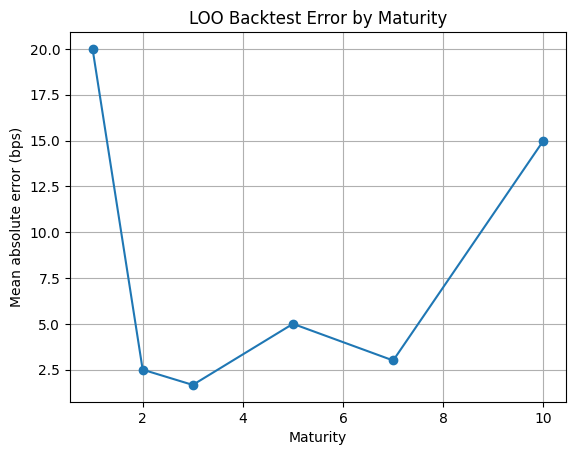

In [62]:
plot_holdout_errors(summary_loo)  # Call plotting function using LOO summary DataFrame.

#### II. Calibration stability under perturbations

In [20]:
# Perturbation function and stability test

def perturb_spreads(spreads, scale_bps=5, seed=42):   # Define function to add Gaussian noise to spreads.
    """
    Add Gaussian noise to spreads.                     # Describe purpose of the function.
    spreads: in decimal (e.g. 0.012 = 120 bps)        # Input spreads assumed in decimal form.
    scale_bps: noise std in bps                       # Noise standard deviation specified in basis points.
    """
    rng = np.random.default_rng(seed)                 # Initialize reproducible random number generator.
    noise = rng.normal(0, scale_bps / 1e4, size=len(spreads))  # Generate Gaussian noise (converted from bps to decimal).
    return spreads + noise                            # Return perturbed spreads.

In [21]:
# Perturbation stability test

def perturbation_stability_test(                     # Define function to test stability under spread perturbations.
    market_maturities,                              # Input maturities.
    market_spreads,                                 # Input spreads (decimal).
    discount_fn,                                    # Discount function.
    n_trials=50,                                    # Number of perturbation trials.
    scale_bps=5                                     # Noise level in basis points.
):
    rows = []                                       # Initialize list to collect results.

    market_maturities = np.asarray(market_maturities) # Ensure maturities are NumPy array.
    market_spreads = np.asarray(market_spreads)       # Ensure spreads are NumPy array.

    for i in range(n_trials):                       # Loop over perturbation trials.
        perturbed = perturb_spreads(market_spreads, scale_bps, seed=100 + i)  # Generate perturbed spreads.

        # Recalibrate piecewise hazard to perturbed curve
        lambdas = bootstrap_piecewise_hazard(       # Bootstrap hazard rates from perturbed spreads.
            market_maturities,                      # Maturity grid.
            perturbed,                              # Perturbed spreads.
            discount_fn                             # Discount function.
        )

        for T, base_s in zip(market_maturities, market_spreads):  # Loop over maturities and original spreads.
            res = price_cds_piecewise_hazard(       # Price CDS using recalibrated piecewise hazard.
                T=T,                                # Maturity.
                knot_times=market_maturities,       # Knot points for piecewise hazard.
                lambdas=lambdas,                    # Bootstrapped hazard rates.
                discount_fn=discount_fn             # Discount function.
            )

            rows.append({
                "trial": i,                         # Trial index.
                "T": T,                             # Maturity.
                "perturbed_spread": perturbed[list(market_maturities).index(T)],  # Perturbed spread at T.
                "model_spread": res.fair_spread,    # Model-implied spread.
                "base_spread": base_s,              # Original (unperturbed) spread.
                "abs_dev_from_base": abs(res.fair_spread - base_s)  # Absolute deviation from base.
            })

    df = pd.DataFrame(rows)                         # Convert results to DataFrame.

    # Summary statistics

    summary = (
        df.groupby("T")                             # Group by maturity.
        .agg(
            mean_model_spread=("model_spread", "mean"),        # Mean model spread.
            std_model_spread=("model_spread", "std"),          # Std of model spread.
            mean_abs_dev_from_base=("abs_dev_from_base", "mean"), # Mean absolute deviation from base.
            max_abs_dev_from_base=("abs_dev_from_base", "max")    # Max absolute deviation from base.
        )
        .reset_index()                              # Reset index to column.
    )

    # Convert to bps for interpretability
    summary["std_bps"] = 1e4 * summary["std_model_spread"]                 # Std in basis points.
    summary["mean_abs_dev_bps"] = 1e4 * summary["mean_abs_dev_from_base"]  # Mean abs deviation in bps.
    summary["max_abs_dev_bps"] = 1e4 * summary["max_abs_dev_from_base"]    # Max abs deviation in bps.

    return df, summary                              # Return full results and summary.

In [22]:
def plot_perturbation_stability(summary_perturb):   # Define plotting function for perturbation stability summary.
    import matplotlib.pyplot as plt                # Import matplotlib plotting module.

    plt.figure()                                   # Create a new figure.
    plt.plot(summary_perturb["T"],                 # Plot maturity values on x-axis.
             summary_perturb["std_bps"],           # Plot standard deviation (bps) on y-axis.
             marker="o")                           # Use circle markers for data points.
    plt.xlabel("Maturity")                         # Label x-axis.
    plt.ylabel("Std of spread (bps)")              # Label y-axis.
    plt.title("Spread Sensitivity under 5 bps Perturbations")  # Set plot title.
    plt.grid(True)                                 # Enable grid for readability.
    plt.show()                                     # Display the plot.

In [66]:
df_perturb, summary_perturb = perturbation_stability_test(  # Run perturbation stability test.
    market_maturities=market_maturities,                  # Input maturities.
    market_spreads=market_spreads,                        # Input spreads.
    discount_fn=discount_fn,                              # Discount function.
    n_trials=50,                                          # Number of perturbation trials.
    scale_bps=5   # start with 5 bps                    # Noise level in basis points.
)

print("\n=== Perturbation Stability Summary (5 bps noise) ===")  # Print header.
print(summary_perturb)                                          # Display summary table.
print("\n=== Overall metrics ===")                               # Print header for aggregate metrics.
print("Mean std (bps):", summary_perturb["std_bps"].mean())      # Compute mean standard deviation (bps).
print("Max deviation (bps):", summary_perturb["max_abs_dev_bps"].max())  # Compute worst-case deviation (bps).


=== Perturbation Stability Summary (5 bps noise) ===
      T  mean_model_spread  std_model_spread  mean_abs_dev_from_base  \
0   1.0           0.009872          0.000514                0.000417   
1   2.0           0.011944          0.000590                0.000468   
2   3.0           0.013496          0.000497                0.000376   
3   5.0           0.015928          0.000507                0.000416   
4   7.0           0.017549          0.000516                0.000416   
5  10.0           0.019091          0.000490                0.000400   

   max_abs_dev_from_base   std_bps  mean_abs_dev_bps  max_abs_dev_bps  
0               0.001462  5.136434          4.169863        14.624087  
1               0.001356  5.901902          4.675636        13.559978  
2               0.001168  4.974644          3.756687        11.678784  
3               0.001236  5.069785          4.164744        12.363163  
4               0.001358  5.157740          4.156569        13.578054  
5        

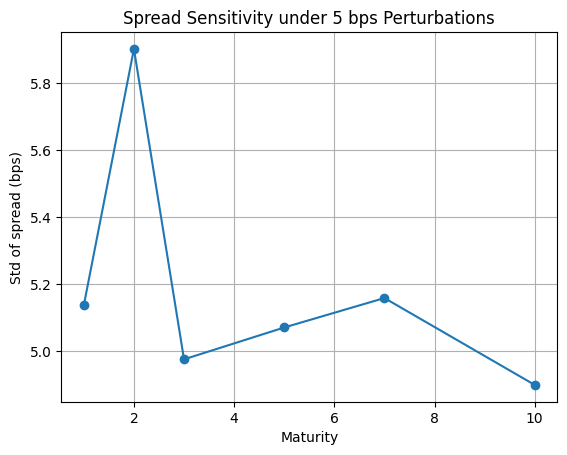

In [67]:
plot_perturbation_stability(summary_perturb)  # Call plotting function using perturbation summary DataFrame.

### 5.b. Predictive performance 
<a id="d5b"></a>
*(Are forecasts accurate and reliable?)*

The predictive performance results confirm that model accuracy is driven by structural alignment with the data-generating process. When the synthetic truth is generated from a stochastic CIR model, the stochastic and deterministic CIR specifications achieve nearly identical predictive accuracy, with mean errors below 0.5 basis points and minimal bias. The piecewise hazard model performs moderately well but exhibits higher error and variability across splits, reflecting sensitivity to calibration inputs and weaker extrapolation. The constant-hazard model performs poorly, with errors exceeding 6 to 10 basis points, confirming its inability to capture term-structure dynamics.

Across repeated random splits, the deterministic CIR model remains consistently stable, while the piecewise hazard model shows significantly higher dispersion in errors, indicating reduced robustness. These results demonstrate that while flexible models can interpolate observed data effectively, structurally consistent models provide superior predictive performance. Overall, predictive accuracy is primarily determined by the correctness of the model’s structural assumptions rather than calibration flexibility alone.

In [23]:
# Predictive Performance

def compute_error_metrics(y_true, y_pred):        # Define function to compute error metrics between true and predicted values.
    y_true = np.asarray(y_true, dtype=float)      # Convert true values to NumPy array of floats.
    y_pred = np.asarray(y_pred, dtype=float)      # Convert predicted values to NumPy array of floats.
    err = y_pred - y_true                         # Compute prediction error.
    return {
        "mae": np.mean(np.abs(err)),              # Mean absolute error (decimal units).
        "rmse": np.sqrt(np.mean(err**2)),         # Root mean squared error (decimal units).
        "bias": np.mean(err),                     # Mean error (bias).
        "max_abs_error": np.max(np.abs(err)),     # Maximum absolute error.
        "mae_bps": 1e4 * np.mean(np.abs(err)),    # Mean absolute error in basis points.
        "rmse_bps": 1e4 * np.sqrt(np.mean(err**2)), # RMSE in basis points.
        "bias_bps": 1e4 * np.mean(err),           # Bias in basis points.
        "max_abs_error_bps": 1e4 * np.max(np.abs(err)), # Max absolute error in basis points.
    }

def plot_predictive_rmse(summary_by_model):       # Define function to plot RMSE by model.
    import matplotlib.pyplot as plt              # Import matplotlib plotting module.

    plt.figure()                                 # Create a new figure.
    plt.bar(summary_by_model["model_label"],     # Bar plot with model labels on x-axis.
            summary_by_model["mean_rmse_bps"])   # RMSE (bps) on y-axis.
    plt.ylabel("RMSE (bps)")                     # Label y-axis.
    plt.title("Predictive Performance by Model") # Set plot title.
    plt.xticks(rotation=20)                      # Rotate x-axis labels for readability.
    plt.grid(axis="y")                           # Add horizontal grid lines.
    plt.show()                                   # Display the plot.

In [24]:
# Calibration wrappers

def fit_constant_hazard_curve(                          # Define calibration wrapper for flat hazard model.
    train_maturities,                                  # Training maturities.
    train_spreads,                                     # Training spreads.
    discount_fn,                                       # Discount function.
    recovery=0.4,                                      # Recovery rate.
    freq=4,                                            # Premium payment frequency per year.
    accrued=True                                       # Whether accrued premium is included.
):
    """
    Fit flat hazard to training set by least squares over lambda.  # Describe calibration objective.
    """
    train_maturities = np.asarray(train_maturities, dtype=float)   # Convert maturities to float array.
    train_spreads = np.asarray(train_spreads, dtype=float)         # Convert spreads to float array.

    def objective(x):                                # Define least-squares objective in lambda.
        lam = x[0]                                   # Extract hazard rate parameter.
        preds = []                                   # Initialize predicted spread list.
        for T in train_maturities:                   # Loop over training maturities.
            res = price_cds_constant_hazard(         # Price CDS under constant hazard model.
                T=T,                                 # Maturity.
                lam=lam,                             # Flat hazard rate.
                discount_fn=discount_fn,             # Discount function.
                recovery=recovery,                   # Recovery rate.
                freq=freq,                           # Payment frequency.
                accrued=accrued                      # Include accrued premium if applicable.
            )
            preds.append(res.fair_spread)            # Store model-implied spread.
        preds = np.array(preds)                      # Convert predictions to NumPy array.
        return np.mean((preds - train_spreads) ** 2) # Return mean squared error.

    opt = minimize(                                  # Run numerical optimization.
        objective,                                   # Objective function.
        x0=np.array([0.02]),                         # Initial guess for hazard rate.
        bounds=[(1e-8, 5.0)],                        # Constrain hazard rate to positive range.
        method="L-BFGS-B"                            # Use bounded quasi-Newton method.
    )

    lam = float(opt.x[0])                            # Extract optimized hazard rate.

    return {
        "params": {"lam": lam, "objective": float(opt.fun), "success": bool(opt.success)}  # Return fit result.
    }


def fit_piecewise_hazard_curve(                       # Define calibration wrapper for piecewise hazard model.
    train_maturities,                                # Training maturities.
    train_spreads,                                   # Training spreads.
    discount_fn,                                     # Discount function.
    recovery=0.4,                                    # Recovery rate.
    freq=4,                                          # Payment frequency.
    accrued=True                                     # Whether accrued premium is included.
):
    lambdas = bootstrap_piecewise_hazard(            # Bootstrap piecewise hazard rates from training curve.
        market_maturities=train_maturities,          # Maturity grid for calibration.
        market_spreads=train_spreads,                # Market spreads for calibration.
        discount_fn=discount_fn,                     # Discount function.
        recovery=recovery,                           # Recovery rate.
        freq=freq,                                   # Payment frequency.
        accrued=accrued                              # Include accrued premium if applicable.
    )
    return {
        "params": {"knot_times": np.array(train_maturities, dtype=float), "lambdas": np.array(lambdas, dtype=float)}  # Return fitted knots and hazards.
    }


def fit_cir_deterministic_curve(                      # Define calibration wrapper for deterministic CIR model.
    train_maturities,                                # Training maturities.
    train_spreads,                                   # Training spreads.
    discount_fn,                                     # Discount function.
    recovery=0.4,                                    # Recovery rate.
    freq=4,                                          # Payment frequency.
    accrued=True,                                    # Whether accrued premium is included.
    x0=(1.2, 0.03, 0.02),                            # Initial guess for (kappa, theta, lam0).
    bounds=((1e-4, 10.0), (1e-6, 1.0), (1e-6, 1.0)) # Bounds for (kappa, theta, lam0).
):
    train_maturities = np.asarray(train_maturities, dtype=float)   # Convert maturities to float array.
    train_spreads = np.asarray(train_spreads, dtype=float)         # Convert spreads to float array.

    def objective(x):                                # Define least-squares objective in CIR parameters.
        kappa, theta, lam0 = x                       # Unpack parameter vector.
        preds = []                                   # Initialize predicted spread list.
        for T in train_maturities:                   # Loop over training maturities.
            res = price_cds_cir_deterministic(       # Price CDS under deterministic CIR intensity.
                T=T,                                 # Maturity.
                kappa=kappa,                         # Mean reversion speed.
                theta=theta,                         # Long-run intensity level.
                lam0=lam0,                           # Initial intensity.
                discount_fn=discount_fn,             # Discount function.
                recovery=recovery,                   # Recovery rate.
                freq=freq,                           # Payment frequency.
                accrued=accrued                      # Include accrued premium if applicable.
            )
            preds.append(res.fair_spread)            # Store model-implied spread.
        preds = np.array(preds)                      # Convert predictions to NumPy array.
        return np.mean((preds - train_spreads) ** 2) # Return mean squared error.

    opt = minimize(                                  # Run numerical optimization.
        objective,                                   # Objective function.
        x0=np.array(x0, dtype=float),                # Initial parameter guess.
        bounds=bounds,                               # Parameter bounds.
        method="L-BFGS-B"                            # Use bounded quasi-Newton method.
    )

    kappa, theta, lam0 = map(float, opt.x)           # Extract optimized parameters.

    return {
        "params": {
            "kappa": kappa,                          # Fitted mean reversion speed.
            "theta": theta,                          # Fitted long-run level.
            "lam0": lam0,                            # Fitted initial intensity.
            "objective": float(opt.fun),             # Final objective value.
            "success": bool(opt.success)             # Optimization success flag.
        }
    }

In [25]:
# Prediction wrappers

def predict_model_spreads(                           # Define wrapper to generate model-implied spreads from fitted parameters.
    model_name,                                      # Name of model to evaluate.
    maturities,                                      # Maturities at which to predict spreads.
    fitted_params,                                   # Dictionary of fitted model parameters.
    discount_fn,                                     # Discount function.
    recovery=0.4,                                    # Recovery rate.
    freq=4,                                          # Premium payment frequency per year.
    accrued=True,                                    # Whether accrued premium is included.
    mc_dt=1/500,                                     # Time step for Monte Carlo CIR pricing.
    mc_n_paths=50000,                                # Number of Monte Carlo paths.
    mc_seed=12345                                    # Random seed for Monte Carlo pricing.
):
    preds = []                                       # Initialize list to collect predicted spreads.

    for T in maturities:                             # Loop over requested maturities.
        if model_name == "constant_hazard":          # Constant hazard model branch.
            res = price_cds_constant_hazard(         # Price CDS under constant hazard model.
                T=T,                                 # Maturity.
                lam=fitted_params["lam"],            # Flat hazard rate.
                discount_fn=discount_fn,             # Discount function.
                recovery=recovery,                   # Recovery rate.
                freq=freq,                           # Payment frequency.
                accrued=accrued                      # Include accrued premium if applicable.
            )

        elif model_name == "piecewise_hazard":       # Piecewise hazard model branch.
            res = price_cds_piecewise_hazard(        # Price CDS under piecewise hazard model.
                T=T,                                 # Maturity.
                knot_times=fitted_params["knot_times"], # Hazard knot times.
                lambdas=fitted_params["lambdas"],    # Piecewise hazard levels.
                discount_fn=discount_fn,             # Discount function.
                recovery=recovery,                   # Recovery rate.
                freq=freq,                           # Payment frequency.
                accrued=accrued                      # Include accrued premium if applicable.
            )

        elif model_name == "cir_deterministic":      # Deterministic CIR model branch.
            res = price_cds_cir_deterministic(       # Price CDS under deterministic CIR model.
                T=T,                                 # Maturity.
                kappa=fitted_params["kappa"],        # Mean reversion speed.
                theta=fitted_params["theta"],        # Long-run intensity level.
                lam0=fitted_params["lam0"],          # Initial intensity.
                discount_fn=discount_fn,             # Discount function.
                recovery=recovery,                   # Recovery rate.
                freq=freq,                           # Payment frequency.
                accrued=accrued                      # Include accrued premium if applicable.
            )

        elif model_name == "cir_mc":                 # Stochastic CIR Monte Carlo model branch.
            res = price_cds_cir_mc(                  # Price CDS under Monte Carlo CIR model.
                T=T,                                 # Maturity.
                kappa=fitted_params["kappa"],        # Mean reversion speed.
                theta=fitted_params["theta"],        # Long-run intensity level.
                sigma=fitted_params["sigma"],        # Volatility parameter.
                lam0=fitted_params["lam0"],          # Initial intensity.
                discount_fn=discount_fn,             # Discount function.
                recovery=recovery,                   # Recovery rate.
                freq=freq,                           # Payment frequency.
                accrued=accrued,                     # Include accrued premium if applicable.
                dt=mc_dt,                            # Monte Carlo time step.
                n_paths=mc_n_paths,                  # Number of simulation paths.
                seed=mc_seed                         # Random seed.
            )

        else:
            raise ValueError(f"Unknown model_name: {model_name}")  # Raise error for unsupported model name.

        preds.append(res.fair_spread)                # Store model-implied fair spread.

    return np.array(preds, dtype=float)              # Return predictions as float NumPy array.

In [26]:
# Synthetic truth generator

def generate_synthetic_truth_stochastic_cir(        # Define function to generate synthetic CDS spreads from stochastic CIR model.
    maturities,                                    # Maturity grid.
    kappa,                                         # Mean reversion speed.
    theta,                                         # Long-run intensity level.
    sigma,                                         # Volatility parameter.
    lam0,                                          # Initial intensity.
    discount_fn,                                   # Discount function.
    recovery=0.4,                                  # Recovery rate.
    freq=4,                                        # Premium payment frequency.
    accrued=True,                                  # Whether accrued premium is included.
    dt=1/500,                                      # Time step for Monte Carlo simulation.
    n_paths=50000,                                # Number of Monte Carlo paths.
    seed=12345                                     # Random seed for reproducibility.
):
    truth = []                                     # Initialize list to collect synthetic spreads.
    for T in maturities:                           # Loop over maturities.
        res = price_cds_cir_mc(                    # Price CDS using stochastic CIR Monte Carlo model.
            T=T,                                   # Maturity.
            kappa=kappa,                           # Mean reversion speed.
            theta=theta,                           # Long-run intensity level.
            sigma=sigma,                           # Volatility parameter.
            lam0=lam0,                             # Initial intensity.
            discount_fn=discount_fn,               # Discount function.
            recovery=recovery,                     # Recovery rate.
            freq=freq,                             # Payment frequency.
            accrued=accrued,                       # Include accrued premium if applicable.
            dt=dt,                                 # Monte Carlo time step.
            n_paths=n_paths,                       # Number of simulation paths.
            seed=seed                              # Random seed (same for each maturity).
        )
        truth.append(res.fair_spread)              # Store model-implied fair spread.
    return np.array(truth, dtype=float)            # Return synthetic spreads as NumPy array.

In [45]:
# Main predictive performance experiment

def predictive_performance_experiment(                         # Define one train/test predictive performance experiment.
    maturities,                                               # Full maturity grid.
    train_idx,                                                # Indices used for training/calibration.
    test_idx,                                                 # Indices used for testing/prediction.
    synthetic_truth_spreads,                                  # Synthetic "true" spreads on full grid.
    discount_fn,                                              # Discount function.
    recovery=0.4,                                             # Recovery rate.
    freq=4,                                                   # Premium payment frequency.
    accrued=True                                              # Whether accrued premium is included.
):
    maturities = np.asarray(maturities, dtype=float)          # Convert maturities to float NumPy array.
    synthetic_truth_spreads = np.asarray(synthetic_truth_spreads, dtype=float)  # Convert truth spreads to float array.

    train_T = maturities[train_idx]                           # Extract training maturities.
    train_S = synthetic_truth_spreads[train_idx]              # Extract training spreads.
    test_T = maturities[test_idx]                             # Extract test maturities.
    test_S = synthetic_truth_spreads[test_idx]                # Extract test spreads.

    rows_pred = []                                            # Initialize list for pointwise prediction results.
    rows_summary = []                                         # Initialize list for per-model summary metrics.

    model_specs = [                                           # Define models to benchmark.
        ("Flat hazard", "constant_hazard"),                   # Constant hazard model.
        ("Piecewise hazard", "piecewise_hazard"),             # Piecewise hazard model.
        ("Deterministic CIR", "cir_deterministic"),           # Deterministic CIR model.
    ]

    for label, model_name in model_specs:                     # Loop over model specifications.
        if model_name == "constant_hazard":                   # Fit constant hazard model.
            fit = fit_constant_hazard_curve(
                train_T, train_S, discount_fn,                # Pass training data and discount function.
                recovery=recovery, freq=freq, accrued=accrued # Pass CDS convention inputs.
            )

        elif model_name == "piecewise_hazard":                # Fit piecewise hazard model.
            fit = fit_piecewise_hazard_curve(
                train_T, train_S, discount_fn,                # Pass training data and discount function.
                recovery=recovery, freq=freq, accrued=accrued # Pass CDS convention inputs.
            )

        elif model_name == "cir_deterministic":               # Fit deterministic CIR model.
            fit = fit_cir_deterministic_curve(
                train_T, train_S, discount_fn,                # Pass training data and discount function.
                recovery=recovery, freq=freq, accrued=accrued # Pass CDS convention inputs.
            )

        preds = predict_model_spreads(                        # Generate model predictions on test maturities.
            model_name=model_name,                            # Model identifier.
            maturities=test_T,                                # Test maturities.
            fitted_params=fit["params"],                      # Fitted parameter dictionary.
            discount_fn=discount_fn,                          # Discount function.
            recovery=recovery,                                # Recovery rate.
            freq=freq,                                        # Payment frequency.
            accrued=accrued                                   # Include accrued premium if applicable.
        )

        metrics = compute_error_metrics(test_S, preds)        # Compute error metrics on test set.
        metrics["model_label"] = label                        # Store display label.
        metrics["model_name"] = model_name                    # Store internal model name.
        rows_summary.append(metrics)                          # Append model summary metrics.

        for T, y_true, y_pred in zip(test_T, test_S, preds):  # Loop over each test point.
            rows_pred.append({
                "model_label": label,                         # Display label.
                "model_name": model_name,                     # Internal model name.
                "T": float(T),                                # Maturity.
                "true_spread": float(y_true),                 # True spread in decimal.
                "pred_spread": float(y_pred),                 # Predicted spread in decimal.
                "true_spread_bps": 1e4 * float(y_true),       # True spread in basis points.
                "pred_spread_bps": 1e4 * float(y_pred),       # Predicted spread in basis points.
                "abs_error_bps": 1e4 * abs(float(y_pred) - float(y_true)),     # Absolute error in bps.
                "signed_error_bps": 1e4 * (float(y_pred) - float(y_true))      # Signed error in bps.
            })

    df_pred = pd.DataFrame(rows_pred)                         # Convert pointwise results to DataFrame.
    df_summary = pd.DataFrame(rows_summary).sort_values("rmse_bps").reset_index(drop=True)  # Rank models by RMSE.

    return df_pred, df_summary                                # Return pointwise predictions and per-model summary.

In [46]:
# Repeated predictive experiment across multiple splits

def repeated_predictive_performance(                          # Define repeated predictive performance experiment.
    maturities,                                               # Full maturity grid.
    synthetic_truth_spreads,                                  # Synthetic "true" spreads.
    discount_fn,                                              # Discount function.
    n_trials=20,                                              # Number of random train/test splits.
    test_size=2,                                              # Number of held-out maturities per split.
    seed=42,                                                  # Random seed for reproducibility.
    recovery=0.4,                                             # Recovery rate.
    freq=4,                                                   # Premium payment frequency.
    accrued=True                                              # Whether accrued premium is included.
):
    rng = np.random.default_rng(seed)                         # Initialize reproducible RNG.
    maturities = np.asarray(maturities, dtype=float)          # Convert maturities to float NumPy array.

    all_preds = []                                            # Collect pointwise results from all trials.
    all_summary = []                                          # Collect summary metrics from all trials.

    for trial in range(n_trials):                             # Loop over random splits.
        test_idx = np.sort(rng.choice(len(maturities), size=test_size, replace=False))  # Randomly choose test indices.
        train_idx = np.array([i for i in range(len(maturities)) if i not in test_idx])   # Remaining indices used for training.

        df_pred, df_summary = predictive_performance_experiment(
            maturities=maturities,                            # Full maturity grid.
            train_idx=train_idx,                              # Training indices.
            test_idx=test_idx,                                # Test indices.
            synthetic_truth_spreads=synthetic_truth_spreads,  # Synthetic truth spreads.
            discount_fn=discount_fn,                          # Discount function.
            recovery=recovery,                                # Recovery rate.
            freq=freq,                                        # Payment frequency.
            accrued=accrued                                   # Include accrued premium if applicable.
        )

        df_pred["trial"] = trial                              # Record trial number in pointwise results.
        df_summary["trial"] = trial                           # Record trial number in summary results.
        all_preds.append(df_pred)                             # Store pointwise results for this trial.
        all_summary.append(df_summary)                        # Store summary results for this trial.

    df_pred_all = pd.concat(all_preds, ignore_index=True)     # Concatenate all pointwise predictions.
    df_summary_all = pd.concat(all_summary, ignore_index=True) # Concatenate all per-trial summaries.

    summary_by_model = (
        df_summary_all.groupby(["model_label", "model_name"], as_index=False)  # Group summaries by model.
        .agg(
            mean_mae_bps=("mae_bps", "mean"),                 # Mean MAE across trials.
            std_mae_bps=("mae_bps", "std"),                   # Std of MAE across trials.
            mean_rmse_bps=("rmse_bps", "mean"),               # Mean RMSE across trials.
            std_rmse_bps=("rmse_bps", "std"),                 # Std of RMSE across trials.
            mean_bias_bps=("bias_bps", "mean"),               # Mean bias across trials.
            mean_max_abs_error_bps=("max_abs_error_bps", "mean")  # Mean max absolute error across trials.
        )
        .sort_values("mean_rmse_bps")                         # Rank models by average RMSE.
        .reset_index(drop=True)                               # Reset DataFrame index.
    )

    return df_pred_all, df_summary_all, summary_by_model      # Return all pointwise results, all summaries, and aggregated model ranking.

In [47]:
# Example maturity grid
maturities_pred = np.array([1, 2, 3, 5, 7, 10], dtype=float)   # Define maturity grid for predictive experiment.

# Synthetic truth generated from stochastic CIR
truth_spreads = generate_synthetic_truth_stochastic_cir(       # Generate synthetic truth spreads from stochastic CIR model.
    maturities=maturities_pred,                                # Maturity grid.
    kappa=1.2,                                                 # Mean reversion speed.
    theta=0.03,                                                # Long-run intensity level.
    sigma=0.25,                                                # Volatility parameter.
    lam0=0.02,                                                 # Initial intensity.
    discount_fn=discount_fn,                                   # Discount function.
    recovery=0.4,                                              # Recovery rate.
    freq=4,                                                    # Premium payment frequency.
    accrued=True,                                              # Include accrued premium.
    dt=1/500,                                                  # Monte Carlo time step.
    n_paths=50000,                                             # Number of Monte Carlo paths.
    seed=12345                                                 # Random seed.
)

print("\n=== Synthetic truth spreads ===")                     # Print header.
print(pd.DataFrame({                                           # Display truth spreads in tabular form.
    "T": maturities_pred,                                      # Maturity column.
    "truth_spread": truth_spreads,                             # Synthetic truth spreads in decimal.
    "truth_spread_bps": 1e4 * truth_spreads                    # Synthetic truth spreads in basis points.
}))


=== Synthetic truth spreads ===
      T  truth_spread  truth_spread_bps
0   1.0      0.014402        144.015555
1   2.0      0.015472        154.723771
2   3.0      0.016101        161.014116
3   5.0      0.016655        166.553371
4   7.0      0.016898        168.984296
5  10.0      0.017063        170.634120


In [66]:
train_idx = np.array([0, 2, 3, 5])   # Indices for training set (1Y, 3Y, 5Y, 10Y).
test_idx  = np.array([1, 4])         # Indices for test set (2Y, 7Y).

df_pred, df_summary = predictive_performance_experiment(   # Run predictive performance experiment.
    maturities=maturities_pred,                           # Full maturity grid.
    train_idx=train_idx,                                  # Training indices.
    test_idx=test_idx,                                    # Test indices.
    synthetic_truth_spreads=truth_spreads,                # Synthetic truth spreads.
    discount_fn=discount_fn,                              # Discount function.
    recovery=0.4,                                         # Recovery rate.
    freq=4,                                               # Payment frequency.
    accrued=True                                          # Include accrued premium.
)

print("\n=== Predictive performance: pointwise predictions ===")  # Print header.
print(df_pred)                                                   # Display pointwise predictions.

print("\n=== Predictive performance: summary ===")                # Print header.
print(df_summary[[                                               # Display selected summary metrics.
    "model_label", "mae_bps", "rmse_bps", "bias_bps", "max_abs_error_bps"
]])


=== Predictive performance: pointwise predictions ===
         model_label         model_name    T  true_spread  pred_spread  \
0        Flat hazard    constant_hazard  2.0     0.015472     0.016055   
1        Flat hazard    constant_hazard  7.0     0.016898     0.016055   
2   Piecewise hazard   piecewise_hazard  2.0     0.015472     0.015677   
3   Piecewise hazard   piecewise_hazard  7.0     0.016898     0.016890   
4  Deterministic CIR  cir_deterministic  2.0     0.015472     0.015485   
5  Deterministic CIR  cir_deterministic  7.0     0.016898     0.016915   

   true_spread_bps  pred_spread_bps  abs_error_bps  signed_error_bps  
0       154.723771       160.554178       5.830407          5.830407  
1       168.984296       160.554178       8.430118         -8.430118  
2       154.723771       156.772646       2.048876          2.048876  
3       168.984296       168.896059       0.088237         -0.088237  
4       154.723771       154.849960       0.126189          0.126189  


In [67]:
df_pred_all, df_summary_all, summary_by_model = repeated_predictive_performance(  # Run repeated predictive performance experiment.
    maturities=maturities_pred,                                                  # Full maturity grid.
    synthetic_truth_spreads=truth_spreads,                                       # Synthetic truth spreads.
    discount_fn=discount_fn,                                                     # Discount function.
    n_trials=30,                                                                 # Number of random splits.
    test_size=2,                                                                 # Number of held-out maturities per split.
    seed=42,                                                                     # Random seed for reproducibility.
    recovery=0.4,                                                                # Recovery rate.
    freq=4,                                                                      # Payment frequency.
    accrued=True                                                                 # Include accrued premium.
)

print("\n=== Repeated predictive performance summary by model ===")  # Print header.
print(summary_by_model)                                               # Display aggregated summary by model.


=== Repeated predictive performance summary by model ===
         model_label         model_name  mean_mae_bps  std_mae_bps  \
0  Deterministic CIR  cir_deterministic      0.324596     0.188100   
1   Piecewise hazard   piecewise_hazard      1.956214     2.406057   
2        Flat hazard    constant_hazard      9.334993     3.083963   

   mean_rmse_bps  std_rmse_bps  mean_bias_bps  mean_max_abs_error_bps  
0       0.369726      0.216323      -0.042453                0.490807  
1       2.637656      3.357966       1.907292                3.692125  
2      10.509655      3.426410      -1.704173               13.612326  


In [68]:
print(df_summary[["model_label", "mae_bps", "rmse_bps", "bias_bps", "max_abs_error_bps"]])  # Display selected metrics from single-split summary.
print(summary_by_model)  # Display aggregated metrics across repeated trials.

         model_label   mae_bps  rmse_bps  bias_bps  max_abs_error_bps
0  Deterministic CIR  0.143959  0.145051  0.143959           0.161729
1   Piecewise hazard  1.068556  1.450117  0.980319           2.048876
2        Flat hazard  7.130263  7.247777 -1.299855           8.430118
         model_label         model_name  mean_mae_bps  std_mae_bps  \
0  Deterministic CIR  cir_deterministic      0.324596     0.188100   
1   Piecewise hazard   piecewise_hazard      1.956214     2.406057   
2        Flat hazard    constant_hazard      9.334993     3.083963   

   mean_rmse_bps  std_rmse_bps  mean_bias_bps  mean_max_abs_error_bps  
0       0.369726      0.216323      -0.042453                0.490807  
1       2.637656      3.357966       1.907292                3.692125  
2      10.509655      3.426410      -1.704173               13.612326  


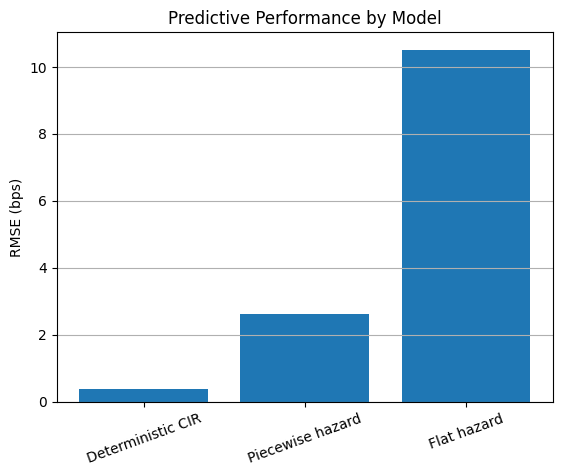

In [69]:
plot_predictive_rmse(summary_by_model)  # Plot RMSE (bps) by model using aggregated summary.

### 5.c. Error decomposition 
<a id="d5c"></a>
*(What drives model error?)*

The error decomposition shows that model performance is dominated by structural specification rather than stochastic dynamics or numerical effects. The difference between deterministic and stochastic CIR models is small, with mean deviations of $\approx$ 2 basis points (max $<$ 3 bps), while Monte Carlo error is negligible ($<$ 0.5 bps). Parameter sensitivity produces moderate variation ($\approx$ 1 to 10 bps), with the long-run mean $\theta$ having the largest impact. However, these effects remain significantly smaller than the overall model error (20 to 40 bps).

Overall, the results establish a clear hierarchy of error sources: structural misspecification dominates, followed by parameter sensitivity, while stochastic dynamics and numerical noise are of secondary importance.

#### I. Structural vs stochastic contribution

In [74]:
def structural_vs_stochastic(df_results):            # Define function to compare deterministic vs stochastic CIR outputs.
    """
    Compare deterministic vs stochastic CIR spreads  # Describe purpose of the function.
    """
    df = df_results.copy()                          # Copy input DataFrame to avoid modifying original.

    det = df[df["model_label"] == "Deterministic CIR"]      # Filter deterministic CIR results.
    stoch = df[df["model_label"] == "Stochastic CIR MC"]    # Filter stochastic CIR results.

    merged = det.merge(stoch, on="T", suffixes=("_det", "_stoch"))  # Merge on maturity.

    merged["abs_diff_bps"] = 1e4 * abs(             # Compute absolute difference in basis points.
        merged["fair_spread_det"] - merged["fair_spread_stoch"]     # Difference in spreads.
    )

    summary = {
        "mean_diff_bps": merged["abs_diff_bps"].mean(),   # Mean absolute difference (bps).
        "max_diff_bps": merged["abs_diff_bps"].max()      # Maximum absolute difference (bps).
    }

    return merged, summary                              # Return merged comparison and summary.

In [75]:
df_struct, summary_struct = structural_vs_stochastic(df_results)  # Compute deterministic vs stochastic comparison.

print("\n=== Structural vs Stochastic Difference ===")               # Print header.
print(df_struct[["T", "abs_diff_bps"]])                            # Display maturity-wise absolute differences (bps).
print(summary_struct)                                              # Display summary statistics (mean/max difference).


=== Structural vs Stochastic Difference ===
      T  abs_diff_bps
0   1.0      0.375772
1   2.0      0.823675
2   3.0      1.391596
3   5.0      1.939404
4   7.0      2.139123
5  10.0      2.582615
{'mean_diff_bps': np.float64(1.5420307778449331), 'max_diff_bps': np.float64(2.5826152675696017)}


#### II. Monte Carlo error

In [76]:
def summarize_mc_error(seed_summary):                 # Define function to summarize Monte Carlo variability.
    return {
        "mean_std_bps": seed_summary["std_spread_bps"].mean(),  # Mean standard deviation across maturities (bps).
        "max_std_bps": seed_summary["std_spread_bps"].max()     # Maximum standard deviation (bps).
    }

In [80]:
mc_error_summary = summarize_mc_error(seed_summary)  # Compute Monte Carlo error summary from seed-based statistics.

print("\n=== Monte Carlo Error ===")                  # Print header.
print(mc_error_summary)                              # Display mean and max standard deviation (bps).


=== Monte Carlo Error ===
{'mean_std_bps': np.float64(0.16843828011376058), 'max_std_bps': np.float64(0.24239874848849982)}


#### III. Parameter sensitivity

In [81]:
def parameter_sensitivity_cir(                         # Define function to assess spread sensitivity to CIR parameter perturbations.
    base_params,                                       # Base parameter tuple/list: (kappa, theta, lam0).
    maturities,                                        # Maturity grid for spread evaluation.
    discount_fn,                                       # Discount function.
    eps=0.05  # 5% perturbation                       # Relative perturbation size.
):
    """
    Sensitivity of spreads to CIR parameters            # Describe purpose of the function.
    """
    kappa, theta, lam0 = base_params                  # Unpack base CIR parameters.

    results = []                                      # Initialize list to collect sensitivity results.

    for param_name, base_value in zip(                # Loop over each parameter and its base value.
        ["kappa", "theta", "lam0"],                   # Parameter names.
        [kappa, theta, lam0]                          # Corresponding parameter values.
    ):
        for sign in [+1, -1]:                         # Apply upward and downward perturbations.
            perturbed = {                             # Start with base parameter dictionary.
                "kappa": kappa,                       # Base kappa.
                "theta": theta,                       # Base theta.
                "lam0": lam0                          # Base initial intensity.
            }

            perturbed[param_name] = base_value * (1 + sign * eps)  # Perturb selected parameter by ±eps.

            spreads = []                              # Initialize list for model spreads under perturbed parameter.
            for T in maturities:                      # Loop over maturities.
                res = price_cds_cir_deterministic(    # Price CDS under deterministic CIR model.
                    T=T,                              # Maturity.
                    kappa=perturbed["kappa"],         # Perturbed or base kappa.
                    theta=perturbed["theta"],         # Perturbed or base theta.
                    lam0=perturbed["lam0"],           # Perturbed or base lam0.
                    discount_fn=discount_fn           # Discount function.
                )
                spreads.append(res.fair_spread)       # Store model-implied spread.

            results.append({
                "param": param_name,                  # Parameter being perturbed.
                "direction": "+" if sign > 0 else "-",# Perturbation direction.
                "mean_spread": np.mean(spreads),      # Mean spread across maturities.
                "mean_spread_bps": 1e4 * np.mean(spreads)  # Mean spread in basis points.
            })

    return pd.DataFrame(results)                      # Return sensitivity results as DataFrame.

def plot_parameter_sensitivity(df_sens):              # Define plotting function for parameter sensitivity results.
    import matplotlib.pyplot as plt                   # Import matplotlib plotting module.

    for param in df_sens["param"].unique():           # Loop over each parameter.
        subset = df_sens[df_sens["param"] == param]   # Filter rows for current parameter.
        plt.plot(subset["direction"], subset["mean_spread_bps"], marker="o", label=param)  # Plot mean spread by perturbation direction.

    plt.title("Parameter Sensitivity (CIR)")          # Set plot title.
    plt.ylabel("Mean spread (bps)")                   # Label y-axis.
    plt.legend()                                      # Show legend.
    plt.grid(True)                                    # Enable grid.
    plt.show()                                        # Display the plot.

In [82]:
base_params = (1.2, 0.03, 0.02)                 # Define base CIR parameters (kappa, theta, lam0).

df_sens = parameter_sensitivity_cir(            # Run parameter sensitivity analysis.
    base_params,                                # Base parameter tuple.
    market_maturities,                          # Maturity grid.
    discount_fn                                 # Discount function.
)

print("\n=== Parameter Sensitivity ===")        # Print header.
print(df_sens)                                  # Display sensitivity results DataFrame.


=== Parameter Sensitivity ===
   param direction  mean_spread  mean_spread_bps
0  kappa         +     0.016379       163.787240
1  kappa         -     0.016257       162.571150
2  theta         +     0.016966       169.660566
3  theta         -     0.015673       156.734839
4   lam0         +     0.016488       164.877769
5   lam0         -     0.016152       161.523352


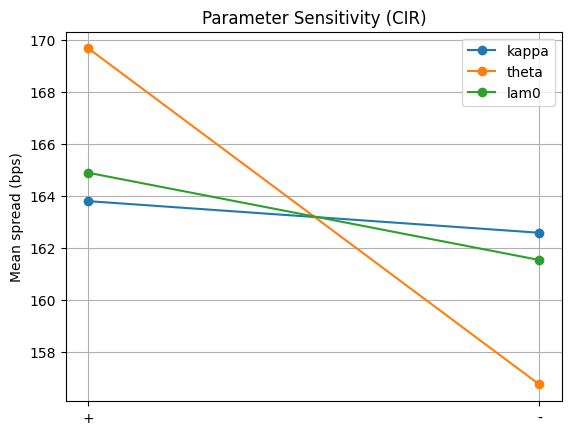

In [83]:
plot_parameter_sensitivity(df_sens)  # Plot parameter sensitivity results (mean spread vs ± perturbations).

## 6. Stress Testing 
<a id="d6"></a>
*(Does it break under stress?)*

### 6.a. Extreme scenarios 
<a id="d6a"></a>
*(How does the model behave under extreme conditions?)*

The stress testing results show that CDS spreads are primarily driven by level parameters rather than stochastic volatility. The long-run mean $\theta$ has the dominant effect, with $\pm$50% shocks producing changes of 30 to 65 basis points, while $\lambda_0$ has a moderate impact (up to 17 bps), particularly at short maturities. In contrast, $\kappa$ has a limited influence ($<$ 10 bps), and shocks to volatility $\sigma$ result in only minor changes ($<$ 2 bps).

Overall, spread sensitivity is concentrated in the deterministic structure of the intensity process, with stochastic volatility contributing negligibly to pricing variation.

In [84]:
# Parameter Stress Testing

def run_deterministic_cir_stress_test(                  # Define one-at-a-time stress test for deterministic CIR parameters.
    maturities,                                         # Maturity grid.
    kappa,                                              # Base mean reversion speed.
    theta,                                              # Base long-run intensity level.
    lam0,                                               # Base initial intensity.
    discount_fn,                                        # Discount function.
    recovery=0.4,                                       # Recovery rate.
    freq=4,                                             # Premium payment frequency.
    accrued=True,                                       # Whether accrued premium is included.
    shock_grid=None                                     # Multiplicative stress factors.
):
    """
    Stress deterministic CIR parameters one at a time.  # Describe purpose of the function.
    shock_grid contains multiplicative shocks, e.g. [0.5, 0.75, 1.0, 1.25, 1.5]  # Document stress grid meaning.
    """
    if shock_grid is None:                              # Use default stress grid if none provided.
        shock_grid = [0.5, 0.75, 1.0, 1.25, 1.5]       # Default multiplicative shocks.

    maturities = np.asarray(maturities, dtype=float)   # Convert maturities to float NumPy array.
    rows = []                                           # Initialize list to collect stress-test results.

    base_params = {"kappa": kappa, "theta": theta, "lam0": lam0}  # Store base parameter values.

    for param_name in ["kappa", "theta", "lam0"]:      # Loop over parameters to stress one at a time.
        for mult in shock_grid:                         # Loop over multiplicative shock levels.
            stressed = base_params.copy()               # Start from base parameter set.
            stressed[param_name] = base_params[param_name] * mult  # Apply stress to selected parameter.

            for T in maturities:                        # Loop over maturities.
                res = price_cds_cir_deterministic(      # Price CDS under stressed deterministic CIR parameters.
                    T=T,                                # Maturity.
                    kappa=stressed["kappa"],            # Stressed or base kappa.
                    theta=stressed["theta"],            # Stressed or base theta.
                    lam0=stressed["lam0"],              # Stressed or base lam0.
                    discount_fn=discount_fn,            # Discount function.
                    recovery=recovery,                  # Recovery rate.
                    freq=freq,                          # Payment frequency.
                    accrued=accrued                     # Include accrued premium if applicable.
                )

                rows.append({
                    "model": "cir_deterministic",       # Record model identifier.
                    "param": param_name,                # Parameter being stressed.
                    "shock_mult": float(mult),          # Multiplicative shock applied.
                    "T": float(T),                      # Maturity.
                    "fair_spread": float(res.fair_spread),      # Model-implied fair spread in decimal.
                    "fair_spread_bps": 1e4 * float(res.fair_spread)  # Fair spread in basis points.
                })

    return pd.DataFrame(rows)                           # Return full stress-test results as DataFrame.

In [85]:
def run_stochastic_cir_sigma_stress_test(               # Define stress test for sigma in stochastic CIR model.
    maturities,                                         # Maturity grid.
    kappa,                                              # Mean reversion speed.
    theta,                                              # Long-run intensity level.
    sigma,                                              # Base volatility parameter.
    lam0,                                               # Initial intensity.
    discount_fn,                                        # Discount function.
    recovery=0.4,                                       # Recovery rate.
    freq=4,                                             # Premium payment frequency.
    accrued=True,                                       # Whether accrued premium is included.
    sigma_shocks=None,                                  # Multiplicative shocks applied to sigma.
    dt=1/500,                                           # Monte Carlo time step.
    n_paths=50000,                                      # Number of simulation paths.
    seed=12345                                          # Random seed.
):
    """
    Stress sigma in stochastic CIR.                     # Describe purpose of the function.
    sigma_shocks contains multiplicative shocks applied to base sigma.  # Document stress grid meaning.
    """
    if sigma_shocks is None:                            # Use default sigma shock grid if none provided.
        sigma_shocks = [0.5, 0.75, 1.0, 1.25, 1.5]     # Default multiplicative shocks.

    maturities = np.asarray(maturities, dtype=float)   # Convert maturities to float NumPy array.
    rows = []                                           # Initialize list to collect stress-test results.

    for mult in sigma_shocks:                           # Loop over sigma shock multipliers.
        sigma_stressed = sigma * mult                   # Apply multiplicative shock to sigma.

        for T in maturities:                            # Loop over maturities.
            res = price_cds_cir_mc(                     # Price CDS under stressed stochastic CIR model.
                T=T,                                    # Maturity.
                kappa=kappa,                            # Mean reversion speed.
                theta=theta,                            # Long-run intensity level.
                sigma=sigma_stressed,                   # Stressed volatility parameter.
                lam0=lam0,                              # Initial intensity.
                discount_fn=discount_fn,                # Discount function.
                recovery=recovery,                      # Recovery rate.
                freq=freq,                              # Payment frequency.
                accrued=accrued,                        # Include accrued premium if applicable.
                dt=dt,                                  # Monte Carlo time step.
                n_paths=n_paths,                        # Number of simulation paths.
                seed=seed                               # Random seed.
            )

            rows.append({
                "model": "cir_mc",                      # Record model identifier.
                "param": "sigma",                       # Record stressed parameter.
                "shock_mult": float(mult),              # Multiplicative sigma shock.
                "sigma_stressed": float(sigma_stressed),# Stressed sigma value.
                "T": float(T),                          # Maturity.
                "fair_spread": float(res.fair_spread), # Model-implied fair spread in decimal.
                "fair_spread_bps": 1e4 * float(res.fair_spread)  # Fair spread in basis points.
            })

    return pd.DataFrame(rows)                           # Return full sigma stress-test results as DataFrame.

In [86]:
def make_base_spread_reference_det(                   # Define function to compute baseline deterministic CIR spreads.
    maturities,                                      # Maturity grid.
    kappa,                                           # Mean reversion speed.
    theta,                                           # Long-run intensity level.
    lam0,                                            # Initial intensity.
    discount_fn,                                     # Discount function.
    recovery=0.4,                                    # Recovery rate.
    freq=4,                                          # Premium payment frequency.
    accrued=True                                     # Whether accrued premium is included.
):
    rows = []                                        # Initialize list to collect base spreads.
    for T in maturities:                             # Loop over maturities.
        res = price_cds_cir_deterministic(           # Price CDS under deterministic CIR model.
            T=T,                                     # Maturity.
            kappa=kappa,                             # Mean reversion speed.
            theta=theta,                             # Long-run intensity level.
            lam0=lam0,                               # Initial intensity.
            discount_fn=discount_fn,                 # Discount function.
            recovery=recovery,                       # Recovery rate.
            freq=freq,                               # Payment frequency.
            accrued=accrued                          # Include accrued premium if applicable.
        )
        rows.append({
            "T": float(T),                           # Maturity.
            "base_spread": float(res.fair_spread),   # Base spread in decimal.
            "base_spread_bps": 1e4 * float(res.fair_spread)  # Base spread in basis points.
        })
    return pd.DataFrame(rows)                        # Return DataFrame of base spreads.

In [87]:
def make_base_spread_reference_mc(                   # Define function to compute baseline stochastic CIR spreads.
    maturities,                                     # Maturity grid.
    kappa,                                          # Mean reversion speed.
    theta,                                          # Long-run intensity level.
    sigma,                                          # Volatility parameter.
    lam0,                                           # Initial intensity.
    discount_fn,                                    # Discount function.
    recovery=0.4,                                   # Recovery rate.
    freq=4,                                         # Premium payment frequency.
    accrued=True,                                   # Whether accrued premium is included.
    dt=1/500,                                       # Monte Carlo time step.
    n_paths=50000,                                  # Number of simulation paths.
    seed=12345                                      # Random seed.
):
    rows = []                                       # Initialize list to collect base spreads.
    for T in maturities:                            # Loop over maturities.
        res = price_cds_cir_mc(                     # Price CDS under stochastic CIR Monte Carlo model.
            T=T,                                    # Maturity.
            kappa=kappa,                            # Mean reversion speed.
            theta=theta,                            # Long-run intensity level.
            sigma=sigma,                            # Volatility parameter.
            lam0=lam0,                              # Initial intensity.
            discount_fn=discount_fn,                # Discount function.
            recovery=recovery,                      # Recovery rate.
            freq=freq,                              # Payment frequency.
            accrued=accrued,                        # Include accrued premium if applicable.
            dt=dt,                                  # Monte Carlo time step.
            n_paths=n_paths,                        # Number of simulation paths.
            seed=seed                               # Random seed.
        )
        rows.append({
            "T": float(T),                          # Maturity.
            "base_spread": float(res.fair_spread),  # Base spread in decimal.
            "base_spread_bps": 1e4 * float(res.fair_spread)  # Base spread in basis points.
        })
    return pd.DataFrame(rows)                       # Return DataFrame of base spreads.

In [88]:
def summarize_stress_results(df_stress, df_base):    # Define function to compare stressed spreads against base spreads.
    """
    Merge stressed results with base results and compute deviations.  # Describe purpose of the function.
    """
    df = df_stress.merge(df_base[["T", "base_spread", "base_spread_bps"]], on="T", how="left")  # Merge stress and base results by maturity.
    df["abs_change_bps"] = np.abs(df["fair_spread_bps"] - df["base_spread_bps"])  # Compute absolute spread change in bps.
    df["signed_change_bps"] = df["fair_spread_bps"] - df["base_spread_bps"]        # Compute signed spread change in bps.

    summary = (
        df.groupby(["param", "shock_mult"], as_index=False)  # Group by stressed parameter and shock size.
        .agg(
            mean_spread_bps=("fair_spread_bps", "mean"),     # Mean stressed spread across maturities.
            mean_abs_change_bps=("abs_change_bps", "mean"),  # Mean absolute change from base in bps.
            max_abs_change_bps=("abs_change_bps", "max")     # Maximum absolute change from base in bps.
        )
    )

    return df, summary                              # Return merged detailed results and grouped summary.

In [89]:
# Plotting

def plot_stress_by_parameter(df_stress, param_name, title=None):   # Define plotting function for stressed term structures of one parameter.
    """
    Plot stressed term structures for a single parameter.          # Describe purpose of the function.
    """
    d = df_stress[df_stress["param"] == param_name].copy()         # Filter results for the selected stressed parameter.

    plt.figure(figsize=(8, 5))                                     # Create a new figure.
    for mult in sorted(d["shock_mult"].unique()):                  # Loop over available shock multipliers in sorted order.
        s = d[d["shock_mult"] == mult].sort_values("T")            # Select one shock level and sort by maturity.
        plt.plot(s["T"], s["fair_spread_bps"], marker="o", label=f"{mult:.2f}x")  # Plot stressed spread curve in bps.

    plt.xlabel("Maturity")                                         # Label x-axis.
    plt.ylabel("Fair spread (bps)")                                # Label y-axis.
    plt.title(title or f"Stress Test: {param_name}")               # Use provided title or default title.
    plt.grid(True)                                                 # Enable grid.
    plt.legend(title="Shock")                                      # Show legend with shock labels.
    plt.show()                                                     # Display plot.


def plot_mean_abs_change(summary_df, title="Mean Absolute Stress Impact"):  # Define plotting function for average stress impact.
    """
    Plot average impact by parameter/shock.                        # Describe purpose of the function.
    """
    plt.figure(figsize=(8, 5))                                     # Create a new figure.

    for param in summary_df["param"].unique():                     # Loop over stressed parameters.
        d = summary_df[summary_df["param"] == param].sort_values("shock_mult")  # Filter and sort summary rows for one parameter.
        plt.plot(d["shock_mult"], d["mean_abs_change_bps"], marker="o", label=param)  # Plot mean absolute change vs shock multiplier.

    plt.xlabel("Shock multiplier")                                 # Label x-axis.
    plt.ylabel("Mean absolute spread change (bps)")                # Label y-axis.
    plt.title(title)                                               # Set plot title.
    plt.grid(True)                                                 # Enable grid.
    plt.legend()                                                   # Show legend.
    plt.show()                                                     # Display plot.

In [90]:
# base parameters

maturities_stress = np.array([1, 2, 3, 5, 7, 10], dtype=float)  # Define maturity grid for stress testing.

kappa = 1.2    # Mean reversion speed parameter.
theta = 0.03   # Long-run intensity level.
lam0 = 0.02    # Initial intensity.
sigma = 0.25   # Volatility parameter (used for stochastic CIR tests).

In [91]:
# Deterministic CIR stress

df_stress_det = run_deterministic_cir_stress_test(   # Run deterministic CIR stress test.
    maturities=maturities_stress,                   # Maturity grid.
    kappa=kappa,                                    # Base kappa.
    theta=theta,                                    # Base theta.
    lam0=lam0,                                      # Base lam0.
    discount_fn=discount_fn,                        # Discount function.
    recovery=0.4,                                   # Recovery rate.
    freq=4,                                         # Payment frequency.
    accrued=True,                                   # Include accrued premium.
    shock_grid=[0.5, 0.75, 1.0, 1.25, 1.5]          # Multiplicative stress levels.
)

df_base_det = make_base_spread_reference_det(       # Compute base deterministic CIR spreads.
    maturities=maturities_stress,                  # Maturity grid.
    kappa=kappa,                                   # Base kappa.
    theta=theta,                                   # Base theta.
    lam0=lam0,                                     # Base lam0.
    discount_fn=discount_fn,                       # Discount function.
    recovery=0.4,                                  # Recovery rate.
    freq=4,                                        # Payment frequency.
    accrued=True                                   # Include accrued premium.
)

df_stress_det_full, summary_stress_det = summarize_stress_results(  # Merge stress and base results and compute deviations.
    df_stress_det,                                                 # Stressed results.
    df_base_det                                                    # Base reference results.
)

print("\n=== Deterministic CIR Stress Summary ===")  # Print header.
print(summary_stress_det)                           # Display aggregated stress summary.


=== Deterministic CIR Stress Summary ===
    param  shock_mult  mean_spread_bps  mean_abs_change_bps  \
0   kappa        0.50       153.851027             9.349266   
1   kappa        0.75       159.523798             3.676495   
2   kappa        1.00       163.200293             0.000000   
3   kappa        1.25       165.788491             2.588198   
4   kappa        1.50       167.711236             4.510942   
5    lam0        0.50       146.454923            16.745370   
6    lam0        0.75       154.820934             8.379359   
7    lam0        1.00       163.200293             0.000000   
8    lam0        1.25       171.593026             8.392733   
9    lam0        1.50       179.999156            16.798863   
10  theta        0.50        98.313827            64.886466   
11  theta        0.75       130.821353            32.378940   
12  theta        1.00       163.200293             0.000000   
13  theta        1.25       195.449697            32.249404   
14  theta    

In [92]:
# Stochastic CIR sigma stress

df_stress_sigma = run_stochastic_cir_sigma_stress_test(   # Run stochastic CIR sigma stress test.
    maturities=maturities_stress,                        # Maturity grid.
    kappa=kappa,                                         # Base kappa.
    theta=theta,                                         # Base theta.
    sigma=sigma,                                         # Base sigma.
    lam0=lam0,                                           # Base lam0.
    discount_fn=discount_fn,                             # Discount function.
    recovery=0.4,                                        # Recovery rate.
    freq=4,                                              # Payment frequency.
    accrued=True,                                        # Include accrued premium.
    sigma_shocks=[0.5, 0.75, 1.0, 1.25, 1.5],           # Multiplicative sigma stress levels.
    dt=1/500,                                            # Monte Carlo time step.
    n_paths=50000,                                       # Number of simulation paths.
    seed=12345                                           # Random seed.
)

df_base_mc = make_base_spread_reference_mc(              # Compute base stochastic CIR spreads.
    maturities=maturities_stress,                        # Maturity grid.
    kappa=kappa,                                         # Base kappa.
    theta=theta,                                         # Base theta.
    sigma=sigma,                                         # Base sigma.
    lam0=lam0,                                           # Base lam0.
    discount_fn=discount_fn,                             # Discount function.
    recovery=0.4,                                        # Recovery rate.
    freq=4,                                              # Payment frequency.
    accrued=True,                                        # Include accrued premium.
    dt=1/500,                                            # Monte Carlo time step.
    n_paths=50000,                                       # Number of simulation paths.
    seed=12345                                           # Random seed.
)

df_stress_sigma_full, summary_stress_sigma = summarize_stress_results(  # Merge sigma-stress and base results and compute deviations.
    df_stress_sigma,                                                    # Sigma-stressed results.
    df_base_mc                                                          # Base Monte Carlo reference results.
)

print("\n=== Stochastic CIR Sigma Stress Summary ===")  # Print header.
print(summary_stress_sigma)                            # Display aggregated sigma stress summary.


=== Stochastic CIR Sigma Stress Summary ===
   param  shock_mult  mean_spread_bps  mean_abs_change_bps  max_abs_change_bps
0  sigma        0.50       162.483147             1.693916            2.412898
1  sigma        0.75       161.754150             0.964919            1.377199
2  sigma        1.00       160.789231             0.000000            0.000000
3  sigma        1.25       159.609628             1.179603            1.693217
4  sigma        1.50       158.214245             2.574986            3.703208


#### I. Deterministic parameter stresses

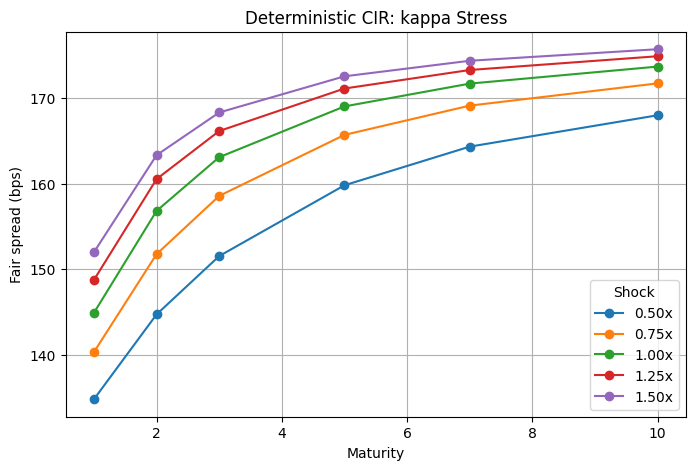

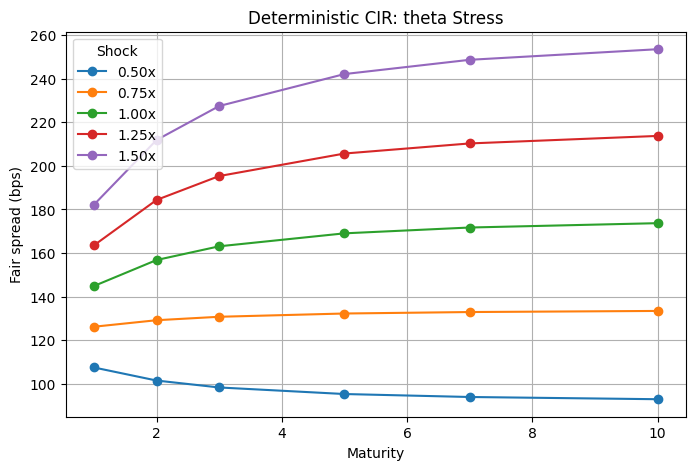

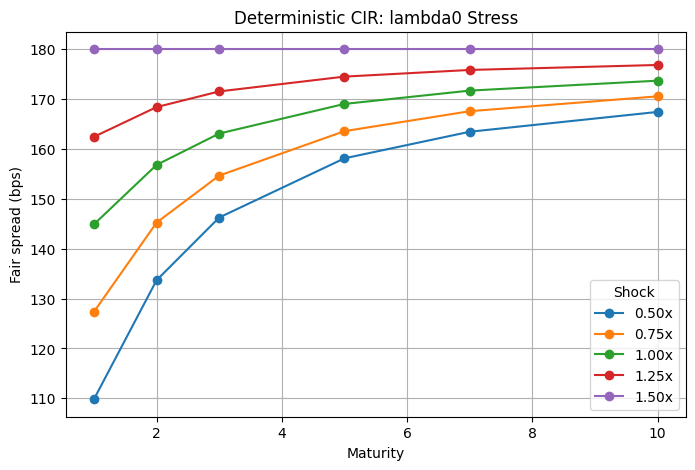

In [93]:
plot_stress_by_parameter(df_stress_det_full, "kappa", title="Deterministic CIR: kappa Stress")   # Plot term structure under kappa shocks.
plot_stress_by_parameter(df_stress_det_full, "theta", title="Deterministic CIR: theta Stress")   # Plot term structure under theta shocks.
plot_stress_by_parameter(df_stress_det_full, "lam0", title="Deterministic CIR: lambda0 Stress")  # Plot term structure under lam0 shocks.

#### II. Sigma stresses

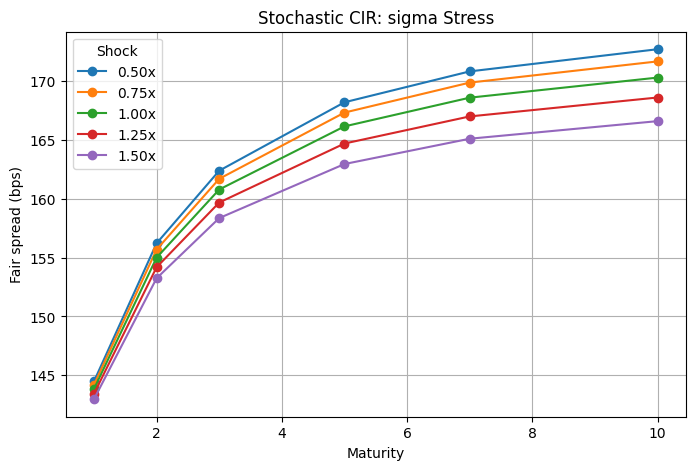

In [94]:
plot_stress_by_parameter(df_stress_sigma_full, "sigma", title="Stochastic CIR: sigma Stress")  # Plot term structure under sigma shocks.

#### III. Summary Impact

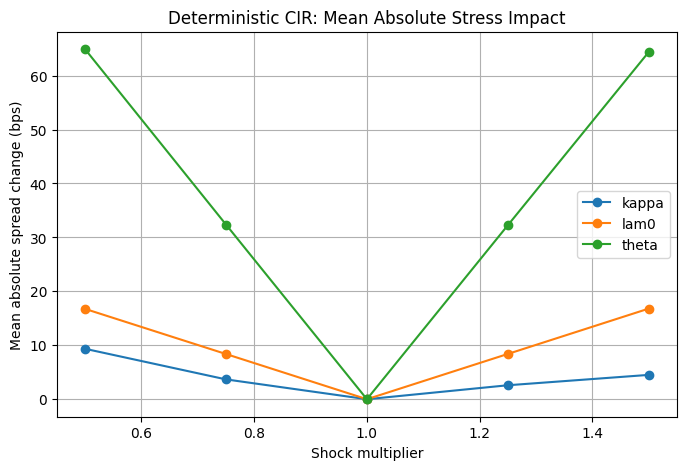

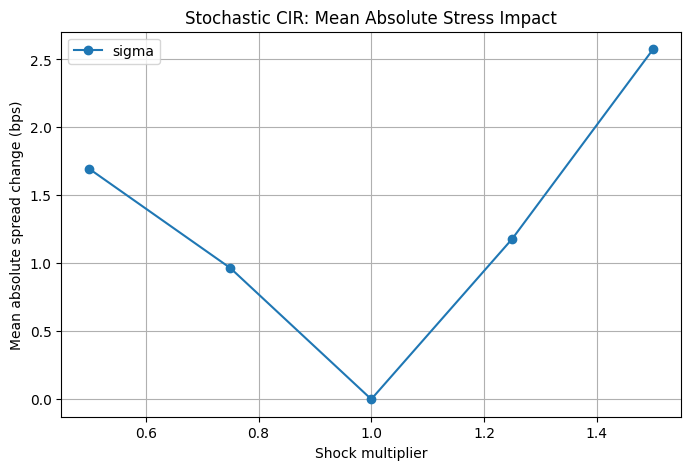

In [95]:
plot_mean_abs_change(summary_stress_det, title="Deterministic CIR: Mean Absolute Stress Impact")   # Plot mean absolute impact for deterministic CIR stresses.
plot_mean_abs_change(summary_stress_sigma, title="Stochastic CIR: Mean Absolute Stress Impact")  # Plot mean absolute impact for stochastic CIR sigma stresses.

### 6.b. Parameter shocks 
<a id="d6b"></a>
*(How do outputs respond to parameter shocks?)*

Scenario stress testing shows that CDS spreads are driven primarily by structural shifts in intensity levels rather than volatility. Persistent deterioration produces the largest impact ($\sim$ 60 to 65 bps, max $\sim$ 70 to 80 bps), while short-term or transitory shocks generate moderate changes ($\sim$ 15 to 17 bps). In contrast, volatility stress has a negligible effect ($<$ 0.3 bps), and does not materially amplify adverse scenarios when combined with level shocks. Overall, stress outcomes are dominated by the deterministic structure of the intensity process.

In [96]:
# Scenario Stress Testing

def make_det_scenarios(base_kappa, base_theta, base_lam0):   # Define deterministic CIR scenario dictionary.
    """
    Deterministic CIR scenario set.                          # Describe purpose of the function.
    """
    return {
        "Base": {                                            # Base scenario with unshocked parameters.
            "kappa": base_kappa,                             # Base kappa.
            "theta": base_theta,                             # Base theta.
            "lam0": base_lam0                                # Base lam0.
        },
        "Short-term distress": {                             # Scenario with elevated initial intensity and slower mean reversion.
            "kappa": 0.75 * base_kappa,                      # Lower kappa.
            "theta": base_theta,                             # Unchanged theta.
            "lam0": 1.50 * base_lam0                         # Higher lam0.
        },
        "Persistent deterioration": {                        # Scenario with elevated long-run level and somewhat higher initial intensity.
            "kappa": 0.75 * base_kappa,                      # Lower kappa.
            "theta": 1.50 * base_theta,                      # Higher theta.
            "lam0": 1.25 * base_lam0                         # Moderately higher lam0.
        },
        "Severe but transitory shock": {                     # Scenario with high initial intensity but faster mean reversion.
            "kappa": 1.50 * base_kappa,                      # Higher kappa.
            "theta": base_theta,                             # Unchanged theta.
            "lam0": 1.50 * base_lam0                         # Higher lam0.
        }
    }

In [97]:
def make_mc_scenarios(base_kappa, base_theta, base_sigma, base_lam0):  # Define stochastic CIR scenario dictionary.
    """
    Stochastic CIR scenario set.                             # Describe purpose of the function.
    """
    return {
        "Base": {                                            # Base stochastic scenario.
            "kappa": base_kappa,                             # Base kappa.
            "theta": base_theta,                             # Base theta.
            "sigma": base_sigma,                             # Base sigma.
            "lam0": base_lam0                                # Base lam0.
        },
        "Volatility stress": {                               # Scenario with sigma shock only.
            "kappa": base_kappa,                             # Unchanged kappa.
            "theta": base_theta,                             # Unchanged theta.
            "sigma": 1.50 * base_sigma,                      # Higher sigma.
            "lam0": base_lam0                                # Unchanged lam0.
        },
        "Persistent deterioration + vol": {                  # Combined level and volatility stress.
            "kappa": 0.75 * base_kappa,                      # Lower kappa.
            "theta": 1.50 * base_theta,                      # Higher theta.
            "sigma": 1.50 * base_sigma,                      # Higher sigma.
            "lam0": 1.25 * base_lam0                         # Higher lam0.
        }
    }

In [98]:
def run_det_scenario_stress(                                # Define deterministic CIR scenario stress runner.
    maturities,                                             # Maturity grid.
    scenarios,                                              # Scenario dictionary.
    discount_fn,                                            # Discount function.
    recovery=0.4,                                           # Recovery rate.
    freq=4,                                                 # Premium payment frequency.
    accrued=True                                            # Whether accrued premium is included.
):
    rows = []                                               # Initialize list to collect scenario results.

    for scen_name, p in scenarios.items():                  # Loop over scenarios.
        for T in maturities:                                # Loop over maturities.
            res = price_cds_cir_deterministic(              # Price CDS under deterministic CIR scenario.
                T=T,                                        # Maturity.
                kappa=p["kappa"],                           # Scenario kappa.
                theta=p["theta"],                           # Scenario theta.
                lam0=p["lam0"],                             # Scenario lam0.
                discount_fn=discount_fn,                    # Discount function.
                recovery=recovery,                          # Recovery rate.
                freq=freq,                                  # Payment frequency.
                accrued=accrued                             # Include accrued premium if applicable.
            )

            rows.append({
                "scenario": scen_name,                      # Scenario name.
                "model": "cir_deterministic",               # Model identifier.
                "T": float(T),                              # Maturity.
                "kappa": float(p["kappa"]),                 # Scenario kappa value.
                "theta": float(p["theta"]),                 # Scenario theta value.
                "lam0": float(p["lam0"]),                   # Scenario lam0 value.
                "fair_spread": float(res.fair_spread),      # Fair spread in decimal.
                "fair_spread_bps": 1e4 * float(res.fair_spread)  # Fair spread in basis points.
            })

    return pd.DataFrame(rows)                               # Return deterministic scenario results as DataFrame.

In [99]:
def run_mc_scenario_stress(                                 # Define stochastic CIR scenario stress runner.
    maturities,                                             # Maturity grid.
    scenarios,                                              # Scenario dictionary.
    discount_fn,                                            # Discount function.
    recovery=0.4,                                           # Recovery rate.
    freq=4,                                                 # Premium payment frequency.
    accrued=True,                                           # Whether accrued premium is included.
    dt=1/500,                                               # Monte Carlo time step.
    n_paths=50000,                                          # Number of simulation paths.
    seed=12345                                              # Random seed.
):
    rows = []                                               # Initialize list to collect scenario results.

    for scen_name, p in scenarios.items():                  # Loop over scenarios.
        for T in maturities:                                # Loop over maturities.
            res = price_cds_cir_mc(                         # Price CDS under stochastic CIR scenario.
                T=T,                                        # Maturity.
                kappa=p["kappa"],                           # Scenario kappa.
                theta=p["theta"],                           # Scenario theta.
                sigma=p["sigma"],                           # Scenario sigma.
                lam0=p["lam0"],                             # Scenario lam0.
                discount_fn=discount_fn,                    # Discount function.
                recovery=recovery,                          # Recovery rate.
                freq=freq,                                  # Payment frequency.
                accrued=accrued,                            # Include accrued premium if applicable.
                dt=dt,                                      # Monte Carlo time step.
                n_paths=n_paths,                            # Number of paths.
                seed=seed                                   # Random seed.
            )

            rows.append({
                "scenario": scen_name,                      # Scenario name.
                "model": "cir_mc",                          # Model identifier.
                "T": float(T),                              # Maturity.
                "kappa": float(p["kappa"]),                 # Scenario kappa value.
                "theta": float(p["theta"]),                 # Scenario theta value.
                "sigma": float(p["sigma"]),                 # Scenario sigma value.
                "lam0": float(p["lam0"]),                   # Scenario lam0 value.
                "fair_spread": float(res.fair_spread),      # Fair spread in decimal.
                "fair_spread_bps": 1e4 * float(res.fair_spread)  # Fair spread in basis points.
            })

    return pd.DataFrame(rows)                               # Return stochastic scenario results as DataFrame.

In [100]:
def summarize_scenario_impacts(df_scen, base_scenario="Base"):  # Define function to summarize scenario impacts relative to base.
    """
    Compute spread changes relative to base scenario.       # Describe purpose of the function.
    """
    base = (
        df_scen[df_scen["scenario"] == base_scenario][["T", "fair_spread_bps"]]  # Extract base-scenario spreads by maturity.
        .rename(columns={"fair_spread_bps": "base_spread_bps"})  # Rename base spread column.
        .copy()                                             # Copy base DataFrame.
    )

    df = df_scen.merge(base, on="T", how="left")            # Merge all scenarios with base spreads by maturity.
    df["signed_change_bps"] = df["fair_spread_bps"] - df["base_spread_bps"]  # Signed change from base in bps.
    df["abs_change_bps"] = np.abs(df["signed_change_bps"])  # Absolute change from base in bps.

    summary = (
        df.groupby("scenario", as_index=False)              # Group by scenario.
        .agg(
            mean_spread_bps=("fair_spread_bps", "mean"),    # Mean spread across maturities.
            mean_abs_change_bps=("abs_change_bps", "mean"), # Mean absolute change from base.
            max_abs_change_bps=("abs_change_bps", "max")    # Maximum absolute change from base.
        )
    )

    return df, summary                                      # Return detailed merged results and scenario summary.

In [101]:
# Plotting

def plot_scenario_term_structures(df_scen, title="Scenario Stress Test"):  # Define function to plot scenario term structures.
    plt.figure(figsize=(8, 5))                                              # Create a new figure.
    for scen in df_scen["scenario"].unique():                               # Loop over scenario names.
        d = df_scen[df_scen["scenario"] == scen].sort_values("T")           # Filter one scenario and sort by maturity.
        plt.plot(d["T"], d["fair_spread_bps"], marker="o", label=scen)      # Plot fair spreads in bps.

    plt.xlabel("Maturity")                                                  # Label x-axis.
    plt.ylabel("Fair spread (bps)")                                         # Label y-axis.
    plt.title(title)                                                        # Set plot title.
    plt.grid(True)                                                          # Enable grid.
    plt.legend()                                                            # Show legend.
    plt.show()                                                              # Display plot.


def plot_scenario_changes(df_scen_full, title="Scenario Stress Impact vs Base"):  # Define function to plot scenario changes relative to base.
    plt.figure(figsize=(8, 5))                                                    # Create a new figure.
    df = df_scen_full[df_scen_full["scenario"] != "Base"].copy()                  # Exclude base scenario from change plot.

    for scen in df["scenario"].unique():                                          # Loop over non-base scenarios.
        d = df[df["scenario"] == scen].sort_values("T")                           # Filter one scenario and sort by maturity.
        plt.plot(d["T"], d["signed_change_bps"], marker="o", label=scen)          # Plot signed spread change in bps.

    plt.axhline(0.0, linestyle="--")                                              # Add zero-reference horizontal line.
    plt.xlabel("Maturity")                                                        # Label x-axis.
    plt.ylabel("Spread change vs Base (bps)")                                     # Label y-axis.
    plt.title(title)                                                              # Set plot title.
    plt.grid(True)                                                                # Enable grid.
    plt.legend()                                                                  # Show legend.
    plt.show()                                                                    # Display plot.

In [102]:
# Baseline

maturities_scen = np.array([1, 2, 3, 5, 7, 10], dtype=float)  # Define maturity grid for scenario stress tests.

kappa = 1.2    # Mean reversion speed parameter.
theta = 0.03   # Long-run intensity level.
lam0 = 0.02    # Initial intensity.
sigma = 0.25   # Volatility parameter (used in stochastic CIR scenarios).

#### I. Deterministic scenarios

In [103]:
det_scenarios = make_det_scenarios(                # Build deterministic CIR scenario set.
    base_kappa=kappa,                              # Base kappa.
    base_theta=theta,                              # Base theta.
    base_lam0=lam0                                 # Base lam0.
)

df_scen_det = run_det_scenario_stress(             # Run deterministic scenario stress test.
    maturities=maturities_scen,                    # Maturity grid.
    scenarios=det_scenarios,                       # Scenario definitions.
    discount_fn=discount_fn,                       # Discount function.
    recovery=0.4,                                  # Recovery rate.
    freq=4,                                        # Payment frequency.
    accrued=True                                   # Include accrued premium.
)

df_scen_det_full, summary_scen_det = summarize_scenario_impacts(  # Compute deviations vs base scenario.
    df_scen_det,                                                  # Scenario results.
    base_scenario="Base"                                          # Reference scenario.
)

print("\n=== Deterministic Scenario Stress Summary ===")  # Print header.
print(summary_scen_det)                                  # Display aggregated scenario impacts.


=== Deterministic Scenario Stress Summary ===
                      scenario  mean_spread_bps  mean_abs_change_bps  \
0                         Base       163.200293             0.000000   
1     Persistent deterioration       228.640371            65.440078   
2  Severe but transitory shock       179.999156            16.798863   
3          Short-term distress       179.999156            16.798863   

   max_abs_change_bps  
0            0.000000  
1           78.964097  
2           35.113075  
3           35.113075  


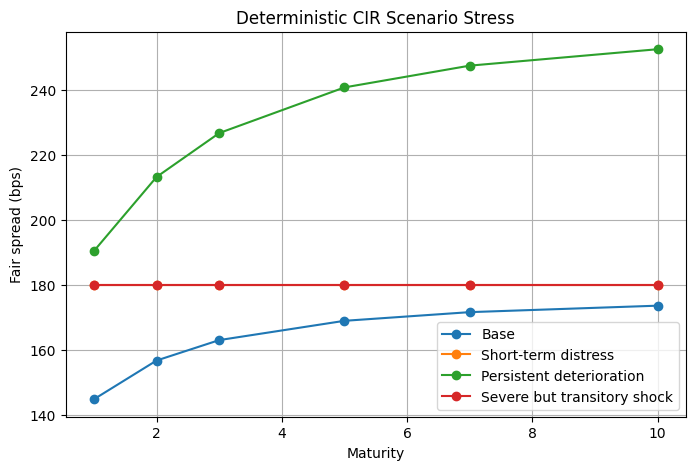

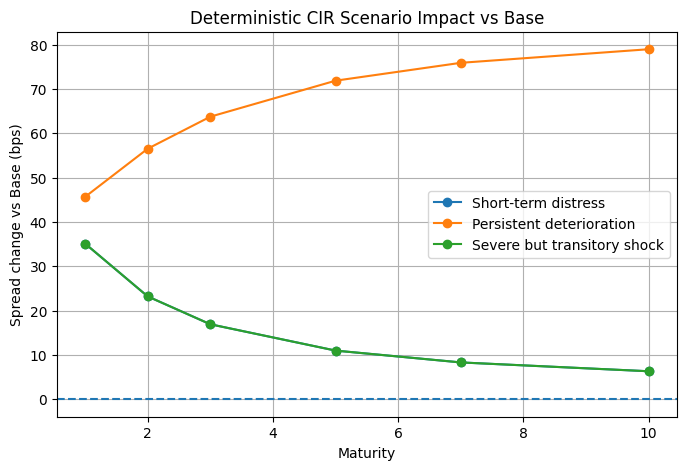

In [104]:
plot_scenario_term_structures(df_scen_det, title="Deterministic CIR Scenario Stress")   # Plot term structures for each deterministic scenario.
plot_scenario_changes(df_scen_det_full, title="Deterministic CIR Scenario Impact vs Base")  # Plot spread changes vs base scenario.

#### II. Stochastic scenarios

In [105]:
mc_scenarios = make_mc_scenarios(                  # Build stochastic CIR scenario set.
    base_kappa=kappa,                              # Base kappa.
    base_theta=theta,                              # Base theta.
    base_sigma=sigma,                              # Base sigma.
    base_lam0=lam0                                 # Base lam0.
)

df_scen_mc = run_mc_scenario_stress(              # Run stochastic CIR scenario stress test.
    maturities=maturities_scen,                    # Maturity grid.
    scenarios=mc_scenarios,                        # Scenario definitions.
    discount_fn=discount_fn,                       # Discount function.
    recovery=0.4,                                  # Recovery rate.
    freq=4,                                        # Payment frequency.
    accrued=True,                                  # Include accrued premium.
    dt=1/500,                                      # Monte Carlo time step.
    n_paths=50000,                                 # Number of simulation paths.
    seed=12345                                     # Random seed.
)

df_scen_mc_full, summary_scen_mc = summarize_scenario_impacts(  # Compute deviations vs base scenario.
    df_scen_mc,                                                 # Scenario results.
    base_scenario="Base"                                        # Reference scenario.
)

print("\n=== Stochastic Scenario Stress Summary ===")  # Print header.
print(summary_scen_mc)                                # Display aggregated scenario impacts.


=== Stochastic Scenario Stress Summary ===
                         scenario  mean_spread_bps  mean_abs_change_bps  \
0                            Base       160.789231             0.000000   
1  Persistent deterioration + vol       218.665855            57.876624   
2               Volatility stress       158.214245             2.574986   

   max_abs_change_bps  
0            0.000000  
1           66.719517  
2            3.703208  


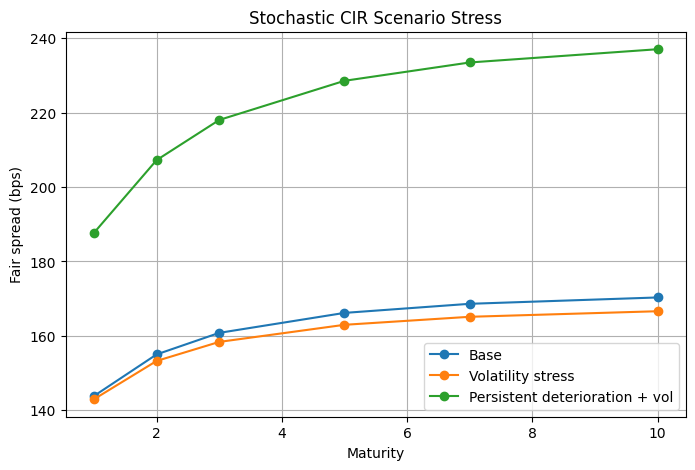

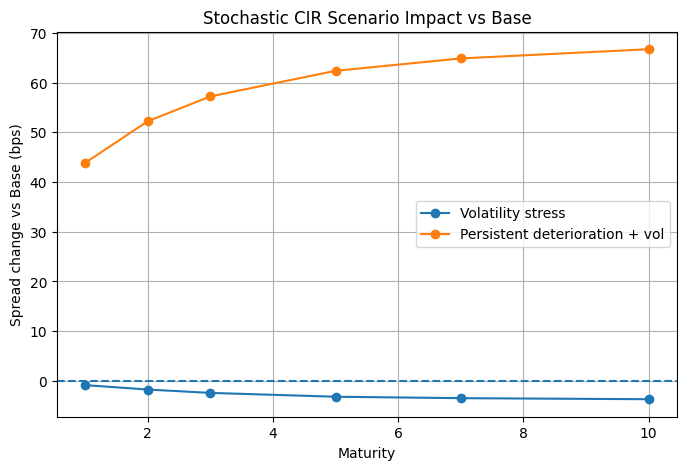

In [106]:
plot_scenario_term_structures(df_scen_mc, title="Stochastic CIR Scenario Stress")   # Plot term structures for each stochastic scenario.
plot_scenario_changes(df_scen_mc_full, title="Stochastic CIR Scenario Impact vs Base")  # Plot spread changes vs base scenario.

### 6.c. Breakdown regions 
<a id="d6c"></a>
*(Where does the model fail or become unstable?)*

Breakdown-region analysis was performed over structural $(\kappa,\sigma)$ and economic $(\lambda_0,R)$ parameter grids. After correcting the Monte Carlo uncertainty estimate to align with the ratio-of-expectations spread estimator, relative standard errors were consistently low ($\approx$ 1.5% to 2.2%) across all configurations, indicating strong numerical stability.

No numerical breakdown was observed: pricing outputs remained finite, smooth, and economically consistent throughout the tested domain. In the $(\kappa,\sigma)$ plane, flagged regions were driven exclusively by severe violations of the CIR Feller condition. However, inspection of boundary points shows that spreads, survival probabilities, and uncertainty measures remain well-behaved across this transition, indicating that these regions reflect structural inadmissibility rather than numerical breakdown.

In contrast, no breakdown was observed across the $(\lambda_0,R)$ grid, where the model remained stable even under extreme credit conditions. These results suggest that the model’s primary vulnerability lies in structurally inconsistent parameter regimes, while its numerical implementation and economic sensitivity are robust across relevant scenarios.

In [107]:
# Pricing wrapper

def price_cds_wrapper(kappa, theta, sigma, lam0, R,            # Define standardized CDS pricing wrapper for breakdown analysis.
                      T=5.0, dt=0.01, N=50000, r=0.03, seed=123, # Set maturity, time step, path count, rate, and seed defaults.
                      annuity_eps=1e-12):                      # Set small threshold to detect annuity collapse.
    """
    Wrap the Section 1 CDS pricing pipeline into a standard interface  # Describe purpose of the wrapper.
    suitable for breakdown-region analysis.                            # State intended use.

    Returns                                                           # Begin return description.
    -------                                                           # Section separator.
    result : dict                                                     # Returned object is a dictionary.
        {                                                             # Dictionary contains the following fields:
            "fair_spread": float,                                     # Model fair spread estimate.
            "survival_T": float,                                      # Survival probability at maturity.
            "std_error": float,                                       # Monte Carlo standard error estimate.
            "annuity_mean": float,                                    # Mean premium-leg annuity estimate.
            "protection_mean": float,                                 # Mean protection-leg estimate.
            "n_valid_paths": int,                                     # Number of paths with non-collapsed annuity.
            "status": "ok" or "fail"                                  # Status flag.
        }
    """
    try:                                                              # Catch numerical or runtime failures.
        # Simulate CIR intensity paths
        times_lam, lam = simulate_cir_full_truncation(                # Simulate CIR intensity paths with full truncation Euler.
            kappa=kappa,                                              # Mean reversion speed.
            theta=theta,                                              # Long-run intensity level.
            sigma=sigma,                                              # Volatility.
            lam0=lam0,                                                # Initial intensity.
            T=T,                                                      # Final horizon.
            dt=dt,                                                    # Time step.
            n_paths=N,                                                # Number of Monte Carlo paths.
            seed=seed                                                 # Random seed for path generation.
        )

        # Cox default times
        tau = default_times_from_paths(lam, dt=dt, seed=seed + 1)     # Generate default times from intensity paths.

        # Fair spread using your ratio-of-expectations estimator
        fair_spread = cds_fair_spread_from_tau(tau=tau, r=r, R=R, T=T, dt=dt)  # Compute fair spread estimate.

        # Survival probability at maturity
        survival_T = np.mean(tau > T)                                 # Estimate survival probability at maturity.

        # Pathwise quantities for diagnostic MC error estimate
        prot_paths = np.exp(-r * tau) * (1.0 - R) * (tau <= T)        # Compute discounted protection-leg payoff pathwise.

        times = np.arange(0.0, T + 1e-12, dt)                         # Build time grid for annuity integration.
        alive = (tau[:, None] > times[None, :]).astype(float)         # Indicator that name has survived to each grid time.
        disc = np.exp(-r * times)[None, :]                            # Discount factors on the time grid.
        vals = disc * alive                                           # Discounted survival process for premium leg.
        annuity_paths = np.trapezoid(vals, times, axis=1)             # Approximate annuity pathwise by trapezoidal integration.

        # Guard against annuity collapse
        valid = annuity_paths > annuity_eps                           # Identify paths with non-negligible annuity.
        n_valid = int(np.sum(valid))                                  # Count valid paths.
        
        if n_valid < 2:                                               # Fail if too few valid paths for variance estimation.
            return {
                "fair_spread": np.nan,                                # Fair spread unavailable.
                "survival_T": float(survival_T),                      # Return survival estimate anyway.
                "std_error": np.nan,                                  # Standard error unavailable.
                "annuity_mean": float(np.mean(annuity_paths)),        # Return mean annuity.
                "protection_mean": float(np.mean(prot_paths)),        # Return mean protection payoff.
                "n_valid_paths": n_valid,                             # Return valid path count.
                "status": "fail"                                      # Mark run as failed.
            }
        
        # Delta-method standard error for fair_spread = E[P] / E[A]
        mu_P = np.mean(prot_paths)                                    # Estimate mean protection leg.
        mu_A = np.mean(annuity_paths)                                 # Estimate mean annuity leg.
        
        if mu_A <= annuity_eps:                                       # Fail if denominator is too small.
            return {
                "fair_spread": np.nan,                                # Fair spread unavailable.
                "survival_T": float(survival_T),                      # Return survival estimate anyway.
                "std_error": np.nan,                                  # Standard error unavailable.
                "annuity_mean": float(mu_A),                          # Return mean annuity.
                "protection_mean": float(mu_P),                       # Return mean protection payoff.
                "n_valid_paths": n_valid,                             # Return valid path count.
                "status": "fail"                                      # Mark run as failed.
            }
        
        var_P = np.var(prot_paths, ddof=1)                            # Sample variance of protection-leg payoff.
        var_A = np.var(annuity_paths, ddof=1)                         # Sample variance of annuity-leg payoff.
        cov_PA = np.cov(prot_paths, annuity_paths, ddof=1)[0, 1]      # Sample covariance between legs.
        
        var_s = (
            var_P / mu_A**2                                           # First delta-method term.
            + (mu_P**2) * var_A / mu_A**4                             # Second delta-method term.
            - 2.0 * mu_P * cov_PA / mu_A**3                           # Covariance correction term.
        )
        var_s = max(var_s, 0.0)                                       # Enforce nonnegative variance estimate.
        
        std_error = np.sqrt(var_s / N)                                # Convert asymptotic variance to standard error of sample estimator.

        return {
            "fair_spread": float(fair_spread),                        # Return fair spread estimate.
            "survival_T": float(survival_T),                          # Return survival probability estimate.
            "std_error": float(std_error),                            # Return delta-method standard error.
            "annuity_mean": float(np.mean(annuity_paths)),            # Return mean annuity estimate.
            "protection_mean": float(np.mean(prot_paths)),            # Return mean protection estimate.
            "n_valid_paths": n_valid,                                 # Return valid path count.
            "status": "ok"                                            # Mark run as successful.
        }

    except Exception:                                                 # Catch any unexpected failure.
        return {
            "fair_spread": np.nan,                                    # Fair spread unavailable.
            "survival_T": np.nan,                                     # Survival probability unavailable.
            "std_error": np.nan,                                      # Standard error unavailable.
            "annuity_mean": np.nan,                                   # Mean annuity unavailable.
            "protection_mean": np.nan,                                # Mean protection unavailable.
            "n_valid_paths": 0,                                       # No valid paths recorded.
            "status": "fail"                                          # Mark run as failed.
        }

In [108]:
# Breakdown classification

def classify_breakdown(result, kappa, theta, sigma,              # Define function to classify whether a parameter point is a breakdown case.
                       spread_cap_bps=5000.0,                    # Maximum plausible fair spread in basis points.
                       rel_se_tol=0.05,                         # Relative standard error tolerance.
                       severe_feller_tol=-0.05,                 # Threshold for severe Feller violation.
                       min_valid_path_frac=0.95,                # Minimum acceptable fraction of valid paths.
                       N_total=None):                           # Total number of simulated paths, if available.
    """
    Classify whether a parameter point lies in a breakdown region.  # Describe purpose of the function.

    Breakdown rules:                                             # Begin list of classification rules.
      1. Pricing failure / non-finite output                     # Rule 1.
      2. Negative spread                                         # Rule 2.
      3. Survival probability outside [0,1]                      # Rule 3.
      4. Implausibly large spread                                # Rule 4.
      5. Relative MC error too large                             # Rule 5.
      6. Severe Feller violation                                 # Rule 6.
      7. Too many invalid paths from annuity collapse            # Rule 7.
    """
    if result["status"] != "ok":                                 # Flag failure if pricing wrapper did not succeed.
        return {"breakdown": True, "reason": "pricing_failure"}  # Return breakdown classification.

    spread = result["fair_spread"]                               # Extract fair spread.
    survival_T = result["survival_T"]                            # Extract survival probability at maturity.
    se = result["std_error"]                                     # Extract Monte Carlo standard error.
    n_valid_paths = result["n_valid_paths"]                      # Extract number of valid paths.

    if not np.isfinite(spread) or not np.isfinite(survival_T) or not np.isfinite(se):  # Check for non-finite outputs.
        return {"breakdown": True, "reason": "nonfinite_output"} # Return breakdown classification.

    if spread < 0:                                               # Flag negative spreads.
        return {"breakdown": True, "reason": "negative_spread"}  # Return breakdown classification.

    if survival_T < 0 or survival_T > 1:                         # Flag invalid survival probabilities.
        return {"breakdown": True, "reason": "invalid_survival_probability"}  # Return breakdown classification.

    spread_bps = 1e4 * spread                                    # Convert fair spread to basis points.
    if spread_bps > spread_cap_bps:                              # Flag implausibly large spreads.
        return {"breakdown": True, "reason": "implausibly_large_spread"}  # Return breakdown classification.

    rel_se = np.inf if spread <= 0 else se / spread              # Compute relative standard error.
    if rel_se > rel_se_tol:                                      # Flag excessive relative MC uncertainty.
        return {"breakdown": True, "reason": "high_relative_mc_error"}  # Return breakdown classification.

    feller_margin = 2.0 * kappa * theta - sigma**2               # Compute CIR Feller margin.
    if feller_margin < severe_feller_tol:                        # Flag severe Feller violations.
        return {"breakdown": True, "reason": "severe_feller_violation"}  # Return breakdown classification.

    if N_total is not None:                                      # If total simulated path count is supplied,
        valid_frac = n_valid_paths / N_total                     # compute fraction of valid paths.
        if valid_frac < min_valid_path_frac:                     # Flag too many invalid paths.
            return {"breakdown": True, "reason": "annuity_collapse"}  # Return breakdown classification.

    return {"breakdown": False, "reason": "ok"}                  # Otherwise classify point as non-breakdown.

In [109]:
# Generic 2D Sweep

def sweep_2d_breakdown(x_name, x_grid, y_name, y_grid,          # Define generic 2D parameter sweep for breakdown analysis.
                       base_params,                              # Baseline parameter dictionary.
                       T=5.0, dt=0.01, N=50000, r=0.03, seed=123, # Pricing and simulation settings.
                       annuity_eps=1e-12,                        # Threshold for annuity collapse guard.
                       spread_cap_bps=5000.0,                    # Maximum plausible spread threshold.
                       rel_se_tol=0.05,                          # Relative standard error tolerance.
                       severe_feller_tol=-0.05,                  # Severe Feller violation threshold.
                       min_valid_path_frac=0.95):                # Minimum acceptable valid-path fraction.
    """
    Generic 2D breakdown sweep over any pair of parameters.      # Describe purpose of the function.

    Parameters                                                   # Begin parameter documentation.
    ----------
    x_name, y_name : str
        Names among {"kappa", "theta", "sigma", "lam0", "R"}.   # Allowed swept parameter names.
    x_grid, y_grid : array-like
        Grid values.                                             # Values for the sweep axes.
    base_params : dict
        Baseline dictionary containing all five model parameters. # Baseline model inputs.

    Returns
    -------
    df : pandas.DataFrame                                        # Returned DataFrame of sweep results.
    """
    rows = []                                                    # Initialize list to collect sweep results.
    ctr = 0                                                      # Initialize counter for varying random seeds.

    for x in x_grid:                                             # Loop over x-axis grid values.
        for y in y_grid:                                         # Loop over y-axis grid values.
            ctr += 1                                             # Increment counter for current grid point.

            params = base_params.copy()                          # Copy baseline parameters.
            params[x_name] = float(x)                            # Set x-axis parameter value.
            params[y_name] = float(y)                            # Set y-axis parameter value.

            result = price_cds_wrapper(                          # Run pricing wrapper at this parameter point.
                kappa=params["kappa"],                           # Kappa value.
                theta=params["theta"],                           # Theta value.
                sigma=params["sigma"],                           # Sigma value.
                lam0=params["lam0"],                             # Initial intensity.
                R=params["R"],                                   # Recovery rate.
                T=T,                                             # Maturity horizon.
                dt=dt,                                           # Time step.
                N=N,                                             # Number of paths.
                r=r,                                             # Risk-free rate.
                seed=seed + ctr,                                 # Use distinct seed for each grid point.
                annuity_eps=annuity_eps                          # Annuity-collapse threshold.
            )

            label = classify_breakdown(                          # Classify whether this point is a breakdown case.
                result=result,                                   # Pricing result dictionary.
                kappa=params["kappa"],                           # Kappa value.
                theta=params["theta"],                           # Theta value.
                sigma=params["sigma"],                           # Sigma value.
                spread_cap_bps=spread_cap_bps,                   # Spread cap threshold.
                rel_se_tol=rel_se_tol,                           # Relative SE tolerance.
                severe_feller_tol=severe_feller_tol,             # Feller violation tolerance.
                min_valid_path_frac=min_valid_path_frac,         # Minimum valid-path fraction.
                N_total=N                                        # Total number of simulated paths.
            )

            spread = result["fair_spread"]                       # Extract fair spread.
            se = result["std_error"]                             # Extract standard error.
            rel_se = np.nan if (not np.isfinite(spread) or spread <= 0 or not np.isfinite(se)) else se / spread  # Compute relative SE when well-defined.

            rows.append({
                x_name: float(x),                                # Record x-axis parameter value.
                y_name: float(y),                                # Record y-axis parameter value.
                "kappa": params["kappa"],                        # Record full parameter set: kappa.
                "theta": params["theta"],                        # Record full parameter set: theta.
                "sigma": params["sigma"],                        # Record full parameter set: sigma.
                "lam0": params["lam0"],                          # Record full parameter set: lam0.
                "R": params["R"],                                # Record full parameter set: recovery.
                "fair_spread": spread,                           # Fair spread in decimal.
                "fair_spread_bps": np.nan if not np.isfinite(spread) else 1e4 * spread,  # Fair spread in bps.
                "survival_T": result["survival_T"],              # Survival probability at maturity.
                "std_error": se,                                 # Standard error estimate.
                "rel_std_error": rel_se,                         # Relative standard error.
                "annuity_mean": result["annuity_mean"],          # Mean annuity estimate.
                "protection_mean": result["protection_mean"],    # Mean protection estimate.
                "n_valid_paths": result["n_valid_paths"],        # Number of valid paths.
                "valid_path_frac": result["n_valid_paths"] / N if N > 0 else np.nan,  # Fraction of valid paths.
                "feller_margin": 2.0 * params["kappa"] * params["theta"] - params["sigma"]**2,  # CIR Feller margin.
                "pricing_status": result["status"],              # Pricing wrapper status.
                "breakdown": label["breakdown"],                 # Breakdown indicator.
                "breakdown_reason": label["reason"]              # Breakdown reason.
            })

    return pd.DataFrame(rows)                                    # Return sweep results as DataFrame.

In [110]:
# Summary table

def summarize_breakdown(df):                         # Define function to summarize breakdown reasons.
    summary = (
        df.groupby("breakdown_reason")               # Group by breakdown reason.
          .size()                                    # Count occurrences in each group.
          .reset_index(name="count")                 # Convert counts to DataFrame with column "count".
          .sort_values("count", ascending=False)     # Sort by frequency (descending).
          .reset_index(drop=True)                    # Reset index after sorting.
    )
    summary["pct"] = 100.0 * summary["count"] / len(df)  # Compute percentage of total observations.
    return summary                                  # Return summary table.

In [111]:
# Plotting helpers

def plot_breakdown_heatmap(df, x_col, y_col, title="Breakdown region map"):  # Define heatmap plot for binary breakdown indicator.
    """
    Heatmap of binary breakdown indicator.                                   # Describe purpose of the function.
    """
    pivot = df.pivot(index=y_col, columns=x_col, values="breakdown").astype(float)  # Reshape breakdown flag into 2D grid.

    plt.figure(figsize=(8, 5))                                               # Create a new figure.
    plt.imshow(
        pivot.values,                                                         # Plot 2D breakdown values.
        origin="lower",                                                       # Put lowest y-value at bottom.
        aspect="auto",                                                        # Let aspect ratio adjust automatically.
        extent=[pivot.columns.min(), pivot.columns.max(),                     # Set x/y axis extents from pivot grid.
                pivot.index.min(), pivot.index.max()]
    )
    plt.colorbar(label="Breakdown flag (1 = yes, 0 = no)")                    # Add colorbar with label.
    plt.xlabel(x_col)                                                         # Label x-axis.
    plt.ylabel(y_col)                                                         # Label y-axis.
    plt.title(title)                                                          # Set plot title.
    plt.show()                                                                # Display plot.


def plot_metric_heatmap(df, x_col, y_col, value_col, title=None):            # Define heatmap plot for any scalar metric.
    """
    Heatmap for any scalar metric, e.g. fair_spread_bps, rel_std_error, survival_T.  # Describe purpose of the function.
    """
    pivot = df.pivot(index=y_col, columns=x_col, values=value_col)            # Reshape selected metric into 2D grid.

    plt.figure(figsize=(8, 5))                                                # Create a new figure.
    plt.imshow(
        pivot.values,                                                          # Plot 2D metric values.
        origin="lower",                                                        # Put lowest y-value at bottom.
        aspect="auto",                                                         # Let aspect ratio adjust automatically.
        extent=[pivot.columns.min(), pivot.columns.max(),                      # Set x/y axis extents from pivot grid.
                pivot.index.min(), pivot.index.max()]
    )
    plt.colorbar(label=value_col)                                              # Add colorbar labeled by metric name.
    plt.xlabel(x_col)                                                          # Label x-axis.
    plt.ylabel(y_col)                                                          # Label y-axis.
    plt.title(title or value_col)                                              # Use provided title or metric name.
    plt.show()                                                                 # Display plot.


def encode_breakdown_reason(reason):                                           # Define encoder from textual reason to integer code.
    mapping = {
        "ok": 0,                                                               # No breakdown.
        "pricing_failure": 1,                                                  # Pricing failed.
        "nonfinite_output": 2,                                                 # Non-finite outputs.
        "negative_spread": 3,                                                  # Negative spread.
        "invalid_survival_probability": 4,                                     # Invalid survival probability.
        "implausibly_large_spread": 5,                                         # Implausibly large spread.
        "high_relative_mc_error": 6,                                           # Excessive relative Monte Carlo error.
        "severe_feller_violation": 7,                                          # Severe Feller condition violation.
        "annuity_collapse": 8                                                  # Too many invalid annuity paths.
    }
    return mapping.get(reason, 99)                                             # Return mapped code, or 99 if unknown.


def plot_breakdown_reason_map(df, x_col, y_col, title="Breakdown reason map"): # Define heatmap plot for categorical breakdown reasons.
    """
    Heatmap of categorical breakdown reasons encoded as integers.              # Describe purpose of the function.
    """
    tmp = df.copy()                                                            # Copy input DataFrame.
    tmp["reason_code"] = tmp["breakdown_reason"].map(encode_breakdown_reason)  # Encode textual reasons as integers.
    pivot = tmp.pivot(index=y_col, columns=x_col, values="reason_code")        # Reshape encoded reasons into 2D grid.

    plt.figure(figsize=(8, 5))                                                 # Create a new figure.
    plt.imshow(
        pivot.values,                                                           # Plot 2D reason codes.
        origin="lower",                                                         # Put lowest y-value at bottom.
        aspect="auto",                                                          # Let aspect ratio adjust automatically.
        extent=[pivot.columns.min(), pivot.columns.max(),                       # Set x/y axis extents from pivot grid.
                pivot.index.min(), pivot.index.max()]
    )
    cbar = plt.colorbar()                                                       # Add colorbar.
    cbar.set_label("Reason code")                                               # Label colorbar.
    plt.xlabel(x_col)                                                           # Label x-axis.
    plt.ylabel(y_col)                                                           # Label y-axis.
    plt.title(title)                                                            # Set plot title.
    plt.show()                                                                  # Display plot.

    print("Reason code legend:")                                                # Print legend header.
    print("0 = ok")                                                             # Print code meaning.
    print("1 = pricing_failure")                                                # Print code meaning.
    print("2 = nonfinite_output")                                               # Print code meaning.
    print("3 = negative_spread")                                                # Print code meaning.
    print("4 = invalid_survival_probability")                                   # Print code meaning.
    print("5 = implausibly_large_spread")                                       # Print code meaning.
    print("6 = high_relative_mc_error")                                         # Print code meaning.
    print("7 = severe_feller_violation")                                        # Print code meaning.
    print("8 = annuity_collapse")                                               # Print code meaning.

In [112]:
# Convenience runners

def run_breakdown_kappa_sigma(base_params,                    # Define convenience runner for breakdown sweep over (kappa, sigma).
                              kappa_grid,                     # Grid of kappa values.
                              sigma_grid,                     # Grid of sigma values.
                              T=5.0, dt=0.01, N=50000, r=0.03, seed=123,  # Pricing and simulation settings.
                              annuity_eps=1e-12,             # Threshold for annuity collapse guard.
                              spread_cap_bps=5000.0,         # Maximum plausible spread threshold.
                              rel_se_tol=0.05,               # Relative standard error tolerance.
                              severe_feller_tol=-0.05,       # Severe Feller violation threshold.
                              min_valid_path_frac=0.95,      # Minimum acceptable valid-path fraction.
                              make_plots=True):              # Whether to generate diagnostic plots.
    """
    Structural breakdown map over (kappa, sigma).             # Describe purpose of the function.
    """
    df = sweep_2d_breakdown(                                  # Run generic 2D breakdown sweep.
        x_name="kappa",                                       # Sweep kappa along x-axis.
        x_grid=kappa_grid,                                    # Use provided kappa grid.
        y_name="sigma",                                       # Sweep sigma along y-axis.
        y_grid=sigma_grid,                                    # Use provided sigma grid.
        base_params=base_params,                              # Baseline parameter dictionary.
        T=T, dt=dt, N=N, r=r, seed=seed,                      # Pass pricing and simulation settings.
        annuity_eps=annuity_eps,                              # Pass annuity threshold.
        spread_cap_bps=spread_cap_bps,                        # Pass spread cap threshold.
        rel_se_tol=rel_se_tol,                                # Pass relative SE tolerance.
        severe_feller_tol=severe_feller_tol,                  # Pass Feller threshold.
        min_valid_path_frac=min_valid_path_frac               # Pass valid-path fraction threshold.
    )

    if make_plots:                                            # Generate plots if requested.
        plot_breakdown_heatmap(                               # Plot binary breakdown heatmap.
            df, x_col="kappa", y_col="sigma",                 # Use kappa and sigma axes.
            title="Breakdown regions in $(\\kappa, \\sigma)$ space"  # Set plot title.
        )
        plot_breakdown_reason_map(                            # Plot categorical breakdown-reason heatmap.
            df, x_col="kappa", y_col="sigma",                 # Use kappa and sigma axes.
            title="Breakdown reasons in $(\\kappa, \\sigma)$ space"  # Set plot title.
        )
        plot_metric_heatmap(                                  # Plot fair spread heatmap.
            df, x_col="kappa", y_col="sigma", value_col="fair_spread_bps",  # Use fair spread in bps.
            title="Fair spread (bps) in $(\\kappa, \\sigma)$ space"          # Set plot title.
        )
        plot_metric_heatmap(                                  # Plot relative MC error heatmap.
            df, x_col="kappa", y_col="sigma", value_col="rel_std_error",     # Use relative standard error.
            title="Relative MC error in $(\\kappa, \\sigma)$ space"          # Set plot title.
        )

    return df                                                 # Return full sweep results.


def run_breakdown_lam0_R(base_params,                         # Define convenience runner for breakdown sweep over (lam0, R).
                         lam0_grid,                           # Grid of lam0 values.
                         R_grid,                              # Grid of recovery values.
                         T=5.0, dt=0.01, N=50000, r=0.03, seed=123,  # Pricing and simulation settings.
                         annuity_eps=1e-12,                  # Threshold for annuity collapse guard.
                         spread_cap_bps=5000.0,              # Maximum plausible spread threshold.
                         rel_se_tol=0.05,                    # Relative standard error tolerance.
                         severe_feller_tol=-0.05,            # Severe Feller violation threshold.
                         min_valid_path_frac=0.95,           # Minimum acceptable valid-path fraction.
                         make_plots=True):                   # Whether to generate diagnostic plots.
    """
    Economic breakdown map over (lam0, R).                   # Describe purpose of the function.
    """
    df = sweep_2d_breakdown(                                 # Run generic 2D breakdown sweep.
        x_name="lam0",                                       # Sweep lam0 along x-axis.
        x_grid=lam0_grid,                                    # Use provided lam0 grid.
        y_name="R",                                          # Sweep recovery along y-axis.
        y_grid=R_grid,                                       # Use provided recovery grid.
        base_params=base_params,                             # Baseline parameter dictionary.
        T=T, dt=dt, N=N, r=r, seed=seed,                     # Pass pricing and simulation settings.
        annuity_eps=annuity_eps,                             # Pass annuity threshold.
        spread_cap_bps=spread_cap_bps,                       # Pass spread cap threshold.
        rel_se_tol=rel_se_tol,                               # Pass relative SE tolerance.
        severe_feller_tol=severe_feller_tol,                 # Pass Feller threshold.
        min_valid_path_frac=min_valid_path_frac              # Pass valid-path fraction threshold.
    )

    if make_plots:                                           # Generate plots if requested.
        plot_breakdown_heatmap(                              # Plot binary breakdown heatmap.
            df, x_col="lam0", y_col="R",                     # Use lam0 and R axes.
            title="Breakdown regions in $(\\lambda_0, R)$ space"  # Set plot title.
        )
        plot_breakdown_reason_map(                           # Plot categorical breakdown-reason heatmap.
            df, x_col="lam0", y_col="R",                     # Use lam0 and R axes.
            title="Breakdown reasons in $(\\lambda_0, R)$ space"  # Set plot title.
        )
        plot_metric_heatmap(                                 # Plot fair spread heatmap.
            df, x_col="lam0", y_col="R", value_col="fair_spread_bps",  # Use fair spread in bps.
            title="Fair spread (bps) in $(\\lambda_0, R)$ space"       # Set plot title.
        )
        plot_metric_heatmap(                                 # Plot relative MC error heatmap.
            df, x_col="lam0", y_col="R", value_col="rel_std_error",     # Use relative standard error.
            title="Relative MC error in $(\\lambda_0, R)$ space"        # Set plot title.
        )

    return df                                                # Return full sweep results.

In [113]:
# Baseline calibrated / reference parameters
base_params = {                  # Define baseline parameter dictionary for breakdown sweeps.
    "kappa": 1.2,                # Mean reversion speed.
    "theta": 0.03,               # Long-run intensity level.
    "sigma": 0.25,               # Volatility parameter.
    "lam0": 0.02,                # Initial intensity.
    "R": 0.40                    # Recovery rate.
}

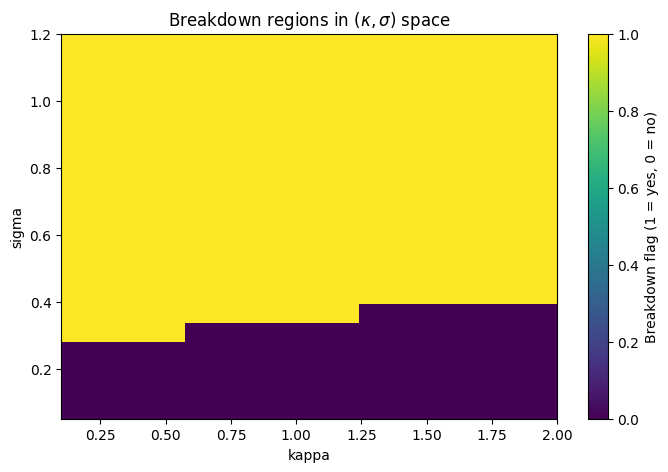

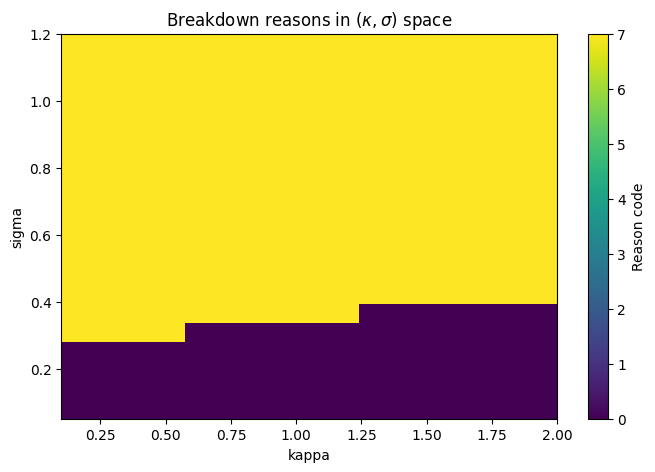

Reason code legend:
0 = ok
1 = pricing_failure
2 = nonfinite_output
3 = negative_spread
4 = invalid_survival_probability
5 = implausibly_large_spread
6 = high_relative_mc_error
7 = severe_feller_violation
8 = annuity_collapse


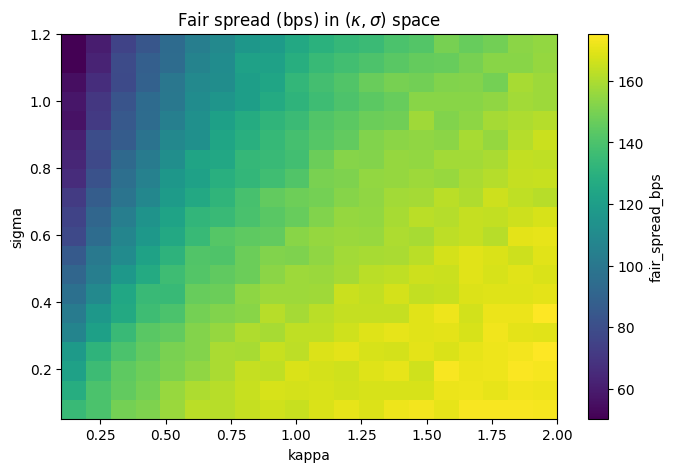

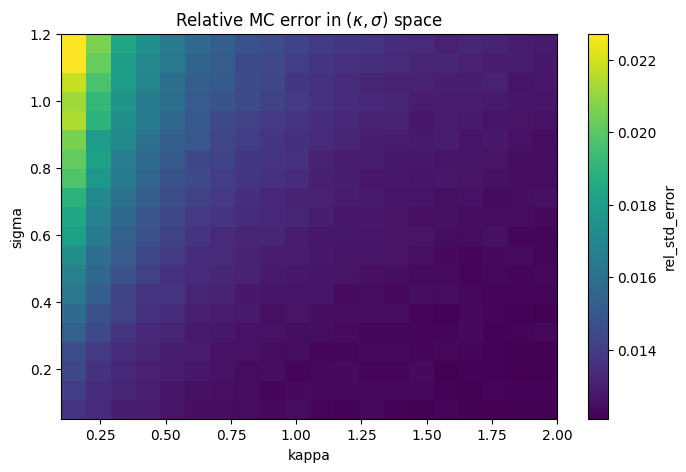


=== Breakdown summary: (kappa, sigma) ===


,breakdown_reason,count,pct
0,severe_feller_violation,297,74.25
1,ok,103,25.75


,kappa,sigma,theta,lam0,R,fair_spread,fair_spread_bps,survival_T,std_error,rel_std_error,annuity_mean,protection_mean,n_valid_paths,valid_path_frac,feller_margin,pricing_status,breakdown,breakdown_reason
0,0.1,0.050000,0.03,0.02,0.4,0.013502,135.017210,0.89328,0.000185,0.013686,4.402272,0.059438,50000,1.0,0.003500,ok,False,ok
1,0.1,0.110526,0.03,0.02,0.4,0.012840,128.395412,0.89836,0.000180,0.014032,4.411743,0.056645,50000,1.0,-0.006216,ok,False,ok
2,0.1,0.171053,0.03,0.02,0.4,0.012202,122.015832,0.90338,0.000176,0.014404,4.419109,0.053920,50000,1.0,-0.023259,ok,False,ok
3,0.1,0.231579,0.03,0.02,0.4,0.011861,118.607746,0.90610,0.000173,0.014622,4.422512,0.052454,50000,1.0,-0.047629,ok,False,ok
4,0.1,0.292105,0.03,0.02,0.4,0.010690,106.904258,0.91520,0.000165,0.015403,4.439144,0.047456,50000,1.0,-0.079325,ok,True,severe_feller_violation


In [114]:
# Structural breakdown study: (kappa, sigma)
kappa_grid = np.linspace(0.10, 2.00, 20)          # Create grid of kappa values from 0.10 to 2.00 (20 points).
sigma_grid = np.linspace(0.05, 1.20, 20)          # Create grid of sigma values from 0.05 to 1.20 (20 points).

df_break_ks = run_breakdown_kappa_sigma(          # Run breakdown sweep over (kappa, sigma).
    base_params=base_params,                      # Use baseline parameter set.
    kappa_grid=kappa_grid,                        # Pass kappa grid.
    sigma_grid=sigma_grid,                        # Pass sigma grid.
    T=5.0,                                        # CDS maturity = 5 years.
    dt=0.01,                                      # Time discretization step for simulation.
    N=50000,                                      # Number of Monte Carlo paths.
    r=0.03,                                       # Constant risk-free rate.
    seed=123,                                     # Base random seed.
    annuity_eps=1e-12,                            # Threshold for annuity collapse detection.
    spread_cap_bps=5000.0,                        # Cap for plausible spreads (bps).
    rel_se_tol=0.05,                              # Relative MC error tolerance.
    severe_feller_tol=-0.05,                      # Threshold for severe Feller violation.
    min_valid_path_frac=0.95,                     # Minimum fraction of valid paths required.
    make_plots=True                               # Enable plotting of results.
)

print("\n=== Breakdown summary: (kappa, sigma) ===")  # Print section header.
display(summarize_breakdown(df_break_ks))            # Display breakdown reason summary.
display(df_break_ks.head())                          # Display first few rows of full results.

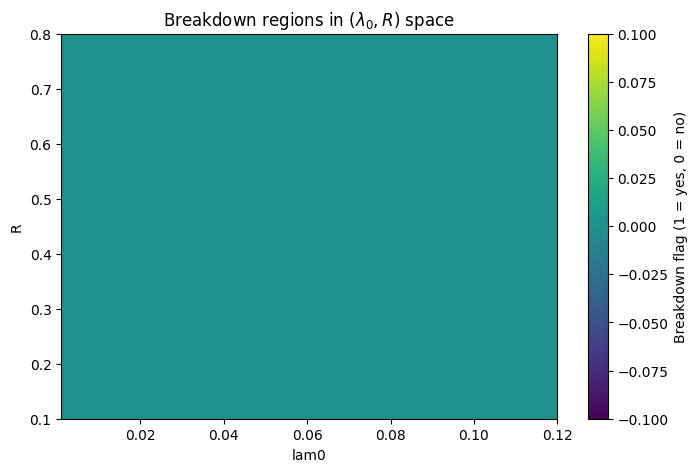

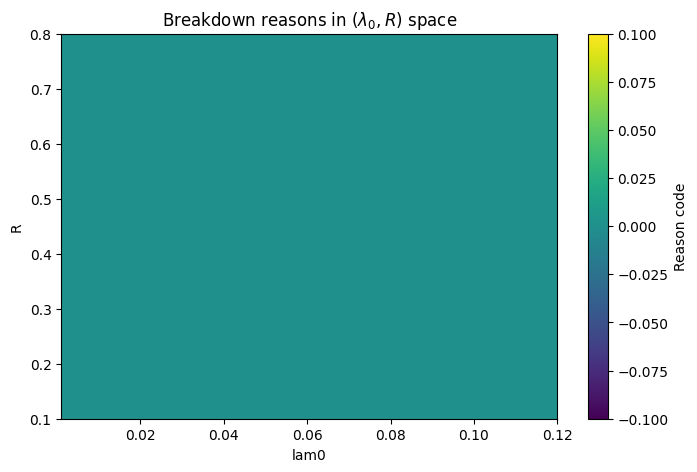

Reason code legend:
0 = ok
1 = pricing_failure
2 = nonfinite_output
3 = negative_spread
4 = invalid_survival_probability
5 = implausibly_large_spread
6 = high_relative_mc_error
7 = severe_feller_violation
8 = annuity_collapse


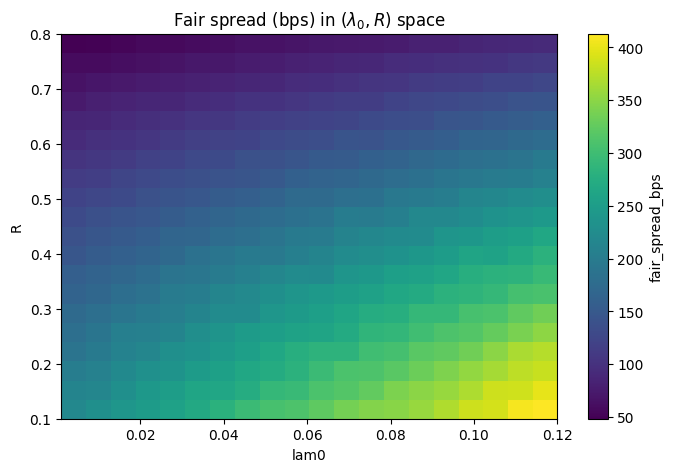

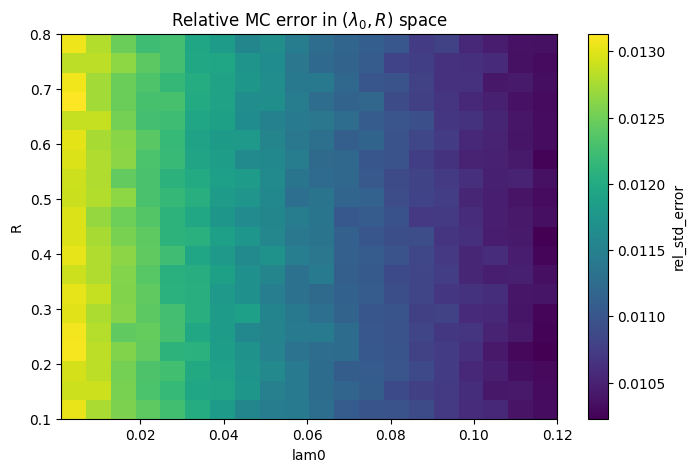


=== Breakdown summary: (lam0, R) ===


,breakdown_reason,count,pct
0,ok,400,100.0


,lam0,R,kappa,theta,sigma,fair_spread,fair_spread_bps,survival_T,std_error,rel_std_error,annuity_mean,protection_mean,n_valid_paths,valid_path_frac,feller_margin,pricing_status,breakdown,breakdown_reason
0,0.001,0.100000,1.2,0.03,0.25,0.021821,218.208399,0.88398,0.000284,0.013034,4.408400,0.096195,50000,1.0,0.0095,ok,False,ok
1,0.001,0.136842,1.2,0.03,0.25,0.021324,213.239283,0.88184,0.000275,0.012912,4.405062,0.093933,50000,1.0,0.0095,ok,False,ok
2,0.001,0.173684,1.2,0.03,0.25,0.020305,203.049452,0.88242,0.000263,0.012943,4.406546,0.089475,50000,1.0,0.0095,ok,False,ok
3,0.001,0.210526,1.2,0.03,0.25,0.018927,189.265735,0.88506,0.000248,0.013089,4.413374,0.083530,50000,1.0,0.0095,ok,False,ok
4,0.001,0.247368,1.2,0.03,0.25,0.018133,181.329634,0.88474,0.000237,0.013083,4.408748,0.079944,50000,1.0,0.0095,ok,False,ok


In [115]:
# Economic breakdown study: (lam0, R)
lam0_grid = np.linspace(0.001, 0.12, 20)        # Create grid of initial intensity values.
R_grid = np.linspace(0.10, 0.80, 20)            # Create grid of recovery rates.

df_break_lr = run_breakdown_lam0_R(              # Run breakdown sweep over (lam0, R).
    base_params=base_params,                    # Use baseline parameter set.
    lam0_grid=lam0_grid,                        # Pass lam0 grid.
    R_grid=R_grid,                              # Pass recovery grid.
    T=5.0,                                      # CDS maturity = 5 years.
    dt=0.01,                                    # Time discretization step.
    N=50000,                                    # Number of Monte Carlo paths.
    r=0.03,                                     # Constant risk-free rate.
    seed=456,                                   # Base random seed.
    annuity_eps=1e-12,                          # Threshold for annuity collapse detection.
    spread_cap_bps=5000.0,                      # Cap for plausible spreads (bps).
    rel_se_tol=0.05,                            # Relative MC error tolerance.
    severe_feller_tol=-0.05,                    # Threshold for severe Feller violation.
    min_valid_path_frac=0.95,                   # Minimum acceptable fraction of valid paths.
    make_plots=True                             # Enable plotting.
)

print("\n=== Breakdown summary: (lam0, R) ===")  # Print section header.
display(summarize_breakdown(df_break_lr))      # Display breakdown reason summary.
display(df_break_lr.head())                    # Display first few rows of results.

In [119]:
def feller_boundary_table(df, top_n=15):                      # Define function to extract points near the Feller boundary.
    out = df.copy()                                           # Create a copy of the input DataFrame.
    out["abs_feller_margin"] = np.abs(out["feller_margin"])   # Compute absolute Feller margin (distance from boundary).
    cols = [                                                   # Define columns to retain in output.
        "kappa", "sigma", "theta", "lam0", "R",                # Model parameters.
        "fair_spread_bps", "survival_T", "std_error", "rel_std_error",  # Pricing and error diagnostics.
        "feller_margin", "breakdown", "breakdown_reason"       # Feller metric and breakdown classification.
    ]
    return (out[cols + ["abs_feller_margin"]]                  # Select relevant columns plus absolute margin.
            .sort_values("abs_feller_margin")                     # Sort by proximity to Feller boundary.
            .head(top_n)                                          # Keep top_n closest points.
            .reset_index(drop=True))                               # Reset index for clean output.

In [120]:
display(feller_boundary_table(df_break_ks, top_n=20))  # Display the 20 points closest to the Feller boundary from (kappa, sigma) sweep.

,kappa,sigma,theta,lam0,R,fair_spread_bps,survival_T,std_error,rel_std_error,feller_margin,breakdown,breakdown_reason,abs_feller_margin
0,0.2,0.110526,0.03,0.02,0.4,139.759974,0.88968,0.000188,0.013456,-0.000216,False,ok,0.000216
1,0.9,0.231579,0.03,0.02,0.4,164.976002,0.87106,0.000205,0.012442,0.000371,False,ok,0.000371
2,0.5,0.171053,0.03,0.02,0.4,150.754831,0.88116,0.000195,0.012944,0.000741,False,ok,0.000741
3,1.4,0.292105,0.03,0.02,0.4,170.808470,0.86682,0.000209,0.012240,-0.001325,False,ok,0.001325
4,0.1,0.050000,0.03,0.02,0.4,135.017210,0.89328,0.000185,0.013686,0.003500,False,ok,0.003500
5,2.0,0.352632,0.03,0.02,0.4,175.312642,0.86358,0.000212,0.012095,-0.004349,False,ok,0.004349
6,1.5,0.292105,0.03,0.02,0.4,169.781136,0.86748,0.000208,0.012267,0.004675,False,ok,0.004675
7,0.4,0.171053,0.03,0.02,0.4,147.523564,0.88366,0.000193,0.013088,-0.005259,False,ok,0.005259
8,0.8,0.231579,0.03,0.02,0.4,158.834382,0.87522,0.000201,0.012631,-0.005629,False,ok,0.005629
9,0.3,0.110526,0.03,0.02,0.4,145.293616,0.88524,0.000191,0.013175,0.005784,False,ok,0.005784


In [121]:
def extreme_metric_table(df, top_n=10, metric="fair_spread_bps", ascending=False):  # Define function to extract extreme values of a chosen metric.
    cols = [                                                                        # Define columns to retain in output.
        "lam0", "R", "kappa", "theta", "sigma",                                     # Model parameters.
        "fair_spread_bps", "survival_T", "std_error", "rel_std_error",              # Pricing outputs and diagnostics.
        "feller_margin", "breakdown_reason"                                         # Structural indicator and classification.
    ]
    return (df[cols]                                                                # Select relevant columns.
        .sort_values(metric, ascending=ascending)                                   # Sort by specified metric.
        .head(top_n)                                                                # Keep top_n extreme values.
        .reset_index(drop=True)  )                                                  # Reset index for clean output.

In [122]:
display(extreme_metric_table(df_break_lr, top_n=10, metric="fair_spread_bps", ascending=False))  # Show top 10 highest spreads.
display(extreme_metric_table(df_break_lr, top_n=10, metric="rel_std_error", ascending=False))   # Show top 10 highest relative MC errors.
display(extreme_metric_table(df_break_lr, top_n=10, metric="survival_T", ascending=True))       # Show top 10 lowest survival probabilities.

,lam0,R,kappa,theta,sigma,fair_spread_bps,survival_T,std_error,rel_std_error,feller_margin,breakdown_reason
0,0.120000,0.100000,1.2,0.03,0.25,412.943829,0.80246,0.000426,0.010328,0.0095,ok
1,0.113737,0.100000,1.2,0.03,0.25,407.449098,0.80468,0.000423,0.010381,0.0095,ok
2,0.120000,0.136842,1.2,0.03,0.25,398.983505,0.80140,0.000411,0.010310,0.0095,ok
3,0.107474,0.100000,1.2,0.03,0.25,389.445533,0.81180,0.000411,0.010548,0.0095,ok
4,0.113737,0.136842,1.2,0.03,0.25,387.260522,0.80630,0.000404,0.010425,0.0095,ok
5,0.107474,0.136842,1.2,0.03,0.25,385.329725,0.80666,0.000401,0.010416,0.0095,ok
6,0.101211,0.100000,1.2,0.03,0.25,384.639467,0.81374,0.000408,0.010595,0.0095,ok
7,0.120000,0.173684,1.2,0.03,0.25,382.431286,0.80118,0.000394,0.010304,0.0095,ok
8,0.113737,0.173684,1.2,0.03,0.25,376.612687,0.80330,0.000389,0.010339,0.0095,ok
9,0.120000,0.210526,1.2,0.03,0.25,372.323417,0.79794,0.000381,0.010228,0.0095,ok


,lam0,R,kappa,theta,sigma,fair_spread_bps,survival_T,std_error,rel_std_error,feller_margin,breakdown_reason
0,0.001,0.689474,1.2,0.03,0.25,73.997149,0.88576,0.000097,0.013133,0.0095,ok
1,0.001,0.210526,1.2,0.03,0.25,189.265735,0.88506,0.000248,0.013089,0.0095,ok
2,0.001,0.247368,1.2,0.03,0.25,181.329634,0.88474,0.000237,0.013083,0.0095,ok
3,0.001,0.726316,1.2,0.03,0.25,65.735610,0.88480,0.000086,0.013071,0.0095,ok
4,0.001,0.800000,1.2,0.03,0.25,48.358242,0.88430,0.000063,0.013054,0.0095,ok
5,0.001,0.100000,1.2,0.03,0.25,218.208399,0.88398,0.000284,0.013034,0.0095,ok
6,0.001,0.321053,1.2,0.03,0.25,164.316837,0.88400,0.000214,0.013027,0.0095,ok
7,0.001,0.394737,1.2,0.03,0.25,146.369515,0.88402,0.000191,0.013025,0.0095,ok
8,0.001,0.615789,1.2,0.03,0.25,93.308751,0.88370,0.000121,0.013014,0.0095,ok
9,0.001,0.284211,1.2,0.03,0.25,173.950489,0.88360,0.000226,0.013007,0.0095,ok


,lam0,R,kappa,theta,sigma,fair_spread_bps,survival_T,std_error,rel_std_error,feller_margin,breakdown_reason
0,0.120000,0.210526,1.2,0.03,0.25,372.323417,0.79794,0.000381,0.010228,0.0095,ok
1,0.120000,0.431579,1.2,0.03,0.25,265.730484,0.79894,0.000272,0.010234,0.0095,ok
2,0.120000,0.578947,1.2,0.03,0.25,197.406766,0.79904,0.000202,0.010256,0.0095,ok
3,0.120000,0.247368,1.2,0.03,0.25,351.319236,0.79950,0.000360,0.010258,0.0095,ok
4,0.120000,0.394737,1.2,0.03,0.25,282.937886,0.79978,0.000291,0.010281,0.0095,ok
5,0.120000,0.284211,1.2,0.03,0.25,333.720090,0.79990,0.000343,0.010274,0.0095,ok
6,0.113737,0.210526,1.2,0.03,0.25,366.494391,0.80066,0.000377,0.010291,0.0095,ok
7,0.120000,0.173684,1.2,0.03,0.25,382.431286,0.80118,0.000394,0.010304,0.0095,ok
8,0.120000,0.689474,1.2,0.03,0.25,143.652652,0.80138,0.000148,0.010314,0.0095,ok
9,0.120000,0.763158,1.2,0.03,0.25,109.458337,0.80138,0.000113,0.010308,0.0095,ok


In [123]:
def grid_summary_stats(df):                                  # Define function to compute summary statistics over grid results.
    return pd.DataFrame({                                    # Construct summary DataFrame.
        "metric": [                                          # List of metrics being summarized.
            "fair_spread_bps",                               # Fair spread in basis points.
            "survival_T",                                    # Survival probability at maturity.
            "std_error",                                     # Monte Carlo standard error.
            "rel_std_error",                                 # Relative standard error.
            "feller_margin"                                  # CIR Feller margin.
        ],
        "min": [                                             # Minimum values for each metric.
            df["fair_spread_bps"].min(),                     # Min spread.
            df["survival_T"].min(),                          # Min survival probability.
            df["std_error"].min(),                           # Min standard error.
            df["rel_std_error"].min(),                       # Min relative standard error.
            df["feller_margin"].min()                        # Min Feller margin.
        ],
        "mean": [                                            # Mean values for each metric.
            df["fair_spread_bps"].mean(),                    # Mean spread.
            df["survival_T"].mean(),                         # Mean survival probability.
            df["std_error"].mean(),                          # Mean standard error.
            df["rel_std_error"].mean(),                      # Mean relative standard error.
            df["feller_margin"].mean()                       # Mean Feller margin.
        ],
        "max": [                                             # Maximum values for each metric.
            df["fair_spread_bps"].max(),                     # Max spread.
            df["survival_T"].max(),                          # Max survival probability.
            df["std_error"].max(),                           # Max standard error.
            df["rel_std_error"].max(),                       # Max relative standard error.
            df["feller_margin"].max()                        # Max Feller margin.
        ]
    })                                                       # Return summary DataFrame.

In [124]:
display(grid_summary_stats(df_break_ks))  # Display summary statistics for (kappa, sigma) grid.
display(grid_summary_stats(df_break_lr))  # Display summary statistics for (lam0, R) grid.

,metric,min,mean,max
0,fair_spread_bps,50.266126,141.969923,175.312642
1,survival_T,0.863580,0.888579,0.960520
2,std_error,0.000114,0.000189,0.000212
3,rel_std_error,0.012095,0.013687,0.022712
4,feller_margin,-1.434000,-0.449434,0.117500


,metric,min,mean,max
0,fair_spread_bps,48.358242,193.296348,412.943829
1,survival_T,0.797940,0.841916,0.885760
2,std_error,0.000063,0.000219,0.000426
3,rel_std_error,0.010228,0.011460,0.013133
4,feller_margin,0.009500,0.009500,0.009500


### 6.d. Robustness 
<a id="d6d"></a>
*(Is behavior consistent across scenarios?)*

Robustness was assessed through parameter perturbations, numerical sensitivity analysis, and Monte Carlo variability. One-at-a-time shocks of up to $\pm$20% applied to model parameters showed smooth and economically consistent responses in CDS spreads and survival probabilities, with no abrupt changes or instability. Sensitivity was highest with respect to the long-run intensity level $\theta$ and recovery rate $R$, while volatility $\sigma$ and mean reversion $\kappa$ had comparatively limited impact, consistent with the model structure.

Numerical robustness was confirmed through variation of the time step and number of Monte Carlo paths. Pricing results remained stable across discretization levels, with no evidence of drift or instability, and Monte Carlo error decreased at the expected $\mathcal{O}\left(\frac{1}{\sqrt N} \right)$ rate. Additional runs across multiple random seeds showed low dispersion in both spreads and survival probabilities, indicating limited sensitivity to simulation randomness.

Overall, the model exhibits stable behavior under moderate perturbations, supporting the robustness of both the implementation and the resulting pricing conclusions within the admissible parameter region.

In [125]:
# robustness

def run_baseline_result(base_params, T=5.0, dt=0.01, N=50000, r=0.03, seed=123):  # Define function to compute baseline pricing result.
    result = price_cds_wrapper(                     # Call CDS pricing wrapper with baseline parameters.
        kappa=base_params["kappa"],                 # Mean reversion speed.
        theta=base_params["theta"],                 # Long-run intensity level.
        sigma=base_params["sigma"],                 # Volatility parameter.
        lam0=base_params["lam0"],                   # Initial intensity.
        R=base_params["R"],                         # Recovery rate.
        T=T,                                        # CDS maturity.
        dt=dt,                                      # Time discretization step.
        N=N,                                        # Number of Monte Carlo paths.
        r=r,                                        # Risk-free rate.
        seed=seed                                   # Random seed.
    )
    return result                                   # Return pricing result dictionary.

In [126]:
def parameter_robustness_sweep(base_params,                         # Define one-at-a-time robustness sweep around baseline parameters.
                               shock_levels=(-0.20, -0.10, -0.05, 0.05, 0.10, 0.20),  # Relative parameter shocks.
                               T=5.0, dt=0.01, N=50000, r=0.03, seed=123):  # Pricing and simulation settings.
    """
    One-at-a-time parameter robustness study around the baseline.  # Describe purpose of the function.
    """
    baseline = run_baseline_result(base_params, T=T, dt=dt, N=N, r=r, seed=seed)  # Compute baseline pricing result.
    base_spread = baseline["fair_spread"]                          # Extract baseline fair spread.
    base_survival = baseline["survival_T"]                         # Extract baseline survival probability.

    rows = []                                                      # Initialize list to collect shocked-case results.

    for param in ["kappa", "theta", "sigma", "lam0", "R"]:         # Loop over parameters to shock one at a time.
        base_value = base_params[param]                            # Get baseline value of current parameter.

        for shock in shock_levels:                                 # Loop over shock levels.
            shocked_params = base_params.copy()                    # Copy baseline parameters.
            shocked_value = base_value * (1.0 + shock)             # Apply multiplicative shock.
            shocked_params[param] = shocked_value                  # Replace current parameter with shocked value.

            result = price_cds_wrapper(                            # Price CDS under shocked parameter set.
                kappa=shocked_params["kappa"],                     # Shocked or baseline kappa.
                theta=shocked_params["theta"],                     # Shocked or baseline theta.
                sigma=shocked_params["sigma"],                     # Shocked or baseline sigma.
                lam0=shocked_params["lam0"],                       # Shocked or baseline initial intensity.
                R=shocked_params["R"],                             # Shocked or baseline recovery rate.
                T=T,                                               # CDS maturity.
                dt=dt,                                             # Time discretization step.
                N=N,                                               # Number of Monte Carlo paths.
                r=r,                                               # Risk-free rate.
                seed=seed                                          # Random seed.
            )

            spread = result["fair_spread"]                         # Extract fair spread under shock.
            survival = result["survival_T"]                        # Extract survival probability under shock.
            rel_se = np.nan if (not np.isfinite(spread) or spread <= 0) else result["std_error"] / spread  # Compute relative SE when defined.

            rows.append({
                "parameter": param,                                # Parameter being shocked.
                "shock": shock,                                    # Relative shock size.
                "baseline_value": base_value,                      # Baseline parameter value.
                "shocked_value": shocked_value,                    # Shocked parameter value.
                "fair_spread": spread,                             # Fair spread in decimal.
                "fair_spread_bps": 1e4 * spread if np.isfinite(spread) else np.nan,  # Fair spread in bps.
                "spread_change_bps": 1e4 * (spread - base_spread) if np.isfinite(spread) else np.nan,  # Spread change vs baseline in bps.
                "spread_change_pct": 100.0 * (spread - base_spread) / base_spread if np.isfinite(spread) else np.nan,  # Percent spread change vs baseline.
                "survival_T": survival,                            # Survival probability at maturity.
                "survival_change": survival - base_survival if np.isfinite(survival) else np.nan,  # Survival change vs baseline.
                "std_error": result["std_error"],                  # Monte Carlo standard error.
                "rel_std_error": rel_se,                           # Relative standard error.
                "status": result["status"]                         # Pricing status flag.
            })

    return pd.DataFrame(rows), baseline                            # Return shocked-case table and baseline result.

In [127]:
def parameter_robustness_summary(df):                         # Define function to summarize robustness metrics by parameter.
    """
    Summarize robustness by parameter.                        # Describe purpose of the function.
    """
    out = (
        df.groupby("parameter")                               # Group results by parameter name.
          .agg(
              mean_abs_spread_change_bps=("spread_change_bps", lambda x: np.mean(np.abs(x))),  # Mean absolute spread change (bps).
              max_abs_spread_change_bps=("spread_change_bps", lambda x: np.max(np.abs(x))),   # Max absolute spread change (bps).
              mean_abs_survival_change=("survival_change", lambda x: np.mean(np.abs(x))),     # Mean absolute survival change.
              max_abs_survival_change=("survival_change", lambda x: np.max(np.abs(x))),       # Max absolute survival change.
              mean_rel_se=("rel_std_error", "mean"),            # Mean relative standard error.
              max_rel_se=("rel_std_error", "max")               # Max relative standard error.
          )
          .reset_index()                                      # Convert grouped index to column.
          .sort_values("max_abs_spread_change_bps", ascending=False)  # Sort by largest spread impact.
    )
    return out                                               # Return summary DataFrame.

In [128]:
def plot_parameter_robustness(df, parameter, value_col="fair_spread_bps"):  # Define function to plot robustness for a single parameter.
    sub = df[df["parameter"] == parameter].sort_values("shock")            # Filter for parameter and sort by shock level.

    plt.figure(figsize=(7, 4))                                             # Create figure.
    plt.plot(100 * sub["shock"], sub[value_col], marker="o")              # Plot metric vs shock (%).
    plt.xlabel("Shock (%)")                                                # Label x-axis.
    plt.ylabel(value_col)                                                  # Label y-axis.
    plt.title(f"{parameter} robustness: {value_col}")                       # Set plot title.
    plt.grid(True, alpha=0.3)                                              # Add grid with transparency.
    plt.show()                                                             # Display plot.

def plot_all_parameter_robustness(df, value_col="spread_change_bps"):       # Define function to plot robustness for all parameters.
    for param in ["kappa", "theta", "sigma", "lam0", "R"]:                # Loop over all model parameters.
        plot_parameter_robustness(df, parameter=param, value_col=value_col)  # Call single-parameter plotting function.

In [129]:
# Time-step sweep

def dt_robustness_sweep(base_params,                         # Define function to assess sensitivity to time step dt.
                        dt_grid=(0.04, 0.02, 0.01, 0.005),   # Grid of time steps to test.
                        T=5.0, N=50000, r=0.03, seed=123):   # Pricing and simulation settings.
    rows = []                                                # Initialize list to collect results.

    for dt in dt_grid:                                       # Loop over time-step values.
        result = price_cds_wrapper(                          # Price CDS using given dt.
            kappa=base_params["kappa"],                      # Mean reversion speed.
            theta=base_params["theta"],                      # Long-run intensity.
            sigma=base_params["sigma"],                      # Volatility.
            lam0=base_params["lam0"],                        # Initial intensity.
            R=base_params["R"],                              # Recovery rate.
            T=T,                                             # Maturity.
            dt=dt,                                           # Time step under test.
            N=N,                                             # Number of Monte Carlo paths.
            r=r,                                             # Risk-free rate.
            seed=seed                                        # Random seed.
        )

        spread = result["fair_spread"]                       # Extract fair spread.
        rel_se = np.nan if (not np.isfinite(spread) or spread <= 0) else result["std_error"] / spread  # Compute relative SE if valid.

        rows.append({
            "dt": dt,                                        # Time step value.
            "fair_spread": spread,                            # Fair spread (decimal).
            "fair_spread_bps": 1e4 * spread if np.isfinite(spread) else np.nan,  # Spread in bps.
            "survival_T": result["survival_T"],               # Survival probability at maturity.
            "std_error": result["std_error"],                # Monte Carlo standard error.
            "rel_std_error": rel_se,                         # Relative standard error.
            "status": result["status"]                       # Pricing status.
        })

    df = pd.DataFrame(rows).sort_values("dt", ascending=False).reset_index(drop=True)  # Create DataFrame and sort by dt (largest first).
    return df                                             # Return results.

In [130]:
# Path-count sweep

def N_robustness_sweep(base_params,                         # Define function to assess sensitivity to Monte Carlo path count N.
                       N_grid=(5000, 10000, 20000, 50000, 100000),  # Grid of path counts to test.
                       T=5.0, dt=0.01, r=0.03, seed=123):   # Pricing and simulation settings.
    rows = []                                               # Initialize list to collect results.

    for N in N_grid:                                        # Loop over path counts.
        result = price_cds_wrapper(                         # Price CDS using given N.
            kappa=base_params["kappa"],                     # Mean reversion speed.
            theta=base_params["theta"],                     # Long-run intensity.
            sigma=base_params["sigma"],                     # Volatility.
            lam0=base_params["lam0"],                       # Initial intensity.
            R=base_params["R"],                             # Recovery rate.
            T=T,                                            # Maturity.
            dt=dt,                                          # Time step.
            N=N,                                            # Number of Monte Carlo paths under test.
            r=r,                                            # Risk-free rate.
            seed=seed                                       # Random seed.
        )

        spread = result["fair_spread"]                      # Extract fair spread.
        rel_se = np.nan if (not np.isfinite(spread) or spread <= 0) else result["std_error"] / spread  # Compute relative SE if valid.

        rows.append({
            "N": N,                                         # Path count.
            "fair_spread": spread,                          # Fair spread (decimal).
            "fair_spread_bps": 1e4 * spread if np.isfinite(spread) else np.nan,  # Fair spread in bps.
            "survival_T": result["survival_T"],             # Survival probability at maturity.
            "std_error": result["std_error"],               # Monte Carlo standard error.
            "rel_std_error": rel_se,                        # Relative standard error.
            "status": result["status"]                      # Pricing status.
        })

    df = pd.DataFrame(rows).sort_values("N").reset_index(drop=True)  # Create DataFrame and sort by N.
    return df                                             # Return results.

In [131]:
# Seed robustness

def seed_robustness_sweep(base_params,                        # Define function to assess sensitivity to random seed choice.
                          seed_grid=range(101, 121),         # Grid of seeds to test.
                          T=5.0, dt=0.01, N=50000, r=0.03):  # Pricing and simulation settings.
    rows = []                                                # Initialize list to collect per-seed results.

    for seed in seed_grid:                                   # Loop over random seeds.
        result = price_cds_wrapper(                          # Price CDS using the current seed.
            kappa=base_params["kappa"],                      # Mean reversion speed.
            theta=base_params["theta"],                      # Long-run intensity.
            sigma=base_params["sigma"],                      # Volatility.
            lam0=base_params["lam0"],                        # Initial intensity.
            R=base_params["R"],                              # Recovery rate.
            T=T,                                             # Maturity.
            dt=dt,                                           # Time step.
            N=N,                                             # Number of Monte Carlo paths.
            r=r,                                             # Risk-free rate.
            seed=seed                                        # Random seed under test.
        )

        spread = result["fair_spread"]                       # Extract fair spread.
        rel_se = np.nan if (not np.isfinite(spread) or spread <= 0) else result["std_error"] / spread  # Compute relative SE if defined.

        rows.append({
            "seed": seed,                                    # Seed value.
            "fair_spread": spread,                           # Fair spread in decimal.
            "fair_spread_bps": 1e4 * spread if np.isfinite(spread) else np.nan,  # Fair spread in bps.
            "survival_T": result["survival_T"],              # Survival probability at maturity.
            "std_error": result["std_error"],                # Monte Carlo standard error.
            "rel_std_error": rel_se,                         # Relative standard error.
            "status": result["status"]                       # Pricing status flag.
        })

    return pd.DataFrame(rows).reset_index(drop=True)         # Return per-seed results as DataFrame.

def seed_robustness_summary(df):                             # Define summary function for seed robustness results.
    spreads = df["fair_spread_bps"].to_numpy()               # Extract spread values in bps.
    survivals = df["survival_T"].to_numpy()                  # Extract survival probabilities.

    return pd.DataFrame({
        "metric": ["fair_spread_bps", "survival_T"],         # Metrics being summarized.
        "mean": [np.mean(spreads), np.mean(survivals)],      # Mean across seeds.
        "std": [np.std(spreads, ddof=1), np.std(survivals, ddof=1)],  # Sample standard deviation across seeds.
        "min": [np.min(spreads), np.min(survivals)],         # Minimum across seeds.
        "max": [np.max(spreads), np.max(survivals)],         # Maximum across seeds.
        "cv_pct": [
            100.0 * np.std(spreads, ddof=1) / np.mean(spreads),       # Coefficient of variation (%) for spreads.
            100.0 * np.std(survivals, ddof=1) / np.mean(survivals)    # Coefficient of variation (%) for survivals.
        ]
    })                                                       # Return summary table.

In [132]:
# Plot results

def plot_dt_robustness(df, value_col="fair_spread_bps"):     # Define function to plot metric vs time step.
    plt.figure(figsize=(7, 4))                              # Create figure.
    plt.plot(df["dt"], df[value_col], marker="o")           # Plot metric against dt.
    plt.xlabel("dt")                                        # Label x-axis.
    plt.ylabel(value_col)                                   # Label y-axis.
    plt.title(f"Time-step robustness: {value_col}")          # Set plot title.
    plt.grid(True, alpha=0.3)                               # Add grid.
    plt.show()                                              # Display plot.

def plot_N_robustness(df, value_col="fair_spread_bps"):      # Define function to plot metric vs path count.
    plt.figure(figsize=(7, 4))                              # Create figure.
    plt.plot(df["N"], df[value_col], marker="o")            # Plot metric against N.
    plt.xlabel("N")                                         # Label x-axis.
    plt.ylabel(value_col)                                   # Label y-axis.
    plt.title(f"Path-count robustness: {value_col}")         # Set plot title.
    plt.grid(True, alpha=0.3)                               # Add grid.
    plt.show()                                              # Display plot.

def plot_seed_histogram(df, value_col="fair_spread_bps"):    # Define function to plot histogram across seeds.
    plt.figure(figsize=(7, 4))                              # Create figure.
    plt.hist(df[value_col], bins=10)                        # Plot histogram of metric values.
    plt.xlabel(value_col)                                   # Label x-axis.
    plt.ylabel("Frequency")                                 # Label y-axis.
    plt.title(f"Seed robustness: distribution of {value_col}")  # Set plot title.
    plt.grid(True, alpha=0.3)                               # Add grid.
    plt.show()                                              # Display plot.

In [133]:
# Runner

def run_robustness(base_params,                              # Define master runner for robustness analysis.
                              shock_levels=(-0.20, -0.10, -0.05, 0.05, 0.10, 0.20),  # Parameter shock levels.
                              dt_grid=(0.04, 0.02, 0.01, 0.005),                     # Time-step grid.
                              N_grid=(5000, 10000, 20000, 50000),                    # Monte Carlo path-count grid.
                              seed_grid=range(101, 121),                             # Random-seed grid.
                              T=5.0, dt=0.01, N=20000, r=0.03, seed=123,             # Baseline pricing settings.
                              make_plots=True):                                      # Whether to generate diagnostic plots.
    # 1. Local parameter robustness
    df_param, baseline = parameter_robustness_sweep(         # Run one-at-a-time local parameter robustness study.
        base_params=base_params,                             # Baseline parameter dictionary.
        shock_levels=shock_levels,                           # Parameter shocks to apply.
        T=T, dt=dt, N=N, r=r, seed=seed                     # Pricing and simulation settings.
    )

    # 2. Numerical robustness
    df_dt = dt_robustness_sweep(                             # Run time-step robustness sweep.
        base_params=base_params,                             # Baseline parameter dictionary.
        dt_grid=dt_grid,                                     # Time-step values to test.
        T=T, N=N, r=r, seed=seed                            # Pricing and simulation settings.
    )

    df_N = N_robustness_sweep(                               # Run Monte Carlo path-count robustness sweep.
        base_params=base_params,                             # Baseline parameter dictionary.
        N_grid=N_grid,                                       # Path counts to test.
        T=T, dt=dt, r=r, seed=seed                          # Pricing and simulation settings.
    )

    # 3. Seed robustness
    df_seed = seed_robustness_sweep(                         # Run random-seed robustness sweep.
        base_params=base_params,                             # Baseline parameter dictionary.
        seed_grid=seed_grid,                                 # Seeds to test.
        T=T, dt=dt, N=N, r=r                                # Pricing and simulation settings.
    )

    if make_plots:                                           # Generate plots if requested.
        plot_all_parameter_robustness(df_param, value_col="spread_change_bps")  # Plot spread changes for all shocked parameters.
        plot_dt_robustness(df_dt, value_col="fair_spread_bps")                  # Plot spread vs dt.
        plot_dt_robustness(df_dt, value_col="rel_std_error")                    # Plot relative SE vs dt.
        plot_N_robustness(df_N, value_col="fair_spread_bps")                    # Plot spread vs N.
        plot_N_robustness(df_N, value_col="rel_std_error")                      # Plot relative SE vs N.
        plot_seed_histogram(df_seed, value_col="fair_spread_bps")               # Plot spread distribution across seeds.

    return {
        "baseline": baseline,                              # Baseline pricing result.
        "parameter_results": df_param,                     # Full local parameter-robustness results.
        "parameter_summary": parameter_robustness_summary(df_param),  # Aggregated parameter robustness summary.
        "dt_results": df_dt,                               # Time-step sweep results.
        "N_results": df_N,                                 # Path-count sweep results.
        "seed_results": df_seed,                           # Seed sweep results.
        "seed_summary": seed_robustness_summary(df_seed)   # Aggregated seed robustness summary.
    }

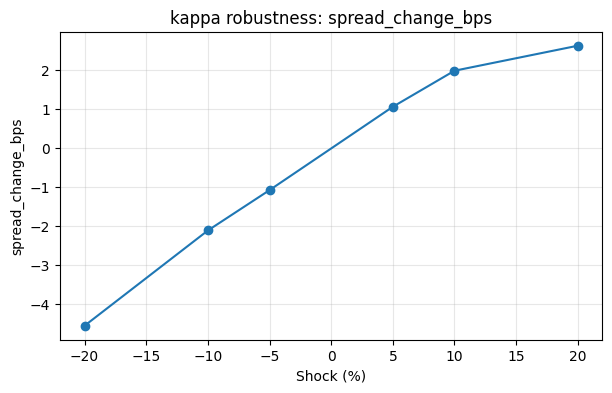

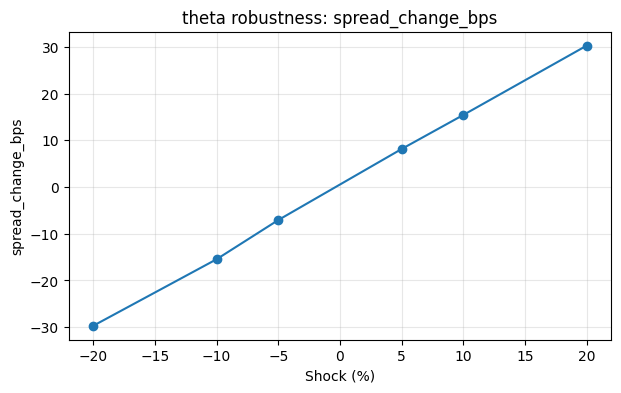

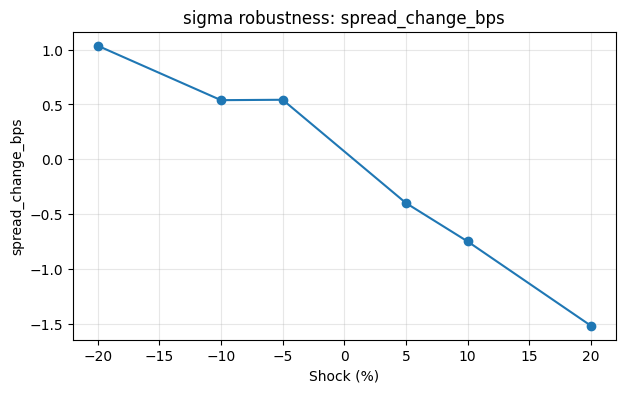

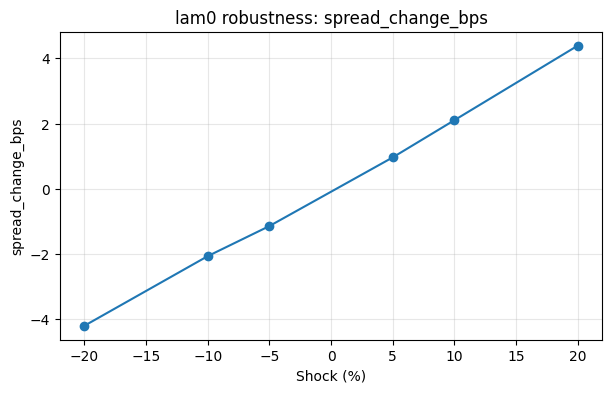

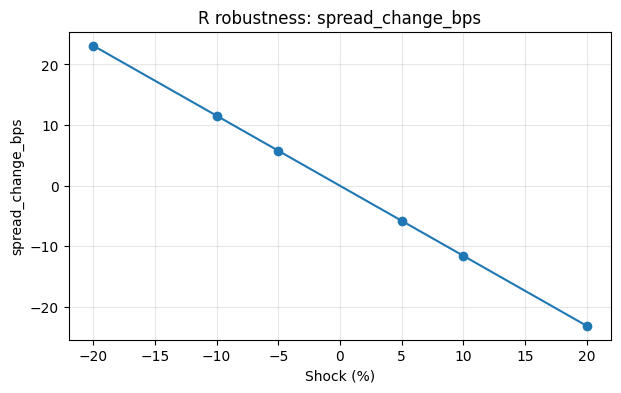

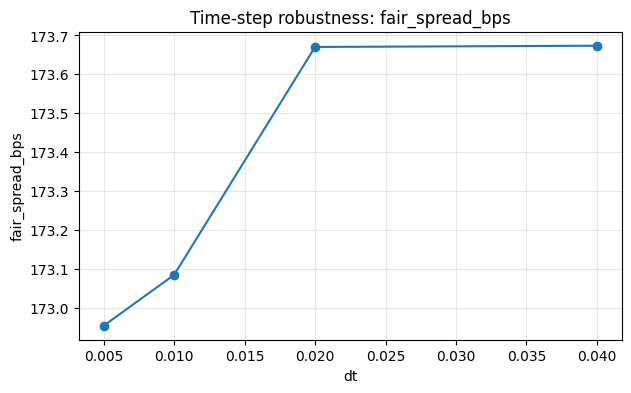

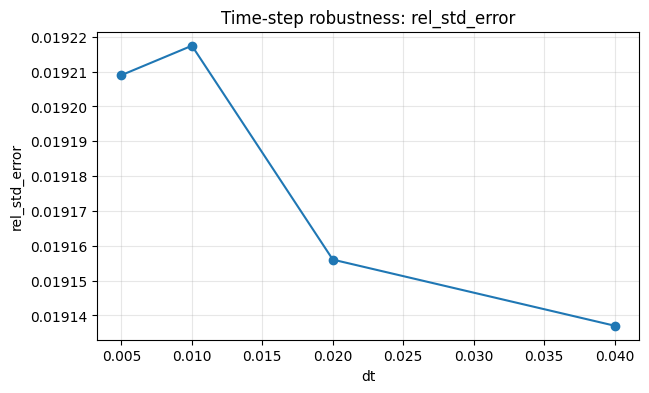

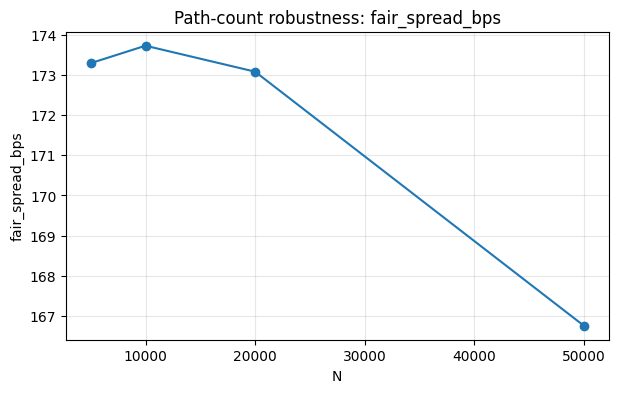

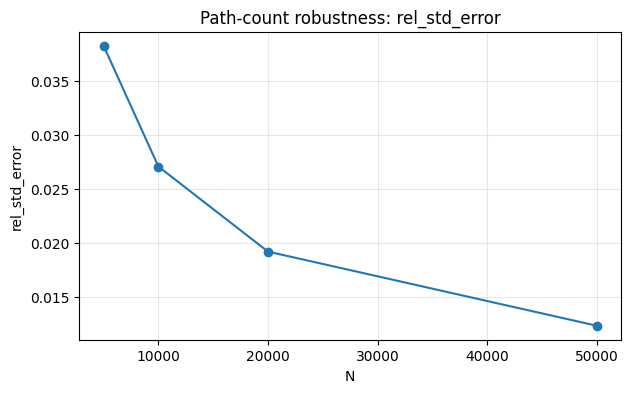

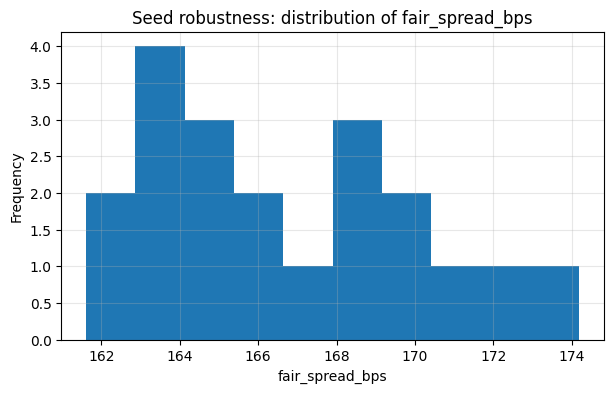

=== Baseline result ===
{'fair_spread': 0.017308406530233387, 'survival_T': 0.86505, 'std_error': 0.00033262315752043944, 'annuity_mean': 4.3404810814461445, 'protection_mean': 0.07512681109445692, 'n_valid_paths': 20000, 'status': 'ok'}

=== Parameter robustness summary ===


,parameter,mean_abs_spread_change_bps,max_abs_spread_change_bps,mean_abs_survival_change,max_abs_survival_change,mean_rel_se,max_rel_se
4,theta,17.677093,30.270887,0.013017,0.02210,0.019290,0.021032
0,R,13.462094,23.077875,0.000000,0.00000,0.019217,0.019217
1,kappa,2.233657,4.558248,0.001650,0.00335,0.019236,0.019464
2,lam0,2.475178,4.385581,0.001583,0.00285,0.019216,0.019378
3,sigma,0.797986,1.519633,0.000625,0.00115,0.019219,0.019304



=== Parameter robustness details ===


,parameter,shock,baseline_value,shocked_value,fair_spread,fair_spread_bps,spread_change_bps,spread_change_pct,survival_T,survival_change,std_error,rel_std_error,status
0,kappa,-0.20,1.20,0.9600,0.016853,168.525818,-4.558248,-2.633546,0.86840,0.00335,0.000328,0.019464,ok
1,kappa,-0.10,1.20,1.0800,0.017097,170.965730,-2.118335,-1.223877,0.86660,0.00155,0.000330,0.019330,ok
2,kappa,-0.05,1.20,1.1400,0.017200,171.999624,-1.084442,-0.626540,0.86585,0.00080,0.000332,0.019276,ok
3,kappa,0.05,1.20,1.2600,0.017414,174.135114,1.051049,0.607248,0.86425,-0.00080,0.000334,0.019158,ok
4,kappa,0.10,1.20,1.3200,0.017506,175.058541,1.974475,1.140761,0.86355,-0.00150,0.000334,0.019107,ok
5,kappa,0.20,1.20,1.4400,0.017570,175.699458,2.615393,1.511054,0.86315,-0.00190,0.000335,0.019083,ok
6,theta,-0.20,0.03,0.0240,0.014339,143.387526,-29.696539,-17.157292,0.88705,0.02200,0.000302,0.021032,ok
7,theta,-0.10,0.03,0.0270,0.015763,157.627917,-15.456148,-8.929850,0.87650,0.01145,0.000317,0.020106,ok
8,theta,-0.05,0.03,0.0285,0.016602,166.020396,-7.063669,-4.081063,0.87020,0.00515,0.000325,0.019598,ok
9,theta,0.05,0.03,0.0315,0.018123,181.227597,8.143531,4.704957,0.85900,-0.00605,0.000340,0.018787,ok



=== dt robustness ===


...

,N,fair_spread,fair_spread_bps,survival_T,std_error,rel_std_error,status
0,5000,0.017330,173.296037,0.86440,0.000663,0.038269,ok
1,10000,0.017373,173.730872,0.86440,0.000471,0.027088,ok
2,20000,0.017308,173.084065,0.86505,0.000333,0.019217,ok
3,50000,0.016675,166.752798,0.86956,0.000206,0.012359,ok



=== Seed robustness summary ===


,metric,mean,std,min,max,cv_pct
0,fair_spread_bps,166.708021,3.443255,161.603195,174.193425,2.065441
1,survival_T,0.869608,0.002530,0.864100,0.873250,0.290977



=== Seed robustness details ===


,seed,fair_spread,fair_spread_bps,survival_T,std_error,rel_std_error,status
0,101,0.016341,163.411889,0.87205,0.000322,0.019734,ok
1,102,0.016479,164.785574,0.87125,0.000324,0.019689,ok
2,103,0.016568,165.677300,0.87030,0.000325,0.019594,ok
3,104,0.017192,171.922646,0.86565,0.000331,0.019243,ok
4,105,0.016825,168.246900,0.86870,0.000328,0.019494,ok
5,106,0.017013,170.132397,0.86710,0.000329,0.019360,ok
6,107,0.016756,167.562260,0.86880,0.000326,0.019471,ok
7,108,0.016317,163.167670,0.87215,0.000322,0.019736,ok
8,109,0.016489,164.894808,0.87095,0.000324,0.019650,ok
9,110,0.016848,168.479875,0.86835,0.000328,0.019455,ok


In [134]:
base_params = {                                      # Define baseline parameter set for robustness study.
    "kappa": 1.2,                                    # Mean reversion speed.
    "theta": 0.03,                                   # Long-run intensity level.
    "sigma": 0.25,                                   # Volatility parameter.
    "lam0": 0.02,                                    # Initial intensity.
    "R": 0.40                                        # Recovery rate.
}

robust_out = run_robustness(                         # Run full robustness workflow.
    base_params=base_params,                         # Baseline parameter dictionary.
    shock_levels=(-0.20, -0.10, -0.05, 0.05, 0.10, 0.20),  # One-at-a-time parameter shocks.
    dt_grid=(0.04, 0.02, 0.01, 0.005),              # Time-step values for numerical robustness.
    N_grid=(5000, 10000, 20000, 50000),             # Monte Carlo path counts for robustness.
    seed_grid=range(101, 121),                      # Random seeds for seed robustness.
    T=5.0,                                          # CDS maturity.
    dt=0.01,                                        # Baseline time step.
    N=20000,                                        # Baseline number of Monte Carlo paths.
    r=0.03,                                         # Constant risk-free rate.
    seed=123,                                       # Baseline random seed.
    make_plots=True                                 # Generate diagnostic plots.
)

print("=== Baseline result ===")                    # Print header for baseline result.
print(robust_out["baseline"])                       # Display baseline pricing result dictionary.

print("\n=== Parameter robustness summary ===")     # Print header for parameter robustness summary.
display(robust_out["parameter_summary"])            # Display aggregated parameter robustness summary.

print("\n=== Parameter robustness details ===")     # Print header for parameter robustness detail table.
display(robust_out["parameter_results"].head(20))   # Display first 20 rows of parameter robustness results.

print("\n=== dt robustness ===")                    # Print header for time-step robustness results.
display(robust_out["dt_results"])                   # Display dt sweep results.

print("\n=== N robustness ===")                     # Print header for path-count robustness results.
display(robust_out["N_results"])                    # Display N sweep results.

print("\n=== Seed robustness summary ===")          # Print header for seed robustness summary.
display(robust_out["seed_summary"])                 # Display aggregated seed robustness summary.

print("\n=== Seed robustness details ===")          # Print header for seed robustness detail table.
display(robust_out["seed_results"].head(10))        # Display first 10 rows of seed robustness results.

## 7. Validation Conclusion 
<a id="d7"></a>
*(Should we approve it?)*

### 7.a. Approval status 
<a id="d7a"></a>
*(Is the model fit for use?)*

The CDS hazard-rate model with stochastic CIR intensity is **approved with limitations** for controlled analytical use, including CDS pricing experiments, sensitivity analysis, challenger benchmarking, and model validation exercises within an admissible parameter regime.

This approval is supported by the cumulative validation evidence in the previous sections of this project. Verification tests confirm that the implementation is mathematically consistent and numerically stable: time-step error is small on practical grids, Monte Carlo error follows the expected rate, independent replication is close, and boundary-condition tests behave correctly. Calibration results show that the model can recover the synthetic truth with low error, and parameter estimates are stable under small spread perturbations and leave-one-out maturity tests. Benchmarking results further support the implementation, as the stochastic and deterministic CIR models are closely aligned, the $\sigma \to 0$ limit behaves correctly, and the CIR specifications outperform simpler challengers in predictive accuracy. Outcomes analysis indicates low forecast error and limited bias under repeated tests. Stress testing and robustness analysis show smooth, economically coherent responses to shocks, no numerical breakdown in economically relevant $(\lambda_0,R)$ regions, and controlled Monte Carlo variability.

The approval is subject to important limitations. Calibration quality depends on initialization and may exhibit non-uniqueness or optimizer sensitivity. Large portions of $(\kappa,\sigma)$ space violate the Feller condition, creating structurally weak regions even when the numerical implementation remains stable. The model is reduced-form and therefore does not capture structural drivers of default. In addition, the study is based on synthetic data and does not establish empirical fit to observed market CDS term structures.

Accordingly, the model is suitable for research, prototyping, and controlled validation use, but should not be used for production pricing, limit setting, or regulatory reporting without tighter calibration controls, explicit parameter restrictions, and empirical market-data validation.

### 7.b. Limitations 
<a id="d7b"></a>
*(What limitations must be acknowledged?)*

The model has several limitations that constrain its scope of use.

#### I. Absence of empirical market-data validation.

**Impact**: High. This directly limits production use and external credibility.

The calibration and outcomes exercises are performed against synthetic term structures rather than observed market CDS data. As a result, the study demonstrates internal consistency and recovery of synthetic truth, but does not establish real-world pricing accuracy, market stability across regimes, or live calibration performance. This is the most important limitation from a model-risk perspective, because production suitability depends not only on internal correctness but also on empirical adequacy.

#### II. Calibration sensitivity to initialization and potential identifiability issues.

**Impact**: High. This affects parameter reliability and model governance, even if the pricing engine is sound.

Although calibration performs well near the synthetic truth and is stable under small spread perturbations and leave-one-out maturity tests, the initial-guess stability exercise shows that the optimizer can converge to materially different parameter values with substantially worse fit. This indicates a nontrivial calibration landscape with potential local minima or weak identifiability among parameters. The implication is that calibration quality depends on solver controls, initialization design, and parameter bounds, which introduces governance risk even when the pricing engine itself is sound.

#### III. Reduced-form specification limits economic interpretability.

**Impact**: Moderate. This is structurally important but does not invalidate the model for reduced-form CDS pricing.

The model treats default as an exogenous jump governed by stochastic intensity. This is appropriate for pricing and term-structure analysis, but it does not capture firm-value dynamics, capital structure effects, or other structural drivers of credit deterioration. Accordingly, the model is better suited to reduced-form pricing and sensitivity analysis than to economically structural interpretation of default mechanisms.

#### IV. Structural weakness in Feller-violating parameter regions.

**Impact**: Moderate. The issue is structural rather than numerical and can be controlled with parameter restrictions.

Breakdown analysis shows that much of the $(\kappa,\sigma)$ grid falls into regions of severe Feller violation. While pricing outputs remain numerically stable and smooth even near the boundary, these regions are structurally weaker because the underlying CIR process loses its standard positivity-preserving admissibility properties. Full truncation mitigates numerical failure but does not eliminate the conceptual concern. These regions should therefore be treated as restricted or monitored parameter regimes rather than as standard operating conditions.

#### V. Discretization and simulation approximation remain present.

**Impact**: Low to Moderate. Verification results show it is small on practical grids.

The model relies on full-truncation Euler simulation and discretized default-time construction. Verification results show that time-step errors are small at practical grids and Monte Carlo scaling is correct, but approximation error is not zero. This is especially relevant in more extreme parameter regimes, where continuous-time and discretized behavior may diverge more materially.

#### VI. Limited spread sensitivity to volatility.

**Impact**: Low to Moderate. Secondary relative to calibration and empirical-validation issues.

Robustness results show that spread levels are much more sensitive to $\theta$ and $R$ than to $\sigma$. This is consistent with the model structure, but it also means the framework may underrepresent volatility-driven credit effects in environments where dispersion or uncertainty in intensity dynamics is itself a primary risk driver.

### 7.c. Usage restrictions 
<a id="d7c"></a>
*(Where should the model not be used?)*

The use of the CDS pricing model is subject to the following restrictions and controls, derived from validation findings.

#### I. Permitted Use Cases

A. The model is approved for:
1. CDS pricing analysis in controlled environments.
2. Sensitivity and scenario analysis.
3. Benchmarking against alternative reduced-form models.
4. Methodological research and model development.

B. Use is appropriate where:
1. Parameter values remain within validated ranges.
2. Calibration is stable and well-controlled.
3. Outputs are interpreted in a reduced-form framework.

#### II. Prohibited Use Cases

A. The model must not be used for:
1. Production pricing or trading decisions without further validation.
2. Regulatory capital or accounting valuation.
3. Illiquid or stressed market calibration without additional controls.
4. Structural credit risk analysis (e.g. capital structure inference).

B. Rationale:
1. No empirical market validation.
2. Calibration instability under poor initialization.
3. Reduced-form limitations.

#### III. Parameter Admissibility Restrictions

A. To avoid structurally weak regions:
1. The Feller condition region must be monitored, and severe violations must be excluded.
2. Parameter combinations with large negative Feller margins must be treated as invalid or flagged.
3. Extreme parameter combinations (e.g. very low $\kappa$ with high $\sigma$) must not be used.

B. Implementation control:
1. Hard threshold or flag on Feller margin.

#### IV. Calibration Controls

Due to sensitivity to initialization:

A. Calibration must be:
1. Run with multiple initial guesses, or
2. Constrained within reasonable parameter bounds.

B. Calibration outputs must be validated via:
1. Fit quality (RMSE, max error).
2. Parameter plausibility checks.

C. Poor-fit calibrations or unstable parameter estimates must be rejected.

#### V. Numerical / Simulation Controls

A. Time step must satisfy:
1. $\Delta t \leq 10^{-2}$.

B. Monte Carlo paths:
1. $N \geq 10^{4}$ for stable estimates.
2. Higher $N$ required for stress scenarios.

C. Full truncation scheme must be used to ensure numerical stability.

D. Outputs must be monitored for:
1. Abnormal spread jumps.
2. Escessive standard error.
3. Path invalidity.

#### VI. Interpretation Constraints

A. Results must be interpreted as:
1. Risk-neutral reduced-form outputs, not structural credit measures.

B. Volatility effects should be interpreted cautiously:
1. Spreads are weakly sensitive to $\sigma$.
2. Model may understate volatility-driven credit risk.

### 7.d. Required improvements  
<a id="d7d"></a>
*(What remediation is required?)*

To address the limitations identified in the validation and to enhance the robustness and applicability of the model, the following improvements are required.

#### I. Empirical Market-Data Validation

**Priority**: High. Current validation is based on synthetic data and does not establish real-world performance.

A. The model must be validated against real CDS market data, including:
1. Calibration to observed CDS term structures.
2. Stability across market regimes (e.g. calm vs stressed periods).
3. Out-of-sample predictive performance.

B. Additional diagnostics should include:
1. Bid-ask consistency.
2. Term-structure smoothness vs market curves.
3. Cross-sectional consistency across names.

#### II. Robust Calibration Framework

**Priority**: High. Calibration results show strong dependence on initial conditions despite good local fit.

A. Calibration procedures must be strengthened to address initialization sensitivity and potential non-uniqueness:
1. Implement multi-start optimization.
2. Introduce parameter bounds and regularization.
3. Use robust objective functions (e.g. weighted RMSE).
4. Include diagnostics for convergence quality.

B. Optional enhancements:
1. Global optimization methods (e.g. differential evolution).
2. Parameter penalization for economically implausible values.

#### III. Parameter Admissibility Enforcement

**Priority**: High. Large regions of parameter space exhibit severe Feller violations, which weaken the theoretical foundation of the model.

A. Explicit enforcement of admissible parameter regions is required:
1. Implement hard constraints on the Feller condition (or bounded violation tolerance).
2. Introduce pre- and post-calibration checks on parameter validity.
3. Reject or flag calibrations in structurally weak regions.

#### IV. Enhanced Model Specification

**Priority**: Moderate. The current one-factor CIR structure may limit the ability to capture complex term-structure dynamics.

A. Consider extending the model to improve flexibility and realism:
1. Time-dependent parameters such as $\theta(t)$ or $\lambda_0(t)$.
2. Multi-factor intensity models.
3. Regime-switching or stochastic recovery extensions.

#### V. Improved Default-Time Modeling

**Priority**: Moderate. Although discretization error is small, it remains a structural approximation.

A. Refine the treatment of default timing:
1. Implement exact or higher-order default-time simulation methods.
2. Reduce discretization bias in default event timing.
3. Benchmark against analytical or semi-analytical methods where available.

#### VI. Expanded Sensitivity and Stress Coverage

**Priority**: Moderate. Current stress testing is well-structured but primarily univariate.

A. Extend stress testing to cover:
1. Joint parameter shocks (not only marginal shocks).
2. Extreme but plausible market scenarios.
3. Interaction effects between parameters.

B. Additional diagnostics should include:
1. Stress scenarios aligned with historical crisis periods.

#### VII. Production Controls and Automation

**Priority**: Moderate.

A. Implement automated controls aligned with usage restrictions:
1. Parameter validation checks (e.g. Feller margin thresholds).
2. Calibration quality thresholds (RMSE, max error).
3. Numerical stability monitoring (std error, convergence flags).

B. Additional diagnostics should include:
1. Automated reporting of diagnostics.
2. Reproducibility controls (seed handling, versioning).

#### VIII. Documentation and Governance Enhancements

**Priority**: Low to Moderate. Necessary for auditability and future production consideration.

Documentation and governance should be enhanced to ensure reproducibility, auditability, and controlled model evolution, including formal documentation of methodology, assumptions, parameter constraints, and validation results, as well as version control and change tracking.

## 8. Ongoing Monitoring 
<a id="d8"></a>
*(How do we keep it under control?)*

### 8.a. Performance tracking 
<a id="d8a"></a><a id="d8a"></a>
*(How is performance tracked over time?)*

Ongoing performance of the CDS pricing model must be monitored using a set of quantitative diagnostics to ensure continued accuracy, stability, and consistency.

#### I. Pricing Accuracy Monitoring

A. Model-implied CDS spreads should be regularly compared against:
1. Observed market spreads (when available), or
2. Benchmark models (e.g. piecewise hazard or deterministic CIR).

B. Key metrics include:
1. Mean absolute error (MAE, in bps).
2. Root mean squared error (RMSE, in bps).
3. Maximum absolute error across maturities (Max error, in bps).

C. Baseline reference:
1. MAE $\approx$ 0.4 to 0.8 bps (deterministic CIR).
2. RMSE $\approx$ 0.5 bps.
3. Max error $\approx$ 0.5 to 1.5 bps (vs synthetic truth).

Persistent deviations beyond these ranges should trigger investigation.

#### II. Calibration Quality Monitoring

A. Each calibration run must be evaluated using:
1. RMSE of fitted spreads.
2. Maximum absolute error.
3. Stability of calibrated parameters.

B. Baseline reference:
1. RMSE $\approx 3.6 \times 10^{-4}$.
2. Max abs error $\approx 7.3 \times 10^{-4}$.
3. Mean relative error $\approx$ 1% to 2%.

Calibration outputs that deviate materially from these levels, or that produce unstable parameter estimates across runs, should be flagged.

#### III. Parameter Stability Tracking

A. Calibrated parameters $(\kappa,\theta,\sigma,\lambda_0)$ must be monitored over time:
1. Track time series of parameter estimates.
2. Compute rolling mean and variance.
3. Detect abrupt shifts or drift.

B. Special attention should be given to:
1. Large shifts in $\theta$ (high sensitivity driver).
2. Instability in $\sigma$ or $\lambda_0$.

C. Unexplained parameter jumps may indicate:
1. Calibration instability.
2. Data inconsistencies.
3. Regime changes.

#### IV. Numerical Stability Monitoring

A. Simulation outputs must be monitored to ensure numerical reliability:
1. Standard error of Monte Carlo estimates.
2. Relative standard error (RSE).
3. Fraction of valid paths.

B. Baseline reference:
1. RSE $\approx$ 1.5% to 2.2%.
2. Valid path fraction $\approx$ 100%.

Significant increases in standard error or drops in valid paths indicate potential numerical instability or insufficient simulation granularity.

#### V. Structural Consistency Checks

A. The following structural diagnostics should be tracked:
1. Feller margin $2\kappa\theta-\sigma^2$.
2. Positivity of simulated intensities.
3. Monotonicity and smoothness of survival curves.

Parameter configurations approaching or entering strongly negative Feller regions should be flagged for review.

#### VI. Sensitivity Consistency Monitoring

A. Periodic re-evaluation of parameter sensitivities should confirm that:
1. Spreads remain most sensitive to $\theta$ and $R$.
2. Sensitivity to $\sigma$ remains limited.

B. Material changes in sensitivity patterns may indicate:
1. Calibration instability.
2. Regime shift in data.

### 8.b. Model drift 
<a id="d8b"></a>
*(How is drift detected?)*

Model drift refers to the gradual or abrupt deterioration in model performance or changes in model behavior due to shifts in market conditions, data characteristics, or calibration dynamics. The CDS pricing model must be monitored for multiple forms of drift.

#### I. Parameter Drift

Drift in calibrated parameters $(\kappa,\theta,\sigma,\lambda_0)$ should be tracked over time.

A. Indicators of parameter drift include:
1. Sustained trends in parameter levels.
2. Increased volatility of parameter estimates.
3. Abrupt parameter shifts between calibration runs.

B. Particular attention should be given to:
1. $\theta$, due to its strong influence on spread levels.
2. $\lambda_0$, as a direct driver of short-term intensity.

C. Parameter drift may indicate:
1. Changes in underlying credit conditions.
2. Instability in calibration.
3. Structural mismatch between model and market.

#### II. Performance Drift

A. Model performance should be tracked over time using:
1. MAE / RMSE of spreads.
2. Predictive error (out-of-sample, if available).
3. Benchmark-relative error.

B. Drift is indicated by:
1. Systematic increase in pricing errors.
2. Persistent bias (over- or under-pricing).
3. Widening gap relative to benchmark models.

Given validation results displaying MAE $\approx$ 0.4 to 0.8 bps, sustained deviations above these levels suggest degradation in model accuracy.

#### III. Calibration Drift

A. Changes in calibration behavior should be monitored:
1. Increased sensitivity to initial guesses.
2. Failure to converge reliably.
3. Greater dispersion in calibrated parameters across runs.

B. Drift in calibration stability may indicate:
1. Deterioration in data quality.
2. Increased model misspecification.
3. Ill-posed calibration problem under new market conditions.

#### IV. Structural Drift

Structural drift occurs when the model’s assumptions no longer align with observed data.

A. Indicators include:
1. Inability to fit term structure shapes (e.g. inverted or highly irregular curves).
2. Changing sensitivity patterns (e.g. $\sigma$ becoming unusually influential).
3. Increasing reliance on extreme parameter values.

B. This is particularly relevant given:
1. Reduced-form model limitations.
2. Single-factor CIR structure.

#### V. Regime Shift Detection

A. The model should be monitored for broader regime changes, such as:
1. Transition from low-volatility to high-volatility credit environments.
2. Shifts in recovery assumptions or market conventions.
3. Systemic credit events affecting spread dynamics.

B. Indicators include:
1. Simultaneous shifts in multiple parameters.
2. Breakdown of historical relationships between spreads and parameters.
3. Increased calibration error across all maturities.

#### VI. Numerical Drift

A. Numerical characteristics should also be monitored:
1. Increase in Monte Carlo standard error.
2. Instability in simulation outputs.
3. Sensitivity to time step or number of paths.

Although the validation shows stable behavior under baseline conditions, deterioration in numerical metrics may signal stress conditions or inappropriate parameter regimes.

### 8.c. Thresholds and triggers 
<a id="d8c"></a>
*(What triggers review or intervention?)*

Quantitative thresholds are defined to detect deterioration in model performance, calibration quality, and numerical stability. Breaches of these thresholds trigger review, recalibration, or escalation depending on severity.

#### I. Pricing Performance Thresholds

Performance metrics must remain consistent with validation benchmarks. Thresholds allow for market noise while detecting material degradation.

1. MAE $>$ 2 bps $\to$ warning.
2. MAE $>$ 5 bps $\to$ escalation.
3. RMSE $>$ 3 bps $\to$ warning.
4. RMSE $>$ 6 bps $\to$ escalation.

#### II. Calibration Quality Thresholds

Calibration outputs must meet minimum fit standards.

1. RMSE $>$ 1.0e-3 $\to$ warning.
2. RMSE $>$ 2.0e-3 $\to$ escalation.
3. Max abs error $>$ 1.5e-3 $\to$ escalation.
4. Mean relative error $>$ 5% $\to$ escalation.

#### III. Parameter Stability Thresholds

Parameter movements must remain within reasonable bounds. Model is particularly sensitive to $\theta$, and calibration instability was observed under poor initialization.

1. Daily/periodic parameter change $>$ 20% $\to$ warning.
2. Persistent drift over multiple periods $\to$ escalation.
3. Abrupt change in $\theta$ or $\lambda_0$ beyond historical range $\to$ escalation.

#### IV. Numerical Stability Thresholds

Simulation quality must remain within validated ranges.

1. Relative standard error $>$ 3% $\to$ warning.
2. Relative standard error $>$ 5% $\to$ escalation.
3. Valid path fraction $<$ 99% $\to$ escalation.

#### V. Structural (Feller Condition) Thresholds

Parameter admissibility must be enforced. Severe violations were identified as structurally weak regions.

1. Feller margin $<$ 0 $\to$ warning.
2. Feller margin $<$ -0.05 $\to$ escalation/rejection.

#### VI. Sensitivity and Stress Consistency Triggers

Model sensitivities must remain stable. Validation shows dominant sensitivity to $\theta$ and $R$, with limited impact from $\sigma$.

1. Significant increase in sensitivity to $\sigma$.
2. Breakdown of expected ranking of parameter importance.
3. Non-smooth or discontinuous stress responses.

#### VII. Triggered Actions

Threshold breaches must result in defined actions:

| Severity | Action |
| ----------- | ----------- |
| Warning | Review calibration, verify data quality, and rerun model as needed. |
| Escalation | Formal investigation required; recalibration performed, parameter constraints enforced, and results flagged or restricted from critical use. |
| Rejection | Model output invalid; results must be discarded and recomputed under acceptable conditions. |

### 8.d. Recalibration frequency 
<a id="d8d"></a>
*(How often is recalibration required?)*

The model must be recalibrated at a frequency consistent with the dynamics of the underlying credit environment and the intended use of the model.

#### I. Baseline Recalibration Frequency

A. Recalibration should be performed:
1. Regularly (e.g. daily or weekly) when applied to market data.
2. On-demand for scenario analysis or stress testing.

B. The appropriate frequency depends on:
1. Data availability.
2. Volatility of credit spreads.
3. Intended use (research vs operational).

#### II. Event-Driven Recalibration

A. Recalibration must be triggered outside the regular schedule if any of the following occur:
1. Breach of [performance thresholds](#d8c).
2. Significant [parameter drift](#d8b).
3. Large market moves or regime changes.
4. Changes in input data or conventions.

#### III. Recalibration Validation

A. Each recalibration must be accompanied by:
1. Verification of calibration quality (RMSE, max error).
2. Parameter plausibility checks.
3. Consistency with prior parameter levels.

#### IV. Frequency Adjustment

A. Recalibration frequency should be increased when:
1. Markets are volatile.
2. Parameter drift is elevated.
3. Calibration instability is observed.

B. Recalibration frequency can be decreased when:
1. Model behavior is stable.
2. Market conditions are calm.

### 8.e. Change management 
<a id="d8e"></a>
*(How are model changes controlled?)*

All changes to the model, implementation, or calibration framework must be subject to controlled change management procedures.

#### I. Types of Changes

A. Changes include:
1. Model specification (e.g. dynamics, parameters).
2. Numerical methods (e.g. simulation scheme, discretization).
3. Calibration methodology or objective function.
4. Input data sources or preprocessing.

#### II. Change Classification

A. Changes should be classified as:
1. Minor changes (e.g. code refactoring, performance improvements).
2. Material changes (e.g. model dynamics, calibration redesign).

#### III. Validation Requirements

A. Minor changes require:
1. Testing and documentation updates.

B. Material changes require:
1. Full or partial re-validation.
3. Updated governance documentation (e.g. [validation conclusion](#d7) and [ongoing monitoring](#d8)).

#### IV. Documentation and Version Control

A. All changes must be:
1. Documented with rationale and impact assessment.
2. Version-controlled.
3. Reproducible.

#### V. Approval and Governance

A. Material changes must be:
1. Reviewed and approved prior to use.
2. Supported by updated validation evidence.